## End-to-End HHL Validation for Graph-Based Credit Risk Propagation (Qubitization + QPE + Chebyshev)

In [1]:
"""
Notebook goal:
--------------

Construct and validate a complete executable HHL pipeline
for graph-based credit-risk propagation models using a
qubitization-compatible architecture.

The linear system of interest is

    A x = b

where A is a sparse Hermitian matrix arising from one of
the following financial contagion models:

Model 1:
    A = L + mu I

Model 2:
    A = I - alpha P_sym

with

    L      = graph Laplacian
    P_sym  = symmetric normalized adjacency matrix.

The notebook implements and validates the following HHL
workflow:

1. Sparse financial graph construction
2. Linear-system assembly
3. Sparse shock-state preparation |b>
4. Walk-operator-based QPE architecture
5. Eigenvalue encoding into a phase register
6. Polynomial approximation of 1/lambda
7. Controlled HHL rotation
8. Polynomial uncomputation
9. Inverse QPE
10. Ancilla post-selection
11. Extraction of the quantum solution state |x>
12. Comparison against the classical solution
13. Financial readout procedures

The notebook performs full statevector validation of the
algorithm and compares the resulting quantum solution
against the classical reference solution

    x = A^{-1} b.

The following quantities are evaluated:

    - Fidelity
    - L1 error
    - L2 error
    - L-infinity error
    - Residual norm ||Ax - b||

The notebook additionally validates two application-level
readout modes relevant to credit-risk propagation:

    1. Top-k risky node discovery
    2. Single-node risk estimation

including both histogram-based sampling and direct
projector measurements of the observable

    |eta><eta|.

Several high-level components (walk operators, Hamiltonian
simulation blocks, polynomial-evaluation operators, and
controlled rotations) are represented as validated
oracle-level unitaries rather than fault-tolerant gate
decompositions. The focus is verification of algorithmic
correctness, register conventions, state evolution, and
financial readout methodology.

Subsequent notebooks will replace these oracle-level
components with explicit circuit constructions suitable
for qubitization and sparse Hamiltonian simulation.
"""

# ============================================================
# Cell 1 : Imports and Initializations
# ============================================================

# -----------------------
# Qiskit
# -----------------------
from qiskit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator

# -----------------------
# Numerical libraries
# -----------------------
import numpy as np
import scipy.linalg as la
import scipy.sparse as sp
import scipy.sparse.linalg as spla


# -----------------------
# Plotting
# -----------------------
import matplotlib.pyplot as plt

# -----------------------
# Miscellaneous
# -----------------------
import math as m
import warnings

warnings.filterwarnings('ignore')

# -----------------------
# Custom utility functions
# -----------------------
import Our_Qiskit_Functions as oq

# ============================================================
# Simulators
# ============================================================

state_sim = AerSimulator(method='statevector')
qasm_sim = AerSimulator()

# ============================================================
# Global NumPy settings
# ============================================================

np.set_printoptions(
    precision=4,
    suppress=True,
    linewidth=150
)

# ============================================================
# Random seed
# ============================================================

SEED = 42
rng = np.random.default_rng(SEED)

print("Imports successful.")
print(f"Random seed = {SEED}")

Imports successful.
Random seed = 42


In [2]:
# ============================================================
# Cell 2 : Master Configuration
# ============================================================

# -----------------------
# Problem size
# -----------------------

# Total number of nodes INCLUDING dummy nodes.
# Must be a power of 2.
N = 32

# Number of system qubits
n = int(np.log2(N))

assert 2**n == N, "N must be a power of 2."

# -----------------------
# Shock vector sparsity
# -----------------------

# gamma = 2^{ floor(log2( SHOCK_SPARSITY_FACTOR * log2(N) )) }

SHOCK_SPARSITY_FACTOR = 2

assert SHOCK_SPARSITY_FACTOR > 0, \
    "SHOCK_SPARSITY_FACTOR must be positive."

gamma = 2 ** int(
    np.floor(
        np.log2(
            SHOCK_SPARSITY_FACTOR * np.log2(N)
        )
    )
)

# gamma/2 dummy nodes are required
assert gamma % 2 == 0, "gamma must be even."

N_dummy = gamma // 2
N_real = N - N_dummy

assert N_real > 0, \
    "Number of real nodes must be positive."

# -----------------------
# Sparsity specification
# -----------------------

# Sparsity of J
#
# Every real node has exactly s_J neighbours.
#
# Since A = (1-alpha)I + alpha L,
# the diagonal contributes one additional nonzero,
# so
#
#     s = s_J + 1
#
s_J = 3

assert s_J >= 2, \
    "s_J must be at least 2."

# Sparsity of A
s = s_J + 1

# -----------------------
# Edge-weight specification
# -----------------------

# Minimum positive edge weight
J_min = 0.5

assert J_min > 0, \
    "J_min must be strictly positive."

# Ensure 1/J_min is an integer
assert np.isclose(
    1 / J_min,
    round(1 / J_min)
), "1/J_min must be an integer."

# All positive edge weights will be integer multiples of J_min:
#
#     J_ij = k_ij * J_min
#
# where
#
#     k_ij = 1, 2, 3, ...
#

# -----------------------
# Diffusion parameter
# -----------------------

alpha = 0.6

assert 0 < alpha < 1, \
    "alpha must lie strictly between 0 and 1."



# ============================================================
# Precision-design thresholds
# ============================================================

#
# These thresholds define the smallest meaningful
# values that the oracle value register must be
# capable of resolving.
#
# They are NOT the actual values used in the
# particular instance.
#
# Instead, they define the class of matrices
# that this notebook is designed to handle.
#

ALPHA_THRESHOLD = 1e-2

J_MIN_THRESHOLD = 1e-2



# -----------------------
# Model choice
# -----------------------

# 1 :
# A = (1-alpha)I + alpha(D - J)
#
# 2 :
# A = (1-alpha)I + alpha(I - D^{-1/2} J D^{-1/2})
#

#model = 1
model = 2

assert model in [1, 2], \
    "model must be either 1 or 2."

# -----------------------
# Real-network graph type
# -----------------------

# Allowed values:
#
# "nearest"
# "random_regular"
# "irregular"
#

#graph_type = "nearest"
#graph_type = "random_regular"
graph_type = "irregular"

assert graph_type in [
    "nearest",
    "random_regular",
    "irregular"
], "Invalid graph type."

# ============================================================
# Configuration summary
# ============================================================

print("=" * 65)
print("Master Configuration")
print("=" * 65)

print(f"Total nodes N                           : {N}")
print(f"System qubits n = log2(N)               : {n}")

print()

print(f"Shock sparsity factor                   : {SHOCK_SPARSITY_FACTOR}")
print(f"Shock sparsity gamma                    : {gamma}")
print(f"Dummy nodes (gamma/2)                   : {N_dummy}")
print(f"Real nodes                              : {N_real}")

print()

print(f"Sparsity of J (s_J)                     : {s_J}")
print(f"Sparsity of A (s = s_J + 1)             : {s}")

print()

print(f"Minimum edge weight J_min               : {J_min}")
print(f"1 / J_min                               : {int(round(1/J_min))}")

print("Positive edge weights are multiples of J_min")

print()

print(f"Diffusion parameter alpha               : {alpha}")
print(f"Model                                   : {model}")
print(f"Graph type                              : {graph_type}")

print("=" * 65)

Master Configuration
Total nodes N                           : 32
System qubits n = log2(N)               : 5

Shock sparsity factor                   : 2
Shock sparsity gamma                    : 8
Dummy nodes (gamma/2)                   : 4
Real nodes                              : 28

Sparsity of J (s_J)                     : 3
Sparsity of A (s = s_J + 1)             : 4

Minimum edge weight J_min               : 0.5
1 / J_min                               : 2
Positive edge weights are multiples of J_min

Diffusion parameter alpha               : 0.6
Model                                   : 2
Graph type                              : irregular


In [3]:
# ============================================================
# Cell 3 : Node Partitions and Index Sets
# ============================================================

# ------------------------------------------------------------
# Real bank nodes
# ------------------------------------------------------------

real_nodes = np.arange(N_real)

# ------------------------------------------------------------
# Dummy nodes
# ------------------------------------------------------------

dummy_nodes = np.arange(N_real, N)

# ------------------------------------------------------------
# Useful sets (for O(1) membership tests)
# ------------------------------------------------------------

real_node_set = set(real_nodes)
dummy_node_set = set(dummy_nodes)

# ------------------------------------------------------------
# Consistency checks
# ------------------------------------------------------------

assert len(real_nodes) == N_real
assert len(dummy_nodes) == N_dummy

assert real_node_set.isdisjoint(dummy_node_set)

assert len(real_node_set.union(dummy_node_set)) == N

# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

print("=" * 65)
print("Node Partition Summary")
print("=" * 65)

print(f"Total nodes (N)              : {N}")
print(f"Real nodes                   : {N_real}")
print(f"Dummy nodes                  : {N_dummy}")

print()

print(f"Real node indices            : "
      f"{real_nodes[0]} ... {real_nodes[-1]}")

if N_dummy > 0:
    print(f"Dummy node indices           : "
          f"{dummy_nodes[0]} ... {dummy_nodes[-1]}")
else:
    print("Dummy node indices           : None")

print()

print(f"Real node set size           : {len(real_node_set)}")
print(f"Dummy node set size          : {len(dummy_node_set)}")

print("=" * 65)

Node Partition Summary
Total nodes (N)              : 32
Real nodes                   : 28
Dummy nodes                  : 4

Real node indices            : 0 ... 27
Dummy node indices           : 28 ... 31

Real node set size           : 28
Dummy node set size          : 4


J_real Construction Summary
Graph type                          : irregular
Number of real nodes                : 28

Specified s_J                       : 3
Specified sparsity of A (s)         : 4

Minimum actual row sparsity         : 1
Maximum actual row sparsity         : 3

Minimum weighted degree d_min       : 0.5000
Maximum weighted degree d_max       : 3.0000

Number of undirected edges          : 26
Number of non-zero entries          : 52

Minimum positive J_ij               : 0.5000
Maximum positive J_ij               : 1.0000

First few rows of J_real:

Row 0:
    J[0,12] = 1.0
    J[0,21] = 1.0

Row 1:
    J[1,13] = 1.0
    J[1,25] = 0.5

Row 2:
    J[2,4] = 1.0
    J[2,26] = 0.5

Row 3:
    J[3,9] = 0.5
    J[3,20] = 0.5

Row 4:
    J[4,2] = 1.0

Row 5:
    J[5,10] = 0.5
    J[5,24] = 1.0

Row 6:
    J[6,20] = 0.5

Row 7:
    J[7,16] = 0.5

Row 8:
    J[8,13] = 0.5
    J[8,25] = 0.5

Row 9:
    J[9,3] = 0.5
    J[9,20] = 0.5


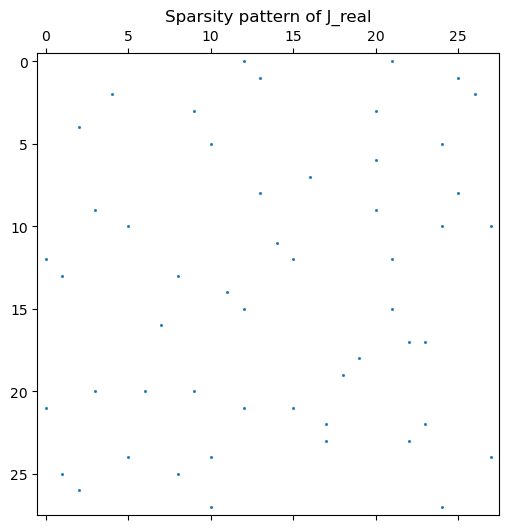

In [4]:
# ============================================================
# Cell 4 : Construct J_real
# ============================================================

# ------------------------------------------------------------
# Utility functions
# ------------------------------------------------------------

def generate_weight(J_min, rng):
    """
    Generate a positive edge weight that is an integer
    multiple of J_min and at most 1.

    Returns a value in

        {J_min, 2 J_min, ..., 1}
    """

    max_multiple = int(round(1 / J_min))

    multiplier = rng.integers(1, max_multiple + 1)

    return multiplier * J_min


# ------------------------------------------------------------
# Nearest-neighbour graph
# ------------------------------------------------------------

def generate_nearest_J(N_nodes,
                       J_min):
    """
    Construct a single cycle:

        0 -> 1 -> 2 -> ... -> N-1 -> 0

    All edge weights are J_min.

    Intended primarily for debugging and the case s_J = 2.
    """

    J = sp.lil_matrix((N_nodes, N_nodes),
                      dtype=float)

    for i in range(N_nodes):

        j = (i + 1) % N_nodes

        J[i, j] = J_min
        J[j, i] = J_min

    return J.tocsr()


# ------------------------------------------------------------
# Random "almost regular" graph
# ------------------------------------------------------------

def generate_random_regular_J(N_nodes,
                              s_J,
                              J_min,
                              rng):
    """
    Randomly partition the nodes.

    Groups of size (s_J + 1):
        Construct complete graphs K_{s_J+1}
        with edge weights J_min.

    Remainder group:
        Construct a simple cycle.
    """

    J = sp.lil_matrix((N_nodes, N_nodes),
                      dtype=float)

    nodes = rng.permutation(N_nodes)

    group_size = s_J + 1

    n_full_groups = N_nodes // group_size

    remainder = N_nodes % group_size

    # --------------------------------------------------------
    # Full groups
    # --------------------------------------------------------

    start = 0

    for _ in range(n_full_groups):

        group = nodes[start:start + group_size]

        start += group_size

        # Complete graph
        for i in range(len(group)):

            for j in range(i + 1,
                           len(group)):

                u = group[i]
                v = group[j]

                J[u, v] = J_min
                J[v, u] = J_min

    # --------------------------------------------------------
    # Remainder group
    # --------------------------------------------------------

    if remainder >= 2:

        group = nodes[start:]

        for i in range(len(group)):

            u = group[i]

            v = group[(i + 1) % len(group)]

            J[u, v] = J_min
            J[v, u] = J_min

    elif remainder == 1:

        print(
            "Warning: One node in the remainder "
            "group has no real-network connections."
        )

    return J.tocsr()


# ------------------------------------------------------------
# Irregular graph
# ------------------------------------------------------------

def generate_irregular_J(N_nodes,
                         s_J,
                         J_min,
                         rng):
    """
    Construct a general irregular graph.

    Procedure:
    1. Partition the nodes into groups whose sizes
       are random integers between 2 and s_J + 1.
    2. Within each group, consider all pairings.
    3. Assign each pairing a weight chosen from

            {0, J_min, 2J_min, ..., 1}

    4. Repair isolated nodes by assigning one
       incident edge weight J_min.

    Guarantees:
        - symmetric,
        - zero diagonal,
        - J_ij >= J_min whenever J_ij > 0,
        - d_i >= J_min for every node.
    """

    J = sp.lil_matrix((N_nodes, N_nodes),
                      dtype=float)

    nodes = list(rng.permutation(N_nodes))

    groups = []

    # --------------------------------------------------------
    # Create random groups
    # --------------------------------------------------------

    while len(nodes) > 0:

        remaining = len(nodes)

        if remaining <= s_J + 1:

            group_size = remaining

        else:

            group_size = rng.integers(
                2,
                s_J + 2
            )

        group = nodes[:group_size]

        groups.append(group)

        nodes = nodes[group_size:]

    # --------------------------------------------------------
    # Populate each group
    # --------------------------------------------------------

    max_multiple = int(round(1 / J_min))

    for group in groups:

        m = len(group)

        if m == 1:
            continue

        # --------------------------------------------
        # Random pairings
        # --------------------------------------------

        for i in range(m):

            for j in range(i + 1,
                           m):

                u = group[i]
                v = group[j]

                multiplier = rng.integers(
                    0,
                    max_multiple + 1
                )

                weight = multiplier * J_min

                if weight > 0:

                    J[u, v] = weight
                    J[v, u] = weight

        # --------------------------------------------
        # Repair isolated nodes
        # --------------------------------------------

        for u in group:

            degree = J[u, :].sum()

            if degree == 0:

                candidates = [
                    v for v in group
                    if v != u
                ]

                if len(candidates) > 0:

                    v = rng.choice(candidates)

                    J[u, v] = J_min
                    J[v, u] = J_min

    return J.tocsr()


# ============================================================
# Construct J_real
# ============================================================

if graph_type == "nearest":

    J_real = generate_nearest_J(
        N_real,
        J_min
    )

elif graph_type == "random_regular":

    J_real = generate_random_regular_J(
        N_real,
        s_J,
        J_min,
        rng
    )

elif graph_type == "irregular":

    J_real = generate_irregular_J(
        N_real,
        s_J,
        J_min,
        rng
    )

else:

    raise ValueError(
        f"Unknown graph type: {graph_type}"
    )


# ============================================================
# Diagnostics
# ============================================================

row_sparsities = np.diff(J_real.indptr)

weighted_degrees = np.array(
    J_real.sum(axis=1)
).flatten()

positive_entries = J_real.data


# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

assert (J_real != J_real.T).nnz == 0, \
    "J_real is not symmetric."

assert np.allclose(
    J_real.diagonal(),
    0
), "J_real has non-zero diagonal entries."

assert np.all(
    weighted_degrees > 0
), "Some nodes have zero weighted degree."

assert np.all(
    positive_entries >= J_min
), "Some positive entries are smaller than J_min."

assert np.allclose(
    positive_entries / J_min,
    np.round(
        positive_entries / J_min
    )
), "Entries are not multiples of J_min."

assert np.all(
    row_sparsities <= s_J
), (
    "Actual sparsity exceeds specified s_J."
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("J_real Construction Summary")
print("=" * 70)

print(f"Graph type                          : "
      f"{graph_type}")

print(f"Number of real nodes                : "
      f"{N_real}")

print()

print(f"Specified s_J                       : "
      f"{s_J}")

print(f"Specified sparsity of A (s)         : "
      f"{s}")

print()

print(f"Minimum actual row sparsity         : "
      f"{row_sparsities.min()}")

print(f"Maximum actual row sparsity         : "
      f"{row_sparsities.max()}")

print()

print(f"Minimum weighted degree d_min       : "
      f"{weighted_degrees.min():.4f}")

print(f"Maximum weighted degree d_max       : "
      f"{weighted_degrees.max():.4f}")

print()

print(f"Number of undirected edges          : "
      f"{J_real.nnz // 2}")

print(f"Number of non-zero entries          : "
      f"{J_real.nnz}")

print()

print(f"Minimum positive J_ij               : "
      f"{positive_entries.min():.4f}")

print(f"Maximum positive J_ij               : "
      f"{positive_entries.max():.4f}")

print("=" * 70)

# ============================================================
# First few rows of J_real
# ============================================================

n_rows_to_show = 10

print("\nFirst few rows of J_real:")

for i in range(n_rows_to_show):

    row = J_real.getrow(i)

    print(f"\nRow {i}:")

    for j, val in zip(row.indices, row.data):

        print(f"    J[{i},{j}] = {val}")


plt.figure(figsize=(6,6))
plt.spy(J_real, markersize=1)
plt.title("Sparsity pattern of J_real")
plt.show()

J_dummy Construction Summary
Number of dummy nodes              : 4

Dummy node indices                 : [28 29 30 31]

Number of undirected dummy edges   : 4
Number of non-zero dummy entries   : 8

Dummy row sparsity                 : 2
Dummy weighted degree              : 1.0000

Dummy edge weight                  : 0.5

First few rows of dummy_subgraph in J_dummy:

Global node 28:
    J[28,29] = 0.5
    J[28,31] = 0.5

Global node 29:
    J[29,28] = 0.5
    J[29,30] = 0.5

Global node 30:
    J[30,29] = 0.5
    J[30,31] = 0.5

Global node 31:
    J[31,28] = 0.5
    J[31,30] = 0.5


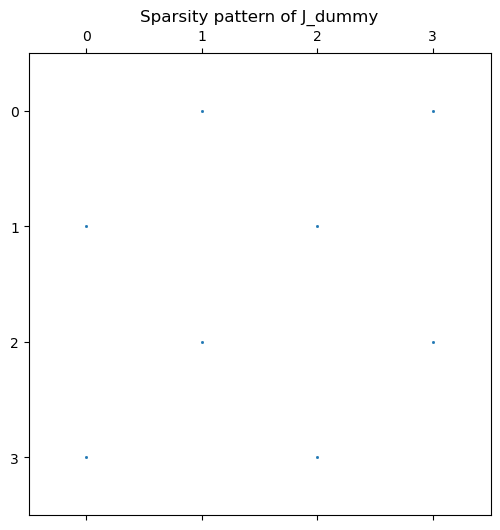

In [5]:
# ============================================================
# Cell 5 : Construct J_dummy
# ============================================================

J_dummy = sp.lil_matrix((N, N), dtype=float)

# ------------------------------------------------------------
# Construct the dummy cycle
# ------------------------------------------------------------

if N_dummy >= 2:

    for idx in range(N_dummy):

        u = dummy_nodes[idx]

        v = dummy_nodes[(idx + 1) % N_dummy]

        J_dummy[u, v] = J_min
        J_dummy[v, u] = J_min

elif N_dummy == 1:

    print(
        "Warning: Only one dummy node exists. "
        "No dummy edges created."
    )

else:

    print(
        "No dummy nodes specified."
    )

J_dummy = J_dummy.tocsr()


# ============================================================
# Diagnostics
# ============================================================

dummy_subgraph = J_dummy[dummy_nodes, :][:, dummy_nodes]

row_sparsities = np.diff(dummy_subgraph.indptr)

weighted_degrees = np.array(
    dummy_subgraph.sum(axis=1)
).flatten()

positive_entries = dummy_subgraph.data


# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

assert (J_dummy != J_dummy.T).nnz == 0, \
    "J_dummy is not symmetric."

assert np.allclose(
    J_dummy.diagonal(),
    0
), "J_dummy has non-zero diagonal entries."

# Ensure there are no real-dummy connections
assert J_dummy[real_nodes, :][:, dummy_nodes].nnz == 0, \
    "Real-to-dummy connections found."

assert J_dummy[dummy_nodes, :][:, real_nodes].nnz == 0, \
    "Dummy-to-real connections found."

if N_dummy >= 3:

    assert np.all(
        row_sparsities == 2
    ), "Dummy cycle does not have sparsity 2."

    assert np.allclose(
        weighted_degrees,
        2 * J_min
    ), (
        "Dummy weighted degrees are not equal "
        "to 2*J_min."
    )

if positive_entries.size > 0:

    assert np.allclose(
        positive_entries,
        J_min
    ), "Dummy edge weights are not equal to J_min."


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("J_dummy Construction Summary")
print("=" * 70)

print(f"Number of dummy nodes              : "
      f"{N_dummy}")

print()

print(f"Dummy node indices                 : "
      f"{dummy_nodes}")

print()

print(f"Number of undirected dummy edges   : "
      f"{dummy_subgraph.nnz // 2}")

print(f"Number of non-zero dummy entries   : "
      f"{dummy_subgraph.nnz}")

print()

if N_dummy >= 3:

    print(f"Dummy row sparsity                 : "
          f"{row_sparsities[0]}")

    print(f"Dummy weighted degree              : "
          f"{weighted_degrees[0]:.4f}")

print()

print(f"Dummy edge weight                  : "
      f"{J_min}")

print("=" * 70)

# ============================================================
# First few rows of J_dummy
# ============================================================

n_rows_to_show = min(dummy_subgraph.shape[0], 10)

print("\nFirst few rows of dummy_subgraph in J_dummy:")

for local_i in range(n_rows_to_show):

    global_i = dummy_nodes[local_i]

    row = dummy_subgraph.getrow(local_i)

    print(f"\nGlobal node {global_i}:")

    for local_j, val in zip(row.indices, row.data):

        global_j = dummy_nodes[local_j]

        print(
            f"    J[{global_i},{global_j}] = {val}"
        )


plt.figure(figsize=(6,6))
plt.spy(dummy_subgraph, markersize=1)
plt.title("Sparsity pattern of J_dummy")
plt.show()

Full Adjacency Matrix J Summary
Shape of J                          : (32, 32)

Number of real nodes                : 28
Number of dummy nodes               : 4

Specified s_J                       : 3
Maximum actual row sparsity         : 3

d_min                               : 0.5000
d_max                               : 3.0000

Specified J_min                     : 0.5000
Actual minimum positive J_ij        : 0.5000
Actual maximum positive J_ij        : 1.0000

Number of undirected edges          : 30
Number of non-zero entries          : 60

Number of connected components      : 10
Smallest component size             : 2
Largest component size              : 4

First few rows of J:

Row 0:
    J[0,12] = 1.0
    J[0,21] = 1.0

Row 1:
    J[1,13] = 1.0
    J[1,25] = 0.5

Row 2:
    J[2,4] = 1.0
    J[2,26] = 0.5

Row 3:
    J[3,9] = 0.5
    J[3,20] = 0.5

Row 4:
    J[4,2] = 1.0

Row 5:
    J[5,10] = 0.5
    J[5,24] = 1.0

Row 6:
    J[6,20] = 0.5

Row 7:
    J[7,16] = 0.5

Row 8:
 

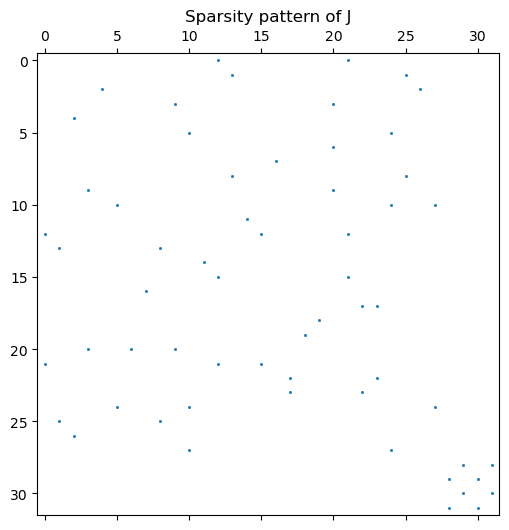

In [6]:
# ============================================================
# Cell 6 : Construct the full adjacency matrix J
# ============================================================

# ------------------------------------------------------------
# Embed J_real into an N x N matrix
# ------------------------------------------------------------

J_real_full = sp.lil_matrix((N, N), dtype=float)

J_real_full[:N_real, :N_real] = J_real

J_real_full = J_real_full.tocsr()

# ------------------------------------------------------------
# Assemble the full J matrix
# ------------------------------------------------------------

J = J_real_full + J_dummy

J = J.tocsr()

# ============================================================
# Diagnostics
# ============================================================

# ------------------------------------------------------------
# Basic structural properties
# ------------------------------------------------------------

assert J.shape == (N, N), \
    "J does not have shape (N, N)."

assert (J != J.T).nnz == 0, \
    "J is not symmetric."

assert np.allclose(
    J.diagonal(),
    0
), "J has non-zero diagonal entries."

# ------------------------------------------------------------
# Verify that real and dummy sectors are disconnected
# ------------------------------------------------------------

assert J[real_nodes, :][:, dummy_nodes].nnz == 0, \
    "Real-to-dummy connections detected."

assert J[dummy_nodes, :][:, real_nodes].nnz == 0, \
    "Dummy-to-real connections detected."

# ------------------------------------------------------------
# Sparsity diagnostics
# ------------------------------------------------------------

row_sparsities = np.diff(J.indptr)

max_row_sparsity = row_sparsities.max()

# ------------------------------------------------------------
# Weighted degree diagnostics
# ------------------------------------------------------------

weighted_degrees = np.array(
    J.sum(axis=1)
).flatten()

d_min = weighted_degrees.min()

d_max = weighted_degrees.max()

assert np.all(
    weighted_degrees > 0
), "Some nodes have zero weighted degree."

assert d_min >= J_min - 1e-12, \
    "d_min is smaller than J_min."

# ------------------------------------------------------------
# Edge-weight diagnostics
# ------------------------------------------------------------

positive_entries = J.data

assert np.all(
    positive_entries >= J_min
), "Some positive entries are smaller than J_min."

assert np.allclose(
    positive_entries / J_min,
    np.round(
        positive_entries / J_min
    )
), "Some edge weights are not multiples of J_min."

J_ij_min_actual = positive_entries.min()

J_ij_max_actual = positive_entries.max()

# ------------------------------------------------------------
# Connected component diagnostics
# ------------------------------------------------------------

n_components, component_labels = sp.csgraph.connected_components(
    J,
    directed=False
)

component_sizes = np.bincount(component_labels)

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Full Adjacency Matrix J Summary")
print("=" * 70)

print(f"Shape of J                          : "
      f"{J.shape}")

print()

print(f"Number of real nodes                : "
      f"{N_real}")

print(f"Number of dummy nodes               : "
      f"{N_dummy}")

print()

print(f"Specified s_J                       : "
      f"{s_J}")

print(f"Maximum actual row sparsity         : "
      f"{max_row_sparsity}")

print()

print(f"d_min                               : "
      f"{d_min:.4f}")

print(f"d_max                               : "
      f"{d_max:.4f}")

print()

print(f"Specified J_min                     : "
      f"{J_min:.4f}")

print(f"Actual minimum positive J_ij        : "
      f"{J_ij_min_actual:.4f}")

print(f"Actual maximum positive J_ij        : "
      f"{J_ij_max_actual:.4f}")

print()

print(f"Number of undirected edges          : "
      f"{J.nnz // 2}")

print(f"Number of non-zero entries          : "
      f"{J.nnz}")

print()

print(f"Number of connected components      : "
      f"{n_components}")

print(f"Smallest component size             : "
      f"{component_sizes.min()}")

print(f"Largest component size              : "
      f"{component_sizes.max()}")

print("=" * 70)

# ============================================================
# First few rows of J
# ============================================================

n_rows_to_show = 10

print("\nFirst few rows of J:")

for i in range(n_rows_to_show):

    row = J.getrow(i)

    print(f"\nRow {i}:")

    for j, val in zip(row.indices, row.data):

        print(f"    J[{i},{j}] = {val}")


plt.figure(figsize=(6,6))
plt.spy(J, markersize=1)
plt.title("Sparsity pattern of J")
plt.show()

In [7]:
# ============================================================
# Cell 7 : Construct D, L, and A
# ============================================================

# ------------------------------------------------------------
# Degree vector and degree matrix
# ------------------------------------------------------------

degree_vector = np.array(
    J.sum(axis=1)
).flatten()

D = sp.diags(
    degree_vector,
    offsets=0,
    shape=(N, N),
    format='csr'
)

# ============================================================
# Construct the Laplacian
# ============================================================

if model == 1:

    # --------------------------------------------------------
    # Model 1:
    #
    #     L = D - J
    #
    # --------------------------------------------------------

    L = D - J

elif model == 2:

    # --------------------------------------------------------
    # Model 2:
    #
    #     L = I - D^{-1/2} J D^{-1/2}
    #
    # --------------------------------------------------------

    D_inv_sqrt = sp.diags(
        1 / np.sqrt(degree_vector),
        offsets=0,
        shape=(N, N),
        format='csr'
    )

    L = (
        sp.eye(N, format='csr')
        - D_inv_sqrt @ J @ D_inv_sqrt
    )

else:

    raise ValueError(
        f"Unknown model: {model}"
    )

# ============================================================
# Construct A
# ============================================================

A = (
    (1 - alpha) * sp.eye(N, format='csr')
    + alpha * L
)

A = A.tocsr()

# ============================================================
# Diagnostics
# ============================================================

A_row_sparsities = np.diff(A.indptr)

A_diagonal = A.diagonal()

off_diagonal = A - sp.diags(
    A_diagonal,
    format='csr'
)

positive_off_diagonal_entries = (
    off_diagonal.data[
        off_diagonal.data > 1e-12
    ]
)

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

assert (A != A.T).nnz == 0, \
    "A is not symmetric."

assert np.all(
    A_diagonal > 0
), "A does not have positive diagonal entries."

assert len(
    positive_off_diagonal_entries
) == 0, (
    "A has positive off-diagonal entries "
    "and is therefore not a Z-matrix."
)

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Matrix Construction Summary")
print("=" * 70)

print(f"Model used                          : "
      f"{model}")

print()

print(f"Diffusion parameter alpha           : "
      f"{alpha:.4f}")

print()

print(f"Minimum degree d_min                : "
      f"{degree_vector.min():.4f}")

print(f"Maximum degree d_max                : "
      f"{degree_vector.max():.4f}")

print()

print(f"Maximum row sparsity of A           : "
      f"{A_row_sparsities.max()}")

print()

print(f"Minimum diagonal entry of A         : "
      f"{A_diagonal.min():.4f}")

print(f"Maximum diagonal entry of A         : "
      f"{A_diagonal.max():.4f}")

print()

print(f"Number of non-zero entries in A     : "
      f"{A.nnz}")

print()

print(f"A is symmetric                      : True")

print(f"A is a Z-matrix                     : True")

print("=" * 70)

Matrix Construction Summary
Model used                          : 2

Diffusion parameter alpha           : 0.6000

Minimum degree d_min                : 0.5000
Maximum degree d_max                : 3.0000

Maximum row sparsity of A           : 4

Minimum diagonal entry of A         : 1.0000
Maximum diagonal entry of A         : 1.0000

Number of non-zero entries in A     : 92

A is symmetric                      : True
A is a Z-matrix                     : True


In [8]:
# ============================================================
# Cell 8 : Spectral Diagnostics for A
# ============================================================

BLOCK_ENCODING_MARGIN = 1e-10

BOUND_VALIDATION_TOL = 1e-12
# (Used only when comparing exact theoretical bounds with numerically computed eigenvalues.)


# ------------------------------------------------------------
# Compute extremal eigenvalues
# ------------------------------------------------------------

print("Computing extremal eigenvalues of A...")

lambda_min = spla.eigsh(
    A,
    k=1,
    which='SA',
    return_eigenvectors=False
)[0]

lambda_max = spla.eigsh(
    A,
    k=1,
    which='LA',
    return_eigenvectors=False
)[0]

# ------------------------------------------------------------
# Exact condition number
# ------------------------------------------------------------

kappa_exact = lambda_max / lambda_min


# ============================================================
# Model-specific theoretical bounds
# ============================================================

if model == 1:

    #
    # A = (1-alpha)I + alpha(D - J)
    #
    # lambda_min >= 1 - alpha
    #
    # lambda_max <= (1-alpha) + 2 alpha d_max
    #

    lambda_min_bound = 1 - alpha

    lambda_max_bound = (
        (1 - alpha)
        + 2 * alpha * d_max
    )

    row_sum_bound = 2*(s - 1)

elif model == 2:

    #
    # A = (1-alpha)I
    #   + alpha(I - D^{-1/2} J D^{-1/2})
    #
    # spectrum(A) subseteq [1-alpha, 1+alpha]
    #

    lambda_min_bound = 1 - alpha

    lambda_max_bound = 1 + alpha

    row_sum_bound = s

else:

    raise ValueError(
        f"Unknown model: {model}"
    )


# ------------------------------------------------------------
# Theoretical condition number bound
# ------------------------------------------------------------

kappa_bound = (
    lambda_max_bound
    / lambda_min_bound
)


# ============================================================
# Positive definiteness diagnostics
# ============================================================

is_positive_definite = (
    lambda_min > 0
)

assert is_positive_definite, \
    (
        "A is not positive definite.\n"
        f"lambda_min = {lambda_min:.12f}"
    )


# ============================================================
# Validate theoretical bounds
# ============================================================

lower_bound_valid = (
    lambda_min >=
    lambda_min_bound - BOUND_VALIDATION_TOL
)

upper_bound_valid = (
    lambda_max <=
    lambda_max_bound + BOUND_VALIDATION_TOL
)

assert lower_bound_valid, \
    (
        "Theoretical lower bound violated.\n"
        f"lambda_min = {lambda_min:.12f}\n"
        f"lambda_min_bound = "
        f"{lambda_min_bound:.12f}"
    )

assert upper_bound_valid, \
    (
        "Theoretical upper bound violated.\n"
        f"lambda_max = {lambda_max:.12f}\n"
        f"lambda_max_bound = "
        f"{lambda_max_bound:.12f}"
    )


# ============================================================
# Block-encoding scaling factor
# ============================================================

# Note that alpha_A must ensure two things.
#
# 1. ||A / alpha_A||_2 <= 1,
#    so that the matrix is block-encodable.
#
# 2. For every row i,
#
#       sum_j |A_ij| / alpha_A <= 1,
#
#    so that the PREPARE amplitudes
#
#       sqrt(|A_ij| / alpha_A)
#
#    form a valid subnormalized state.
#    The remaining probability mass is assigned
#    to the |fail> state.

alpha_A = (
    max(
        lambda_max_bound,
        row_sum_bound
    )
    /
    (1 - BLOCK_ENCODING_MARGIN)
)

# ============================================================
# Encodability diagnostics
# ============================================================

scaled_lambda_min = (
    lambda_min / alpha_A
)

scaled_lambda_max = (
    lambda_max / alpha_A
)

all_eigenvalues_encodable = (
    scaled_lambda_max <= 1
)

assert all_eigenvalues_encodable, \
    (
        "Eigenvalues are not block-encodable.\n"
        f"lambda_max / alpha_A = "
        f"{scaled_lambda_max:.12f}"
    )

assert scaled_lambda_min > 0, \
    (
        "Scaled eigenvalues are not positive.\n"
        f"lambda_min / alpha_A = "
        f"{scaled_lambda_min:.12f}"
    )


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Spectral Diagnostics")
print("=" * 70)

print(f"Exact lambda_min                   : "
      f"{lambda_min:.8f}")

print(f"Exact lambda_max                   : "
      f"{lambda_max:.8f}")

print()

print(f"Exact condition number             : "
      f"{kappa_exact:.8f}")

print()

print(f"Theoretical lambda_min bound       : "
      f"{lambda_min_bound:.8f}")

print(f"Theoretical lambda_max bound       : "
      f"{lambda_max_bound:.8f}")

print()

print(f"Theoretical condition number bound : "
      f"{kappa_bound:.8f}")

print()

print(f"Row-sum bound                      : "
      f"{row_sum_bound:.8f}")

print()

print(f"Block-encoding margin              : "
      f"{BLOCK_ENCODING_MARGIN:.2e}")

print(f"Block-encoding scaling alpha_A     : "
      f"{alpha_A:.8f}")

print()

print(f"lambda_min / alpha_A               : "
      f"{scaled_lambda_min:.8f}")

print(f"lambda_max / alpha_A               : "
      f"{scaled_lambda_max:.8f}")

print(f"alpha_A / lambda_max               : "
      f"{alpha_A / lambda_max:.8f}")

print()

print(f"A is positive definite             : "
      f"{is_positive_definite}")

print(f"Lower bound validated              : "
      f"{lower_bound_valid}")

print(f"Upper bound validated              : "
      f"{upper_bound_valid}")

print(f"All eigenvalues encodable          : "
      f"{all_eigenvalues_encodable}")

print("=" * 70)

Computing extremal eigenvalues of A...

Spectral Diagnostics
Exact lambda_min                   : 0.40000000
Exact lambda_max                   : 1.60000000

Exact condition number             : 4.00000000

Theoretical lambda_min bound       : 0.40000000
Theoretical lambda_max bound       : 1.60000000

Theoretical condition number bound : 4.00000000

Row-sum bound                      : 4.00000000

Block-encoding margin              : 1.00e-10
Block-encoding scaling alpha_A     : 4.00000000

lambda_min / alpha_A               : 0.10000000
lambda_max / alpha_A               : 0.40000000
alpha_A / lambda_max               : 2.50000000

A is positive definite             : True
Lower bound validated              : True
Upper bound validated              : True
All eigenvalues encodable          : True


In [9]:
# ============================================================
# Cell 9 : Construct Sparse Oracle Tables for A
# ============================================================

A_positions = []
A_values = []

# ------------------------------------------------------------
# Extract sparse representation row by row
# ------------------------------------------------------------

for i in range(N):

    row = A.getrow(i)

    positions = row.indices.tolist()
    values = row.data.tolist()

    # --------------------------------------------------------
    # Verify sparsity assumption
    # --------------------------------------------------------

    assert len(positions) <= s, \
        (
            f"Row {i} exceeds sparsity bound.\n"
            f"Observed sparsity = {len(positions)}\n"
            f"Specified sparsity = {s}"
        )

    A_positions.append(positions)
    A_values.append(values)


# ============================================================
# Pad the rows to uniform length s
# ============================================================

#
# O_F expects a mapping
#
#     (i, ell) -> f(i, ell)
#
# where ell ∈ {0, ..., s−1}.
#
# Therefore, every row representation should have
# exactly s entries.
#
# Padding is performed using actual zero locations
# (p, 0) satisfying A[i, p] = 0.
#
# We additionally ensure that the final position list
# is sorted in ascending order.
#

A_positions_padded = []
A_values_padded = []

for i in range(N):

    positions = A_positions[i].copy()
    values = A_values[i].copy()

    # --------------------------------------------------------
    # Sort the genuine entries
    # --------------------------------------------------------

    pairs = sorted(
        zip(positions, values),
        key=lambda x: x[0]
    )

    positions = [p for p, _ in pairs]
    values = [v for _, v in pairs]

    # --------------------------------------------------------
    # Pad using actual zero locations
    # --------------------------------------------------------

    padding_needed = s - len(positions)

    if padding_needed > 0:

        used_positions = set(positions)

        available_positions = [
            j for j in range(N)
            if j not in used_positions
        ]

        padding_positions = (
            available_positions[:padding_needed]
        )

        positions.extend(padding_positions)

        values.extend(
            [0.0] * padding_needed
        )

    # --------------------------------------------------------
    # Final sorting (including padded entries)
    # --------------------------------------------------------

    pairs = sorted(
        zip(positions, values),
        key=lambda x: x[0]
    )

    positions = [p for p, _ in pairs]
    values = [v for _, v in pairs]

    # --------------------------------------------------------
    # Final checks
    # --------------------------------------------------------

    assert len(positions) == s, \
        (
            f"Row {i} does not have exactly "
            f"{s} padded entries."
        )

    assert len(values) == s, \
        (
            f"Row {i} does not have exactly "
            f"{s} padded values."
        )

    A_positions_padded.append(positions)
    A_values_padded.append(values)


# ============================================================
# Convert to NumPy arrays
# ============================================================

A_positions_padded = np.array(
    A_positions_padded,
    dtype=int
)

A_values_padded = np.array(
    A_values_padded,
    dtype=float
)


# ============================================================
# Verify consistency with A
# ============================================================

for i in range(N):

    for ell in range(s):

        j = A_positions_padded[i, ell]

        val = A_values_padded[i, ell]

        actual_val = A[i, j]

        if sp.issparse(actual_val):

            actual_val = actual_val.toarray()[0, 0]

        actual_val = float(actual_val)

        assert np.isclose(
            val,
            actual_val
        ), (
            f"Inconsistent oracle entry.\n"
            f"Row {i}, ell = {ell}\n"
            f"Position = {j}\n"
            f"Stored value = {val}\n"
            f"Actual value = {actual_val}"
        )


# ============================================================
# Diagnostics
# ============================================================

assert A_positions_padded.shape == (N, s)

assert A_values_padded.shape == (N, s)

assert np.all(
    np.diff(A_positions_padded, axis=1) >= 0
), (
    "Some rows are not sorted in ascending order."
)

assert np.all(
    np.sum(
        A_values_padded != 0,
        axis=1
    ) <= s
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Sparse Oracle Tables for A")
print("=" * 70)

print(f"A_positions_padded shape            : "
      f"{A_positions_padded.shape}")

print(f"A_values_padded shape               : "
      f"{A_values_padded.shape}")

print()

print(f"Specified sparsity s                : "
      f"{s}")

print()

print("First few rows:")

n_rows_to_show = min(5, N)

for i in range(n_rows_to_show):

    print(f"\nRow {i}:")

    for ell in range(s):

        j = A_positions_padded[i, ell]

        val = A_values_padded[i, ell]

        print(
            f"    ell = {ell}: "
            f"column = {j}, "
            f"value = {val:.6f}"
        )

print("\n" + "=" * 70)

Sparse Oracle Tables for A
A_positions_padded shape            : (32, 4)
A_values_padded shape               : (32, 4)

Specified sparsity s                : 4

First few rows:

Row 0:
    ell = 0: column = 0, value = 1.000000
    ell = 1: column = 1, value = 0.000000
    ell = 2: column = 12, value = -0.268328
    ell = 3: column = 21, value = -0.268328

Row 1:
    ell = 0: column = 0, value = 0.000000
    ell = 1: column = 1, value = 1.000000
    ell = 2: column = 13, value = -0.400000
    ell = 3: column = 25, value = -0.244949

Row 2:
    ell = 0: column = 0, value = 0.000000
    ell = 1: column = 2, value = 1.000000
    ell = 2: column = 4, value = -0.489898
    ell = 3: column = 26, value = -0.346410

Row 3:
    ell = 0: column = 0, value = 0.000000
    ell = 1: column = 3, value = 1.000000
    ell = 2: column = 9, value = -0.300000
    ell = 3: column = 20, value = -0.244949

Row 4:
    ell = 0: column = 0, value = 0.000000
    ell = 1: column = 1, value = 0.000000
    ell = 2: 

In [10]:
# ============================================================
# Cell 10 : Classical Sparse Oracles O_F and O_A
# ============================================================

# ------------------------------------------------------------
# Position oracle:
#
#     O_F(i, ell) = f(i, ell)
#
# Returns the column index corresponding to the
# ell-th accessible entry of row i.
# ------------------------------------------------------------

def O_F(i, ell):

    assert 0 <= i < N, \
        f"Row index i = {i} is out of range."

    assert 0 <= ell < s, \
        f"Sparsity index ell = {ell} is out of range."

    return int(
        A_positions_padded[i, ell]
    )


# ------------------------------------------------------------
# Value oracle:
#
#     O_A(i, ell)
#
# Returns the matrix value
#
#     A_{i, f(i, ell)}.
#
# ------------------------------------------------------------

def O_A(i, ell):

    assert 0 <= i < N, \
        f"Row index i = {i} is out of range."

    assert 0 <= ell < s, \
        f"Sparsity index ell = {ell} is out of range."

    return float(
        A_values_padded[i, ell]
    )


# ============================================================
# Exhaustive verification
# ============================================================

for i in range(N):

    for ell in range(s):

        j = O_F(i, ell)

        oracle_value = O_A(i, ell)

        actual_value = A[i, j]

        if sp.issparse(actual_value):

            actual_value = actual_value.toarray()[0, 0]

        actual_value = float(actual_value)

        assert np.isclose(
            oracle_value,
            actual_value
        ), (
            f"Oracle mismatch.\n"
            f"Row = {i}\n"
            f"ell = {ell}\n"
            f"O_F(i, ell) = {j}\n"
            f"O_A(i, ell) = {oracle_value}\n"
            f"A[i, j] = {actual_value}"
        )


# ============================================================
# Diagnostics
# ============================================================

print("=" * 70)
print("Classical Sparse Oracle Verification")
print("=" * 70)

print(
    "Position oracle O_F verified "
    f"for all {N*s} entries."
)

print(
    "Value oracle O_A verified "
    f"for all {N*s} entries."
)

print("\nExample queries:")

n_rows_to_show = min(5, N)

for i in range(n_rows_to_show):

    print(f"\nRow {i}:")

    for ell in range(s):

        j = O_F(i, ell)

        val = O_A(i, ell)

        print(
            f"    ell = {ell}: "
            f"f(i, ell) = {j}, "
            f"A[i, f(i, ell)] = {val:.6f}"
        )

print("\n" + "=" * 70)

Classical Sparse Oracle Verification
Position oracle O_F verified for all 128 entries.
Value oracle O_A verified for all 128 entries.

Example queries:

Row 0:
    ell = 0: f(i, ell) = 0, A[i, f(i, ell)] = 1.000000
    ell = 1: f(i, ell) = 1, A[i, f(i, ell)] = 0.000000
    ell = 2: f(i, ell) = 12, A[i, f(i, ell)] = -0.268328
    ell = 3: f(i, ell) = 21, A[i, f(i, ell)] = -0.268328

Row 1:
    ell = 0: f(i, ell) = 0, A[i, f(i, ell)] = 0.000000
    ell = 1: f(i, ell) = 1, A[i, f(i, ell)] = 1.000000
    ell = 2: f(i, ell) = 13, A[i, f(i, ell)] = -0.400000
    ell = 3: f(i, ell) = 25, A[i, f(i, ell)] = -0.244949

Row 2:
    ell = 0: f(i, ell) = 0, A[i, f(i, ell)] = 0.000000
    ell = 1: f(i, ell) = 2, A[i, f(i, ell)] = 1.000000
    ell = 2: f(i, ell) = 4, A[i, f(i, ell)] = -0.489898
    ell = 3: f(i, ell) = 26, A[i, f(i, ell)] = -0.346410

Row 3:
    ell = 0: f(i, ell) = 0, A[i, f(i, ell)] = 0.000000
    ell = 1: f(i, ell) = 3, A[i, f(i, ell)] = 1.000000
    ell = 2: f(i, ell) = 9, A[i, f(

In [11]:
# ============================================================
# Cell 11 : Oracle Register Specifications
# ============================================================

# ------------------------------------------------------------
# Upper bound on d_max
# ------------------------------------------------------------

#
# Since
#
#     J_ij <= 1,
#
# and each node has at most s_J neighbors,
#
# we have
#
#     d_max <= s_J.
#
# This bound depends only on the problem
# specification and NOT on the realized graph.
#

d_max_possible = s_J


# ============================================================
# Model-1 precision requirements
# ============================================================

#
# For Model 1:
#
#     |A_ij| = alpha J_ij
#
# Therefore,
#
#     |A_ij|
#
#     >= ALPHA_THRESHOLD J_MIN_THRESHOLD.
#

A_min_possible_model_1 = (
    ALPHA_THRESHOLD
    * J_MIN_THRESHOLD
)

#
# Since
#
#     A_ii
#
#     = 1 - alpha + alpha d_i
#
# and
#
#     d_i <= d_max_possible,
#
# we obtain
#
#     A_ii <= 1 + d_max_possible.
#

A_max_possible_model_1 = (
    1
    + d_max_possible
)


# ============================================================
# Model-2 precision requirements
# ============================================================

#
# For Model 2:
#
#     |A_ij|
#
#     = alpha J_ij
#
#       / sqrt(d_i d_j)
#
# Since
#
#     sqrt(d_i d_j)
#
#     <= d_max_possible,
#
# we obtain
#
#     |A_ij|
#
#     >=
#
#     ALPHA_THRESHOLD
#
#     * J_MIN_THRESHOLD
#
#     / d_max_possible.
#

A_min_possible_model_2 = (
    ALPHA_THRESHOLD
    * J_MIN_THRESHOLD
    / d_max_possible
)

#
# Diagonal entries are exactly 1.
#

A_max_possible_model_2 = 1.0


# ============================================================
# Model-agnostic precision requirements
# ============================================================

#
# We construct ONE oracle architecture that
# works for BOTH models.
#
# Therefore, we first determine the largest
# possible matrix entry magnitude among all
# models under consideration.
#

A_max_possible = max(
    A_max_possible_model_1,
    A_max_possible_model_2
)


#
# Require
#
#     A_max_possible / 2^b
#
# to be strictly smaller than the smallest
# representable nonzero entry in each model.
#

ratio_model_1 = (
    A_max_possible
    / A_min_possible_model_1
)

ratio_model_2 = (
    A_max_possible
    / A_min_possible_model_2
)


#
# Add one extra bit to guarantee the strict
# inequality.
#

VALUE_PRECISION_BITS_MODEL_1 = int(
    np.ceil(
        np.log2(ratio_model_1)
    )
) + 1

VALUE_PRECISION_BITS_MODEL_2 = int(
    np.ceil(
        np.log2(ratio_model_2)
    )
) + 1


#
# Model-agnostic value precision.
#

VALUE_PRECISION_BITS = max(
    VALUE_PRECISION_BITS_MODEL_1,
    VALUE_PRECISION_BITS_MODEL_2
)


VALUE_RESOLUTION = (
    A_max_possible
    /
    (2 ** VALUE_PRECISION_BITS)
)


# ------------------------------------------------------------
# Verify that the chosen precision is sufficient
# ------------------------------------------------------------

assert VALUE_RESOLUTION < A_min_possible_model_1, \
    (
        "Value register precision is insufficient "
        "for Model 1.\n"
        f"Resolution = "
        f"{VALUE_RESOLUTION:.12e}\n"
        f"A_min_possible_model_1 = "
        f"{A_min_possible_model_1:.12e}"
    )

assert VALUE_RESOLUTION < A_min_possible_model_2, \
    (
        "Value register precision is insufficient "
        "for Model 2.\n"
        f"Resolution = "
        f"{VALUE_RESOLUTION:.12e}\n"
        f"A_min_possible_model_2 = "
        f"{A_min_possible_model_2:.12e}"
    )


# ============================================================
# Determine actual realized A diagnostics
# ============================================================

A_nonzero_values = A.data

A_nonzero_magnitudes = np.abs(
    A_nonzero_values[
        np.abs(A_nonzero_values) > 0
    ]
)

A_min_actual = (
    A_nonzero_magnitudes.min()
)

A_max_actual = (
    A_nonzero_magnitudes.max()
)

actual_entries_resolvable = (
    A_min_actual
    > VALUE_RESOLUTION
)

assert actual_entries_resolvable, \
    (
        "The realized matrix A contains "
        "entries below the chosen value "
        "resolution.\n"
        f"A_min_actual = "
        f"{A_min_actual:.12e}\n"
        f"Resolution = "
        f"{VALUE_RESOLUTION:.12e}"
    )


# ============================================================
# Register sizes
# ============================================================

#
# Index register
#

n_index = n


#
# Sparsity register
#

n_sparsity = int(
    np.ceil(
        np.log2(s)
    )
)


#
# Position register
#

n_position = n


#
# Sign qubit
#

n_sign = 1


#
# Value register
#

n_value = (
    VALUE_PRECISION_BITS
    + n_sign
)


# ============================================================
# Oracle logical qubit counts
# ============================================================

n_qubits_O_F = (
    n_index
    + n_sparsity
    + n_position
)

n_qubits_O_A = (
    n_index
    + n_sparsity
    + n_value
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Oracle Register Specifications")
print("=" * 70)

print(f"ALPHA_THRESHOLD                   : "
      f"{ALPHA_THRESHOLD:.2e}")

print(f"J_MIN_THRESHOLD                   : "
      f"{J_MIN_THRESHOLD:.2e}")

print()

print(f"d_max_possible                    : "
      f"{d_max_possible}")

print()

print(f"Model-1 A_min_possible            : "
      f"{A_min_possible_model_1:.12e}")

print(f"Model-1 A_max_possible            : "
      f"{A_max_possible_model_1:.12e}")

print(f"Model-1 precision bits            : "
      f"{VALUE_PRECISION_BITS_MODEL_1}")

print()

print(f"Model-2 A_min_possible            : "
      f"{A_min_possible_model_2:.12e}")

print(f"Model-2 A_max_possible            : "
      f"{A_max_possible_model_2:.12e}")

print(f"Model-2 precision bits            : "
      f"{VALUE_PRECISION_BITS_MODEL_2}")

print()

print(f"Model-agnostic A_max_possible     : "
      f"{A_max_possible:.12e}")

print(f"Model-agnostic precision bits     : "
      f"{VALUE_PRECISION_BITS}")

print(f"Model-agnostic resolution         : "
      f"{VALUE_RESOLUTION:.12e}")

print()

print(f"Actual A_min                      : "
      f"{A_min_actual:.12e}")

print(f"Actual A_max                      : "
      f"{A_max_actual:.12e}")

print()

print(f"Actual entries resolvable         : "
      f"{actual_entries_resolvable}")

print()

print(f"Index register qubits             : "
      f"{n_index}")

print(f"Sparsity register qubits          : "
      f"{n_sparsity}")

print(f"Position register qubits          : "
      f"{n_position}")

print(f"Value register qubits             : "
      f"{n_value}")

print()

print(f"O_F logical qubits                : "
      f"{n_qubits_O_F}")

print(f"O_A logical qubits                : "
      f"{n_qubits_O_A}")

print()

print("Ancilla qubits required for")
print("QROM implementation are not")
print("included in these counts.")

print("=" * 70)

Oracle Register Specifications
ALPHA_THRESHOLD                   : 1.00e-02
J_MIN_THRESHOLD                   : 1.00e-02

d_max_possible                    : 3

Model-1 A_min_possible            : 1.000000000000e-04
Model-1 A_max_possible            : 4.000000000000e+00
Model-1 precision bits            : 17

Model-2 A_min_possible            : 3.333333333333e-05
Model-2 A_max_possible            : 1.000000000000e+00
Model-2 precision bits            : 18

Model-agnostic A_max_possible     : 4.000000000000e+00
Model-agnostic precision bits     : 18
Model-agnostic resolution         : 1.525878906250e-05

Actual A_min                      : 1.200000000000e-01
Actual A_max                      : 1.000000000000e+00

Actual entries resolvable         : True

Index register qubits             : 5
Sparsity register qubits          : 2
Position register qubits          : 5
Value register qubits             : 19

O_F logical qubits                : 12
O_A logical qubits                : 26

Anc

In [12]:
# ============================================================
# Cell 12 : QROM Data Preparation
# ============================================================

# ------------------------------------------------------------
# Flatten O_F lookup table
# ------------------------------------------------------------

#
# Address convention:
#
#     address = i * s + ell
#
# where
#
#     i   = row index,
#     ell = sparsity index.
#

num_addresses = N * s

O_F_table = np.zeros(
    num_addresses,
    dtype=int
)

for i in range(N):

    for ell in range(s):

        address = i * s + ell

        O_F_table[address] = (
            A_positions_padded[i, ell]
        )


# ------------------------------------------------------------
# Flatten O_A lookup table
# ------------------------------------------------------------

#
# We encode values using
#
#     sign bit
#
# together with a fixed-point magnitude.
#

O_A_sign_table = np.zeros(
    num_addresses,
    dtype=int
)

O_A_magnitude_table = np.zeros(
    num_addresses,
    dtype=int
)

for i in range(N):

    for ell in range(s):

        address = i * s + ell

        value = (
            A_values_padded[i, ell]
        )

        #
        # Sign bit
        #
        #     0 -> positive
        #     1 -> negative
        #

        if value < 0:

            O_A_sign_table[address] = 1

        else:

            O_A_sign_table[address] = 0

        #
        # Fixed-point magnitude
        #

        magnitude = abs(value)

        encoded_magnitude = int(
            np.round(
                magnitude
                / VALUE_RESOLUTION
            )
        )

        O_A_magnitude_table[address] = (
            encoded_magnitude
        )


# ============================================================
# Verify fixed-point encoding
# ============================================================

maximum_encoding_error = 0.0

for i in range(N):

    for ell in range(s):

        address = i * s + ell

        original_value = (
            A_values_padded[i, ell]
        )

        sign = (
            -1
            if O_A_sign_table[address] == 1
            else 1
        )

        decoded_value = (
            sign
            * O_A_magnitude_table[address]
            * VALUE_RESOLUTION
        )

        encoding_error = abs(
            original_value
            - decoded_value
        )

        maximum_encoding_error = max(
            maximum_encoding_error,
            encoding_error
        )

        assert (
            encoding_error
            <= VALUE_RESOLUTION
        ), (
            f"Fixed-point encoding error too large.\n"
            f"Address = {address}\n"
            f"Original value = {original_value}\n"
            f"Decoded value = {decoded_value}\n"
            f"Error = {encoding_error}"
        )


# ============================================================
# Diagnostics
# ============================================================

print("=" * 70)
print("QROM Data Preparation")
print("=" * 70)

print(f"Number of addresses               : "
      f"{num_addresses}")

print()

print(f"O_F table size                    : "
      f"{len(O_F_table)}")

print(f"O_A sign table size               : "
      f"{len(O_A_sign_table)}")

print(f"O_A magnitude table size          : "
      f"{len(O_A_magnitude_table)}")

print()

print(f"Maximum encoding error            : "
      f"{maximum_encoding_error:.12e}")

print(f"Value resolution                  : "
      f"{VALUE_RESOLUTION:.12e}")

print()

print("Example entries:")

n_examples = min(10, num_addresses)

for address in range(n_examples):

    i = address // s

    ell = address % s

    print(
        f"\nAddress {address}: "
        f"(i={i}, ell={ell})"
    )

    print(
        f"    Position      : "
        f"{O_F_table[address]}"
    )

    original_value = (
        A_values_padded[i, ell]
    )
    
    sign = (
        -1
        if O_A_sign_table[address] == 1
        else 1
    )
    
    decoded_value = (
        sign
        * O_A_magnitude_table[address]
        * VALUE_RESOLUTION
    )
    
    encoding_error = abs(
        original_value
        - decoded_value
    )
    
    print(
        f"    Original value : "
        f"{original_value:.12f}"
    )
    
    print(
        f"    Sign bit       : "
        f"{O_A_sign_table[address]}"
    )
    
    print(
        f"    Magnitude int  : "
        f"{O_A_magnitude_table[address]}"
    )
    
    print(
        f"    Decoded value  : "
        f"{decoded_value:.12f}"
    )
    
    print(
        f"    Encoding error : "
        f"{encoding_error:.12e}"
    )

print("\n" + "=" * 70)


QROM_VALIDATION_THRESHOLD = (
    maximum_encoding_error
    + VALUE_RESOLUTION
) / 2

all_entries_verified = True

for i in range(N):

    for ell in range(s):

        address = i * s + ell

        original_value = (
            A_values_padded[i, ell]
        )

        sign = (
            -1
            if O_A_sign_table[address] == 1
            else 1
        )

        decoded_value = (
            sign
            * O_A_magnitude_table[address]
            * VALUE_RESOLUTION
        )

        encoding_error = abs(
            original_value
            - decoded_value
        )

        if (
            encoding_error
            > QROM_VALIDATION_THRESHOLD
        ):

            all_entries_verified = False

            print(
                "\nValidation failure:"
            )

            print(
                f"Address = {address}"
            )

            print(
                f"Original value = "
                f"{original_value:.12f}"
            )

            print(
                f"Decoded value = "
                f"{decoded_value:.12f}"
            )

            print(
                f"Encoding error = "
                f"{encoding_error:.12e}"
            )

assert all_entries_verified, \
    (
        "QROM validation failed."
    )

print()

print(
    f"QROM validation threshold         : "
    f"{QROM_VALIDATION_THRESHOLD:.12e}"
)

print(
    f"All entries validated             : "
    f"{all_entries_verified}"
)

QROM Data Preparation
Number of addresses               : 128

O_F table size                    : 128
O_A sign table size               : 128
O_A magnitude table size          : 128

Maximum encoding error            : 6.103515625133e-06
Value resolution                  : 1.525878906250e-05

Example entries:

Address 0: (i=0, ell=0)
    Position      : 0
    Original value : 1.000000000000
    Sign bit       : 0
    Magnitude int  : 65536
    Decoded value  : 1.000000000000
    Encoding error : 0.000000000000e+00

Address 1: (i=0, ell=1)
    Position      : 1
    Original value : 0.000000000000
    Sign bit       : 0
    Magnitude int  : 0
    Decoded value  : 0.000000000000
    Encoding error : 0.000000000000e+00

Address 2: (i=0, ell=2)
    Position      : 12
    Original value : -0.268328157300
    Sign bit       : 1
    Magnitude int  : 17585
    Decoded value  : -0.268325805664
    Encoding error : 2.351635912223e-06

Address 3: (i=0, ell=3)
    Position      : 21
    Original v

In [13]:
# ============================================================
# Cell 13 : Logical Specification of Sparse Oracles
# ============================================================

# ------------------------------------------------------------
# Address register
# ------------------------------------------------------------

#
# Address convention:
#
#     address = i * s + ell
#
# where
#
#     i   = row index,
#     ell = sparsity index.
#

n_addresses = N * s

n_address = int(
    np.ceil(
        np.log2(n_addresses)
    )
)


# ============================================================
# Oracle interfaces
# ============================================================

#
# O_F:
#
#     |address>|0>
#
#         ->
#
#     |address>|position>
#
#
# O_A:
#
#     |address>|0>|0>
#
#         ->
#
#     |address>|sign>|magnitude>
#


# ------------------------------------------------------------
# Classical emulation of O_F
# ------------------------------------------------------------

def O_F_address(address):

    assert (
        0 <= address < n_addresses
    ), "Address out of range."

    return int(
        O_F_table[address]
    )


# ------------------------------------------------------------
# Classical emulation of O_A
# ------------------------------------------------------------

def O_A_address(address):

    assert (
        0 <= address < n_addresses
    ), "Address out of range."

    sign = int(
        O_A_sign_table[address]
    )

    magnitude = int(
        O_A_magnitude_table[address]
    )

    return sign, magnitude


# ------------------------------------------------------------
# Decode O_A output
# ------------------------------------------------------------

def decode_O_A(sign, magnitude):

    decoded_sign = (
        -1
        if sign == 1
        else 1
    )

    return (
        decoded_sign
        * magnitude
        * VALUE_RESOLUTION
    )


# ============================================================
# Verify address mapping
# ============================================================

for address in range(n_addresses):

    #
    # Recover (i, ell)
    #

    i = address // s

    ell = address % s

    #
    # Oracle outputs
    #

    position = O_F_address(address)

    sign, magnitude = (
        O_A_address(address)
    )

    decoded_value = decode_O_A(
        sign,
        magnitude
    )

    #
    # Gold-standard values
    #

    expected_position = (
        A_positions_padded[i, ell]
    )

    expected_value = (
        A[i, expected_position]
    )

    if sp.issparse(expected_value):

        expected_value = (
            expected_value.toarray()[0, 0]
        )

    expected_value = float(
        expected_value
    )

    #
    # Verify position oracle
    #

    assert (
        position
        == expected_position
    ), (
        f"Position mismatch.\n"
        f"Address = {address}\n"
        f"Expected = {expected_position}\n"
        f"Obtained = {position}"
    )

    #
    # Verify value oracle
    #

    assert (
        abs(
            decoded_value
            - expected_value
        )
        <= VALUE_RESOLUTION
    ), (
        f"Value mismatch.\n"
        f"Address = {address}\n"
        f"Expected = {expected_value}\n"
        f"Decoded = {decoded_value}"
    )


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Logical Sparse Oracle Specification")
print("=" * 70)

print(f"Number of addresses               : "
      f"{n_addresses}")

print(f"Address register qubits           : "
      f"{n_address}")

print()

print(f"Position output qubits            : "
      f"{n_position}")

print()

print(f"Sign output qubits                : "
      f"{n_sign}")

print(f"Magnitude output qubits           : "
      f"{VALUE_PRECISION_BITS}")

print(f"Value output qubits               : "
      f"{n_value}")

print()

print("Oracle interfaces:")

print()

print("O_F :")

print(
    f"    |address> |0> "
    f"-> "
    f"|address> |position>"
)

print()

print("O_A :")

print(
    f"    |address> |0> |0> "
    f"-> "
    f"|address> |sign> |magnitude>"
)

print()

print("All logical oracle checks passed.")

print("=" * 70)

Logical Sparse Oracle Specification
Number of addresses               : 128
Address register qubits           : 7

Position output qubits            : 5

Sign output qubits                : 1
Magnitude output qubits           : 18
Value output qubits               : 19

Oracle interfaces:

O_F :
    |address> |0> -> |address> |position>

O_A :
    |address> |0> |0> -> |address> |sign> |magnitude>

All logical oracle checks passed.


In [14]:
# ============================================================
# Cell 14 : PREPARE State Construction
# ============================================================

#
# Register convention used from Cell 16 onward:
#
#     |ancilla>|row>|system>
#
# PREPARE acts on the ancilla and row
# registers according to
#
#     |0>|i>
#
#         -->
#
#     |chi_i>|i>,
#
# where
#
#     |chi_i>
#
#     =
#
#     sum_ell
#
#         sqrt(
#             |A_{i,f(i,ell)}|
#             / alpha_A
#         )
#
#         |ell>
#
#     +
#
#     sqrt(
#         1
#         -
#         sum_ell
#             |A_{i,f(i,ell)}|
#             / alpha_A
#     )
#
#         |fail>.
#
# The system register is unaffected
# by PREPARE.
#

# ------------------------------------------------------------
# PREPARE register specifications
# ------------------------------------------------------------

#
# Need:
#
#     s sparsity states
#
# plus
#
#     1 failure state.
#

PREPARE_DIMENSION = s + 1

n_prepare = int(
    np.ceil(
        np.log2(PREPARE_DIMENSION)
    )
)

FAILURE_INDEX = s


# ============================================================
# Construct PREPARE states
# ============================================================

#
# prepare_states[i,:] stores the amplitudes
# of |chi_i>.
#
# These amplitudes determine the action
#
#     |0>|i> --> |chi_i>|i>,
#
# but do not themselves depend on the
# eventual ordering of registers in the
# quantum circuit.
#

prepare_states = np.zeros(
    (N, PREPARE_DIMENSION)
)

prepare_row_sums = np.zeros(N)

for i in range(N):

    #
    # Populate amplitudes
    #

    for ell in range(s):

        value = abs(
            A_values_padded[i, ell]
        )

        prepare_row_sums[i] += (
            value / alpha_A
        )

        prepare_states[i, ell] = np.sqrt(
            value / alpha_A
        )

    #
    # Failure amplitude
    #

    failure_probability = (
        1.0
        - prepare_row_sums[i]
    )

    assert failure_probability >= 0, (
        f"PREPARE normalization failed "
        f"for row {i}.\n"
        f"Failure probability = "
        f"{failure_probability}"
    )

    prepare_states[
        i,
        FAILURE_INDEX
    ] = np.sqrt(
        failure_probability
    )


# ============================================================
# Verify normalization
# ============================================================

prepare_norms = np.sum(
    prepare_states**2,
    axis=1
)

prepare_states_normalized = np.allclose(
    prepare_norms,
    1.0
)

assert prepare_states_normalized, (
    "Some PREPARE states are not normalized."
)


# ============================================================
# Diagnostics
# ============================================================

minimum_failure_probability = np.min(
    prepare_states[:, FAILURE_INDEX]**2
)

maximum_failure_probability = np.max(
    prepare_states[:, FAILURE_INDEX]**2
)

mean_failure_probability = np.mean(
    prepare_states[:, FAILURE_INDEX]**2
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("PREPARE State Construction (Ancilla-First Convention)")
print("=" * 70)

print(f"PREPARE dimension                : "
      f"{PREPARE_DIMENSION}")

print(f"PREPARE register qubits          : "
      f"{n_prepare}")

print(f"Failure-state index              : "
      f"{FAILURE_INDEX}")

print()

print(f"PREPARE states normalized        : "
      f"{prepare_states_normalized}")

print()

print(f"Minimum fail probability         : "
      f"{minimum_failure_probability:.8f}")

print(f"Mean fail probability            : "
      f"{mean_failure_probability:.8f}")

print(f"Maximum fail probability         : "
      f"{maximum_failure_probability:.8f}")

print()

print("First few PREPARE states |chi_i>:")

n_rows_to_show = min(5, N)

for i in range(n_rows_to_show):

    print(f"\n|chi_{i}>:")

    for ell in range(s):

        position = A_positions_padded[i, ell]

        print(
            f"    ell = {ell:2d}, "
            f"position = {position:4d}, "
            f"amplitude = "
            f"{prepare_states[i, ell]:.8f}"
        )

    print(
        f"    fail amplitude = "
        f"{prepare_states[i, FAILURE_INDEX]:.8f}"
    )

print()

print("=" * 70)

PREPARE State Construction (Ancilla-First Convention)
PREPARE dimension                : 5
PREPARE register qubits          : 3
Failure-state index              : 4

PREPARE states normalized        : True

Minimum fail probability         : 0.54092297
Mean fail probability            : 0.60283164
Maximum fail probability         : 0.66339746

First few PREPARE states |chi_i>:

|chi_0>:
    ell =  0, position =    0, amplitude = 0.50000000
    ell =  1, position =    1, amplitude = 0.00000000
    ell =  2, position =   12, amplitude = 0.25900201
    ell =  3, position =   21, amplitude = 0.25900201
    fail amplitude = 0.78475214

|chi_1>:
    ell =  0, position =    0, amplitude = 0.00000000
    ell =  1, position =    1, amplitude = 0.50000000
    ell =  2, position =   13, amplitude = 0.31622777
    ell =  3, position =   25, amplitude = 0.24746160
    fail amplitude = 0.76730878

|chi_2>:
    ell =  0, position =    0, amplitude = 0.00000000
    ell =  1, position =    2, amplitude

In [15]:
# ============================================================
# Cell 15 : SELECT Operator Specification
# ============================================================

#
# Register convention used from Cell 16 onward:
#
#     |ancilla>|row>|system>
#
# where
#
#     |ancilla>
#
# stores
#
#     |ell>
#
# (including the |fail> state),
#
#     |row>
#
# stores
#
#     |i>,
#
# and
#
#     |system>
#
# is the register on which A/alpha_A
# is ultimately block encoded.
#
# SELECT acts according to
#
#     |ell>|i>|psi>
#
#         -->
#
#     |ell>|i>
#
#     X_{i,f(i,ell)}
#
#     |psi>,
#
# where
#
#     f(i,ell)
#
# is obtained from O_F.
#
# The sign information is stored separately
# and will eventually be incorporated into
# SELECT as a controlled ±1 phase factor
# during the sparse block-encoding
# construction.
#

# ============================================================
# Construct SELECT tables
# ============================================================

SELECT_position_table = np.copy(
    A_positions_padded
)

#
# SELECT_sign_table[i, ell]
#
# stores the sign of
#
#     A_{i,f(i,ell)}.
#
# This sign information will later be
# promoted into the quantum implementation
# of SELECT.
#

SELECT_sign_table = np.zeros(
    (N, s),
    dtype=int
)

for i in range(N):

    for ell in range(s):

        value = A_values_padded[i, ell]

        #
        # Sign convention:
        #
        #     0 --> positive
        #     1 --> negative
        #

        SELECT_sign_table[i, ell] = (
            value < 0
        )


# ============================================================
# Verify matrix symmetry
# ============================================================

symmetry_error = np.max(
    np.abs(
        (A - A.T).data
    )
) if (A != A.T).nnz > 0 else 0.0

symmetry_consistent = (
    symmetry_error < 1e-12
)

assert symmetry_consistent, (
    "SELECT requires A to be symmetric.\n"
    f"Maximum symmetry violation = "
    f"{symmetry_error:.12e}"
)


# ============================================================
# Verify SELECT positions
# ============================================================

valid_positions = np.all(
    (
        SELECT_position_table >= 0
    )
    &
    (
        SELECT_position_table < N
    )
)

assert valid_positions, (
    "SELECT contains invalid positions."
)


# ============================================================
# Verify consistency with O_A
# ============================================================

maximum_value_mismatch = 0.0

for i in range(N):

    for ell in range(s):

        j = SELECT_position_table[i, ell]

        oracle_value = (
            A_values_padded[i, ell]
        )

        actual_value = A[i, j]

        mismatch = abs(
            oracle_value
            - actual_value
        )

        maximum_value_mismatch = max(
            maximum_value_mismatch,
            mismatch
        )


value_consistent = (
    maximum_value_mismatch
    <= VALUE_RESOLUTION
)

assert value_consistent, (
    "SELECT and O_A are inconsistent.\n"
    f"Maximum mismatch = "
    f"{maximum_value_mismatch:.12e}"
)


# ============================================================
# Diagnostics
# ============================================================

num_positive_terms = np.sum(
    SELECT_sign_table == 0
)

num_negative_terms = np.sum(
    SELECT_sign_table == 1
)

num_zero_terms = np.sum(
    A_values_padded == 0
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("SELECT Operator Specification")
print("=" * 70)

print(f"System register qubits           : "
      f"{n}")

print(f"Sparsity register qubits         : "
      f"{n_sparsity}")

print()

print(f"Positive entries                 : "
      f"{num_positive_terms}")

print(f"Negative entries                 : "
      f"{num_negative_terms}")

print(f"Zero (padded) entries            : "
      f"{num_zero_terms}")

print()

print(f"Matrix symmetry verified         : "
      f"{symmetry_consistent}")

print(f"Maximum symmetry violation       : "
      f"{symmetry_error:.12e}")

print()

print(f"SELECT positions valid           : "
      f"{valid_positions}")

print()

print(f"SELECT/O_A consistency           : "
      f"{value_consistent}")

print(f"Maximum value mismatch           : "
      f"{maximum_value_mismatch:.12e}")

print()

print("First few SELECT specifications:")

n_rows_to_show = min(5, N)

for i in range(n_rows_to_show):

    print(f"\nRow register state |{i}>:")

    for ell in range(s):

        j = SELECT_position_table[
            i,
            ell
        ]

        value = A_values_padded[
            i,
            ell
        ]

        sign_string = (
            "+"
            if value >= 0
            else "-"
        )

        print(
            f"    ell = {ell:2d} : "
            f"f({i},{ell}) = {j:4d}, "
            f"value = {value:+.8f}, "
            f"sign = {sign_string}"
        )

print()

print("=" * 70)

SELECT Operator Specification
System register qubits           : 5
Sparsity register qubits         : 2

Positive entries                 : 68
Negative entries                 : 60
Zero (padded) entries            : 36

Matrix symmetry verified         : True
Maximum symmetry violation       : 0.000000000000e+00

SELECT positions valid           : True

SELECT/O_A consistency           : True
Maximum value mismatch           : 0.000000000000e+00

First few SELECT specifications:

Row register state |0>:
    ell =  0 : f(0,0) =    0, value = +1.00000000, sign = +
    ell =  1 : f(0,1) =    1, value = +0.00000000, sign = +
    ell =  2 : f(0,2) =   12, value = -0.26832816, sign = -
    ell =  3 : f(0,3) =   21, value = -0.26832816, sign = -

Row register state |1>:
    ell =  0 : f(1,0) =    0, value = +0.00000000, sign = +
    ell =  1 : f(1,1) =    1, value = +1.00000000, sign = +
    ell =  2 : f(1,2) =   13, value = -0.40000000, sign = -
    ell =  3 : f(1,3) =   25, value = -0.24494

In [16]:
# ============================================================
# Cell 16 : Verify the Block Encoding
# ============================================================

#
# Register convention:
#
#     |ancilla>|row>|system>
#
# PREPARE acts as
#
#     |0>|i>
#
#         -->
#
#     |chi_i>|i>,
#
# where
#
#     |chi_i>
#
#     =
#
#     sum_ell
#
#         sqrt(
#             |A_{i,f(i,ell)}|
#             / alpha_A
#         )
#
#         |ell>
#
#     + ...
#
#
# SELECT acts as
#
#     |ell>|i>|psi>
#
#         -->
#
#     sign(A_{i,f(i,ell)})
#
#     |ell>|i>
#
#     X_{i,f(i,ell)}
#
#     |psi>.
#
#
# This cell verifies that
#
#     (⟨0| ⊗ I ⊗ I)
#
#         U
#
#     (|0⟩ ⊗ I ⊗ I)
#
#     = A / alpha_A,
#
# where
#
#     U
#
#     = PREPARE† SELECT PREPARE.
#

# ============================================================
# Construct the encoded matrix block
# ============================================================

A_block_encoded = sp.lil_matrix(
    (N, N),
    dtype=float
)

for i in range(N):

    for ell in range(s):

        j = A_positions_padded[i, ell]

        value = A_values_padded[i, ell]

        #
        # Skip padded entries.
        #

        if value == 0:

            continue

        #
        # PREPARE contributes
        #
        #     sqrt(|A_ij| / alpha_A)
        #
        # twice.
        #

        amplitude = np.sqrt(
            abs(value) / alpha_A
        )

        #
        # SELECT contributes the sign.
        #

        sign = np.sign(value)

        contribution = (
            sign
            * amplitude
            * amplitude
        )

        #
        # Add contribution to the
        # encoded block.
        #

        A_block_encoded[
            i,
            j
        ] += contribution


A_block_encoded = (
    A_block_encoded.tocsr()
)


# ============================================================
# Compare against A / alpha_A
# ============================================================

A_scaled = (
    A / alpha_A
).tocsr()

difference = (
    A_block_encoded
    - A_scaled
).tocsr()


# ============================================================
# Diagnostics
# ============================================================

max_abs_error = np.max(
    np.abs(difference.data)
) if difference.nnz > 0 else 0.0


frobenius_error = np.linalg.norm(
    difference.data
)

block_encoding_correct = (
    max_abs_error
    <= VALUE_RESOLUTION
)


assert block_encoding_correct, (
    "Block encoding verification failed.\n"
    f"Maximum error = "
    f"{max_abs_error:.12e}"
)


# ============================================================
# Verify sparsity structure
# ============================================================

pattern_difference = (
    (
        A_block_encoded != 0
    )
    !=
    (
        A_scaled != 0
    )
)

sparsity_consistent = (
    pattern_difference.nnz == 0
)

assert sparsity_consistent, (
    "Block encoding altered the "
    "sparsity pattern."
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Block Encoding Verification")
print("=" * 70)

print("Verified that")

print()

print(
    "(<0| ⊗ I ⊗ I)"
)

print(
    "    PREPARE† SELECT PREPARE"
)

print(
    "(|0> ⊗ I ⊗ I)"
)

print(
    "= A / alpha_A"
)

print()

print(f"alpha_A                           : "
      f"{alpha_A:.12f}")

print()

print(f"Maximum absolute error            : "
      f"{max_abs_error:.12e}")

print(f"Frobenius error                   : "
      f"{frobenius_error:.12e}")

print()

print(f"Block encoding verified           : "
      f"{block_encoding_correct}")

print(f"Sparsity pattern preserved        : "
      f"{sparsity_consistent}")

print()

print(f"Nonzeros in A                     : "
      f"{A.nnz}")

print(f"Nonzeros in encoded block         : "
      f"{A_block_encoded.nnz}")

print()

print("=" * 70)

Block Encoding Verification
Verified that

(<0| ⊗ I ⊗ I)
    PREPARE† SELECT PREPARE
(|0> ⊗ I ⊗ I)
= A / alpha_A

alpha_A                           : 4.000000000400

Maximum absolute error            : 2.775557561563e-17
Frobenius error                   : 7.865780283191e-17

Block encoding verified           : True
Sparsity pattern preserved        : True

Nonzeros in A                     : 92
Nonzeros in encoded block         : 92



In [17]:
# ============================================================
# Cell 17 : Qubitized Walk Operator Specification
# ============================================================

#
# Register convention:
#
#     |ancilla>|row>|system>
#
# where
#
#     |ancilla>
#
# stores the PREPARE state labels
# (including the |fail> state),
#
#     |row>
#
# stores the sparse-row index,
#
# and
#
#     |system>
#
# is the register on which
#
#     A / alpha_A
#
# is block encoded.
#
#
# The block encoding is
#
#     U
#
#     =
#
#     PREPARE†
#
#     SELECT
#
#     PREPARE.
#
#
# The qubitized walk operator is
#
#     W
#
#     =
#
#     R U,
#
# where
#
#     R
#
#     =
#
#     2 |0><0| ⊗ I ⊗ I
#
#     - I.
#
#
# QPE is later applied to W.
#

# ============================================================
# Compute exact eigenvalues of A
# ============================================================

print("Computing exact eigenvalues of A...")

A_dense = A.toarray()

lambda_exact = np.linalg.eigvalsh(
    A_dense
)

lambda_exact = np.sort(
    lambda_exact
)


# ============================================================
# Compute qubitization phases
# ============================================================

#
# Since
#
#     |lambda_k / alpha_A| <= 1,
#
# the qubitization angles satisfy
#
#     theta_k
#
#     =
#
#     arccos(lambda_k / alpha_A).
#

scaled_lambda_exact = (
    lambda_exact
    / alpha_A
)

theta_exact = np.arccos(
    scaled_lambda_exact
)


# ============================================================
# Validate encodability
# ============================================================

encodable_spectrum = np.all(
    np.abs(scaled_lambda_exact)
    <= 1
)

assert encodable_spectrum, \
    (
        "Some eigenvalues are not "
        "block encodable."
    )


# ============================================================
# W-resource accounting
# ============================================================

#
# One application of W consists of
#
#     PREPARE
#
#     SELECT
#
#     PREPARE†
#
#     R.
#

num_prepare_per_W = 1

num_prepare_dagger_per_W = 1

num_select_per_W = 1

num_reflections_per_W = 1


# ============================================================
# Qubit counts
# ============================================================

n_ancilla_W = n_prepare

n_row_W = n

n_system_W = n

n_total_W = (
    n_ancilla_W
    + n_row_W
    + n_system_W
)


# ============================================================
# Logical specification of W
# ============================================================

W_specification = {

    "ancilla_qubits": n_ancilla_W,

    "row_qubits": n_row_W,

    "system_qubits": n_system_W,

    "total_qubits": n_total_W,

    "prepare_calls_per_W":
        num_prepare_per_W,

    "prepare_dagger_calls_per_W":
        num_prepare_dagger_per_W,

    "select_calls_per_W":
        num_select_per_W,

    "reflection_calls_per_W":
        num_reflections_per_W,

    "supports_controlled_W":
        True,

    "supports_W_powers":
        True,
}


# ============================================================
# Additional W specification
# ============================================================

W_specification[
    "phase_qubits_defined"
] = False


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Qubitized Walk Operator Specification")
print("=" * 70)

print("Walk operator:")

print()

print(
    "    W = R PREPARE† SELECT PREPARE"
)

print()

print("Reflection operator:")

print()

print(
    "    R = 2|0><0| ⊗ I ⊗ I - I"
)

print()

print(f"Ancilla qubits                  : "
      f"{n_ancilla_W}")

print(f"Row qubits                       : "
      f"{n_row_W}")

print(f"System qubits                    : "
      f"{n_system_W}")

print(f"Total W qubits                   : "
      f"{n_total_W}")

print()

print("Per application of W:")

print()

print(f"PREPARE calls                    : "
      f"{num_prepare_per_W}")

print(f"PREPARE† calls                   : "
      f"{num_prepare_dagger_per_W}")

print(f"SELECT calls                     : "
      f"{num_select_per_W}")

print(f"Reflection calls                 : "
      f"{num_reflections_per_W}")

print()

print(f"Spectrum encodable               : "
      f"{encodable_spectrum}")

print(f"QPE precision specified          : "
      f"{W_specification['phase_qubits_defined']}")

print()


# ------------------------------------------------------------
# Smallest eigenvalues
# ------------------------------------------------------------

print("Smallest eigenvalues and phases:")

n_to_show = min(
    5,
    len(lambda_exact)
)

for k in range(n_to_show):

    print(
        f"  k = {k:4d} : "
        f"lambda = "
        f"{lambda_exact[k]: .8f}, "
        f"lambda/alpha_A = "
        f"{scaled_lambda_exact[k]: .8f}, "
        f"theta = "
        f"{theta_exact[k]: .8f}"
    )

print()


# ------------------------------------------------------------
# Largest eigenvalues
# ------------------------------------------------------------

print("Largest eigenvalues and phases:")

for k in range(
    len(lambda_exact) - n_to_show,
    len(lambda_exact)
):

    print(
        f"  k = {k:4d} : "
        f"lambda = "
        f"{lambda_exact[k]: .8f}, "
        f"lambda/alpha_A = "
        f"{scaled_lambda_exact[k]: .8f}, "
        f"theta = "
        f"{theta_exact[k]: .8f}"
    )

print()


# ------------------------------------------------------------
# Random sample of eigenvalues
# ------------------------------------------------------------

NUM_RANDOM_EIGENVALUES_TO_SHOW = min(
    20,
    len(lambda_exact)
)

rng = np.random.default_rng(
    SEED
)

sample_indices = np.sort(
    rng.choice(
        len(lambda_exact),
        size=NUM_RANDOM_EIGENVALUES_TO_SHOW,
        replace=False
    )
)

print("Random sample of eigenvalues and phases:")

for k in sample_indices:

    print(
        f"  k = {k:4d} : "
        f"lambda = "
        f"{lambda_exact[k]: .8f}, "
        f"lambda/alpha_A = "
        f"{scaled_lambda_exact[k]: .8f}, "
        f"theta = "
        f"{theta_exact[k]: .8f}"
    )

print()


# ------------------------------------------------------------
# Extremal diagnostics
# ------------------------------------------------------------

print("Largest eigenvalue:")

print(
    f"  lambda_max = "
    f"{lambda_exact[-1]:.8f}"
)

print(
    f"  theta_max = "
    f"{theta_exact[-1]:.8f}"
)

print()

print("Smallest eigenvalue:")

print(
    f"  lambda_min = "
    f"{lambda_exact[0]:.8f}"
)

print(
    f"  theta_min = "
    f"{theta_exact[0]:.8f}"
)

print()

print("=" * 70)

Computing exact eigenvalues of A...

Qubitized Walk Operator Specification
Walk operator:

    W = R PREPARE† SELECT PREPARE

Reflection operator:

    R = 2|0><0| ⊗ I ⊗ I - I

Ancilla qubits                  : 3
Row qubits                       : 5
System qubits                    : 5
Total W qubits                   : 13

Per application of W:

PREPARE calls                    : 1
PREPARE† calls                   : 1
SELECT calls                     : 1
Reflection calls                 : 1

Spectrum encodable               : True
QPE precision specified          : False

Smallest eigenvalues and phases:
  k =    0 : lambda =  0.40000000, lambda/alpha_A =  0.10000000, theta =  1.47062891
  k =    1 : lambda =  0.40000000, lambda/alpha_A =  0.10000000, theta =  1.47062891
  k =    2 : lambda =  0.40000000, lambda/alpha_A =  0.10000000, theta =  1.47062891
  k =    3 : lambda =  0.40000000, lambda/alpha_A =  0.10000000, theta =  1.47062891
  k =    4 : lambda =  0.40000000, lambda/alpha

In [18]:
# ============================================================
# Cell 18 : PREPARE Circuit Specification
# ============================================================

#
# PREPARE acts as
#
#     |0>|i>
#
#         -->
#
#     |chi_i>|i>,
#
# where
#
#     |chi_i>
#
# are the normalized states constructed
# in Cell 14.
#
#
# We assume that an exact state-preparation
# routine (e.g. Mottonen-style decomposition)
# will be used internally by a future circuit
# implementation.
#
#
# We do NOT explicitly synthesize the gate
# sequence here.
#
#
# Instead, we:
#
#     1. Store the amplitude vectors
#        prepare_states[i]
#        as QROM payloads.
#
#     2. Estimate the classical and quantum
#        complexities associated with
#        PREPARE and PREPARE†.
#


# ============================================================
# QROM payload specification
# ============================================================

#
# Each row i stores
#
#     prepare_states[i]
#
# consisting of
#
#     PREPARE_DIMENSION = s + 1
#
# amplitudes.
#

QROM_prepare_payloads = np.copy(
    prepare_states
)

num_prepare_payloads = (
    QROM_prepare_payloads.shape[0]
)

payload_dimension = (
    QROM_prepare_payloads.shape[1]
)


# ============================================================
# Verify payload normalization
# ============================================================

payload_norms = np.linalg.norm(
    QROM_prepare_payloads,
    axis=1
)

payloads_normalized = np.allclose(
    payload_norms,
    1.0
)

assert payloads_normalized, (
    "Some QROM PREPARE payloads "
    "are not normalized."
)


# ============================================================
# State-preparation specifications
# ============================================================

#
# PREPARE register size.
#

prepare_register_qubits = (
    n_prepare
)


#
# Number of nonzero amplitudes.
#

maximum_nonzero_amplitudes = np.max(
    np.sum(
        np.abs(QROM_prepare_payloads) > 0,
        axis=1
    )
)


#
# Dimension of prepared states.
#

prepare_state_dimension = (
    PREPARE_DIMENSION
)


# ============================================================
# Complexity estimates
# ============================================================

#
# Classical preprocessing:
#
# Constructing the PREPARE payloads
# requires O(N s) work.
#

prepare_classical_preprocessing_complexity = (
    "O(N s)"
)


#
# QROM lookup:
#
# Access one of N payloads using
# log2(N) address qubits.
#

prepare_QROM_complexity = (
    "O(log N)"
)


#
# Mottonen state preparation:
#
# Exact preparation of a state of
# dimension s+1 costs O(s).
#

prepare_state_preparation_complexity = (
    "O(s)"
)


#
# Total PREPARE complexity.
#

prepare_total_complexity = (
    "O(s + log N)"
)


#
# PREPARE† complexity.
#

prepare_dagger_complexity = (
    "O(s + log N)"
)


# ============================================================
# Update W specification
# ============================================================

W_specification[
    "prepare_implementation"
] = (
    "QROM + Mottonen-style exact "
    "state preparation"
)

W_specification[
    "prepare_complexity"
] = (
    prepare_total_complexity
)

W_specification[
    "prepare_dagger_complexity"
] = (
    prepare_dagger_complexity
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("PREPARE Circuit Specification")
print("=" * 70)

print(f"PREPARE register qubits          : "
      f"{prepare_register_qubits}")

print(f"PREPARE state dimension          : "
      f"{prepare_state_dimension}")

print()

print(f"Number of QROM payloads          : "
      f"{num_prepare_payloads}")

print(f"Payload dimension                : "
      f"{payload_dimension}")

print()

print(f"Payloads normalized              : "
      f"{payloads_normalized}")

print()

print(f"Maximum nonzero amplitudes       : "
      f"{maximum_nonzero_amplitudes}")

print()

print("Complexity estimates:")

print()

print(f"Classical preprocessing          : "
      f"{prepare_classical_preprocessing_complexity}")

print(f"QROM lookup                      : "
      f"{prepare_QROM_complexity}")

print(f"Mottonen preparation             : "
      f"{prepare_state_preparation_complexity}")

print(f"PREPARE complexity               : "
      f"{prepare_total_complexity}")

print(f"PREPARE† complexity              : "
      f"{prepare_dagger_complexity}")

print()

print("First few PREPARE payloads:")

n_rows_to_show = min(5, N)

for i in range(n_rows_to_show):

    print(f"\nRow {i}:")

    for k in range(
        PREPARE_DIMENSION
    ):

        if k < s:

            label = (
                f"ell = {k}"
            )

        elif k == FAILURE_INDEX:

            label = "fail"

        else:

            label = f"state {k}"

        print(
            f"    {label:8s} : "
            f"{QROM_prepare_payloads[i, k]:.8f}"
        )

print()

print("Implementation note:")

print(
    "Future circuit implementations "
    "may use built-in exact "
    "state-preparation routines "
    "(e.g. Mottonen-style methods) "
    "acting on these QROM payloads."
)

print()

print("=" * 70)

PREPARE Circuit Specification
PREPARE register qubits          : 3
PREPARE state dimension          : 5

Number of QROM payloads          : 32
Payload dimension                : 5

Payloads normalized              : True

Maximum nonzero amplitudes       : 5

Complexity estimates:

Classical preprocessing          : O(N s)
QROM lookup                      : O(log N)
Mottonen preparation             : O(s)
PREPARE complexity               : O(s + log N)
PREPARE† complexity              : O(s + log N)

First few PREPARE payloads:

Row 0:
    ell = 0  : 0.50000000
    ell = 1  : 0.00000000
    ell = 2  : 0.25900201
    ell = 3  : 0.25900201
    fail     : 0.78475214

Row 1:
    ell = 0  : 0.00000000
    ell = 1  : 0.50000000
    ell = 2  : 0.31622777
    ell = 3  : 0.24746160
    fail     : 0.76730878

Row 2:
    ell = 0  : 0.00000000
    ell = 1  : 0.50000000
    ell = 2  : 0.34996355
    ell = 3  : 0.29428310
    fail     : 0.73547466

Row 3:
    ell = 0  : 0.00000000
    ell = 1  : 0.5

In [19]:
# ============================================================
# Cell 19 : Qubitization Phase Validation
# ============================================================

#
# The qubitization theorem implies that
# each eigenvalue
#
#     lambda_k
#
# of A induces a two-dimensional invariant
# subspace of W on which W acts as
#
#         [  lambda_k / alpha_A
#            -sqrt(1-lambda_k^2/alpha_A^2) ]
#
#     W_k =
#
#         [  sqrt(1-lambda_k^2/alpha_A^2)
#             lambda_k / alpha_A          ]
#
# whose eigenvalues are
#
#     exp(± i theta_k),
#
# where
#
#     theta_k
#
#     = arccos(lambda_k / alpha_A).
#
# This cell validates that relationship.
#


# ============================================================
# Construct the 2 x 2 invariant blocks
# ============================================================

W_block_eigenvalue_errors = []

W_blocks_valid = True

for k in range(len(lambda_exact)):

    scaled_lambda = (
        scaled_lambda_exact[k]
    )

    theta = (
        theta_exact[k]
    )

    #
    # Construct the corresponding
    # 2 x 2 walk block.
    #

    W_k = np.array(
        [
            [
                scaled_lambda,
                -np.sqrt(
                    1.0
                    - scaled_lambda**2
                )
            ],

            [
                np.sqrt(
                    1.0
                    - scaled_lambda**2
                ),
                scaled_lambda
            ]
        ]
    )

    #
    # Compute eigenvalues.
    #

    W_k_eigenvalues = np.linalg.eigvals(
        W_k
    )

    #
    # Expected eigenvalues.
    #

    expected_eigenvalues = np.array(
        [
            np.exp(1j * theta),
            np.exp(-1j * theta)
        ]
    )

    #
    # Sort by phase.
    #

    W_k_eigenvalues = W_k_eigenvalues[
        np.argsort(
            np.angle(
                W_k_eigenvalues
            )
        )
    ]

    expected_eigenvalues = expected_eigenvalues[
        np.argsort(
            np.angle(
                expected_eigenvalues
            )
        )
    ]

    #
    # Compute maximum mismatch.
    #

    error = np.max(
        np.abs(
            W_k_eigenvalues
            - expected_eigenvalues
        )
    )

    W_block_eigenvalue_errors.append(
        error
    )

    if error > 1e-12:

        W_blocks_valid = False


# ============================================================
# Diagnostics
# ============================================================

W_block_eigenvalue_errors = np.array(
    W_block_eigenvalue_errors
)

maximum_W_block_error = np.max(
    W_block_eigenvalue_errors
)

mean_W_block_error = np.mean(
    W_block_eigenvalue_errors
)

median_W_block_error = np.median(
    W_block_eigenvalue_errors
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Qubitization Phase Validation")
print("=" * 70)

print(
    "Verified that each eigenvalue "
    "of A induces the expected "
    "qubitization phases."
)

print()

print(f"Number of eigenvalues validated  : "
      f"{len(lambda_exact)}")

print()

print(f"All W blocks validated           : "
      f"{W_blocks_valid}")

print()

print(f"Maximum eigenvalue error         : "
      f"{maximum_W_block_error:.12e}")

print(f"Mean eigenvalue error            : "
      f"{mean_W_block_error:.12e}")

print(f"Median eigenvalue error          : "
      f"{median_W_block_error:.12e}")

print()


# ------------------------------------------------------------
# Random examples
# ------------------------------------------------------------

NUM_EXAMPLES = min(
    10,
    len(lambda_exact)
)

rng = np.random.default_rng(
    SEED
)

example_indices = np.sort(
    rng.choice(
        len(lambda_exact),
        size=NUM_EXAMPLES,
        replace=False
    )
)

print("Random examples:")

for k in example_indices:

    scaled_lambda = (
        scaled_lambda_exact[k]
    )

    theta = (
        theta_exact[k]
    )

    print()

    print(
        f"Eigenpair index {k}:"
    )

    print(
        f"    lambda_k              : "
        f"{lambda_exact[k]:.8f}"
    )

    print(
        f"    lambda_k / alpha_A    : "
        f"{scaled_lambda:.8f}"
    )

    print(
        f"    theta_k               : "
        f"{theta:.8f}"
    )

    print(
        f"    exp(+i theta_k)       : "
        f"{np.exp(1j * theta)}"
    )

    print(
        f"    exp(-i theta_k)       : "
        f"{np.exp(-1j * theta)}"
    )

    print(
        f"    validation error      : "
        f"{W_block_eigenvalue_errors[k]:.12e}"
    )

print()

print(
    "This validates the phase "
    "relationship expected by "
    "qubitization prior to QPE."
)

print()

print("=" * 70)


# ============================================================
# Final assertion
# ============================================================

assert W_blocks_valid, (
    "The qubitization phase "
    "relationship failed."
)

Qubitization Phase Validation
Verified that each eigenvalue of A induces the expected qubitization phases.

Number of eigenvalues validated  : 32

All W blocks validated           : True

Maximum eigenvalue error         : 2.482534153247e-16
Mean eigenvalue error            : 1.013287607332e-16
Median eigenvalue error          : 1.110223024625e-16

Random examples:

Eigenpair index 2:
    lambda_k              : 0.40000000
    lambda_k / alpha_A    : 0.10000000
    theta_k               : 1.47062891
    exp(+i theta_k)       : (0.09999999998999975+0.994987437107625j)
    exp(-i theta_k)       : (0.09999999998999975-0.994987437107625j)
    validation error      : 1.570092458684e-16

Eigenpair index 3:
    lambda_k              : 0.40000000
    lambda_k / alpha_A    : 0.10000000
    theta_k               : 1.47062891
    exp(+i theta_k)       : (0.09999999998999998+0.9949874371076249j)
    exp(-i theta_k)       : (0.09999999998999998-0.9949874371076249j)
    validation error      : 2.326

In [20]:
# ============================================================
# Cell 20 : HHL Parameter Specification
# ============================================================

#
# QPE is performed on the qubitized walk
# operator W.
#
# Its eigenvalues are
#
#     exp(± i theta_j),
#
# where
#
#     theta_j
#
#     =
#
#     arccos(lambda_j / alpha_A).
#
#
# QPE estimates signed phases
#
#     phi_j
#
# in
#
#     (-1/2, 1/2],
#
# related to theta_j by
#
#     theta_j
#
#     = 2 pi |phi_j|.
#

# ============================================================
# Spectral bounds
# ============================================================

LAMBDA_BOUND_LOWER = (
    lambda_min_bound
)

LAMBDA_BOUND_UPPER = (
    lambda_max_bound
)

assert (
    LAMBDA_BOUND_LOWER > 0
), (
    "HHL requires positive definiteness."
)


# ============================================================
# HHL success parameter
# ============================================================

#
# Choose a conservative margin so that
#
#     C_HHL / lambda_j < 1
#
# throughout the spectrum.
#

C_HHL_MARGIN = 0.10

C_HHL = (
    (1.0 - C_HHL_MARGIN)
    * LAMBDA_BOUND_LOWER
)


# ============================================================
# Condition number bounds
# ============================================================

KAPPA_BOUND = (
    LAMBDA_BOUND_UPPER
    /
    LAMBDA_BOUND_LOWER
)

KAPPA_HHL = (
    2 ** int(
        np.ceil(
            np.log2(
                KAPPA_BOUND
            )
        )
    )
)

#KAPPA_HHL = KAPPA_BOUND


# ============================================================
# Walk-angle bounds
# ============================================================

THETA_BOUND_LOWER = (
    np.arccos(
        LAMBDA_BOUND_UPPER
        /
        alpha_A
    )
)

THETA_BOUND_UPPER = (
    np.arccos(
        LAMBDA_BOUND_LOWER
        /
        alpha_A
    )
)


# ============================================================
# Signed phase bounds
# ============================================================

PHASE_POSITIVE_LOWER = (
    THETA_BOUND_LOWER
    /
    (2 * np.pi)
)

PHASE_POSITIVE_UPPER = (
    THETA_BOUND_UPPER
    /
    (2 * np.pi)
)

PHASE_NEGATIVE_LOWER = (
    -PHASE_POSITIVE_UPPER
)

PHASE_NEGATIVE_UPPER = (
    -PHASE_POSITIVE_LOWER
)


# ============================================================
# Required theta precision
# ============================================================

#
# Since
#
#     lambda
#
#     = alpha_A cos(theta),
#
# and
#
#     Delta(1/lambda)
#
#     <=
#
#     alpha_A Delta(theta)
#
#     / lambda_min^2,
#
# requiring
#
#     Delta(1/lambda)
#
#     << 1/lambda_max
#
# yields
#
#     Delta(theta)
#
#     <<
#
#     lambda_min
#
#     / (alpha_A kappa).
#

THETA_ERROR_TARGET = (
    LAMBDA_BOUND_LOWER
    /
    (
        2 * alpha_A * KAPPA_HHL
    )
)


# ============================================================
# Required phase precision
# ============================================================

#
# theta = 2 pi |phi|
#

PHASE_ERROR_TARGET = (
    THETA_ERROR_TARGET
    /
    (2 * np.pi)
)


# ============================================================
# QPE precision specification
# ============================================================
#
# Choose the largest power of ten
# that is at least one order of magnitude
# smaller than the required phase error.
#

"""
EPSILON_QPE_PHASE = (
    10.0 ** (
        np.floor(
            np.log10(
                PHASE_ERROR_TARGET
            )
        ) - 1
    )
)
"""

EPSILON_QPE_PHASE = (
    10.0 ** (
        np.floor(
            np.log10(
                PHASE_ERROR_TARGET
            )
        )
    )
)

QPE_SAFETY_FACTOR = (
    PHASE_ERROR_TARGET
    /
    EPSILON_QPE_PHASE
)

m_HHL = int(
    np.ceil(
        np.log2(
            1.0
            /
            EPSILON_QPE_PHASE
        )
    )
)


# ============================================================
# Achieved resolutions
# ============================================================

QPE_PHASE_RESOLUTION = (
    1.0
    /
    (2 ** m_HHL)
)

QPE_THETA_RESOLUTION = (
    2
    * np.pi
    * QPE_PHASE_RESOLUTION
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("HHL Parameter Specification")
print("=" * 70)

print(f"Lambda lower bound               : "
      f"{LAMBDA_BOUND_LOWER:.12f}")

print(f"Lambda upper bound               : "
      f"{LAMBDA_BOUND_UPPER:.12f}")

print()

print(f"C_HHL margin                     : "
      f"{C_HHL_MARGIN:.4f}")

print(f"C_HHL                            : "
      f"{C_HHL:.12f}")

print()

print(f"Condition number bound           : "
      f"{KAPPA_BOUND:.8f}")

print(f"Power-of-two condition bound     : "
      f"{KAPPA_HHL}")

print(f"Alpha_A                          : "
      f"{alpha_A:.12f}")


print()

print(f"Theta lower bound                : "
      f"{THETA_BOUND_LOWER:.12f}")

print(f"Theta upper bound                : "
      f"{THETA_BOUND_UPPER:.12f}")

print()

print(f"Negative phase lower bound       : "
      f"{PHASE_NEGATIVE_LOWER:.12f}")

print(f"Negative phase upper bound       : "
      f"{PHASE_NEGATIVE_UPPER:.12f}")

print()

print(f"Positive phase lower bound       : "
      f"{PHASE_POSITIVE_LOWER:.12f}")

print(f"Positive phase upper bound       : "
      f"{PHASE_POSITIVE_UPPER:.12f}")

print()

print(f"Theta error target               : "
      f"{THETA_ERROR_TARGET:.12e}")

print(f"Phase error target               : "
      f"{PHASE_ERROR_TARGET:.12e}")

print()

print(f"Chosen epsilon_QPE_phase         : "
      f"{EPSILON_QPE_PHASE:.12e}")

print(f"QPE safety factor                : "
      f"{QPE_SAFETY_FACTOR:.3f}")

print()

print(f"QPE precision qubits             : "
      f"{m_HHL}")

print()

print(f"QPE phase resolution             : "
      f"{QPE_PHASE_RESOLUTION:.12e}")

print(f"QPE theta resolution             : "
      f"{QPE_THETA_RESOLUTION:.12e}")

print()

print("=" * 70)

HHL Parameter Specification
Lambda lower bound               : 0.400000000000
Lambda upper bound               : 1.600000000000

C_HHL margin                     : 0.1000
C_HHL                            : 0.360000000000

Condition number bound           : 4.00000000
Power-of-two condition bound     : 4
Alpha_A                          : 4.000000000400

Theta lower bound                : 1.159279480771
Theta upper bound                : 1.470628905643

Negative phase lower bound       : -0.234057859787
Negative phase upper bound       : -0.184505059790

Positive phase lower bound       : 0.184505059790
Positive phase upper bound       : 0.234057859787

Theta error target               : 1.249999999875e-02
Phase error target               : 1.989436788450e-03

Chosen epsilon_QPE_phase         : 1.000000000000e-03
QPE safety factor                : 1.989

QPE precision qubits             : 10

QPE phase resolution             : 9.765625000000e-04
QPE theta resolution             : 6.1359

In [21]:
# ============================================================
# Cell 21 : Chebyshev Approximation Architecture
# ============================================================

#
# We approximate the HHL rotation angle
#
#     omega(phi)
#
#     =
#
#     arcsin(
#         C_HHL
#         /
#         (
#             alpha_A
#             cos(2*pi*phi)
#         )
#     )
#
# where phi is the signed QPE phase:
#
#     phi in (-1/2, 1/2].
#
#
# IMPORTANT:
#
# We do NOT create a separate |phi| register.
#
# Since
#
#     cos(-x) = cos(x),
#
# the target function is even.
#
# Therefore we approximate directly on the
# symmetric interval
#
#     [-phi_cheb_max, +phi_cheb_max].
#

from numpy.polynomial.chebyshev import Chebyshev


# ============================================================
# Approximation error target
# ============================================================

#
# Earlier analysis:
#
#     Delta(1/lambda)
#
#         <=
#
#     epsilon_cheb / C_HHL
#
#
# Choosing
#
#     epsilon_cheb = 1e-4
#
# is comfortably sufficient.
#

#EPSILON_CHEB = 1e-3
EPSILON_CHEB = 1e-2


# ============================================================
# Approximation interval
# ============================================================

phi_min = PHASE_POSITIVE_LOWER

phi_max = PHASE_POSITIVE_UPPER


#
# Largest phase for which
#
#     omega(phi)
#
# remains well-defined.
#

PHASE_ADMISSIBLE_MAX = (
    np.arccos(
        C_HHL / alpha_A
    )
    /
    (2 * np.pi)
)


#
# Smooth interval expansion.
#
# Lower endpoint:
#
#     halfway between 0 and phi_min.
#
# Upper endpoint:
#
#     halfway between phi_max
#     and PHASE_ADMISSIBLE_MAX.
#

phi_cheb_min = (
    phi_min / 2
)

phi_cheb_max = (
    phi_max
    + PHASE_ADMISSIBLE_MAX
) / 2


assert (
    phi_max
    < phi_cheb_max
    < PHASE_ADMISSIBLE_MAX
), (
    "Invalid Chebyshev interval."
)


#
# Approximation interval.
#

cheb_domain = (
    -phi_cheb_max,
    +phi_cheb_max
)


# ============================================================
# Target function
# ============================================================

def hhl_rotation_function(phi):

    return np.arcsin(
        C_HHL
        /
        (
            alpha_A
            *
            np.cos(
                2 * np.pi * phi
            )
        )
    )


# ============================================================
# Sample target function
# ============================================================

sample_points = np.linspace(
    cheb_domain[0],
    cheb_domain[1],
    5000
)

target_values = hhl_rotation_function(
    sample_points
)


# ============================================================
# Diagnostics
# ============================================================

arcsin_argument = (
    C_HHL
    /
    (
        alpha_A
        *
        np.cos(
            2 * np.pi * sample_points
        )
    )
)

print("\n" + "=" * 70)
print("Chebyshev Diagnostics")
print("=" * 70)

print(f"phi_min                         : "
      f"{phi_min:.12f}")

print(f"phi_max                         : "
      f"{phi_max:.12f}")

print()

print(f"PHASE_ADMISSIBLE_MAX            : "
      f"{PHASE_ADMISSIBLE_MAX:.12f}")

print()

print(f"phi_cheb_min                    : "
      f"{phi_cheb_min:.12f}")

print(f"phi_cheb_max                    : "
      f"{phi_cheb_max:.12f}")

print()

print(f"alpha_A                         : "
      f"{alpha_A:.12f}")

print(f"C_HHL                           : "
      f"{C_HHL:.12f}")

print()

print(f"Minimum arcsin argument         : "
      f"{np.min(arcsin_argument):.12f}")

print(f"Maximum arcsin argument         : "
      f"{np.max(arcsin_argument):.12f}")

print()

print(f"Minimum rotation angle          : "
      f"{np.min(target_values):.12f}")

print(f"Maximum rotation angle          : "
      f"{np.max(target_values):.12f}")

print()

print("=" * 70)


# ============================================================
# Sanity checks
# ============================================================

assert np.all(
    np.isfinite(
        target_values
    )
), (
    "Target function contains "
    "NaN or Inf values."
)

assert (
    np.max(
        np.abs(
            arcsin_argument
        )
    )
    < 1
), (
    "arcsin argument exceeds 1."
)


# ============================================================
# Degree search
# ============================================================

MAX_CHEB_DEGREE = 100

chebyshev_degree = None

achieved_cheb_error = None

for degree in range(
    2,
    MAX_CHEB_DEGREE + 1,
    2
):

    poly = Chebyshev.fit(
        sample_points,
        target_values,
        degree,
        domain=cheb_domain
    )

    approx_values = poly(
        sample_points
    )

    error = np.max(
        np.abs(
            approx_values
            - target_values
        )
    )

    if error <= EPSILON_CHEB:

        chebyshev_degree = degree

        achieved_cheb_error = error

        break


"""
print("\nDegree search diagnostics:")

for degree in [2,4,8,16,32,64,96,100]:

    poly = Chebyshev.fit(
        sample_points,
        target_values,
        degree,
        domain=cheb_domain
    )

    error = np.max(
        np.abs(
            poly(sample_points)
            - target_values
        )
    )

    print(
        f"Degree {degree:3d}: "
        f"{error:.6e}"
    )
"""

if chebyshev_degree is None:

    chebyshev_degree = MAX_CHEB_DEGREE

    achieved_cheb_error = error

    print(
        "\nWarning:"
    )

    print(
        "Target EPSILON_CHEB not reached."
    )

    print(
        f"Best achieved error = "
        f"{achieved_cheb_error:.6e}"
    )


# ============================================================
# Output precision
# ============================================================

rotation_angle_max = np.max(
    target_values
)

rotation_angle_min = np.min(
    target_values
)

omega_min_theory = np.arcsin(
    C_HHL / lambda_max
)

omega_max_theory = np.arcsin(
    C_HHL / lambda_min
)

assert (
    rotation_angle_min
    <=
    omega_min_theory
)

assert (
    rotation_angle_max
    >=
    omega_max_theory
)

rotation_angle_range = (
    rotation_angle_max
    - rotation_angle_min
)

n_poly_output = int(
    np.ceil(
        np.log2(
            max(
                1.0,
                rotation_angle_range
                /
                EPSILON_CHEB
            )
        )
    )
)


# ============================================================
# Workspace estimate
# ============================================================

n_workspace_poly = (
    chebyshev_degree
    + n_poly_output
)


# ============================================================
# Specification dictionary
# ============================================================

CHEBYSHEV_SPEC = {

    "epsilon_cheb":
        EPSILON_CHEB,

    "degree":
        chebyshev_degree,

    "domain":
        cheb_domain,

    "n_poly_output":
        n_poly_output,

    "n_workspace":
        n_workspace_poly,
}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Chebyshev Approximation Architecture")
print("=" * 70)

print("Target rotation function:")

print()

print(
    "omega(phi) = "
    "arcsin("
    "C_HHL / "
    "(alpha_A cos(2*pi*phi))"
    ")"
)

print()

print(f"Signed phase interval            : "
      f"({-0.5:.1f}, {0.5:.1f}]")

print()

print(f"Phase lower bound                : "
      f"{phi_min:.8f}")

print(f"Phase upper bound                : "
      f"{phi_max:.8f}")

print()

print(f"Chebyshev interval lower         : "
      f"{cheb_domain[0]:.8f}")

print(f"Chebyshev interval upper         : "
      f"{cheb_domain[1]:.8f}")

print()

print(f"Target approximation error       : "
      f"{EPSILON_CHEB:.2e}")

print(f"Achieved approximation error     : "
      f"{achieved_cheb_error:.6e}")

print(f"Target achieved                  : "
      f"{achieved_cheb_error <= EPSILON_CHEB}")

print()

print(f"Chebyshev degree                 : "
      f"{chebyshev_degree}")

print()

print(f"Polynomial output qubits         : "
      f"{n_poly_output}")

print(f"Workspace qubits estimate        : "
      f"{n_workspace_poly}")

print()

print(f"Minimum rotation angle           : "
      f"{rotation_angle_min:.8f}")

print(f"Maximum rotation angle           : "
      f"{rotation_angle_max:.8f}")

print(f"Minimum rotation angle (THEORY)  : "
      f"{omega_min_theory:.8f}")

print(f"Maximum rotation angle (THEORY)  : "
      f"{omega_max_theory:.8f}")

print()

print("=" * 70)


Chebyshev Diagnostics
phi_min                         : 0.184505059790
phi_max                         : 0.234057859787

PHASE_ADMISSIBLE_MAX            : 0.235656646971

phi_cheb_min                    : 0.092252529895
phi_cheb_max                    : 0.234857253379

alpha_A                         : 4.000000000400
C_HHL                           : 0.360000000000

Minimum arcsin argument         : 0.090000003912
Maximum arcsin argument         : 0.947356471021

Minimum rotation angle          : 0.090121948943
Maximum rotation angle          : 1.244876044746


Chebyshev Approximation Architecture
Target rotation function:

omega(phi) = arcsin(C_HHL / (alpha_A cos(2*pi*phi)))

Signed phase interval            : (-0.5, 0.5]

Phase lower bound                : 0.18450506
Phase upper bound                : 0.23405786

Chebyshev interval lower         : -0.23485725
Chebyshev interval upper         : 0.23485725

Target approximation error       : 1.00e-02
Achieved approximation error     :

In [22]:
# ============================================================
# Cell 22 : Full HHL Register Architecture
# ============================================================

#
# Goal:
#
#     Solve
#
#         A x = b
#
# using
#
#     Qubitization
#         +
#     QPE
#         +
#     Chebyshev-based
#     reciprocal-angle evaluation.
#
#
# Register convention:
#
#     |index>
#
#         Temporary register used by
#         sparse shock-state preparation.
#
#         The register is disentangled
#         after U_b but remains physically
#         allocated throughout the circuit.
#
#
#     |prepare>
#
#         Ancilla register used by
#         PREPARE / PREPARE†.
#
#
#     |row>
#
#         Row index register for
#         sparse block encoding.
#
#
#     |system>
#
#         Stores |b> and eventually
#         the solution state |x>.
#
#
#     |phase>
#
#         QPE output register.
#
#
#         Represents
#
#             phi in (-1/2, 1/2]
#
#         using signed fixed-point
#         convention.
#
#
#     |poly>
#
#         Stores
#
#             omega(phi)
#
#         =
#
#             arcsin(
#                 C_HHL
#                 /
#                 (
#                     alpha_A
#                     cos(2*pi*phi)
#                 )
#             )
#
#
#     |workspace>
#
#         Temporary arithmetic
#         workspace for Chebyshev
#         evaluation.
#
#
#     |rot>
#
#         Rotation ancilla used
#         for reciprocal encoding.
#


# ============================================================
# Register sizes
# ============================================================

n_index_reg = int(
    np.log2(gamma)
)

n_prepare_reg = n_prepare

n_row_reg = n

n_system_reg = n

n_phase_reg = m_HHL

n_poly_reg = n_poly_output

n_workspace_reg = n_workspace_poly

n_rotation_reg = 1


# ============================================================
# Total qubit count
# ============================================================

TOTAL_HHL_QUBITS = (

    n_index_reg

    + n_prepare_reg

    + n_row_reg

    + n_system_reg

    + n_phase_reg

    + n_poly_reg

    + n_workspace_reg

    + n_rotation_reg

)


# ============================================================
# Logical HHL pipeline
# ============================================================

HHL_PIPELINE = [

    "Apply U_b",

    "QPE on W",

    "Evaluate omega(phi)",

    "Controlled rotation",

    "Uncompute polynomial",

    "Inverse QPE",

    "Measure rotation ancilla",

    "Recover |x>"
]


# ============================================================
# Physical registers present at end
# ============================================================

PHYSICAL_REGISTERS_AT_END = [

    "index",

    "prepare",

    "row",

    "system",

    "rotation"
]


# ============================================================
# Logical output registers
# ============================================================

#
# Only these registers contain
# useful information after the
# HHL computation succeeds.
#

LOGICAL_OUTPUT_REGISTERS = [

    "system",

    "rotation"
]


# ============================================================
# Specification dictionary
# ============================================================

HHL_ARCHITECTURE = {

    "index_qubits":
        n_index_reg,

    "prepare_qubits":
        n_prepare_reg,

    "row_qubits":
        n_row_reg,

    "system_qubits":
        n_system_reg,

    "phase_qubits":
        n_phase_reg,

    "poly_qubits":
        n_poly_reg,

    "workspace_qubits":
        n_workspace_reg,

    "rotation_qubits":
        n_rotation_reg,

    "total_qubits":
        TOTAL_HHL_QUBITS,

    "chebyshev_degree":
        chebyshev_degree,

    "epsilon_cheb":
        EPSILON_CHEB,

    "phase_precision":
        EPSILON_QPE_PHASE,
}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Full HHL Register Architecture")
print("=" * 70)

print()

print("Register ordering:")

print()

print(
    "index | prepare | row | system | "
    "phase | poly | workspace | rotation"
)

print()

print("Registers:")

print()

print(f"Index register                  : "
      f"{n_index_reg}")

print(f"PREPARE register                : "
      f"{n_prepare_reg}")

print(f"Row register                    : "
      f"{n_row_reg}")

print(f"System register                 : "
      f"{n_system_reg}")

print(f"Phase register                  : "
      f"{n_phase_reg}")

print(f"Polynomial register             : "
      f"{n_poly_reg}")

print(f"Workspace register              : "
      f"{n_workspace_reg}")

print(f"Rotation ancilla                : "
      f"{n_rotation_reg}")

print()

print(f"Total physical qubits           : "
      f"{TOTAL_HHL_QUBITS}")

print()

print("Pipeline:")

for k, step in enumerate(
    HHL_PIPELINE,
    start=1
):

    print(
        f"  {k}. {step}"
    )

print()

print("Physical registers at end:")

for register in PHYSICAL_REGISTERS_AT_END:

    print(
        f"  - {register}"
    )

print()

print("Logical output registers:")

for register in LOGICAL_OUTPUT_REGISTERS:

    print(
        f"  - {register}"
    )

print()

print(f"QPE precision qubits            : "
      f"{m_HHL}")

print(f"Chebyshev degree                : "
      f"{chebyshev_degree}")

print(f"Chebyshev error target          : "
      f"{EPSILON_CHEB:.2e}")

print(f"Phase precision target          : "
      f"{EPSILON_QPE_PHASE:.2e}")

print()

print("=" * 70)


Full HHL Register Architecture

Register ordering:

index | prepare | row | system | phase | poly | workspace | rotation

Registers:

Index register                  : 3
PREPARE register                : 3
Row register                    : 5
System register                 : 5
Phase register                  : 10
Polynomial register             : 7
Workspace register              : 37
Rotation ancilla                : 1

Total physical qubits           : 71

Pipeline:
  1. Apply U_b
  2. QPE on W
  3. Evaluate omega(phi)
  4. Controlled rotation
  5. Uncompute polynomial
  6. Inverse QPE
  7. Measure rotation ancilla
  8. Recover |x>

Physical registers at end:
  - index
  - prepare
  - row
  - system
  - rotation

Logical output registers:
  - system
  - rotation

QPE precision qubits            : 10
Chebyshev degree                : 30
Chebyshev error target          : 1.00e-02
Phase precision target          : 1.00e-03




Shock-State Integration

Raw support size                : 3
Actual support size             : 4
Number of dummies               : 1

Final support:
[1, 3, 21, 28]

|b> = (1/sqrt(4)) sum_(i in S) |i>

Verification:
  Support verified              : True
  Uniform amplitudes verified   : True
  Index disentangled            : True

Resources:
  Circuit depth                 : 30
  Exact MCX count               : 13
  MCX upper bound               : 32

Exported objects:
  STATE_PREP_CIRCUIT
  STATE_PREP_METADATA
  B_STATE_SUPPORT
  B_STATE_RHO
  B_STATE_DELTA



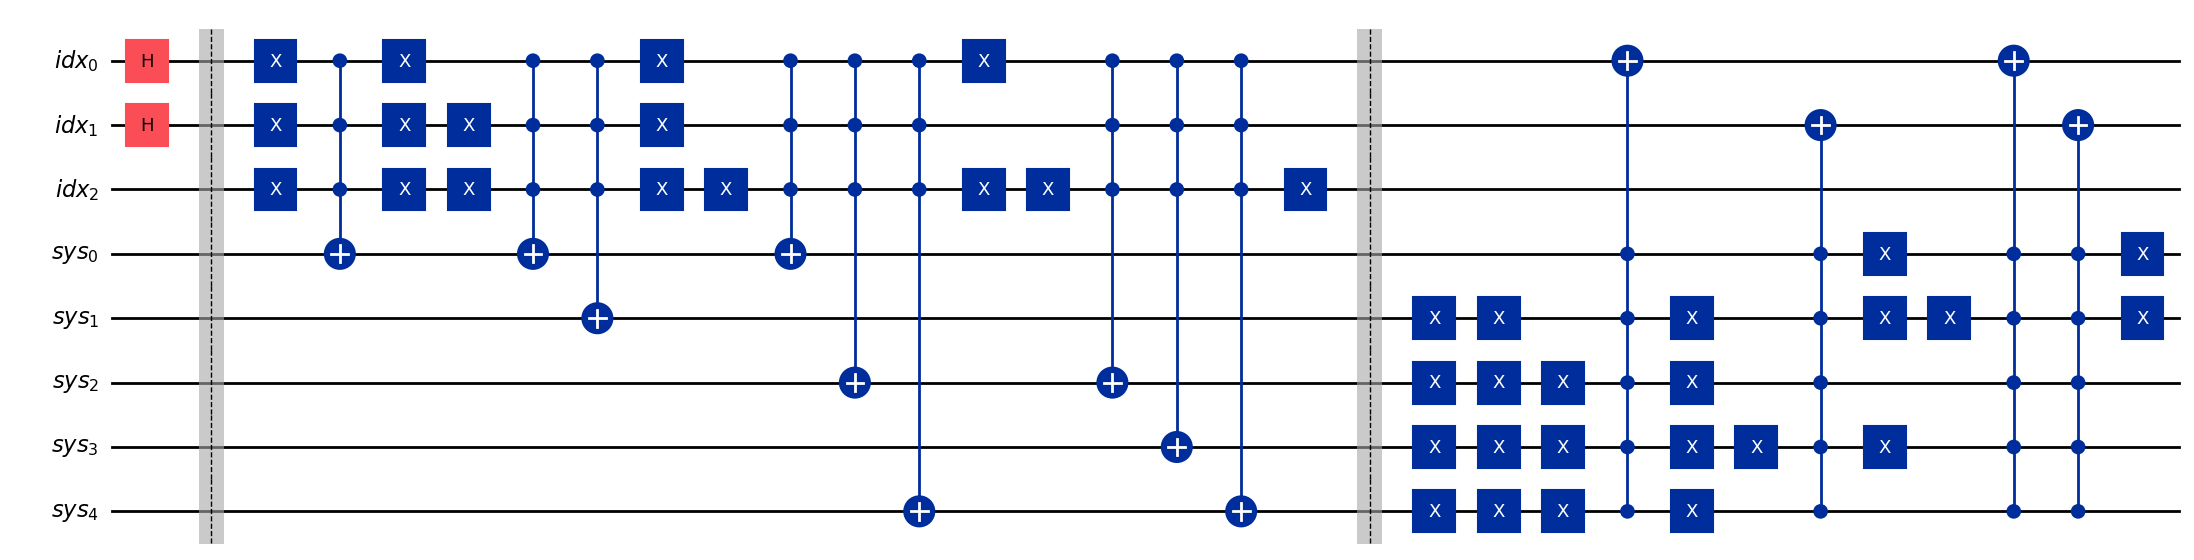

In [23]:
# ============================================================
# Cell 23 : Shock-State Integration
# ============================================================

#
# This cell integrates the sparse shock-state
# preparation machinery into the HHL pipeline.
#
# Goal:
#
#     |0>^n
#
#         -->
#
#     |b>
#
# where
#
#     |b>
#
# is a sparse uniform superposition over the
# shock support.
#
#
# Future extension:
#
#     Read support from CSV.
#
# Current version:
#
#     Hard-coded support list.
#

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector


# ============================================================
# Shock support specification
# ============================================================

USE_SHOCK_CSV = False

SHOCK_CSV_FILE = "shock_support.csv"

#
# Example shock support.
#
# Replace later by CSV loading.
#

SHOCK_SUPPORT = [
    1,
    3,
    21
]

SHOCK_SUPPORT = sorted(
    SHOCK_SUPPORT
)


# ============================================================
# Basic checks
# ============================================================

rho = len(
    SHOCK_SUPPORT
)

assert rho > 0

assert len(
    set(SHOCK_SUPPORT)
) == rho

assert all(
    x in real_node_set
    for x in SHOCK_SUPPORT
), (
    "Shock support must contain "
    "only real bank nodes."
)


# ============================================================
# Support preprocessing
# ============================================================

delta = int(
    2**np.ceil(
        np.log2(rho)
    )
)

assert delta <= gamma, (
    "Increase gamma.\n"
    f"delta = {delta}, "
    f"gamma = {gamma}"
)

t = int(
    np.log2(delta)
)

INDEX_REGISTER_QUBITS = int(
    np.log2(gamma)
)

assert INDEX_REGISTER_QUBITS == n_index_reg, (
    "n_index_reg does not equal gamma. Please verify definition of n_index_reg in code."
)

#
# Dummy nodes already exist in the
# finance graph construction.
#

available_dummies = (
    dummy_nodes.astype(int)
    .tolist()
)

num_dummies = (
    delta - rho
)

assert (
    num_dummies
    <= len(available_dummies)
), (
    "Not enough dummy nodes "
    "available."
)

dummies = (
    available_dummies[:num_dummies]
)

#
# Final support.
#

S = sorted(
    SHOCK_SUPPORT
    + list(dummies)
)

assert len(S) == delta

assert len(set(S)) == delta


# ============================================================
# Helper functions
# ============================================================

def prepare_controls(
    qc,
    register,
    bitstring
):

    for qubit, bit in enumerate(
        reversed(bitstring)
    ):

        if bit == "0":

            qc.x(
                register[qubit]
            )


def unprepare_controls(
    qc,
    register,
    bitstring
):

    for qubit, bit in enumerate(
        reversed(bitstring)
    ):

        if bit == "0":

            qc.x(
                register[qubit]
            )


# ============================================================
# State-preparation circuit builder
# ============================================================

def build_sparse_shock_preparation_circuit(
    support,
    n,
    gamma
):

    rho_local = len(
        support
    )

    delta_local = int(
        2**np.ceil(
            np.log2(rho_local)
        )
    )

    t_local = int(
        np.log2(delta_local)
    )

    p_local = int(
        np.log2(gamma)
    )

    idx = QuantumRegister(
        p_local,
        name="idx"
    )

    sys = QuantumRegister(
        n,
        name="sys"
    )

    qc = QuantumCircuit(
        idx,
        sys,
        name="U_b"
    )

    # --------------------------------------------------------
    # Stage 1
    # --------------------------------------------------------

    for q in range(t_local):

        qc.h(
            idx[q]
        )

    qc.barrier()

    # --------------------------------------------------------
    # Stage 2
    # --------------------------------------------------------

    for j, i_j in enumerate(
        support
    ):

        j_bits = format(
            j,
            f"0{p_local}b"
        )

        i_bits = format(
            i_j,
            f"0{n}b"
        )

        prepare_controls(
            qc,
            idx,
            j_bits
        )

        for sys_qubit, bit in enumerate(
            reversed(i_bits)
        ):

            if bit == "1":

                qc.mcx(
                    list(idx),
                    sys[sys_qubit]
                )

        unprepare_controls(
            qc,
            idx,
            j_bits
        )

    qc.barrier()

    # --------------------------------------------------------
    # Stage 3
    # --------------------------------------------------------

    for j, i_j in enumerate(
        support
    ):

        j_bits = format(
            j,
            f"0{p_local}b"
        )

        i_bits = format(
            i_j,
            f"0{n}b"
        )

        prepare_controls(
            qc,
            sys,
            i_bits
        )

        for idx_qubit, bit in enumerate(
            reversed(j_bits)
        ):

            if bit == "1":

                qc.mcx(
                    list(sys),
                    idx[idx_qubit]
                )

        unprepare_controls(
            qc,
            sys,
            i_bits
        )

    return qc


# ============================================================
# Build shock-state circuit
# ============================================================

STATE_PREP_CIRCUIT = (
    build_sparse_shock_preparation_circuit(
        S,
        n,
        gamma
    )
)


# ============================================================
# Verification
# ============================================================

sv = Statevector.from_instruction(
    STATE_PREP_CIRCUIT
)

state_dict = sv.to_dict()

expected_index = (
    "0" * INDEX_REGISTER_QUBITS
)

expected_amplitude = (
    1 / np.sqrt(delta)
)

observed_support = set()

nonzero_count = 0

for basis_state, amplitude in (
    state_dict.items()
):

    if abs(amplitude) < 1e-10:

        continue

    nonzero_count += 1

    system_bits = (
        basis_state[:-INDEX_REGISTER_QUBITS]
    )

    index_bits = (
        basis_state[-INDEX_REGISTER_QUBITS:]
    )

    system_index = int(
        system_bits,
        2
    )

    observed_support.add(
        system_index
    )

    assert (
        index_bits
        == expected_index
    )

    assert (
        system_index
        in S
    )

    assert np.isclose(
        abs(amplitude),
        expected_amplitude,
        atol=1e-10
    )

assert (
    nonzero_count
    == delta
)

assert (
    observed_support
    == set(S)
)


# ============================================================
# Resource summary
# ============================================================

gate_counts = (
    STATE_PREP_CIRCUIT.count_ops()
)

mcx_count = gate_counts.get(
    "mcx",
    0
)

#
# Exact MCX count implied by the
# circuit construction.
#

exact_mcx_count = (

    sum(
        bin(i).count("1")
        for i in S
    )

    +

    sum(
        bin(j).count("1")
        for j in range(delta)
    )
)

assert (
    exact_mcx_count
    == mcx_count
)

#
# Theoretical upper bound.
#

mcx_upper_bound = (
    delta * n
    +
    delta * INDEX_REGISTER_QUBITS
)


# ============================================================
# Metadata
# ============================================================

STATE_PREP_METADATA = {

    "rho":
        rho,

    "delta":
        delta,

    "gamma":
        gamma,

    "num_dummies":
        num_dummies,

    "support":
        S,

    "depth":
        STATE_PREP_CIRCUIT.depth(),

    "mcx_count":
        mcx_count,

    "mcx_upper_bound":
        mcx_upper_bound
}

B_STATE_SUPPORT = S

B_STATE_RHO = rho

B_STATE_DELTA = delta


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Shock-State Integration")
print("=" * 70)

print()

print(f"Raw support size                : "
      f"{rho}")

print(f"Actual support size             : "
      f"{delta}")

print(f"Number of dummies               : "
      f"{num_dummies}")

print()

print("Final support:")

print(S)

print()

print(
    f"|b> = "
    f"(1/sqrt({delta})) "
    f"sum_(i in S) |i>"
)

print()

print("Verification:")

print(
    f"  Support verified              : True"
)

print(
    f"  Uniform amplitudes verified   : True"
)

print(
    f"  Index disentangled            : True"
)

print()

print("Resources:")

print(
    f"  Circuit depth                 : "
    f"{STATE_PREP_CIRCUIT.depth()}"
)

print(
    f"  Exact MCX count               : "
    f"{mcx_count}"
)

print(
    f"  MCX upper bound               : "
    f"{mcx_upper_bound}"
)

print()

print(
    "Exported objects:"
)

print(
    "  STATE_PREP_CIRCUIT"
)

print(
    "  STATE_PREP_METADATA"
)

print(
    "  B_STATE_SUPPORT"
)

print(
    "  B_STATE_RHO"
)

print(
    "  B_STATE_DELTA"
)

print()

print("=" * 70)

#
# Optional visualization.
#

display(
    STATE_PREP_CIRCUIT.draw(
        "mpl",
        fold=-1
    )
)

In [24]:
# ============================================================
# Cell 24 : State-Preparation Abstraction Layer
# ============================================================

#
# This cell promotes the verified sparse
# shock-state preparation circuit into a
# reusable HHL primitive.
#
#
# Logical action:
#
#     U_b :
#
#         |0>_idx |0>_sys
#
#             -->
#
#         |0>_idx |b>_sys
#
#
# The index register is disentangled at
# the output but remains physically
# allocated throughout the HHL circuit.
#
#
# Cell 23 verified correctness.
#
# This cell merely packages the circuit
# for later use.
#

from qiskit.circuit import Gate


# ============================================================
# Remove barriers for gate conversion
# ============================================================

#
# Keep the original circuit untouched.
#

STATE_PREP_CIRCUIT_NO_BARRIERS = (
    STATE_PREP_CIRCUIT.copy()
)

STATE_PREP_CIRCUIT_NO_BARRIERS.data = [

    instruction

    for instruction
    in STATE_PREP_CIRCUIT_NO_BARRIERS.data

    if instruction.operation.name
    != "barrier"
]


# ============================================================
# Create reusable gates
# ============================================================

UB_GATE = (
    STATE_PREP_CIRCUIT_NO_BARRIERS
    .to_gate(
        label="U_b"
    )
)

UB_DAGGER_GATE = (
    UB_GATE.inverse()
)


# ============================================================
# Register requirements
# ============================================================

UB_INDEX_QUBITS = (
    INDEX_REGISTER_QUBITS
)

UB_SYSTEM_QUBITS = (
    n
)

UB_TOTAL_QUBITS = (

    UB_INDEX_QUBITS

    +

    UB_SYSTEM_QUBITS
)


# ============================================================
# Resource accounting
# ============================================================

#
# Resource counts are taken from the
# original circuit (including barriers
# in depth accounting exactly as built).
#

UB_DEPTH = (
    STATE_PREP_CIRCUIT.depth()
)

UB_GATE_COUNTS = (
    STATE_PREP_CIRCUIT.count_ops()
)

UB_MCX_COUNT = (
    UB_GATE_COUNTS.get(
        "mcx",
        0
    )
)

UB_H_COUNT = (
    UB_GATE_COUNTS.get(
        "h",
        0
    )
)

UB_X_COUNT = (
    UB_GATE_COUNTS.get(
        "x",
        0
    )
)


# ============================================================
# Consistency checks
# ============================================================

assert (
    UB_TOTAL_QUBITS
    ==
    STATE_PREP_CIRCUIT.num_qubits
), (
    "U_b qubit count mismatch."
)

assert (
    B_STATE_DELTA
    <= gamma
)

assert (
    len(B_STATE_SUPPORT)
    == B_STATE_DELTA
)


# ============================================================
# Specification dictionary
# ============================================================

UB_SPECIFICATION = {

    "index_qubits":
        UB_INDEX_QUBITS,

    "system_qubits":
        UB_SYSTEM_QUBITS,

    "total_qubits":
        UB_TOTAL_QUBITS,

    "support_size":
        B_STATE_RHO,

    "padded_support_size":
        B_STATE_DELTA,

    "support":
        B_STATE_SUPPORT,

    "depth":
        UB_DEPTH,

    "mcx_count":
        UB_MCX_COUNT,

    "h_count":
        UB_H_COUNT,

    "x_count":
        UB_X_COUNT,

    "implements_inverse":
        True,

    "output_state":
        "|b>"
}


# ============================================================
# Export objects
# ============================================================

STATE_PREPARATION_SPEC = (
    UB_SPECIFICATION
)

#
# Main exported primitives:
#
#     UB_GATE
#     UB_DAGGER_GATE
#     STATE_PREPARATION_SPEC
#


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("State-Preparation Abstraction Layer")
print("=" * 70)

print()

print("Logical action:")

print()

print(
    "|0>_idx |0>_sys"
)

print(
    "    -->"
)

print(
    "|0>_idx |b>_sys"
)

print()

print("Register requirements:")

print()

print(
    f"Index qubits                   : "
    f"{UB_INDEX_QUBITS}"
)

print(
    f"System qubits                  : "
    f"{UB_SYSTEM_QUBITS}"
)

print(
    f"Total qubits                   : "
    f"{UB_TOTAL_QUBITS}"
)

print()

print("Shock-state information:")

print()

print(
    f"Raw support size               : "
    f"{B_STATE_RHO}"
)

print(
    f"Padded support size            : "
    f"{B_STATE_DELTA}"
)

print()

print("Resources:")

print()

print(
    f"Circuit depth                  : "
    f"{UB_DEPTH}"
)

print(
    f"Hadamards                      : "
    f"{UB_H_COUNT}"
)

print(
    f"X gates                        : "
    f"{UB_X_COUNT}"
)

print(
    f"MCX gates                      : "
    f"{UB_MCX_COUNT}"
)

print()

print(
    "Inverse available              : True"
)

print()

print("Exported objects:")

print(
    "  UB_GATE"
)

print(
    "  UB_DAGGER_GATE"
)

print(
    "  STATE_PREPARATION_SPEC"
)

print()

print("=" * 70)


State-Preparation Abstraction Layer

Logical action:

|0>_idx |0>_sys
    -->
|0>_idx |b>_sys

Register requirements:

Index qubits                   : 3
System qubits                  : 5
Total qubits                   : 8

Shock-state information:

Raw support size               : 3
Padded support size            : 4

Resources:

Circuit depth                  : 30
Hadamards                      : 2
X gates                        : 38
MCX gates                      : 13

Inverse available              : True

Exported objects:
  UB_GATE
  UB_DAGGER_GATE
  STATE_PREPARATION_SPEC



In [25]:
# ============================================================
# Cell 25 : QPE Specification for Qubitization-HHL
# ============================================================

#
# Goal:
#
#     Define the Quantum Phase Estimation
#     architecture used by qubitization-based HHL.
#
#
# QPE is applied to:
#
#     W
#
# whose eigenvalues are
#
#     exp(+i theta_j)
#
# and
#
#     exp(-i theta_j)
#
# with
#
#     cos(theta_j)
#
#         =
#
#     lambda_j / alpha_A.
#
#
# QPE estimates:
#
#     phi_j
#
#         =
#
#     theta_j / (2*pi)
#
#
# where
#
#     phi_j in (-1/2, 1/2].
#
#
# The phase register therefore stores
# a signed fixed-point approximation
# to phi_j.
#

# ============================================================
# Signed phase convention
# ============================================================

QPE_PHASE_INTERVAL = (
    -0.5,
    +0.5
)

#
# Positive spectral phases
# already computed in Cell 20.
#

QPE_POSITIVE_PHASE_LOWER = (
    PHASE_POSITIVE_LOWER
)

QPE_POSITIVE_PHASE_UPPER = (
    PHASE_POSITIVE_UPPER
)

QPE_NEGATIVE_PHASE_LOWER = (
    -PHASE_POSITIVE_UPPER
)

QPE_NEGATIVE_PHASE_UPPER = (
    -PHASE_POSITIVE_LOWER
)


# ============================================================
# QPE precision
# ============================================================

QPE_PHASE_PRECISION = (
    EPSILON_QPE_PHASE
)

QPE_PHASE_QUBITS = (
    m_HHL
)


# ============================================================
# Powers of W required by QPE
# ============================================================

QPE_POWER_LIST = [

    2**k

    for k in range(
        QPE_PHASE_QUBITS
    )
]


# ============================================================
# Total W applications
# ============================================================

#
# QPE applies
#
#     W^(2^0)
#     W^(2^1)
#     ...
#     W^(2^(m-1))
#
# where m = m_HHL
# 
# Therefore:
#
#     total W calls
#
#         =
#
#     1 + 2 + ... + 2^(m-1)
#
#         =
#
#     2^m - 1
#

TOTAL_W_CALLS_QPE = (

    2**QPE_PHASE_QUBITS

    - 1
)


# ============================================================
# Oracle accounting
# ============================================================

#
# One W invocation uses:
#
#     PREPARE
#     SELECT
#     PREPARE†
#     R
#
# Therefore:
#
#     PREPARE calls
#         = 2 per W
#
#     SELECT calls
#         = 1 per W
#
#     R calls
#         = 1 per W
#

TOTAL_PREPARE_CALLS_QPE = (

    2
    *
    TOTAL_W_CALLS_QPE
)

TOTAL_SELECT_CALLS_QPE = (

    TOTAL_W_CALLS_QPE
)

TOTAL_REFLECTION_CALLS_QPE = (

    TOTAL_W_CALLS_QPE
)


# ============================================================
# Complexity model
# ============================================================

#
# Under the sparse-oracle assumptions:
#
#     Cost(PREPARE)
#         = polylog(N)
#
#     Cost(SELECT)
#         = polylog(N)
#
#     Cost(R)
#         = polylog(N)
#
# Therefore:
#
#     Cost(W)
#         = polylog(N)
#
# and
#
#     Cost(QPE)
#
#         =
#
#     (2^m - 1)
#     polylog(N)
#

QPE_COMPLEXITY_MODEL = {

    "cost_W":
        "polylog(N)",

    "cost_QPE":
    (
        "(2^m_HHL - 1) * polylog(N) "
        "= O((1/EPSILON_QPE_PHASE) * polylog(N)) "
        "= O(kappa^2 * polylog(N)) "
        "\n              [for the phase-precision rule used in this notebook]"
    )
}


# ============================================================
# Specification dictionary
# ============================================================

QPE_SPECIFICATION = {

    "phase_interval":
        QPE_PHASE_INTERVAL,

    "positive_phase_lower":
        QPE_POSITIVE_PHASE_LOWER,

    "positive_phase_upper":
        QPE_POSITIVE_PHASE_UPPER,

    "negative_phase_lower":
        QPE_NEGATIVE_PHASE_LOWER,

    "negative_phase_upper":
        QPE_NEGATIVE_PHASE_UPPER,

    "phase_precision":
        QPE_PHASE_PRECISION,

    "phase_qubits":
        QPE_PHASE_QUBITS,

    "powers":
        QPE_POWER_LIST,

    "total_W_calls":
        TOTAL_W_CALLS_QPE,

    "total_prepare_calls":
        TOTAL_PREPARE_CALLS_QPE,

    "total_select_calls":
        TOTAL_SELECT_CALLS_QPE,

    "total_reflection_calls":
        TOTAL_REFLECTION_CALLS_QPE
}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("QPE Specification for Qubitization-HHL")
print("=" * 70)

print()

print("Phase convention:")

print()

print(
    "phi = theta / (2*pi)"
)

print()

print(
    f"Signed phase interval           : "
    f"({QPE_PHASE_INTERVAL[0]}, "
    f"{QPE_PHASE_INTERVAL[1]}]"
)

print()

print(
    f"Positive phase lower bound      : "
    f"{QPE_POSITIVE_PHASE_LOWER:.12f}"
)

print(
    f"Positive phase upper bound      : "
    f"{QPE_POSITIVE_PHASE_UPPER:.12f}"
)

print()

print(
    f"Negative phase lower bound      : "
    f"{QPE_NEGATIVE_PHASE_LOWER:.12f}"
)

print(
    f"Negative phase upper bound      : "
    f"{QPE_NEGATIVE_PHASE_UPPER:.12f}"
)

print()

print(
    f"Phase precision target          : "
    f"{QPE_PHASE_PRECISION:.2e}"
)

print()

print(
    f"Phase register qubits           : "
    f"{QPE_PHASE_QUBITS}"
)

print()

print(
    f"Total W calls                   : "
    f"{TOTAL_W_CALLS_QPE}"
)

print(
    f"Total PREPARE calls             : "
    f"{TOTAL_PREPARE_CALLS_QPE}"
)

print(
    f"Total SELECT calls              : "
    f"{TOTAL_SELECT_CALLS_QPE}"
)

print(
    f"Total reflection calls          : "
    f"{TOTAL_REFLECTION_CALLS_QPE}"
)

print()

print(
    "Complexity model:"
)

print(
    f"  Cost(W)   = "
    f"{QPE_COMPLEXITY_MODEL['cost_W']}"
)

print(
    f"  Cost(QPE) = "
    f"{QPE_COMPLEXITY_MODEL['cost_QPE']}"
)

print()

print("Exported objects:")

print(
    "  QPE_POWER_LIST"
)

print(
    "  QPE_SPECIFICATION"
)

print(
    "  TOTAL_W_CALLS_QPE"
)

print()

print("=" * 70)


QPE Specification for Qubitization-HHL

Phase convention:

phi = theta / (2*pi)

Signed phase interval           : (-0.5, 0.5]

Positive phase lower bound      : 0.184505059790
Positive phase upper bound      : 0.234057859787

Negative phase lower bound      : -0.234057859787
Negative phase upper bound      : -0.184505059790

Phase precision target          : 1.00e-03

Phase register qubits           : 10

Total W calls                   : 1023
Total PREPARE calls             : 2046
Total SELECT calls              : 1023
Total reflection calls          : 1023

Complexity model:
  Cost(W)   = polylog(N)
  Cost(QPE) = (2^m_HHL - 1) * polylog(N) = O((1/EPSILON_QPE_PHASE) * polylog(N)) = O(kappa^2 * polylog(N)) 
              [for the phase-precision rule used in this notebook]

Exported objects:
  QPE_POWER_LIST
  QPE_SPECIFICATION
  TOTAL_W_CALLS_QPE



In [26]:
# ============================================================
# Cell 26 : QPE Circuit Architecture
# ============================================================

from qiskit import QuantumCircuit


# ============================================================
# Controlled-W specification
# ============================================================

#
# These are logical placeholders.
#
# Actual implementation uses repeated
# oracle access to W.
#

CONTROLLED_W_POWERS = [

    {
        "power": power,
        "label": f"CW^{power}"
    }

    for power in QPE_POWER_LIST
]


# ============================================================
# QPE architecture
# ============================================================

QPE_ARCHITECTURE = {

    "phase_register":
        "phase",

    "target_registers": [

        "prepare",
        "row",
        "system"
    ],

    "steps": [

        "Hadamards on phase register",

        "Controlled-W powers",

        "Inverse QFT"
    ],

    "controlled_powers":
        CONTROLLED_W_POWERS
}


# ============================================================
# IQPE architecture
# ============================================================

IQPE_ARCHITECTURE = {

    "steps": [

        "QFT",

        "Inverse controlled-W powers",

        "Hadamards on phase register"
    ]
}


# ============================================================
# Resource accounting
# ============================================================

QPE_RESOURCE_SUMMARY = {

    "phase_qubits":
        m_HHL,

    "controlled_W_blocks":
        len(QPE_POWER_LIST),

    "total_W_calls":
        TOTAL_W_CALLS_QPE,

    "total_prepare_calls":
        TOTAL_PREPARE_CALLS_QPE,

    "total_select_calls":
        TOTAL_SELECT_CALLS_QPE
}


# ============================================================
# Debug helper
# ============================================================

def show_top_amplitudes(
    statevector,
    k=10
):

    amplitudes = []

    for index, amp in enumerate(
        statevector
    ):

        if abs(amp) > 1e-12:

            amplitudes.append(
                (abs(amp), index, amp)
            )

    amplitudes.sort(
        reverse=True
    )

    print(
        f"\nTop {k} amplitudes:\n"
    )

    for magnitude, index, amp in amplitudes[:k]:

        print(
            f"{index:>8d}   "
            f"{amp}"
        )


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("QPE Circuit Architecture")
print("=" * 70)

print()

print(
    "Target operator:"
)

print()

print(
    "    W"
)

print()

print(
    "Estimated quantity:"
)

print()

print(
    "    phi = theta / (2*pi)"
)

print()

print(
    "QPE stages:"
)

for step in QPE_ARCHITECTURE["steps"]:

    print(
        f"  - {step}"
    )

print()

print(
    "Controlled powers:"
)

for power in QPE_POWER_LIST:

    print(
        f"  W^{power}"
    )

print()

print(
    f"Phase qubits                : "
    f"{m_HHL}"
)

print()

print(
    f"Total W calls               : "
    f"{TOTAL_W_CALLS_QPE}"
)

print(
    f"Total PREPARE calls         : "
    f"{TOTAL_PREPARE_CALLS_QPE}"
)

print(
    f"Total SELECT calls          : "
    f"{TOTAL_SELECT_CALLS_QPE}"
)

print()

print(
    "Exported objects:"
)

print(
    "  QPE_ARCHITECTURE"
)

print(
    "  IQPE_ARCHITECTURE"
)

print(
    "  QPE_RESOURCE_SUMMARY"
)

print()

print("=" * 70)


QPE Circuit Architecture

Target operator:

    W

Estimated quantity:

    phi = theta / (2*pi)

QPE stages:
  - Hadamards on phase register
  - Controlled-W powers
  - Inverse QFT

Controlled powers:
  W^1
  W^2
  W^4
  W^8
  W^16
  W^32
  W^64
  W^128
  W^256
  W^512

Phase qubits                : 10

Total W calls               : 1023
Total PREPARE calls         : 2046
Total SELECT calls          : 1023

Exported objects:
  QPE_ARCHITECTURE
  IQPE_ARCHITECTURE
  QPE_RESOURCE_SUMMARY



In [27]:
# ============================================================
# Cell 27 : Chebyshev Evaluation Architecture
# ============================================================

#
# Goal:
#
#     Reversibly evaluate
#
#         omega(phi)
#
#     =
#
#         arcsin(
#             C_HHL
#             /
#             (
#                 alpha_A
#                 cos(2*pi*phi)
#             )
#         )
#
# using the Chebyshev polynomial
#
#     P_d(phi).
#
#
# Input:
#
#     |phi>|0>|0>
#
#         ->
#
#     |phi>
#     |P_d(phi)>
#     |workspace>
#
#
# where
#
#     phi in (-1/2, 1/2]
#
# is stored in the QPE phase register.
#
#
# IMPORTANT:
#
# We do NOT construct a |phi| register.
#
# Since:
#
#     omega(-phi)
#         =
#     omega(phi)
#
# the target function is even.
#
# The polynomial is evaluated directly
# on the signed phase register.
#

# ============================================================
# Function specification
# ============================================================

CHEBYSHEV_FUNCTION_SPEC = {

    "function_name":
        "omega(phi)",

    "definition":
        (
            "arcsin("
            "C_HHL / "
            "(alpha_A*cos(2*pi*phi))"
            ")"
        ),

    "input_variable":
        "phi",

    "input_interval":
        (-0.5, 0.5),

    "approximation_domain":
        cheb_domain,

    "degree":
        chebyshev_degree,

    "epsilon_cheb":
        EPSILON_CHEB
}


# ============================================================
# Register semantics
# ============================================================

CHEBYSHEV_REGISTERS = {

    "input_register":
        "phase",

    "output_register":
        "poly",

    "workspace_register":
        "workspace",

    "input_qubits":
        m_HHL,

    "output_qubits":
        n_poly_output,

    "workspace_qubits":
        n_workspace_poly
}


# ============================================================
# Logical reversible map
# ============================================================

CHEBYSHEV_EVALUATION_ARCHITECTURE = {

    "input_state":

        "|phi>|0>|0>",

    "output_state":

        "|phi>|P_d(phi)>|workspace>",

    "inverse_available":

        True,

    "requires_absolute_value_register":

        False,

    "uses_signed_phase_directly":

        True
}


# ============================================================
# Polynomial evaluation block
# ============================================================

#
# Abstract reversible block.
#
# Actual arithmetic implementation
# (adders, multipliers, Horner scheme,
# Clenshaw recurrence, etc.)
# is intentionally postponed.
#

POLYNOMIAL_EVALUATION_BLOCK = {

    "name":

        "P_d",

    "degree":

        chebyshev_degree,

    "input":

        "phase register",

    "output":

        "poly register",

    "workspace":

        "workspace register",

    "implements":

        "|phi>|0> -> |phi>|P_d(phi)>"
}


# ============================================================
# Complexity model
# ============================================================

#
# For analytic functions,
#
#     d
#
#         =
#
#     O(log(1/epsilon_cheb))
#
# and reversible evaluation costs
# approximately:
#
#     O(d)
#
# arithmetic stages.
#

CHEBYSHEV_COMPLEXITY = {

    "degree":

        chebyshev_degree,

    "epsilon_cheb":

        EPSILON_CHEB,

    "asymptotic_degree":

        "O(log(1/EPSILON_CHEB))",

    "evaluation_cost":
    (
        "O(degree * fixed_point_precision)"
    ),

    "dominates_HHL_runtime":

        False
}


# ============================================================
# Resource summary
# ============================================================

CHEBYSHEV_RESOURCE_SUMMARY = {

    "degree":
        chebyshev_degree,

    "poly_output_qubits":
        n_poly_output,

    "workspace_qubits":
        n_workspace_poly,

    "epsilon_cheb":
        EPSILON_CHEB
}


# ============================================================
# Export objects
# ============================================================

#
# Main exported objects:
#
#     CHEBYSHEV_FUNCTION_SPEC
#
#     CHEBYSHEV_REGISTERS
#
#     CHEBYSHEV_EVALUATION_ARCHITECTURE
#
#     POLYNOMIAL_EVALUATION_BLOCK
#

# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Chebyshev Evaluation Architecture")
print("=" * 70)

print()

print("Target function:")

print()

print(
    "omega(phi)"
)

print(
    "    ="
)

print(
    "arcsin("
    "C_HHL / "
    "(alpha_A*cos(2*pi*phi))"
    ")"
)

print()

print("Registers:")

print()

print(
    f"Phase register                 : "
    f"{m_HHL} qubits"
)

print(
    f"Polynomial register            : "
    f"{n_poly_output} qubits"
)

print(
    f"Workspace register             : "
    f"{n_workspace_poly} qubits"
)

print()

print("Approximation:")

print()

print(
    f"Chebyshev degree               : "
    f"{chebyshev_degree}"
)

print(
    f"Target error                   : "
    f"{EPSILON_CHEB:.2e}"
)

print()

print(
    f"Domain lower bound             : "
    f"{cheb_domain[0]:.12f}"
)

print(
    f"Domain upper bound             : "
    f"{cheb_domain[1]:.12f}"
)

print()

print("Logical map:")

print()

print(
    "|phi>|0>|0>"
)

print(
    "    -->"
)

print(
    "|phi>|P_d(phi)>|workspace>"
)

print()

print(
    "Absolute-value register needed : "
    "False"
)

print(
    "Signed phase used directly     : "
    "True"
)

print()

print("Complexity:")

print()

print(
    f"Degree scaling                 : "
    f"{CHEBYSHEV_COMPLEXITY['asymptotic_degree']}"
)

print(
    f"Evaluation cost                : "
    f"{CHEBYSHEV_COMPLEXITY['evaluation_cost']}"
)

print(
    f"Dominates HHL runtime          : "
    f"{CHEBYSHEV_COMPLEXITY['dominates_HHL_runtime']}"
)

print()

print("Exported objects:")

print(
    "  CHEBYSHEV_FUNCTION_SPEC"
)

print(
    "  CHEBYSHEV_REGISTERS"
)

print(
    "  CHEBYSHEV_EVALUATION_ARCHITECTURE"
)

print(
    "  POLYNOMIAL_EVALUATION_BLOCK"
)

print()

print("=" * 70)


Chebyshev Evaluation Architecture

Target function:

omega(phi)
    =
arcsin(C_HHL / (alpha_A*cos(2*pi*phi)))

Registers:

Phase register                 : 10 qubits
Polynomial register            : 7 qubits
Workspace register             : 37 qubits

Approximation:

Chebyshev degree               : 30
Target error                   : 1.00e-02

Domain lower bound             : -0.234857253379
Domain upper bound             : 0.234857253379

Logical map:

|phi>|0>|0>
    -->
|phi>|P_d(phi)>|workspace>

Absolute-value register needed : False
Signed phase used directly     : True

Complexity:

Degree scaling                 : O(log(1/EPSILON_CHEB))
Evaluation cost                : O(degree * fixed_point_precision)
Dominates HHL runtime          : False

Exported objects:
  CHEBYSHEV_FUNCTION_SPEC
  CHEBYSHEV_REGISTERS
  CHEBYSHEV_EVALUATION_ARCHITECTURE
  POLYNOMIAL_EVALUATION_BLOCK



In [28]:
# ============================================================
# Cell 28 : Controlled Rotation Architecture
# ============================================================

#
# Goal:
#
#     Convert the Chebyshev-computed
#     rotation angle
#
#         omega(phi)
#
# into the HHL reciprocal encoding
# stored in the rotation ancilla.
#
#
# We have:
#
#     omega(phi)
#
#         =
#
#     arcsin(
#         C_HHL / lambda
#     )
#
#
# Therefore:
#
#     sin(omega)
#
#         =
#
#     C_HHL / lambda
#
#
# Applying:
#
#     Ry(2*omega)
#
# to |0> gives:
#
#     cos(omega)|0>
#         +
#     sin(omega)|1>
#
#
# Thus:
#
#     amplitude(|1>)
#
#         =
#
#     C_HHL / lambda
#
#
# which is precisely the reciprocal
# encoding required by HHL.
#

# ============================================================
# Rotation ancilla specification
# ============================================================

ROTATION_ANCILLA_SPEC = {

    "register_name":
        "rotation",

    "qubits":
        1,

    "initial_state":
        "|0>",

    "post_rotation_state":

        (
            "cos(omega)|0> + "
            "sin(omega)|1>"
        )
}


# ============================================================
# Controlled rotation block
# ============================================================

#
# Abstract reversible block.
#
# Input:
#
#     |omega>|0>
#
# Output:
#
#     |omega>
#
#     (
#         cos(omega)|0>
#             +
#         sin(omega)|1>
#     )
#

CONTROLLED_ROTATION_BLOCK = {

    "name":

        "CRY",

    "input":

        "|omega>|0>",

    "output":

        (
            "|omega>"
            "("
            "cos(omega)|0>"
            "+"
            "sin(omega)|1>"
            ")"
        ),

    "rotation":

        "Ry(2*omega)",

    "control_register":

        "poly",

    "target_register":

        "rotation"
}


# ============================================================
# Success probability analysis
# ============================================================

#
# Since:
#
#     sin(omega)
#
#         =
#
#     C_HHL / lambda
#
#
# Success probability:
#
#     P_success
#
#         =
#
#     (C_HHL/lambda)^2
#

ROTATION_SUCCESS_PROBABILITY = {

    "formula":

        "(C_HHL / lambda)^2",

    "minimum":

        (
            C_HHL
            /
            LAMBDA_BOUND_UPPER
        )**2,

    "maximum":

        (
            C_HHL
            /
            LAMBDA_BOUND_LOWER
        )**2
}


# ============================================================
# Resource model
# ============================================================

#
# The controlled rotation acts on:
#
#     poly register
#
# and
#
#     rotation ancilla.
#
#
# Relative to QPE this cost is small.
#

ROTATION_RESOURCE_SUMMARY = {

    "poly_qubits":

        n_poly_output,

    "rotation_qubits":

        1,

    "cost_model":

        "O(poly_output_precision)",

    "dominates_HHL_runtime":

        False
}


# ============================================================
# Logical transformation
# ============================================================

ROTATION_LOGICAL_MAP = {

    "before":

        "|phi>|omega>|0>",

    "after":

        (
            "|phi>|omega>"
            "("
            "cos(omega)|0>"
            "+"
            "sin(omega)|1>"
            ")"
        )
}


# ============================================================
# Export objects
# ============================================================

#
# Main exported objects:
#
#     ROTATION_ANCILLA_SPEC
#
#     CONTROLLED_ROTATION_BLOCK
#
#     ROTATION_SUCCESS_PROBABILITY
#
#     ROTATION_RESOURCE_SUMMARY
#

# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Controlled Rotation Architecture")
print("=" * 70)

print()

print("Rotation angle:")

print()

print(
    "omega(phi)"
)

print(
    "    ="
)

print(
    "arcsin(C_HHL / lambda)"
)

print()

print("Controlled rotation:")

print()

print(
    "|omega>|0>"
)

print(
    "    -->"
)

print(
    "|omega>"
    "("
    "cos(omega)|0>"
    "+"
    "sin(omega)|1>"
    ")"
)

print()

print(
    "Applied gate:"
)

print()

print(
    "Ry(2*omega)"
)

print()

print(
    "Reciprocal encoding:"
)

print()

print(
    "sin(omega)"
)

print(
    "    ="
)

print(
    "C_HHL / lambda"
)

print()

print(
    "Success probability:"
)

print()

print(
    "P_success"
)

print(
    "    ="
)

print(
    "(C_HHL / lambda)^2"
)

print()

print(
    f"Minimum success probability    : "
    f"{ROTATION_SUCCESS_PROBABILITY['minimum']:.8f}"
)

print(
    f"Maximum success probability    : "
    f"{ROTATION_SUCCESS_PROBABILITY['maximum']:.8f}"
)

print()

print("Resources:")

print()

print(
    f"Polynomial register qubits     : "
    f"{n_poly_output}"
)

print(
    f"Rotation ancilla qubits        : "
    f"{1}"
)

print()

print(
    f"Cost model                     : "
    f"{ROTATION_RESOURCE_SUMMARY['cost_model']}"
)

print(
    f"Dominates HHL runtime          : "
    f"{ROTATION_RESOURCE_SUMMARY['dominates_HHL_runtime']}"
)

print()

print("Exported objects:")

print()

print(
    "  ROTATION_ANCILLA_SPEC"
)

print(
    "  CONTROLLED_ROTATION_BLOCK"
)

print(
    "  ROTATION_SUCCESS_PROBABILITY"
)

print(
    "  ROTATION_RESOURCE_SUMMARY"
)

print()

print("=" * 70)


Controlled Rotation Architecture

Rotation angle:

omega(phi)
    =
arcsin(C_HHL / lambda)

Controlled rotation:

|omega>|0>
    -->
|omega>(cos(omega)|0>+sin(omega)|1>)

Applied gate:

Ry(2*omega)

Reciprocal encoding:

sin(omega)
    =
C_HHL / lambda

Success probability:

P_success
    =
(C_HHL / lambda)^2

Minimum success probability    : 0.05062500
Maximum success probability    : 0.81000000

Resources:

Polynomial register qubits     : 7
Rotation ancilla qubits        : 1

Cost model                     : O(poly_output_precision)
Dominates HHL runtime          : False

Exported objects:

  ROTATION_ANCILLA_SPEC
  CONTROLLED_ROTATION_BLOCK
  ROTATION_SUCCESS_PROBABILITY
  ROTATION_RESOURCE_SUMMARY



In [29]:
# ============================================================
# Cell 29 : Polynomial Uncomputation Architecture
# ============================================================

#
# Goal:
#
#     Remove the polynomial and workspace
#     registers after the controlled rotation.
#
#
# Apply:
#
#     P_d†
#
# to reverse the computation performed
# in Cell 27.
#
#
# Logical effect:
#
#     |phi>
#     |omega(phi)>
#     |workspace>
#     |rot>
#
#         -->
#
#     |phi>
#     |0>
#     |0>
#     |rot>
#
#
# The rotation ancilla is untouched.
#

# ============================================================
# Uncomputation block
# ============================================================

POLYNOMIAL_UNCOMPUTATION_BLOCK = {

    "name":

        "P_d†",

    "inverse_of":

        "P_d",

    "acts_on":

        [
            "phase",
            "poly",
            "workspace"
        ],

    "leaves_unchanged":

        [
            "system",
            "rotation"
        ]
}


# ============================================================
# Logical map
# ============================================================

POLYNOMIAL_UNCOMPUTATION_MAP = {

    "before":

        (
            "|phi>"
            "|omega(phi)>"
            "|workspace>"
            "|rot>"
        ),

    "after":

        (
            "|phi>"
            "|0>"
            "|0>"
            "|rot>"
        )
}


# ============================================================
# Resource accounting
# ============================================================

CHEBYSHEV_TOTAL_COST = {

    "forward_evaluation":

        "1 * P_d",

    "inverse_evaluation":

        "1 * P_d†",

    "total_evaluations":

        2,

    "degree":

        chebyshev_degree,

    "epsilon_cheb":

        EPSILON_CHEB
}


# ============================================================
# Export objects
# ============================================================

#
# Main exported objects:
#
#     POLYNOMIAL_UNCOMPUTATION_BLOCK
#     POLYNOMIAL_UNCOMPUTATION_MAP
#     CHEBYSHEV_TOTAL_COST
#

# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Polynomial Uncomputation Architecture")
print("=" * 70)

print()

print("Operation:")

print()

print(
    "Apply P_d†"
)

print()

print("Logical map:")

print()

print(
    "|phi>|omega(phi)>|workspace>|rot>"
)

print(
    "    -->"
)

print(
    "|phi>|0>|0>|rot>"
)

print()

print(
    f"Chebyshev degree               : "
    f"{chebyshev_degree}"
)

print(
    f"Chebyshev error                : "
    f"{EPSILON_CHEB:.2e}"
)

print()

print(
    "Polynomial register reset      : True"
)

print(
    "Workspace register reset       : True"
)

print(
    "Rotation ancilla preserved     : True"
)

print()

print("Exported objects:")

print(
    "  POLYNOMIAL_UNCOMPUTATION_BLOCK"
)

print(
    "  POLYNOMIAL_UNCOMPUTATION_MAP"
)

print(
    "  CHEBYSHEV_TOTAL_COST"
)

print()

print("=" * 70)


Polynomial Uncomputation Architecture

Operation:

Apply P_d†

Logical map:

|phi>|omega(phi)>|workspace>|rot>
    -->
|phi>|0>|0>|rot>

Chebyshev degree               : 30
Chebyshev error                : 1.00e-02

Polynomial register reset      : True
Workspace register reset       : True
Rotation ancilla preserved     : True

Exported objects:
  POLYNOMIAL_UNCOMPUTATION_BLOCK
  POLYNOMIAL_UNCOMPUTATION_MAP
  CHEBYSHEV_TOTAL_COST



In [30]:
# ============================================================
# Cell 30 : Inverse QPE Architecture
# ============================================================

#
# Goal:
#
#     Remove the phase register by applying
#     the inverse of the QPE block defined
#     in Cells 25-26.
#
#
# Before IQPE:
#
#     system
#     phase
#     rotation
#
# are still entangled through the
# reciprocal encoding.
#
#
# Applying:
#
#     QPE†
#
# removes the phase information and
# restores the phase register to |0>.
#
#
# This is the final major uncomputation
# step of HHL.
#

# ============================================================
# IQPE block
# ============================================================

INVERSE_QPE_BLOCK = {

    "name":

        "QPE†",

    "inverse_of":

        "QPE",

    "acts_on":

        [
            "prepare",
            "row",
            "system",
            "phase"
        ],

    "leaves_unchanged":

        [
            "index",
            "rotation"
        ]
}


# ============================================================
# Logical map
# ============================================================

IQPE_LOGICAL_MAP = {

    "before":

        (
            "|u_j>"
            "|phi_j>"
            "|rot>"
        ),

    "after":

        (
            "|u_j>"
            "|0>"
            "|rot>"
        )
}


# ============================================================
# Resource accounting
# ============================================================

IQPE_RESOURCE_SUMMARY = {

    "phase_qubits":

        m_HHL,

    "inverse_of":

        "Cell 26 QPE",

    "total_W_calls":

        TOTAL_W_CALLS_QPE,

    "cost":

        QPE_COMPLEXITY_MODEL[
            "cost_QPE"
        ]
}


# ============================================================
# Registers remaining after IQPE
# ============================================================

POST_IQPE_INFORMATION_REGISTERS = [

    "system",
    "rotation"
]

POST_IQPE_RESET_REGISTERS = [

    "index",
    "prepare",
    "row",
    "phase",
    "poly",
    "workspace"
]


# ============================================================
# Export objects
# ============================================================

#
# Main exported objects:
#
#     INVERSE_QPE_BLOCK
#     IQPE_LOGICAL_MAP
#     IQPE_RESOURCE_SUMMARY
#     POST_IQPE_REGISTERS
#

# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Inverse QPE Architecture")
print("=" * 70)

print()

print("Operation:")

print()

print(
    "Apply QPE†"
)

print()

print("Logical map:")

print()

print(
    "|u_j>|phi_j>|rot>"
)

print(
    "    -->"
)

print(
    "|u_j>|0>|rot>"
)

print()

print(
    f"Phase register qubits          : "
    f"{m_HHL}"
)

print()

print(
    f"Total W calls                  : "
    f"{TOTAL_W_CALLS_QPE}"
)

print()

print(
    "Information registers remaining:"
)

print()

for reg in POST_IQPE_INFORMATION_REGISTERS:

    print(
        f"  - {reg}"
    )

print()

print(
    "Reset registers:"
)

print()

for reg in POST_IQPE_RESET_REGISTERS:

    print(
        f"  - {reg}"
    )

print()

print("Phase register reset           : True")

print()

print("Exported objects:")

print()

print(
    "  INVERSE_QPE_BLOCK"
)

print(
    "  IQPE_LOGICAL_MAP"
)

print(
    "  IQPE_RESOURCE_SUMMARY"
)

print(
    "  POST_IQPE_REGISTERS"
)

print()

print("=" * 70)


Inverse QPE Architecture

Operation:

Apply QPE†

Logical map:

|u_j>|phi_j>|rot>
    -->
|u_j>|0>|rot>

Phase register qubits          : 10

Total W calls                  : 1023

Information registers remaining:

  - system
  - rotation

Reset registers:

  - index
  - prepare
  - row
  - phase
  - poly
  - workspace

Phase register reset           : True

Exported objects:

  INVERSE_QPE_BLOCK
  IQPE_LOGICAL_MAP
  IQPE_RESOURCE_SUMMARY
  POST_IQPE_REGISTERS



In [31]:
# ============================================================
# Cell 31 : Post-Selection and Success Probability
# ============================================================

#
# After Cell 30:
#
#     P_d†
#     QPE†
#
# have reset all temporary registers.
#
#
# Remaining information-bearing registers:
#
#     system
#     rotation
#
#
# The rotation ancilla stores the
# reciprocal-information required by HHL.
#
#
# Measuring:
#
#     |rot> = |1>
#
# projects the system register onto
#
#     |x>
#
# proportional to
#
#     A^{-1}|b>.
#

# ============================================================
# Success probability model
# ============================================================

#
# Exact HHL success probability:
#
#     P_success
#
#         =
#
#     Σ |β_j|²
#
#       (C_HHL/λ_j)²
#
#
# Since β_j are generally unknown,
# we use the standard worst-case bound.
#

SUCCESS_PROBABILITY_MODEL = {

    "exact_expression":

        (
            "sum_j |beta_j|^2 "
            "(C_HHL/lambda_j)^2"
        ),

    "worst_case_lower_bound":

        (
            "(C_HHL/lambda_max)^2"
        ),

    "using_C_equals_0.9_lambda_min":

        (
            "0.81 / kappa^2"
        )
}


# ============================================================
# Worst-case success probability
# ============================================================

#
# Use the condition number already
# computed for the selected model.
#

SUCCESS_PROBABILITY_LOWER_BOUND = (

    (C_HHL / lambda_max) ** 2
)

#
# Equivalent kappa form.
#

SUCCESS_PROBABILITY_KAPPA_BOUND = (

    0.81
    /
    (KAPPA_BOUND ** 2)
)


# ============================================================
# Solution-state specification
# ============================================================

HHL_SOLUTION_STATE = {

    "target_state":

        "|x> proportional to A^{-1}|b>",

    "postselection_condition":

        "rotation ancilla = |1>",

    "global_scaling":

        "C_HHL"
}


# ============================================================
# Amplitude amplification policy
# ============================================================

#
# Amplitude amplification is NOT
# implemented in this prototype.
#
# Reason:
#
#     Simplicity and transparency of
#     the end-to-end HHL pipeline.
#
# However:
#
#     Success probability decreases
#     approximately as 1/kappa^2.
#
# Therefore:
#
#     For larger alpha values,
#     kappa increases,
#     making post-selection rarer.
#
# Amplitude amplification would
# improve:
#
#     O(1/P_success)
#
# into
#
#     O(1/sqrt(P_success))
#
# yielding the familiar
#
#     O(kappa)
#
# dependence in HHL complexity.
#

AMPLITUDE_AMPLIFICATION_POLICY = {

    "implemented":

        False,

    "reason":

        (
            "Prototype notebook. "
            "Post-selection only."
        ),

    "benefit":

        (
            "Improves success scaling "
            "from O(1/P_success) "
            "to O(1/sqrt(P_success))."
        ),

    "most_useful_when":

        (
            "alpha is large and "
            "kappa is correspondingly large."
        )
}


# ============================================================
# Final information-bearing registers
# ============================================================

FINAL_INFORMATION_REGISTERS = [

    "system",

    "rotation"
]


# ============================================================
# Registers reset by uncomputation
# ============================================================

RESET_REGISTERS = [

    "index",

    "prepare",

    "row",

    "phase",

    "poly",

    "workspace"
]


# ============================================================
# Export objects
# ============================================================

#
# Main exported objects:
#
#     SUCCESS_PROBABILITY_MODEL
#     HHL_SOLUTION_STATE
#     AMPLITUDE_AMPLIFICATION_POLICY
#     FINAL_INFORMATION_REGISTERS
#     RESET_REGISTERS
#

# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Post-Selection and Success Probability")
print("=" * 70)

print()

print("HHL output:")

print()

print(
    "|x> ∝ A^{-1}|b>"
)

print()

print(
    "Condition for success:"
)

print()

print(
    "rotation ancilla = |1>"
)

print()

print("Success probability:")

print()

print(
    "P_success = "
    "Σ |beta_j|² (C_HHL/lambda_j)²"
)

print()

print(
    "Worst-case bound:"
)

print()

print(
    "P_success >= "
    "(C_HHL/lambda_max)^2"
)

print()

print(
    "Using C_HHL = 0.9 lambda_min:"
)

print()

print(
    "P_success >= 0.81 / kappa^2"
)

print()

print(
    f"Current model's kappa upper bound  : "
    f"{KAPPA_BOUND:.6f}"
)

print()

print(
    f"Worst-case success probability  : "
    f"{SUCCESS_PROBABILITY_LOWER_BOUND:.6e}"
)

print()

print("Registers containing information:")

print()

for reg in FINAL_INFORMATION_REGISTERS:

    print(
        f"  - {reg}"
    )

print()

print("Registers reset to |0>:")

print()

for reg in RESET_REGISTERS:

    print(
        f"  - {reg}"
    )

print()

print("Amplitude amplification:")

print()

print(
    "  Implemented                   : False"
)

print()

print(
    "  Reason:"
)

print(
    "    Prototype notebook uses"
)

print(
    "    straightforward post-selection."
)

print()

print(
    "  Observation:"
)

print(
    "    Larger alpha generally"
)

print(
    "    implies larger kappa,"
)

print(
    "    reducing success probability."
)

print()

print(
    "  Potential improvement:"
)

print(
    "    Amplitude amplification"
)

print(
    "    can improve scaling from"
)

print(
    "    O(1/P_success)"
)

print(
    "    to"
)

print(
    "    O(1/sqrt(P_success))."
)

print()

print("Exported objects:")

print()

print(
    "  SUCCESS_PROBABILITY_MODEL"
)

print(
    "  HHL_SOLUTION_STATE"
)

print(
    "  AMPLITUDE_AMPLIFICATION_POLICY"
)

print(
    "  FINAL_INFORMATION_REGISTERS"
)

print(
    "  RESET_REGISTERS"
)

print()

print("=" * 70)


Post-Selection and Success Probability

HHL output:

|x> ∝ A^{-1}|b>

Condition for success:

rotation ancilla = |1>

Success probability:

P_success = Σ |beta_j|² (C_HHL/lambda_j)²

Worst-case bound:

P_success >= (C_HHL/lambda_max)^2

Using C_HHL = 0.9 lambda_min:

P_success >= 0.81 / kappa^2

Current model's kappa upper bound  : 4.000000

Worst-case success probability  : 5.062500e-02

Registers containing information:

  - system
  - rotation

Registers reset to |0>:

  - index
  - prepare
  - row
  - phase
  - poly
  - workspace

Amplitude amplification:

  Implemented                   : False

  Reason:
    Prototype notebook uses
    straightforward post-selection.

  Observation:
    Larger alpha generally
    implies larger kappa,
    reducing success probability.

  Potential improvement:
    Amplitude amplification
    can improve scaling from
    O(1/P_success)
    to
    O(1/sqrt(P_success)).

Exported objects:

  SUCCESS_PROBABILITY_MODEL
  HHL_SOLUTION_STATE
  AMPLITUD

In [32]:
# ============================================================
# Cell 32 : Complete HHL Architecture Summary
# ============================================================

#
# This cell freezes the final architecture
# of the finance-oriented HHL pipeline.
#
#
# Output:
#
#     |x>
#
#         ∝
#
#     A^{-1}|b>
#
#
# Readout procedures
# (top-k extraction, node queries, etc.)
# are intentionally separated from
# the HHL solver itself.
#

# ============================================================
# High-level pipeline
# ============================================================

HHL_PIPELINE_FINAL = [

    "Prepare shock state |b> (U_b)",

    "Quantum Phase Estimation on W",

    "Chebyshev evaluation of omega(phi)",

    "Controlled reciprocal rotation",

    "Polynomial uncomputation",

    "Inverse QPE",

    "Post-selection on rotation ancilla",

    "Recover |x> proportional to A^{-1}|b>"
]


# ============================================================
# Register summary
# ============================================================

REGISTER_SUMMARY = {

    "index":
        n_index_reg,

    "prepare":
        n_prepare_reg,

    "row":
        n_row_reg,

    "system":
        n_system_reg,

    "phase":
        n_phase_reg,

    "poly":
        n_poly_reg,

    "workspace":
        n_workspace_reg,

    "rotation":
        n_rotation_reg
}


# ============================================================
# Precision summary
# ============================================================

PRECISION_SUMMARY = {

    "phase_precision":
        EPSILON_QPE_PHASE,

    "phase_qubits":
        m_HHL,

    "chebyshev_error":
        EPSILON_CHEB,

    "chebyshev_degree":
        chebyshev_degree,

    "poly_output_qubits":
        n_poly_output
}


# ============================================================
# Condition-number summary
# ============================================================

CONDITIONING_SUMMARY = {

    "kappa_bound":
        KAPPA_BOUND,

    "kappa_hhl":
        KAPPA_HHL,

    "lambda_min":
        lambda_min,

    "lambda_max":
        lambda_max,

    "C_HHL":
        C_HHL
}


# ============================================================
# Success probability summary
# ============================================================

SUCCESS_SUMMARY = {

    "worst_case_bound":

        SUCCESS_PROBABILITY_LOWER_BOUND,

    "formula":

        "0.81 / kappa^2",

    "amplitude_amplification":

        False
}


# ============================================================
# Complexity summary
# ============================================================

COMPLEXITY_SUMMARY = {

    "state_preparation":

        "O(log^2 N)",

    "qpe":

        QPE_COMPLEXITY_MODEL[
            "cost_QPE"
        ],

    "chebyshev":

        (
            f"O({chebyshev_degree}) "
            "polynomial evaluation"
        ),

    "controlled_rotation":

        (
            f"O({n_poly_output}) "
            "controlled arithmetic"
        ),

    "dominant_cost":

        "QPE"
}


# ============================================================
# Final architecture object
# ============================================================

FINAL_HHL_ARCHITECTURE = {

    "pipeline":
        HHL_PIPELINE_FINAL,

    "registers":
        REGISTER_SUMMARY,

    "precision":
        PRECISION_SUMMARY,

    "conditioning":
        CONDITIONING_SUMMARY,

    "success":
        SUCCESS_SUMMARY,

    "complexity":
        COMPLEXITY_SUMMARY
}


# ============================================================
# Implementation status
# ============================================================

IMPLEMENTATION_STATUS = {

    "architecture_complete":
        True,

    "circuit_assembly_complete":
        False,

    "simulation_complete":
        False,

    "readout_complete":
        False
}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Complete HHL Architecture Summary")
print("=" * 70)

print()

print("Pipeline:")

print()

for k, step in enumerate(
    HHL_PIPELINE_FINAL,
    start=1
):

    print(
        f"  {k}. {step}"
    )

print()

print("Registers:")

print()

for reg, size in REGISTER_SUMMARY.items():

    print(
        f"  {reg:<12s}: {size}"
    )

print()

print(
    f"Total qubits                   : "
    f"{TOTAL_HHL_QUBITS}"
)

print()

print("Precision:")

print()

print(
    f"Phase precision                : "
    f"{EPSILON_QPE_PHASE:.2e}"
)

print(
    f"Phase qubits                   : "
    f"{m_HHL}"
)

print()

print(
    f"Chebyshev error                : "
    f"{EPSILON_CHEB:.2e}"
)

print(
    f"Chebyshev degree               : "
    f"{chebyshev_degree}"
)

print()

print("Conditioning:")

print()

print(
    f"lambda_min                     : "
    f"{lambda_min:.6f}"
)

print(
    f"lambda_max                     : "
    f"{lambda_max:.6f}"
)

print()

print(
    f"Kappa bound                    : "
    f"{KAPPA_BOUND:.6f}"
)

print(
    f"Kappa HHL                      : "
    f"{KAPPA_HHL:.6f}"
)

print()

print("Success probability:")

print()

print(
    f"Worst-case lower bound         : "
    f"{SUCCESS_PROBABILITY_LOWER_BOUND:.6e}"
)

print()

print(
    "Amplitude amplification        : "
    "Not included"
)

print()

print("Complexity:")

print()

for key, value in COMPLEXITY_SUMMARY.items():

    print(
        f"  {key:<20s}: {value}"
    )

print()

print("Status:")

print()

print(
    "  Architecture design complete."
)

print(
    "  Next stage: Full circuit assembly."
)

print()

print("Exported object:")

print()

print(
    "  FINAL_HHL_ARCHITECTURE"
)

print()

print("=" * 70)


Complete HHL Architecture Summary

Pipeline:

  1. Prepare shock state |b> (U_b)
  2. Quantum Phase Estimation on W
  3. Chebyshev evaluation of omega(phi)
  4. Controlled reciprocal rotation
  5. Polynomial uncomputation
  6. Inverse QPE
  7. Post-selection on rotation ancilla
  8. Recover |x> proportional to A^{-1}|b>

Registers:

  index       : 3
  prepare     : 3
  row         : 5
  system      : 5
  phase       : 10
  poly        : 7
  workspace   : 37
  rotation    : 1

Total qubits                   : 71

Precision:

Phase precision                : 1.00e-03
Phase qubits                   : 10

Chebyshev error                : 1.00e-02
Chebyshev degree               : 30

Conditioning:

lambda_min                     : 0.400000
lambda_max                     : 1.600000

Kappa bound                    : 4.000000
Kappa HHL                      : 4.000000

Success probability:

Worst-case lower bound         : 5.062500e-02

Amplitude amplification        : Not included

Complexit


Master HHL Circuit Initialization

Register allocation:

index       : 3
prepare     : 3
row         : 5
system      : 5
phase       : 10
poly        : 7
workspace   : 37
rotation    : 1

Total qubits                   : 71

Circuit depth                  : 0

No HHL operations have been applied yet.

Next step:
  Attach U_b state preparation

Exported objects:

  HHL_CIRCUIT
  HHL_REGISTERS
  HHL_REGISTER_SIZES



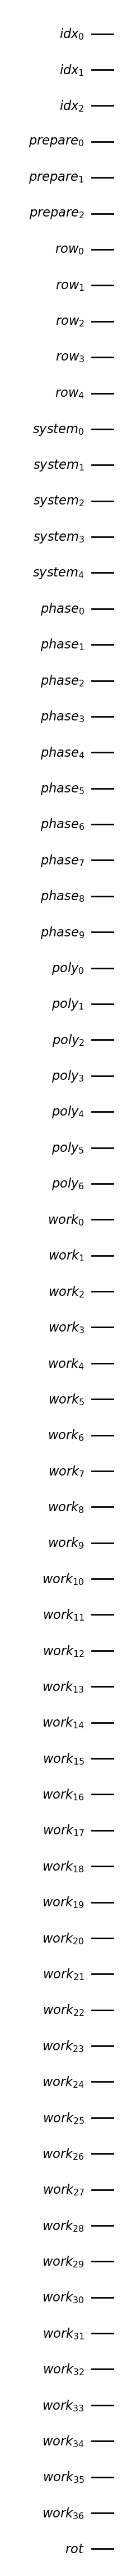

In [33]:
# ============================================================
# Cell 33 : Master HHL Circuit Initialization
# ============================================================

#
# This cell creates the master HHL circuit
# and allocates all registers required by
# the architecture frozen in Cell 22.
#
#
# Register order:
#
#     index
#     prepare
#     row
#     system
#     phase
#     poly
#     workspace
#     rotation
#
#
# No HHL operations are applied yet.
#
# This cell only creates the circuit
# skeleton that later cells will populate.
#

from qiskit import QuantumCircuit
from qiskit import QuantumRegister


# ============================================================
# Register allocation
# ============================================================

idx_reg = QuantumRegister(
    n_index_reg,
    name="idx"
)

prepare_reg = QuantumRegister(
    n_prepare_reg,
    name="prepare"
)

row_reg = QuantumRegister(
    n_row_reg,
    name="row"
)

system_reg = QuantumRegister(
    n_system_reg,
    name="system"
)

phase_reg = QuantumRegister(
    n_phase_reg,
    name="phase"
)

poly_reg = QuantumRegister(
    n_poly_reg,
    name="poly"
)

workspace_reg = QuantumRegister(
    n_workspace_reg,
    name="work"
)

rotation_reg = QuantumRegister(
    n_rotation_reg,
    name="rot"
)


# ============================================================
# Master circuit
# ============================================================

HHL_CIRCUIT = QuantumCircuit(

    idx_reg,

    prepare_reg,

    row_reg,

    system_reg,

    phase_reg,

    poly_reg,

    workspace_reg,

    rotation_reg,

    name="HHL_Finance"
)


# ============================================================
# Register dictionary
# ============================================================

HHL_REGISTERS = {

    "index":
        idx_reg,

    "prepare":
        prepare_reg,

    "row":
        row_reg,

    "system":
        system_reg,

    "phase":
        phase_reg,

    "poly":
        poly_reg,

    "workspace":
        workspace_reg,

    "rotation":
        rotation_reg
}


# ============================================================
# Register size summary
# ============================================================

HHL_REGISTER_SIZES = {

    "index":
        n_index_reg,

    "prepare":
        n_prepare_reg,

    "row":
        n_row_reg,

    "system":
        n_system_reg,

    "phase":
        n_phase_reg,

    "poly":
        n_poly_reg,

    "workspace":
        n_workspace_reg,

    "rotation":
        n_rotation_reg
}


# ============================================================
# Consistency checks
# ============================================================

assert (
    HHL_CIRCUIT.num_qubits
    ==
    TOTAL_HHL_QUBITS
), (
    "Master circuit qubit count "
    "does not match architecture."
)

assert (
    sum(
        HHL_REGISTER_SIZES.values()
    )
    ==
    TOTAL_HHL_QUBITS
)


# ============================================================
# Export objects
# ============================================================

#
# Main exported objects:
#
#     HHL_CIRCUIT
#
#     idx_reg
#     prepare_reg
#     row_reg
#     system_reg
#     phase_reg
#     poly_reg
#     workspace_reg
#     rotation_reg
#
#     HHL_REGISTERS
#     HHL_REGISTER_SIZES
#

# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Master HHL Circuit Initialization")
print("=" * 70)

print()

print("Register allocation:")

print()

for register_name, size in (
    HHL_REGISTER_SIZES.items()
):

    print(
        f"{register_name:<12s}: "
        f"{size}"
    )

print()

print(
    f"Total qubits                   : "
    f"{HHL_CIRCUIT.num_qubits}"
)

print()

print(
    f"Circuit depth                  : "
    f"{HHL_CIRCUIT.depth()}"
)

print()

print(
    "No HHL operations have been "
    "applied yet."
)

print()

print(
    "Next step:"
)

print(
    "  Attach U_b state preparation"
)

print()

print(
    "Exported objects:"
)

print()

print(
    "  HHL_CIRCUIT"
)

print(
    "  HHL_REGISTERS"
)

print(
    "  HHL_REGISTER_SIZES"
)

print()

print("=" * 70)


# ============================================================
# Optional circuit display
# ============================================================

display(
    HHL_CIRCUIT.draw(
        "mpl",
        fold=-1
    )
)


HHL Assembly : State Preparation

Applied block:

  U_b

Logical effect:

|0>_idx |0>_system
    -->
|0>_idx |b>_system

Depth information:

Logical depth                : 1
Expanded depth               : 30

Total qubits                 : 71

Support size (rho)           : 3
Padded support size (delta)  : 4

MCX count                    : 13

State preparation complete.

Next step:
  Build QPE(W) block


Displaying only the registers relevant to U_b:



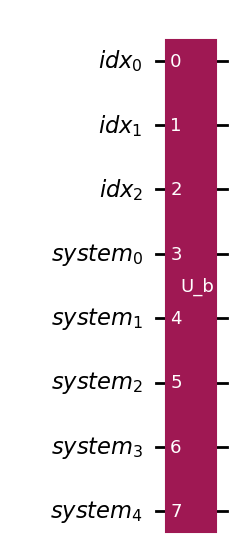

In [34]:
# ============================================================
# Cell 34 : Attach Shock-State Preparation
# ============================================================

#
# This cell applies
#
#     U_b
#
# to the master HHL circuit.
#
#
# Logical action:
#
#     |0>_idx |0>_system
#
#         -->
#
#     |0>_idx |b>_system
#
#
# The index register is internally used
# during state preparation and is returned
# to |0> by the end of U_b.
#

from qiskit import QuantumCircuit


# ============================================================
# Apply U_b
# ============================================================

HHL_CIRCUIT.append(

    UB_GATE,

    list(idx_reg)
    +
    list(system_reg)

)

HHL_CIRCUIT.barrier()


# ============================================================
# Resource snapshot
# ============================================================

#
# Logical depth:
#
# Treats U_b as a single opaque block.
#

CURRENT_LOGICAL_DEPTH = (
    HHL_CIRCUIT.depth()
)

#
# Expanded depth:
#
# Uses the verified implementation
# from Cell 23.
#

CURRENT_EXPANDED_DEPTH = (
    STATE_PREP_CIRCUIT.depth()
)

CURRENT_GATE_COUNTS = (
    HHL_CIRCUIT.count_ops()
)


# ============================================================
# Stage bookkeeping
# ============================================================

CURRENT_HHL_STAGE = (
    "State Preparation Complete"
)

CURRENT_HHL_STATE = (
    "|0>_idx |b>_system"
)


# ============================================================
# Progress object
# ============================================================

HHL_PROGRESS = {

    "stage":
        CURRENT_HHL_STAGE,

    "logical_state":
        CURRENT_HHL_STATE,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# Visualization circuit
# ============================================================

#
# Show only the registers relevant
# to the state-preparation block.
#

UB_VIEW = QuantumCircuit(

    idx_reg,

    system_reg,

    name="U_b_View"

)

UB_VIEW.append(

    UB_GATE,

    list(idx_reg)
    +
    list(system_reg)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("HHL Assembly : State Preparation")
print("=" * 70)

print()

print("Applied block:")

print()

print("  U_b")

print()

print("Logical effect:")

print()

print(
    "|0>_idx |0>_system"
)

print(
    "    -->"
)

print(
    "|0>_idx |b>_system"
)

print()

print("Depth information:")

print()

print(
    f"Logical depth                : "
    f"{CURRENT_LOGICAL_DEPTH}"
)

print(
    f"Expanded depth               : "
    f"{CURRENT_EXPANDED_DEPTH}"
)

print()

print(
    f"Total qubits                 : "
    f"{HHL_CIRCUIT.num_qubits}"
)

print()

print(
    f"Support size (rho)           : "
    f"{B_STATE_RHO}"
)

print(
    f"Padded support size (delta)  : "
    f"{B_STATE_DELTA}"
)

print()

print(
    f"MCX count                    : "
    f"{STATE_PREP_METADATA['mcx_count']}"
)

print()

print(
    "State preparation complete."
)

print()

print("Next step:")

print(
    "  Build QPE(W) block"
)

print()

print("=" * 70)


# ============================================================
# Visualization
# ============================================================

print(
    "\nDisplaying only the registers "
    "relevant to U_b:\n"
)

display(
    UB_VIEW.draw(
        "mpl",
        fold=-1
    )
)


Abstract QPE(W) / IQPE(W) Blocks

Registers:

Phase register               : 10
PREPARE register             : 3
Row register                 : 5
System register              : 5

QPE powers:

[1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

Phase precision              : 1.00e-03

Oracle resources:

W calls                      : 1023
PREPARE calls                : 2046
SELECT calls                 : 1023
Reflection calls             : 1023

Exported objects:

  QPE_BLOCK_GATE
  IQPE_BLOCK_GATE
  QPE_POWER_LIST
  QPE_BLOCK_SPECIFICATION
  QPE_RESOURCE_ESTIMATE


Displaying only registers relevant to QPE:



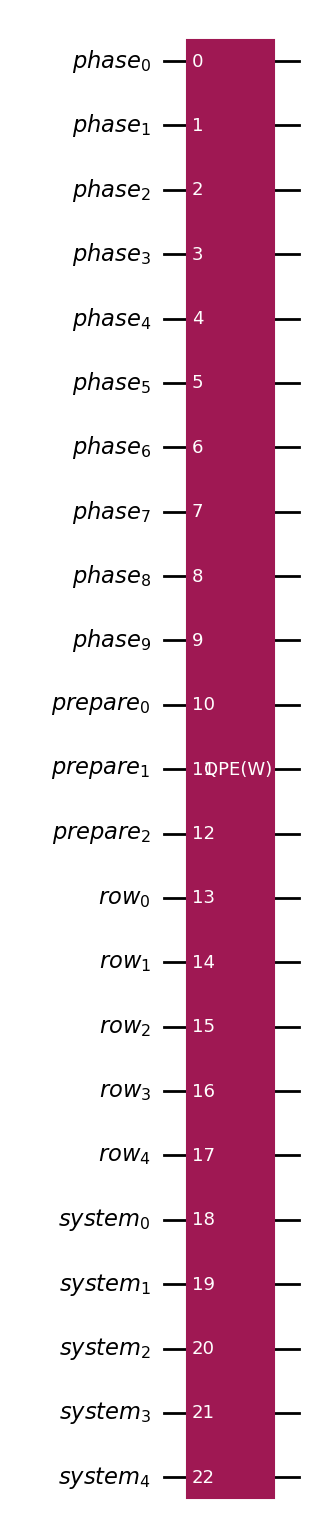

In [35]:
# ============================================================
# Cell 35 : Build Abstract QPE(W) Block
# ============================================================

#
# This cell constructs the abstract
# qubitization-based QPE block.
#
#
# Registers:
#
#     phase
#     prepare
#     row
#     system
#
#
# The walk operator
#
#     W
#
# remains an oracle-level abstraction.
#
#
# This cell DOES NOT attach QPE
# to the master HHL circuit.
#
# It merely constructs the reusable
# QPE block.
#

from qiskit import QuantumCircuit
from qiskit import QuantumRegister
from qiskit.circuit import Gate
from qiskit.circuit.library import QFT


# ============================================================
# Local QPE registers
# ============================================================

phase_qpe = QuantumRegister(
    n_phase_reg,
    name="phase"
)

prepare_qpe = QuantumRegister(
    n_prepare_reg,
    name="prepare"
)

row_qpe = QuantumRegister(
    n_row_reg,
    name="row"
)

system_qpe = QuantumRegister(
    n_system_reg,
    name="system"
)


QPE_BLOCK_CIRCUIT = QuantumCircuit(

    phase_qpe,

    prepare_qpe,

    row_qpe,

    system_qpe,

    name="QPE_W"
)


# ============================================================
# QPE powers
# ============================================================

QPE_POWER_LIST = [

    2**k

    for k in range(
        m_HHL
    )
]


# ============================================================
# Placeholder W gate
# ============================================================

#
# W acts on:
#
#     prepare
#     row
#     system
#
# registers.
#
# We intentionally keep W abstract.
#

W_QUBITS = (

    n_prepare_reg
    +
    n_row_reg
    +
    n_system_reg
)

W_ORACLE_GATE = Gate(

    name="W",

    num_qubits=W_QUBITS,

    params=[]
)


# ============================================================
# Hadamards
# ============================================================

for q in range(
    n_phase_reg
):

    QPE_BLOCK_CIRCUIT.h(
        phase_qpe[q]
    )


QPE_BLOCK_CIRCUIT.barrier()


# ============================================================
# Controlled powers of W
# ============================================================

#
# Same convention used in the
# pedagogical notebook:
#
#     phase[m-1-k]
#
# controls
#
#     W^(2^k)
#
# so that displayed bitstrings
# appear naturally in MSB-left order.
#

for k in range(
    m_HHL
):

    power = (
        2**k
    )

    controlled_W_power = Gate(

        name=f"CW^{power}",

        num_qubits=
        1 + W_QUBITS,

        params=[]
    )

    QPE_BLOCK_CIRCUIT.append(

        controlled_W_power,

        [phase_qpe[
            n_phase_reg - 1 - k
        ]]
        +
        list(prepare_qpe)
        +
        list(row_qpe)
        +
        list(system_qpe)

    )


QPE_BLOCK_CIRCUIT.barrier()


# ============================================================
# IQFT
# ============================================================

IQFT_GATE = (

    QFT(

        num_qubits=n_phase_reg,

        inverse=True,

        do_swaps=False

    )

    .to_gate(

        label="IQFT"

    )
)

QPE_BLOCK_CIRCUIT.append(

    IQFT_GATE,

    phase_qpe

)


# ============================================================
# Convert QPE to reusable gate
# ============================================================

#
# Remove barriers before conversion.
#

QPE_BLOCK_NO_BARRIERS = (
    QPE_BLOCK_CIRCUIT
    .copy()
)

QPE_BLOCK_NO_BARRIERS.data = [

    inst

    for inst in
    QPE_BLOCK_NO_BARRIERS.data

    if inst.operation.name
    != "barrier"
]


QPE_BLOCK_GATE = (

    QPE_BLOCK_NO_BARRIERS

    .to_gate(

        label="QPE(W)"

    )
)


# ============================================================
# Explicit IQPE construction
# ============================================================

#
# IMPORTANT:
#
# We do NOT use
#
#     QPE_BLOCK_GATE.inverse()
#
# because the placeholder
#
#     CW^(2^k)
#
# gates do not possess a defined
# inverse implementation.
#
# Instead we explicitly construct
# the inverse-QPE architecture.
#

IQPE_BLOCK_CIRCUIT = QuantumCircuit(

    phase_qpe,

    prepare_qpe,

    row_qpe,

    system_qpe,

    name="IQPE_W"

)


# ------------------------------------------------------------
# Step 1:
# QFT
#
# (inverse of IQFT)
# ------------------------------------------------------------

QFT_GATE = (

    QFT(

        num_qubits=n_phase_reg,

        inverse=False,

        do_swaps=False

    )

    .to_gate(

        label="QFT"

    )
)

IQPE_BLOCK_CIRCUIT.append(

    QFT_GATE,

    phase_qpe

)


# ------------------------------------------------------------
# Step 2:
# Controlled W-dagger powers
#
# Reverse order relative to QPE.
# ------------------------------------------------------------

for k in reversed(
    range(m_HHL)
):

    power = (
        2**k
    )

    controlled_W_dagger_power = Gate(

        name=f"CWdg^{power}",

        num_qubits=
        1 + W_QUBITS,

        params=[]
    )

    IQPE_BLOCK_CIRCUIT.append(

        controlled_W_dagger_power,

        [phase_qpe[
            n_phase_reg - 1 - k
        ]]
        +
        list(prepare_qpe)
        +
        list(row_qpe)
        +
        list(system_qpe)

    )


# ------------------------------------------------------------
# Step 3:
# Hadamards
#
# (inverse of initial QPE Hadamards)
# ------------------------------------------------------------

for q in range(
    n_phase_reg
):

    IQPE_BLOCK_CIRCUIT.h(
        phase_qpe[q]
    )


# ------------------------------------------------------------
# Remove barriers and convert
# ------------------------------------------------------------

IQPE_BLOCK_NO_BARRIERS = (
    IQPE_BLOCK_CIRCUIT
    .copy()
)

IQPE_BLOCK_NO_BARRIERS.data = [

    inst

    for inst in
    IQPE_BLOCK_NO_BARRIERS.data

    if inst.operation.name
    != "barrier"
]


IQPE_BLOCK_GATE = (

    IQPE_BLOCK_NO_BARRIERS

    .to_gate(

        label="IQPE(W)"

    )
)

# ============================================================
# Resource estimates
# ============================================================

QPE_RESOURCE_ESTIMATE = {

    "phase_qubits":

        n_phase_reg,

    "w_calls":

        TOTAL_W_CALLS_QPE,

    "prepare_calls":

        TOTAL_PREPARE_CALLS_QPE,

    "select_calls":

        TOTAL_SELECT_CALLS_QPE,

    "reflection_calls":

        TOTAL_REFLECTION_CALLS_QPE,

    "power_list":

        QPE_POWER_LIST
}


# ============================================================
# Specification
# ============================================================

QPE_BLOCK_SPECIFICATION = {

    "operator":

        "W",

    "phase_qubits":

        n_phase_reg,

    "signed_phase_interval":

        "(-1/2, 1/2]",

    "phase_precision":

        EPSILON_QPE_PHASE,

    "power_list":

        QPE_POWER_LIST,

    "do_swaps":

        False,

    "control_convention":

        "phase[m-1-k]"
}


# ============================================================
# Visualization circuit
# ============================================================

QPE_VIEW = QuantumCircuit(

    phase_qpe,

    prepare_qpe,

    row_qpe,

    system_qpe

)

QPE_VIEW.append(

    QPE_BLOCK_GATE,

    list(phase_qpe)
    +
    list(prepare_qpe)
    +
    list(row_qpe)
    +
    list(system_qpe)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Abstract QPE(W) / IQPE(W) Blocks")
print("=" * 70)

print()

print("Registers:")

print()

print(
    f"Phase register               : "
    f"{n_phase_reg}"
)

print(
    f"PREPARE register             : "
    f"{n_prepare_reg}"
)

print(
    f"Row register                 : "
    f"{n_row_reg}"
)

print(
    f"System register              : "
    f"{n_system_reg}"
)

print()

print("QPE powers:")

print()

print(QPE_POWER_LIST)

print()

print(
    f"Phase precision              : "
    f"{EPSILON_QPE_PHASE:.2e}"
)

print()

print("Oracle resources:")

print()

print(
    f"W calls                      : "
    f"{TOTAL_W_CALLS_QPE}"
)

print(
    f"PREPARE calls                : "
    f"{TOTAL_PREPARE_CALLS_QPE}"
)

print(
    f"SELECT calls                 : "
    f"{TOTAL_SELECT_CALLS_QPE}"
)

print(
    f"Reflection calls             : "
    f"{TOTAL_REFLECTION_CALLS_QPE}"
)

print()

print("Exported objects:")

print()

print(
    "  QPE_BLOCK_GATE"
)

print(
    "  IQPE_BLOCK_GATE"
)

print(
    "  QPE_POWER_LIST"
)

print(
    "  QPE_BLOCK_SPECIFICATION"
)

print(
    "  QPE_RESOURCE_ESTIMATE"
)

print()

print("=" * 70)


# ============================================================
# Visualization
# ============================================================

print(
    "\nDisplaying only registers "
    "relevant to QPE:\n"
)

display(
    QPE_VIEW.draw(
        "mpl",
        fold=-1
    )
)


HHL Assembly : QPE(W)

Applied block:

  QPE(W)

Logical action:

|0>_phase
    ⊗
Σ beta_j |u_j>

        -->

Σ beta_j |phi_j> |u_j>

Phase qubits                 : 10

Phase precision             : 1.00e-03

Oracle resources used:

W calls                     : 1023
PREPARE calls               : 2046
SELECT calls                : 1023
Reflection calls            : 1023

Current logical depth       : 2

Current expanded depth      : 1055

Current total qubits        : 71

Phase estimation complete.

Next step:
  Attach P_d


Displaying only registers relevant to QPE:



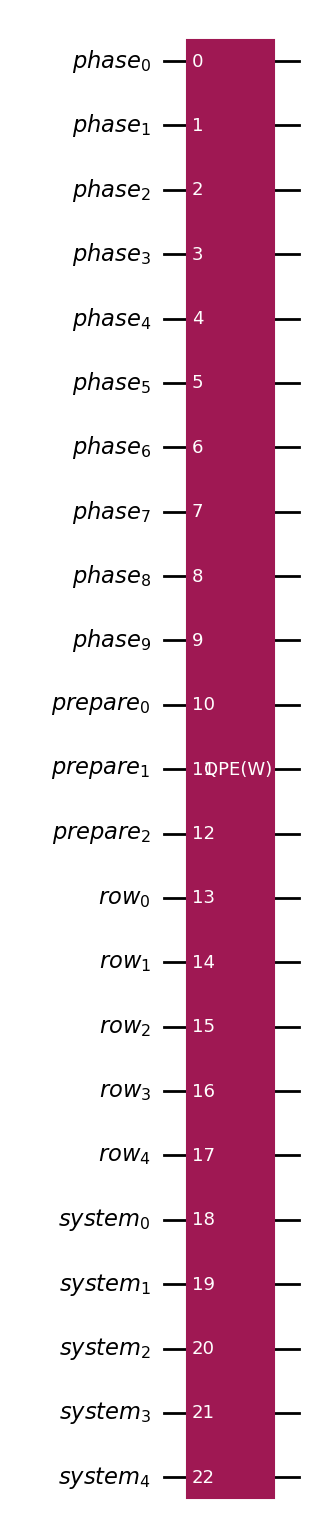

In [36]:
# ============================================================
# Cell 36 : Attach QPE(W) Block
# ============================================================

#
# This cell attaches the abstract
#
#     QPE(W)
#
# block to the master HHL circuit.
#
#
# Logical action:
#
#     |0>_phase
#         ⊗
#     Σ β_j |u_j>
#
#             -->
#
#     Σ β_j
#         |phi_j>
#         |u_j>
#
#
# where:
#
#     phi_j
#
# is the m_HHL-bit estimate of the
# eigenphase associated with the
# qubitized walk operator W.
#
#
# This is still an architecture-level
# circuit:
#
#     W
#
# remains abstract.
#

# ============================================================
# Attach QPE block
# ============================================================

HHL_CIRCUIT.append(

    QPE_BLOCK_GATE,

    list(phase_reg)

    +

    list(prepare_reg)

    +

    list(row_reg)

    +

    list(system_reg)

)

HHL_CIRCUIT.barrier()


# ============================================================
# Resource snapshot
# ============================================================

CURRENT_LOGICAL_DEPTH = (
    HHL_CIRCUIT.depth()
)

CURRENT_GATE_COUNTS = (
    HHL_CIRCUIT.count_ops()
)


# ============================================================
# Expanded-depth estimate
# ============================================================

#
# Since QPE(W) is currently represented
# as a single composite gate, Qiskit
# underestimates the true depth.
#
# We therefore maintain a separate
# architecture-level estimate.
#

QPE_LOGICAL_DEPTH = 1

QPE_EXPANDED_DEPTH_ESTIMATE = (

    1                       # Hadamard layer

    +

    TOTAL_W_CALLS_QPE       # controlled powers

    +

    1                       # IQFT block

)

PREVIOUS_EXPANDED_DEPTH = (
    HHL_PROGRESS.get(
        "expanded_depth",
        0
    )
)

CURRENT_EXPANDED_DEPTH = (

    PREVIOUS_EXPANDED_DEPTH

    +

    QPE_EXPANDED_DEPTH_ESTIMATE

)


# ============================================================
# Stage bookkeeping
# ============================================================

CURRENT_HHL_STAGE = (
    "QPE Complete"
)

CURRENT_HHL_STATE = (

    "Sum_j beta_j "
    "|phi_j> |u_j>"

)


# ============================================================
# Progress tracker
# ============================================================

HHL_PROGRESS = {

    "stage":
        CURRENT_HHL_STAGE,

    "logical_state":
        CURRENT_HHL_STATE,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# QPE summary dictionary
# ============================================================

QPE_ATTACHMENT_SUMMARY = {

    "phase_qubits":
        n_phase_reg,

    "phase_precision":
        EPSILON_QPE_PHASE,

    "w_calls":
        TOTAL_W_CALLS_QPE,

    "prepare_calls":
        TOTAL_PREPARE_CALLS_QPE,

    "select_calls":
        TOTAL_SELECT_CALLS_QPE,

    "reflection_calls":
        TOTAL_REFLECTION_CALLS_QPE,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# Visualization circuit
# ============================================================

#
# Show only registers relevant
# to the QPE stage.
#

QPE_STAGE_VIEW = QuantumCircuit(

    phase_reg,

    prepare_reg,

    row_reg,

    system_reg

)

QPE_STAGE_VIEW.append(

    QPE_BLOCK_GATE,

    list(phase_reg)

    +

    list(prepare_reg)

    +

    list(row_reg)

    +

    list(system_reg)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("HHL Assembly : QPE(W)")
print("=" * 70)

print()

print("Applied block:")

print()

print(
    "  QPE(W)"
)

print()

print("Logical action:")

print()

print(
    "|0>_phase"
)

print(
    "    ⊗"
)

print(
    "Σ beta_j |u_j>"
)

print()

print(
    "        -->"
)

print()

print(
    "Σ beta_j |phi_j> |u_j>"
)

print()

print(
    f"Phase qubits                 : "
    f"{n_phase_reg}"
)

print()

print(
    f"Phase precision             : "
    f"{EPSILON_QPE_PHASE:.2e}"
)

print()

print("Oracle resources used:")

print()

print(
    f"W calls                     : "
    f"{TOTAL_W_CALLS_QPE}"
)

print(
    f"PREPARE calls               : "
    f"{TOTAL_PREPARE_CALLS_QPE}"
)

print(
    f"SELECT calls                : "
    f"{TOTAL_SELECT_CALLS_QPE}"
)

print(
    f"Reflection calls            : "
    f"{TOTAL_REFLECTION_CALLS_QPE}"
)

print()

print(
    f"Current logical depth       : "
    f"{CURRENT_LOGICAL_DEPTH}"
)

print()

print(
    f"Current expanded depth      : "
    f"{CURRENT_EXPANDED_DEPTH}"
)

print()

print(
    f"Current total qubits        : "
    f"{HHL_CIRCUIT.num_qubits}"
)

print()

print(
    "Phase estimation complete."
)

print()

print(
    "Next step:"
)

print(
    "  Attach P_d"
)

print()

print("=" * 70)


# ============================================================
# Visualization
# ============================================================

print(
    "\nDisplaying only registers "
    "relevant to QPE:\n"
)

display(
    QPE_STAGE_VIEW.draw(
        "mpl",
        fold=-1
    )
)


HHL Assembly : P_d

Applied block:

  P_d

Logical action:

|phi>
|0>_poly

    -->

|phi>
|omega(phi)>

Coherent action:

Σ beta_j |phi_j> |u_j> |0>

    -->

Σ beta_j |phi_j> |u_j> |omega(phi_j)>

Chebyshev degree            : 30

Chebyshev error target      : 1.00e-02

Phase register qubits       : 10
Polynomial register qubits  : 7
Workspace qubits            : 37

Current logical depth       : 3

Current expanded depth      : 1085

Current total qubits        : 71

Polynomial evaluation complete.

Next step:
  Attach controlled rotation


Displaying only registers relevant to P_d:



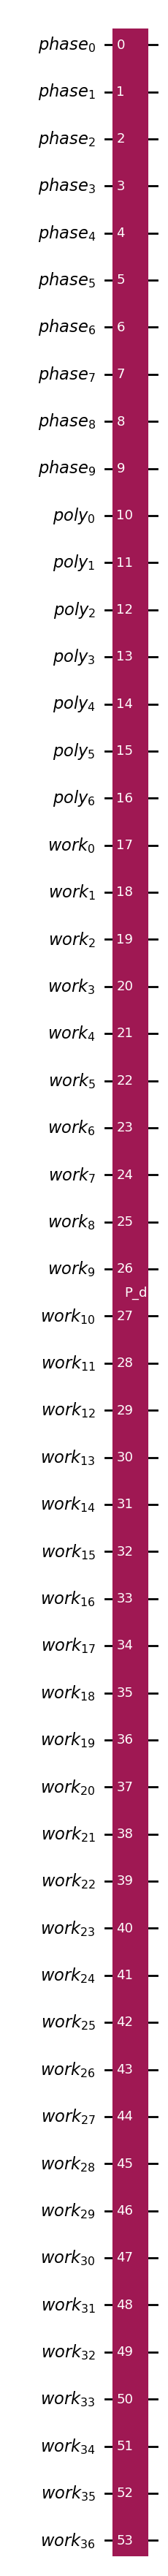

In [37]:
# ============================================================
# Cell 37 : Attach P_d (Chebyshev Reciprocal-Angle Block)
# ============================================================

#
# This cell attaches the abstract
#
#     P_d
#
# block to the master HHL circuit.
#
#
# Logical action:
#
#     |phi>
#     |0>_poly
#
#         -->
#
#     |phi>
#     |omega(phi)>
#
#
# where:
#
#     omega(phi)
#
# =
#
#     arcsin(
#         C_HHL
#         /
#         (
#             alpha_A
#             cos(2*pi*phi)
#         )
#     )
#
#
# IMPORTANT:
#
# The phase register is generally
# entangled with the system register.
#
# Therefore P_d acts coherently:
#
#     Σ beta_j
#       |phi_j>
#       |u_j>
#       |0>
#
#         -->
#
#     Σ beta_j
#       |phi_j>
#       |u_j>
#       |omega(phi_j)>
#
#
# This cell remains at the
# architecture level.
#
# The actual Chebyshev arithmetic
# is abstracted into a single gate.
#

from qiskit import QuantumCircuit
from qiskit.circuit import Gate


# ============================================================
# Abstract P_d gate
# ============================================================

PD_QUBITS = (

    n_phase_reg

    +

    n_poly_reg

    +

    n_workspace_reg

)

PD_GATE = Gate(

    name="P_d",

    num_qubits=PD_QUBITS,

    params=[]

)

PD_DAGGER_GATE = Gate(

    name="P_d†",

    num_qubits=PD_QUBITS,

    params=[]

)


# ============================================================
# Attach P_d
# ============================================================

HHL_CIRCUIT.append(

    PD_GATE,

    list(phase_reg)

    +

    list(poly_reg)

    +

    list(workspace_reg)

)

HHL_CIRCUIT.barrier()


# ============================================================
# Resource snapshot
# ============================================================

CURRENT_LOGICAL_DEPTH = (
    HHL_CIRCUIT.depth()
)

CURRENT_GATE_COUNTS = (
    HHL_CIRCUIT.count_ops()
)


# ============================================================
# Expanded-depth estimate
# ============================================================

#
# Architecture-level estimate.
#
# The actual implementation will
# evaluate a Chebyshev polynomial
# of degree:
#
#     chebyshev_degree
#
# and perform reversible arithmetic
# on:
#
#     phase
#     poly
#     workspace
#
# registers.
#

PD_EXPANDED_DEPTH_ESTIMATE = (

    chebyshev_degree

)

PREVIOUS_EXPANDED_DEPTH = (
    HHL_PROGRESS.get(
        "expanded_depth",
        0
    )
)

CURRENT_EXPANDED_DEPTH = (

    PREVIOUS_EXPANDED_DEPTH

    +

    PD_EXPANDED_DEPTH_ESTIMATE

)


# ============================================================
# Stage bookkeeping
# ============================================================

CURRENT_HHL_STAGE = (
    "Polynomial Evaluation Complete"
)

CURRENT_HHL_STATE = (

    "Sum_j beta_j "
    "|phi_j> |u_j> |omega(phi_j)>"

)


# ============================================================
# Progress tracker
# ============================================================

HHL_PROGRESS = {

    "stage":
        CURRENT_HHL_STAGE,

    "logical_state":
        CURRENT_HHL_STATE,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# P_d summary dictionary
# ============================================================

PD_ATTACHMENT_SUMMARY = {

    "chebyshev_degree":
        chebyshev_degree,

    "epsilon_cheb":
        EPSILON_CHEB,

    "phase_qubits":
        n_phase_reg,

    "poly_qubits":
        n_poly_reg,

    "workspace_qubits":
        n_workspace_reg,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# Visualization circuit
# ============================================================

PD_STAGE_VIEW = QuantumCircuit(

    phase_reg,

    poly_reg,

    workspace_reg

)

PD_STAGE_VIEW.append(

    PD_GATE,

    list(phase_reg)

    +

    list(poly_reg)

    +

    list(workspace_reg)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("HHL Assembly : P_d")
print("=" * 70)

print()

print("Applied block:")

print()

print(
    "  P_d"
)

print()

print("Logical action:")

print()

print(
    "|phi>"
)

print(
    "|0>_poly"
)

print()

print(
    "    -->"
)

print()

print(
    "|phi>"
)

print(
    "|omega(phi)>"
)

print()

print(
    "Coherent action:"
)

print()

print(
    "Σ beta_j |phi_j> |u_j> |0>"
)

print()

print(
    "    -->"
)

print()

print(
    "Σ beta_j |phi_j> |u_j> "
    "|omega(phi_j)>"
)

print()

print(
    f"Chebyshev degree            : "
    f"{chebyshev_degree}"
)

print()

print(
    f"Chebyshev error target      : "
    f"{EPSILON_CHEB:.2e}"
)

print()

print(
    f"Phase register qubits       : "
    f"{n_phase_reg}"
)

print(
    f"Polynomial register qubits  : "
    f"{n_poly_reg}"
)

print(
    f"Workspace qubits            : "
    f"{n_workspace_reg}"
)

print()

print(
    f"Current logical depth       : "
    f"{CURRENT_LOGICAL_DEPTH}"
)

print()

print(
    f"Current expanded depth      : "
    f"{CURRENT_EXPANDED_DEPTH}"
)

print()

print(
    f"Current total qubits        : "
    f"{HHL_CIRCUIT.num_qubits}"
)

print()

print(
    "Polynomial evaluation complete."
)

print()

print(
    "Next step:"
)

print(
    "  Attach controlled rotation"
)

print()

print("=" * 70)


# ============================================================
# Visualization
# ============================================================

print(
    "\nDisplaying only registers "
    "relevant to P_d:\n"
)

display(
    PD_STAGE_VIEW.draw(
        "mpl",
        fold=-1
    )
)


HHL Assembly : Controlled Rotation

Applied block:

  R_HHL

Logical action:

|omega>
|0>_rot

    -->

|omega>
(cos(omega)|0>
 + sin(omega)|1>)

where:

  sin(omega)
      =
  C_HHL / lambda

The reciprocal information
is now encoded into the
rotation ancilla amplitude.

Polynomial register qubits : 7

Rotation ancilla qubits    : 1

Current logical depth      : 4

Current expanded depth     : 1092

Current total qubits       : 71

Controlled rotation complete.

Next step:
  Attach P_d†


Displaying only registers relevant to controlled rotation:



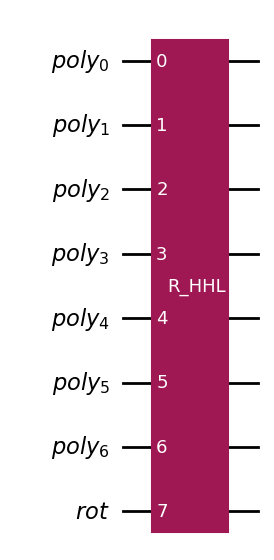

In [38]:
# ============================================================
# Cell 38 : Attach Controlled Rotation Block
# ============================================================

#
# This cell attaches the abstract
#
#     R_HHL
#
# controlled rotation block.
#
#
# Logical action:
#
#     |omega>
#     |0>_rot
#
#         -->
#
#     |omega>
#
#     (
#         cos(omega)|0>
#         +
#         sin(omega)|1>
#     )
#
#
# where:
#
#     omega
#
# =
#
#     arcsin(
#         C_HHL
#         /
#         lambda
#     )
#
#
# Therefore:
#
#     sin(omega)
#
# =
#
#     C_HHL / lambda
#
#
# After this step the rotation
# ancilla amplitude contains the
# reciprocal information required
# by HHL.
#

from qiskit import QuantumCircuit
from qiskit.circuit import Gate


# ============================================================
# Abstract controlled-rotation gate
# ============================================================

ROTATION_QUBITS = (

    n_poly_reg

    +

    n_rotation_reg

)

ROTATION_GATE = Gate(

    name="R_HHL",

    num_qubits=ROTATION_QUBITS,

    params=[]

)


# ============================================================
# Attach rotation block
# ============================================================

HHL_CIRCUIT.append(

    ROTATION_GATE,

    list(poly_reg)

    +

    list(rotation_reg)

)

HHL_CIRCUIT.barrier()


# ============================================================
# Resource snapshot
# ============================================================

CURRENT_LOGICAL_DEPTH = (
    HHL_CIRCUIT.depth()
)

CURRENT_GATE_COUNTS = (
    HHL_CIRCUIT.count_ops()
)


# ============================================================
# Expanded-depth estimate
# ============================================================

#
# Architecture-level estimate.
#
# Actual implementation would
# require:
#
#     controlled rotations
#
# driven by the bits of the
# polynomial register.
#

ROTATION_EXPANDED_DEPTH_ESTIMATE = (

    n_poly_reg

)

PREVIOUS_EXPANDED_DEPTH = (
    HHL_PROGRESS.get(
        "expanded_depth",
        0
    )
)

CURRENT_EXPANDED_DEPTH = (

    PREVIOUS_EXPANDED_DEPTH

    +

    ROTATION_EXPANDED_DEPTH_ESTIMATE

)


# ============================================================
# Stage bookkeeping
# ============================================================

CURRENT_HHL_STAGE = (
    "Controlled Rotation Complete"
)

CURRENT_HHL_STATE = (

    "Sum_j beta_j "
    "|phi_j> |u_j> "
    "|omega(phi_j)> "
    "(cos(omega_j)|0> + sin(omega_j)|1>)"

)


# ============================================================
# Progress tracker
# ============================================================

HHL_PROGRESS = {

    "stage":
        CURRENT_HHL_STAGE,

    "logical_state":
        CURRENT_HHL_STATE,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# Rotation summary
# ============================================================

ROTATION_ATTACHMENT_SUMMARY = {

    "poly_qubits":
        n_poly_reg,

    "rotation_qubits":
        n_rotation_reg,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# Visualization circuit
# ============================================================

ROTATION_STAGE_VIEW = QuantumCircuit(

    poly_reg,

    rotation_reg

)

ROTATION_STAGE_VIEW.append(

    ROTATION_GATE,

    list(poly_reg)

    +

    list(rotation_reg)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("HHL Assembly : Controlled Rotation")
print("=" * 70)

print()

print("Applied block:")

print()

print(
    "  R_HHL"
)

print()

print("Logical action:")

print()

print(
    "|omega>"
)

print(
    "|0>_rot"
)

print()

print(
    "    -->"
)

print()

print(
    "|omega>"
)

print(
    "(cos(omega)|0>"
)

print(
    " + sin(omega)|1>)"
)

print()

print(
    "where:"
)

print()

print(
    "  sin(omega)"
)

print(
    "      ="
)

print(
    "  C_HHL / lambda"
)

print()

print(
    "The reciprocal information"
)

print(
    "is now encoded into the"
)

print(
    "rotation ancilla amplitude."
)

print()

print(
    f"Polynomial register qubits : "
    f"{n_poly_reg}"
)

print()

print(
    f"Rotation ancilla qubits    : "
    f"{n_rotation_reg}"
)

print()

print(
    f"Current logical depth      : "
    f"{CURRENT_LOGICAL_DEPTH}"
)

print()

print(
    f"Current expanded depth     : "
    f"{CURRENT_EXPANDED_DEPTH}"
)

print()

print(
    f"Current total qubits       : "
    f"{HHL_CIRCUIT.num_qubits}"
)

print()

print(
    "Controlled rotation complete."
)

print()

print(
    "Next step:"
)

print(
    "  Attach P_d†"
)

print()

print("=" * 70)


# ============================================================
# Visualization
# ============================================================

print(
    "\nDisplaying only registers "
    "relevant to controlled rotation:\n"
)

display(
    ROTATION_STAGE_VIEW.draw(
        "mpl",
        fold=-1
    )
)


HHL Assembly : P_d†

Applied block:

  P_d†

Logical action:

|phi>
|omega(phi)>

    -->

|phi>
|0>

Polynomial information
has been uncomputed.

Reciprocal information
remains encoded in the
rotation ancilla.

Chebyshev degree           : 30

Current logical depth      : 5

Current expanded depth     : 1122

Current total qubits       : 71

Polynomial uncomputation complete.

Next step:
  Attach IQPE(W)


Displaying only registers relevant to polynomial uncomputation:



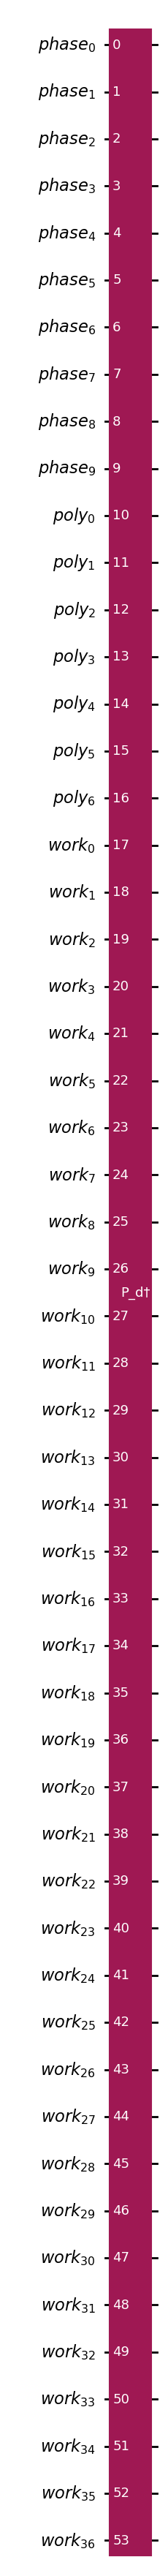

In [39]:
# ============================================================
# Cell 39 : Attach P_d† (Polynomial Uncomputation)
# ============================================================

#
# This cell uncomputes the polynomial
# evaluation performed by:
#
#     P_d
#
#
# Logical action:
#
#     |phi>
#     |omega(phi)>
#
#         -->
#
#     |phi>
#     |0>
#
#
# The reciprocal information remains
# encoded in the rotation ancilla.
#
#
# After this step:
#
#     poly
#     workspace
#
# are returned to |0>.
#

from qiskit import QuantumCircuit


# ============================================================
# Attach P_d†
# ============================================================

HHL_CIRCUIT.append(

    PD_DAGGER_GATE,

    list(phase_reg)

    +

    list(poly_reg)

    +

    list(workspace_reg)

)

HHL_CIRCUIT.barrier()


# ============================================================
# Resource snapshot
# ============================================================

CURRENT_LOGICAL_DEPTH = (
    HHL_CIRCUIT.depth()
)

CURRENT_GATE_COUNTS = (
    HHL_CIRCUIT.count_ops()
)


# ============================================================
# Expanded-depth estimate
# ============================================================

#
# P_d† has essentially the same
# complexity as P_d.
#

PD_DAGGER_EXPANDED_DEPTH_ESTIMATE = (

    chebyshev_degree

)

PREVIOUS_EXPANDED_DEPTH = (
    HHL_PROGRESS.get(
        "expanded_depth",
        0
    )
)

CURRENT_EXPANDED_DEPTH = (

    PREVIOUS_EXPANDED_DEPTH

    +

    PD_DAGGER_EXPANDED_DEPTH_ESTIMATE

)


# ============================================================
# Stage bookkeeping
# ============================================================

CURRENT_HHL_STAGE = (
    "Polynomial Uncomputation Complete"
)

CURRENT_HHL_STATE = (

    "Sum_j beta_j "
    "|phi_j> |u_j> "
    "(cos(omega_j)|0> + sin(omega_j)|1>)"

)


# ============================================================
# Progress tracker
# ============================================================

HHL_PROGRESS = {

    "stage":
        CURRENT_HHL_STAGE,

    "logical_state":
        CURRENT_HHL_STATE,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# Summary dictionary
# ============================================================

PD_DAGGER_ATTACHMENT_SUMMARY = {

    "chebyshev_degree":
        chebyshev_degree,

    "epsilon_cheb":
        EPSILON_CHEB,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# Visualization circuit
# ============================================================

PD_DAGGER_STAGE_VIEW = QuantumCircuit(

    phase_reg,

    poly_reg,

    workspace_reg

)

PD_DAGGER_STAGE_VIEW.append(

    PD_DAGGER_GATE,

    list(phase_reg)

    +

    list(poly_reg)

    +

    list(workspace_reg)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("HHL Assembly : P_d†")
print("=" * 70)

print()

print("Applied block:")

print()

print(
    "  P_d†"
)

print()

print("Logical action:")

print()

print(
    "|phi>"
)

print(
    "|omega(phi)>"
)

print()

print(
    "    -->"
)

print()

print(
    "|phi>"
)

print(
    "|0>"
)

print()

print(
    "Polynomial information"
)

print(
    "has been uncomputed."
)

print()

print(
    "Reciprocal information"
)

print(
    "remains encoded in the"
)

print(
    "rotation ancilla."
)

print()

print(
    f"Chebyshev degree           : "
    f"{chebyshev_degree}"
)

print()

print(
    f"Current logical depth      : "
    f"{CURRENT_LOGICAL_DEPTH}"
)

print()

print(
    f"Current expanded depth     : "
    f"{CURRENT_EXPANDED_DEPTH}"
)

print()

print(
    f"Current total qubits       : "
    f"{HHL_CIRCUIT.num_qubits}"
)

print()

print(
    "Polynomial uncomputation complete."
)

print()

print(
    "Next step:"
)

print(
    "  Attach IQPE(W)"
)

print()

print("=" * 70)


# ============================================================
# Visualization
# ============================================================

print(
    "\nDisplaying only registers "
    "relevant to polynomial uncomputation:\n"
)

display(
    PD_DAGGER_STAGE_VIEW.draw(
        "mpl",
        fold=-1
    )
)


HHL Assembly : IQPE(W)

Applied block:

  IQPE(W)

Logical effect:

Phase register returned to |0>

Reciprocal information remains
encoded in rotation ancilla.

W calls                     : 1023

Current logical depth       : 6

Current expanded depth      : 2147

Registers logically reset:

  - phase
  - poly
  - workspace

Current total qubits        : 71

Inverse phase estimation complete.

Next step:
  Analyze success probability


Displaying only registers relevant to IQPE:



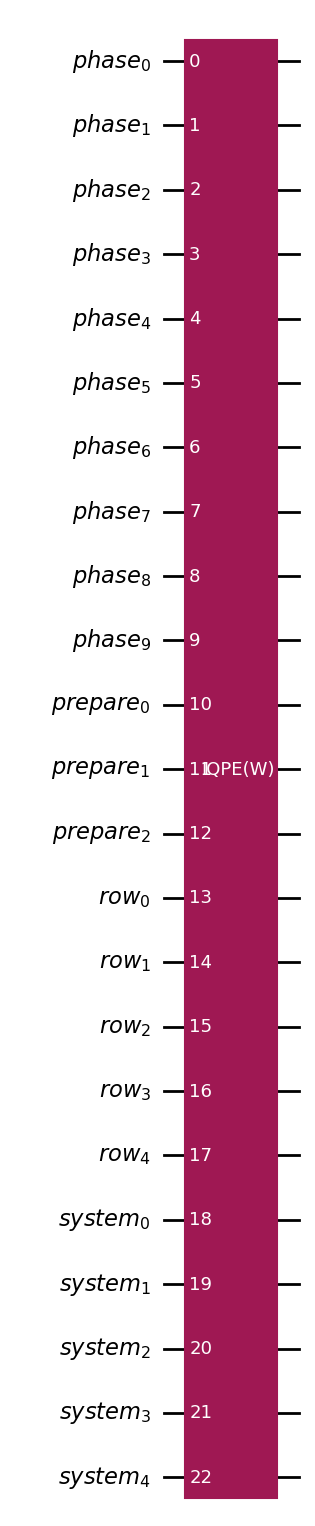

In [40]:
# ============================================================
# Cell 40 : Attach IQPE(W)
# ============================================================

#
# This cell attaches
#
#     IQPE(W)
#
# to the master HHL circuit.
#
#
# Logical action:
#
#     Σ beta_j
#         |phi_j>
#         |u_j>
#
#         (
#             cos(omega_j)|0>
#             +
#             sin(omega_j)|1>
#         )
#
#
#             -->
#
#
#     |0>_phase
#
#         ⊗
#
#     Σ beta_j
#         |u_j>
#
#         (
#             cos(omega_j)|0>
#             +
#             sin(omega_j)|1>
#         )
#
#
# Thus:
#
#     phase register
#
# is uncomputed.
#

# ============================================================
# Attach IQPE block
# ============================================================

HHL_CIRCUIT.append(

    IQPE_BLOCK_GATE,

    list(phase_reg)

    +

    list(prepare_reg)

    +

    list(row_reg)

    +

    list(system_reg)

)

HHL_CIRCUIT.barrier()


# ============================================================
# Resource snapshot
# ============================================================

CURRENT_LOGICAL_DEPTH = (
    HHL_CIRCUIT.depth()
)

CURRENT_GATE_COUNTS = (
    HHL_CIRCUIT.count_ops()
)


# ============================================================
# Expanded-depth estimate
# ============================================================

IQPE_EXPANDED_DEPTH_ESTIMATE = (

    1                       # QFT

    +

    TOTAL_W_CALLS_QPE       # controlled W† powers

    +

    1                       # Hadamard layer

)

PREVIOUS_EXPANDED_DEPTH = (
    HHL_PROGRESS.get(
        "expanded_depth",
        0
    )
)

CURRENT_EXPANDED_DEPTH = (

    PREVIOUS_EXPANDED_DEPTH

    +

    IQPE_EXPANDED_DEPTH_ESTIMATE

)


# ============================================================
# Stage bookkeeping
# ============================================================

CURRENT_HHL_STAGE = (
    "IQPE Complete"
)

CURRENT_HHL_STATE = (

    "Sum_j beta_j |u_j> "
    "(cos(omega_j)|0> + "
    "sin(omega_j)|1>)"

)


# ============================================================
# Progress tracker
# ============================================================

HHL_PROGRESS = {

    "stage":
        CURRENT_HHL_STAGE,

    "logical_state":
        CURRENT_HHL_STATE,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# IQPE summary
# ============================================================

IQPE_ATTACHMENT_SUMMARY = {

    "phase_qubits":
        n_phase_reg,

    "w_calls":

        TOTAL_W_CALLS_QPE,

    "prepare_calls":

        TOTAL_PREPARE_CALLS_QPE,

    "select_calls":

        TOTAL_SELECT_CALLS_QPE,

    "reflection_calls":

        TOTAL_REFLECTION_CALLS_QPE,

    "logical_depth":

        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":

        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# Registers now reset
# ============================================================

RESET_REGISTERS = [

    "phase",

    "poly",

    "workspace"

]


# ============================================================
# Visualization circuit
# ============================================================

IQPE_STAGE_VIEW = QuantumCircuit(

    phase_reg,

    prepare_reg,

    row_reg,

    system_reg

)

IQPE_STAGE_VIEW.append(

    IQPE_BLOCK_GATE,

    list(phase_reg)

    +

    list(prepare_reg)

    +

    list(row_reg)

    +

    list(system_reg)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("HHL Assembly : IQPE(W)")
print("=" * 70)

print()

print("Applied block:")

print()

print(
    "  IQPE(W)"
)

print()

print("Logical effect:")

print()

print(
    "Phase register returned to |0>"
)

print()

print(
    "Reciprocal information remains"
)

print(
    "encoded in rotation ancilla."
)

print()

print(
    f"W calls                     : "
    f"{TOTAL_W_CALLS_QPE}"
)

print()

print(
    f"Current logical depth       : "
    f"{CURRENT_LOGICAL_DEPTH}"
)

print()

print(
    f"Current expanded depth      : "
    f"{CURRENT_EXPANDED_DEPTH}"
)

print()

print(
    "Registers logically reset:"
)

print()

for register in RESET_REGISTERS:

    print(
        f"  - {register}"
    )

print()

print(
    f"Current total qubits        : "
    f"{HHL_CIRCUIT.num_qubits}"
)

print()

print(
    "Inverse phase estimation complete."
)

print()

print(
    "Next step:"
)

print(
    "  Analyze success probability"
)

print()

print("=" * 70)


# ============================================================
# Visualization
# ============================================================

print(
    "\nDisplaying only registers "
    "relevant to IQPE:\n"
)

display(
    IQPE_STAGE_VIEW.draw(
        "mpl",
        fold=-1
    )
)


Full HHL Architecture Summary

Pipeline:

U_b
 -> QPE(W)
 -> P_d
 -> R_HHL
 -> P_d†
 -> IQPE(W)


Register Summary

index          3
prepare        3
row            5
system         5
phase          10
poly           7
workspace      37
rotation       1

TOTAL          71


Complexity Summary

U_b            O(delta*(log(N)+log(gamma))) = O(log(N)*(log(N) + log log(N))) = O(log^2(N))
QPE(W)         O((1/EPSILON_QPE_PHASE) polylog(N)) = O(kappa^2 polylog(N))
P_d            O(log(1/EPSILON_CHEB))
R_HHL          O(log(1/EPSILON_CHEB))
P_d†           O(log(1/EPSILON_CHEB))
IQPE(W)        O((1/EPSILON_QPE_PHASE) polylog(N)) = O(kappa^2 polylog(N))
OVERALL        O(kappa^2 polylog(N) + log(1/EPSILON_CHEB)) = O(kappa^2 polylog(N)), for this implementation and parameter regime.


Success Probability


KAPPA_BOUND                : 4.0000

Worst case:
  lambda = lambda_max

Approx success lower bound : 0.062500

Amplitude amplification
can substantially improve
success probability,
especially f

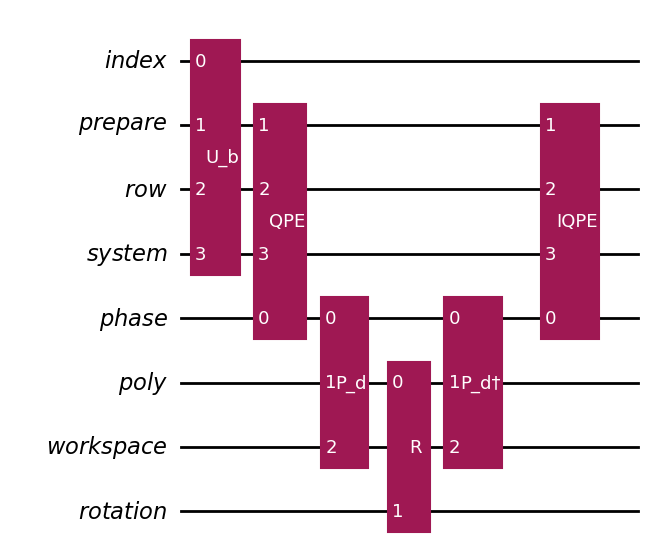

In [41]:
# ============================================================
# Cell 41 : Full HHL Architecture Summary
# ============================================================

#
# This cell summarizes the complete
# HHL architecture assembled so far.
#
#
# Pipeline:
#
#     U_b
#
#     QPE(W)
#
#     P_d
#
#     R_HHL
#
#     P_d†
#
#     IQPE(W)
#
#
# The next cell begins the
# measurement / readout layer.
#

from qiskit import (
    QuantumCircuit,
    QuantumRegister
)
from qiskit.circuit import Gate


# ============================================================
# Architecture visualization
# ============================================================

idx_view = QuantumRegister(
    1,
    "index"
)

prepare_view = QuantumRegister(
    1,
    "prepare"
)

row_view = QuantumRegister(
    1,
    "row"
)

system_view = QuantumRegister(
    1,
    "system"
)

phase_view = QuantumRegister(
    1,
    "phase"
)

poly_view = QuantumRegister(
    1,
    "poly"
)

workspace_view = QuantumRegister(
    1,
    "workspace"
)

rotation_view = QuantumRegister(
    1,
    "rotation"
)


ARCHITECTURE_VIEW = QuantumCircuit(

    idx_view,
    prepare_view,
    row_view,
    system_view,
    phase_view,
    poly_view,
    workspace_view,
    rotation_view

)


# ------------------------------------------------------------
# Symbolic gates
# ------------------------------------------------------------

UB_VIEW = Gate(
    name="U_b",
    num_qubits=4,
    params=[]
)

QPE_VIEW_GATE = Gate(
    name="QPE",
    num_qubits=4,
    params=[]
)

PD_VIEW_GATE = Gate(
    name="P_d",
    num_qubits=3,
    params=[]
)

ROT_VIEW_GATE = Gate(
    name="R",
    num_qubits=2,
    params=[]
)

PD_DAGGER_VIEW_GATE = Gate(
    name="P_d†",
    num_qubits=3,
    params=[]
)

IQPE_VIEW_GATE = Gate(
    name="IQPE",
    num_qubits=4,
    params=[]
)


# ------------------------------------------------------------
# U_b
# ------------------------------------------------------------

ARCHITECTURE_VIEW.append(

    UB_VIEW,

    [
        idx_view[0],
        prepare_view[0],
        row_view[0],
        system_view[0]
    ]

)

# ------------------------------------------------------------
# QPE
# ------------------------------------------------------------

ARCHITECTURE_VIEW.append(

    QPE_VIEW_GATE,

    [
        phase_view[0],
        prepare_view[0],
        row_view[0],
        system_view[0]
    ]

)

# ------------------------------------------------------------
# P_d
# ------------------------------------------------------------

ARCHITECTURE_VIEW.append(

    PD_VIEW_GATE,

    [
        phase_view[0],
        poly_view[0],
        workspace_view[0]
    ]

)

# ------------------------------------------------------------
# Rotation
# ------------------------------------------------------------

ARCHITECTURE_VIEW.append(

    ROT_VIEW_GATE,

    [
        poly_view[0],
        rotation_view[0]
    ]

)

# ------------------------------------------------------------
# P_d dagger
# ------------------------------------------------------------

ARCHITECTURE_VIEW.append(

    PD_DAGGER_VIEW_GATE,

    [
        phase_view[0],
        poly_view[0],
        workspace_view[0]
    ]

)

# ------------------------------------------------------------
# IQPE
# ------------------------------------------------------------

ARCHITECTURE_VIEW.append(

    IQPE_VIEW_GATE,

    [
        phase_view[0],
        prepare_view[0],
        row_view[0],
        system_view[0]
    ]

)


# ============================================================
# Register table
# ============================================================

REGISTER_SUMMARY = {

    "index":
        n_index_reg,

    "prepare":
        n_prepare_reg,

    "row":
        n_row_reg,

    "system":
        n_system_reg,

    "phase":
        n_phase_reg,

    "poly":
        n_poly_reg,

    "workspace":
        n_workspace_reg,

    "rotation":
        n_rotation_reg

}

TOTAL_QUBITS_SUMMARY = sum(
    REGISTER_SUMMARY.values()
)


# ============================================================
# Complexity table
# ============================================================

BLOCK_COMPLEXITIES = [

    (
        "U_b",
        "O(delta*(log(N)+log(gamma))) = O(log(N)*(log(N) + log log(N))) = O(log^2(N))"
    ),

    (
        "QPE(W)",
        "O((1/EPSILON_QPE_PHASE) polylog(N)) = O(kappa^2 polylog(N))"
    ),

    (
        "P_d",
        "O(log(1/EPSILON_CHEB))"
    ),

    (
        "R_HHL",
        "O(log(1/EPSILON_CHEB))"
    ),

    (
        "P_d†",
        "O(log(1/EPSILON_CHEB))"
    ),

    (
        "IQPE(W)",
        "O((1/EPSILON_QPE_PHASE) polylog(N)) = O(kappa^2 polylog(N))"
    ),
    
    (
        "OVERALL",
        "O(kappa^2 polylog(N) + log(1/EPSILON_CHEB)) = O(kappa^2 polylog(N)), for this implementation and parameter regime."
    )
]


# ============================================================
# Final logical state
# ============================================================

FINAL_LOGICAL_STATE = """

|0>_phase

|0>_poly

|0>_workspace

⊗

Σ_j β_j |u_j>

(
sqrt(1 - (C_HHL/lambda_j)^2)|0>

+

(C_HHL/lambda_j)|1>
)

"""


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Full HHL Architecture Summary")
print("=" * 70)

print()

print("Pipeline:")

print()

print(
    "U_b"
)

print(
    " -> QPE(W)"
)

print(
    " -> P_d"
)

print(
    " -> R_HHL"
)

print(
    " -> P_d†"
)

print(
    " -> IQPE(W)"
)

print()

print("=" * 70)

print()
print("Register Summary")
print()
print("=" * 70)

for reg_name, reg_size in REGISTER_SUMMARY.items():

    print(
        f"{reg_name:<15}"
        f"{reg_size}"
    )

print()

print(
    f"{'TOTAL':<15}"
    f"{TOTAL_QUBITS_SUMMARY}"
)

print()

print("=" * 70)

print()
print("Complexity Summary")
print()
print("=" * 70)

for block, complexity in BLOCK_COMPLEXITIES:

    print(
        f"{block:<15}"
        f"{complexity}"
    )

print()

print("=" * 70)

print()
print("Success Probability")
print()
print("=" * 70)

print()

print(
    f"KAPPA_BOUND                : "
    f"{KAPPA_BOUND:.4f}"
)

print()

print(
    "Worst case:"
)

print(
    "  lambda = lambda_max"
)

print()

print(
    f"Approx success lower bound : "
    f"{1/(KAPPA_BOUND**2):.6f}"
)

print()

print(
    "Amplitude amplification"
)

print(
    "can substantially improve"
)

print(
    "success probability,"
)

print(
    "especially for larger kappa."
)

print()

print(
    "Not included in this prototype."
)

print()

print("=" * 70)

print()
print("Registers Explicitly Uncomputed")
print()
print("=" * 70)

print()

print("  phase")
print("  poly")
print("  workspace")

print()

print(
    "prepare and row registers"
)

print(
    "are expected to return to |0>"
)

print(
    "under the qubitization"
)

print(
    "implementation of W."
)

print()

print("=" * 70)

print()
print("Remaining Active Information")
print()
print("=" * 70)

print()

print(
    "system register"
)

print(
    "rotation ancilla"
)

print()

print("=" * 70)

print()
print("Final Logical State")
print()
print("=" * 70)

print(
    FINAL_LOGICAL_STATE
)

print()

print("=" * 70)

print()

print(
    "Next step:"
)

print(
    "Measurement and readout machinery"
)

print()

print("=" * 70)


# ============================================================
# Architecture diagram
# ============================================================

print(
    "\nRegister-level architecture diagram:\n"
)

display(

    ARCHITECTURE_VIEW.draw(

        "mpl",

        fold=-1

    )
)

In [42]:
# ============================================================
# Cell 42 : Financial Readout Architecture
# ============================================================

#
# This cell formalizes how useful
# financial information will be
# extracted from the final HHL state.
#
#
# Final HHL state:
#
#     |x>
#
# =
#
#     Σ_i x_i |i>
#
#
# where:
#
#     x_i
#
# represents the relative risk score
# associated with node i.
#
#
# Two application-level readout modes
# are supported:
#
#
# ------------------------------------------------------------
# Mode 1
# ------------------------------------------------------------
#
#     Top-k risky node discovery
#
#
# ------------------------------------------------------------
# Mode 2
# ------------------------------------------------------------
#
#     Risk-score estimation for a
#     specified node eta.
#

# ============================================================
# Use Case 1
# ============================================================

TOP_K_READOUT = {

    "name":

        "Top-k risky node discovery",

    "goal":

        (
            "Identify the nodes having "
            "largest amplitudes in |x>."
        ),

    "measurement":

        (
            "Repeated sampling of the "
            "system register conditioned "
            "on successful ancilla "
            "post-selection."
        ),

    "post_processing":

        (
            "Remove dummy nodes and "
            "rank surviving nodes by "
            "observed frequency."
        ),

    "sample_complexity":

        "O(k)",

    "output":

        "Top-k risk-ranked nodes"
}


# ============================================================
# Use Case 2
# ============================================================

NODE_RISK_READOUT = {

    "name":

        "Single-node risk estimation",

    "goal":

        (
            "Estimate the risk score "
            "associated with a chosen "
            "node eta."
        ),

    "observable":

        "|eta><eta|",

    "measurement":

        (
            "Estimate probability "
            "|x_eta|^2."
        ),

    "reconstruction":

        (
            "x_eta = sqrt(|x_eta|^2)"
        ),

    "assumption":

        (
            "Model 1 and Model 2 produce "
            "nonnegative real solutions."
        ),

    "output":

        "Risk score of node eta"
}


# ============================================================
# Readout complexity
# ============================================================

READOUT_COMPLEXITY = {

    "top_k":

        "O(k)",

    "single_node":

        "O(1/epsilon_measure^2)",

    "requires_full_vector":

        False
}


# ============================================================
# Interpretation notes
# ============================================================

INTERPRETATION_NOTES = [

    (
        "Risk rankings are relative "
        "rather than absolute."
    ),

    (
        "Only amplitudes of the final "
        "state are required."
    ),

    (
        "No reconstruction of the full "
        "N-dimensional solution vector "
        "is performed."
    ),

    (
        "This preserves the quantum "
        "advantage of HHL."
    )
]


# ============================================================
# Measurement architecture
# ============================================================

MEASUREMENT_ARCHITECTURE = {

    "active_registers":

        [
            "system",
            "rotation"
        ],

    "postselection":

        (
            "Condition on rotation "
            "ancilla = 1."
        ),

    "top_k":

        TOP_K_READOUT,

    "single_node":

        NODE_RISK_READOUT
}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Financial Readout Architecture")
print("=" * 70)

print()

print("Final active registers:")

print()

print("  system")
print("  rotation")

print()

print("Post-selection condition:")

print()

print(
    "  rotation ancilla = 1"
)

print()

print("=" * 70)

print()
print("Use Case 1 : Top-k Risk Discovery")
print()
print("=" * 70)

print()

print(
    TOP_K_READOUT["goal"]
)

print()

print(
    f"Sample complexity : "
    f"{TOP_K_READOUT['sample_complexity']}"
)

print()

print(
    f"Output : "
    f"{TOP_K_READOUT['output']}"
)

print()

print("=" * 70)

print()
print("Use Case 2 : Single Node Risk")
print()
print("=" * 70)

print()

print(
    NODE_RISK_READOUT["goal"]
)

print()

print(
    "Observable:"
)

print()

print(
    f"  {NODE_RISK_READOUT['observable']}"
)

print()

print(
    f"Reconstruction : "
    f"{NODE_RISK_READOUT['reconstruction']}"
)

print()

print("=" * 70)

print()
print("Interpretation")
print()
print("=" * 70)

print()

for item in INTERPRETATION_NOTES:

    print(
        f"- {item}"
    )

print()

print("=" * 70)

print()

print(
    "Notebook A complete."
)

print()

print(
    "Next stage:"
)

print(
    "Executable validation notebook"
)

print()

print("=" * 70)


Financial Readout Architecture

Final active registers:

  system
  rotation

Post-selection condition:

  rotation ancilla = 1


Use Case 1 : Top-k Risk Discovery


Identify the nodes having largest amplitudes in |x>.

Sample complexity : O(k)

Output : Top-k risk-ranked nodes


Use Case 2 : Single Node Risk


Estimate the risk score associated with a chosen node eta.

Observable:

  |eta><eta|

Reconstruction : x_eta = sqrt(|x_eta|^2)


Interpretation


- Risk rankings are relative rather than absolute.
- Only amplitudes of the final state are required.
- No reconstruction of the full N-dimensional solution vector is performed.
- This preserves the quantum advantage of HHL.


Notebook A complete.

Next stage:
Executable validation notebook



In [43]:
# ============================================================
# Cell 43 : Spectral Construction of W_eff
# ============================================================

#
# Notebook B starts from a fixed validation instance.
#
# Goal:
#
#   1. Diagonalize A
#   2. Compute qubitization phases
#   3. Construct
#
#          W_eff
#
#      = U diag(exp(i theta_j)) U†
#
#   4. Verify
#
#          W_eff
#
#      ≈ exp(i arccos(B))
#
#      where
#
#          B = A / alpha_A
#
#
# W_eff acts only on the system register
# and retains the positive qubitization
# phase branch.
#

import numpy as np

from scipy.linalg import (
    eigh,
    eigvalsh,
    funm,
    norm
)


# ============================================================
# Convert sparse matrix to dense
# ============================================================

A_DENSE = A.toarray()


# ============================================================
# Build normalized matrix
# ============================================================

B = (
    A_DENSE
    /
    alpha_A
)


# ============================================================
# Eigendecomposition
# ============================================================

#
# Since A is Hermitian and real-symmetric,
# eigh() is preferred.
#

EIGENVALUES, EIGENVECTORS = eigh(
    A_DENSE
)

#
# Columns of EIGENVECTORS are eigenvectors.
#

U_EIG = EIGENVECTORS


# ============================================================
# Consistency check
# ============================================================

A_RECONSTRUCTED = (

    U_EIG

    @

    np.diag(
        EIGENVALUES
    )

    @

    U_EIG.conj().T
)

RECONSTRUCTION_ERROR = norm(

    A_DENSE
    -
    A_RECONSTRUCTED

)


# ============================================================
# Qubitization phases
# ============================================================

MU_VALUES = (

    EIGENVALUES
    /
    alpha_A

)

#
# Numerical clipping for safety.
#

MU_VALUES = np.clip(
    MU_VALUES,
    -1.0,
    1.0
)

THETA_VALUES = np.arccos(
    MU_VALUES
)

PHASE_VALUES = (

    THETA_VALUES
    /
    (2.0 * np.pi)

)


# ============================================================
# Positive-branch spectral W_eff
# ============================================================

W_EFF = (

    U_EIG

    @

    np.diag(
        np.exp(
            1j * THETA_VALUES
        )
    )

    @

    U_EIG.conj().T
)


# ============================================================
# Replace with W_eff_genuine obtained from Notebook C
# ============================================================

W_EFF = np.array([[(0.21569296689668893+0.9764612352936165j), (-2.001053287749445e-15-4.252021595600158e-15j), (2.468422065692385e-16-3.182105629618672e-16j), (-2.5145898994577785e-15+7.093082115437405e-15j), (4.618672208017817e-17-1.4074278885119506e-16j), (-1.0024430404513444e-15-1.0917198201645395e-14j), (-1.8612666657661794e-16+9.908173103829367e-17j), (-2.2884643654980185e-17-9.100566015860072e-17j), (-5.0065272150997264e-15+9.489328158957368e-15j), (-2.782217745349768e-16-5.600286175449435e-17j), (4.4913729371787443e-17-1.5234214373801748e-16j), (-1.210993889233458e-16+1.860474163664383e-16j), (1.8559222952192105e-16-1.0697773259249996e-16j), (-8.904372097843661e-17+7.543645945097608e-17j), (-1.7738967394003713e-16-2.5455050180214647e-17j), (-5.619252644572421e-17-1.2109285228289847e-16j), (-4.760872527793561e-17-5.452837314964253e-16j), (-4.261457555686488e-17-1.5931883232406276e-15j), (7.23621714962442e-15-4.499624164775259e-15j), (-2.667298934788266e-15-1.4171807743747632e-15j), (1.1955449282767356e-16+3.475925887610578e-17j), (-2.5666465218375983e-16+3.711525944830779e-17j), (-1.0106477223379786e-16-5.558224767718682e-17j), (-1.1173214133449132e-16-3.2071392589426063e-16j), (6.441305305344502e-16+1.1419069225231978e-15j), (-9.490567213904821e-17+1.710152497745147e-16j), (-2.1839123987488213e-16+9.238844508374298e-16j), (-4.487226194589584e-15+5.563875464944197e-16j), (-4.313156958203809e-16+8.142698510102368e-16j), (-2.958550339704809e-16+1.1080277618811719e-14j), (-1.4522987855119035e-15+2.0430758233950317e-15j), (3.3251874291299783e-15-4.702497897960837e-16j)], [(-1.0735105718087329e-16+1.2026659499422584e-16j), (0.22499999997748976+0.9743587635003952j), (-5.559616521140903e-16-1.038836495463867e-15j), (-4.91924113745299e-16-9.268252953363336e-16j), (1.2080899579488813e-15-9.89709793350175e-17j), (-3.1388441953917755e-15+1.1271943760091078e-14j), (-1.52925407383483e-17-3.643224161532466e-16j), (2.1376829860243164e-17-3.622309912595659e-16j), (2.801080773200472e-15-3.1456941049398605e-15j), (4.640058237545109e-16-6.353732209679261e-16j), (2.771610851303432e-16-2.910089522119866e-16j), (4.168037991625589e-17-1.2430484580008894e-16j), (7.844655820909727e-17+2.777457453902389e-16j), (4.674326230801639e-16-1.0524894251077736e-15j), (-1.2596971457367452e-14-5.864359827447442e-15j), (4.10082129281605e-16+1.1329181521498585e-16j), (-6.636131801906744e-17+4.546785733821285e-16j), (-1.807632455397531e-15+2.126121647814868e-15j), (1.3471165950969144e-14-2.3093854412973246e-15j), (2.744687901859762e-15+3.5955379648554e-15j), (-1.2171863836726888e-16+6.086250824320248e-17j), (-3.7094848238225987e-16-3.783799166619935e-16j), (3.6890427201015353e-16+4.766597057706597e-16j), (1.924557220520606e-15+1.0796012369742988e-16j), (4.300492315510106e-15+2.1640765122560074e-15j), (-8.10444817911128e-17+3.360011313966969e-16j), (-4.730503171906549e-15-2.9283754271151287e-15j), (1.2344974776463489e-14+1.1221507018629107e-14j), (-7.98971132524427e-17+9.098619583282501e-16j), (-6.288667471161553e-15+1.0002025368425495e-14j), (-2.1765367326634294e-15-2.0675414951712473e-15j), (2.25796686828455e-15+2.427865188490458e-15j)], [(1.4924064294243554e-16+3.156458483825739e-16j), (3.4932058282854855e-16-5.0016259330583574e-17j), (0.24349811410063735+0.9699013704647064j), (-6.875404728603229e-16-5.131786524021602e-16j), (2.1720925409269185e-16-3.877426449386277e-16j), (-3.0769337093248774e-16-1.2990282093204563e-15j), (3.626159141025634e-15-1.946026139305849e-15j), (8.027872430629576e-17+1.8573870123470505e-17j), (-5.370741183546647e-16+2.8077096144202063e-16j), (-2.5452995977090634e-16+1.0861968499203042e-14j), (-2.1810255501558695e-16-4.163816295737004e-16j), (9.719633860999863e-18-1.1013031486095707e-16j), (4.3069761353162e-15-2.9388351230396037e-15j), (1.1254727565489418e-15-1.109700739225265e-15j), (-1.2897013942023876e-15+1.5188652878470997e-14j), (4.593652371539659e-17-3.1830673610348865e-16j), (5.005788522765109e-15-2.2795828116938778e-15j), (-7.12115816270562e-15-3.336226414946082e-16j), (3.042661199023566e-15+5.859974866662576e-15j), (-7.585871045253676e-15+9.273543678427766e-15j), (1.2189288185993417e-15+2.1014135016824073e-15j), (2.394134515723517e-16-2.8371930483946723e-16j), (-3.2743287841540133e-15+3.0925378841493073e-15j), (7.512105068102336e-17-5.287265445954258e-16j), (-1.1727246293261708e-15+1.3845395408878653e-14j), (-3.623449743237978e-16+2.633588608459086e-16j), (4.906500608546566e-16+2.4637769191397406e-15j), (6.086277163314934e-16+1.5116444927730226e-15j), (-5.553432530575269e-16-1.9507570521711734e-16j), (6.610173765263675e-16-1.137907955965513e-15j), (1.599974183998888e-16-5.006190542108872e-17j), (-7.730175086271607e-16+2.931843636985406e-16j)], [(3.5602485675409625e-16-9.331246793503932e-17j), (-1.8343817856275983e-16+5.257710630604715e-16j), (3.383052782955107e-16+1.0235631979129575e-16j), (0.2749999999724841+0.9614442261592728j), (-2.48319360762015e-16+1.6807832879773512e-16j), (-7.65818145830729e-15-9.700413204049687e-15j), (1.4591009807504102e-16+7.473180105205767e-16j), (1.5092331649636778e-16+2.1375089080004302e-16j), (1.6349521353570878e-15+4.256582778366012e-15j), (-5.881777320269562e-16+5.967843868970719e-16j), (-7.511523404022973e-17-2.266049488120557e-16j), (6.827116474086148e-18+4.6143127843488195e-17j), (-6.062669486208753e-16-6.696284073979889e-16j), (6.512494843088178e-16+1.169711133675602e-15j), (1.1081270141515744e-14-8.148889529213905e-15j), (-5.91899203705247e-16+1.3677165552021622e-16j), (-3.459683600191169e-16-2.3889989146977735e-16j), (-6.49342144533426e-17-2.043413409283046e-15j), (-7.652870216536576e-15+2.214018411719301e-14j), (-6.018552087198195e-16+6.501115746271738e-17j), (5.316287290880484e-18-2.260972561909198e-16j), (6.937796026704903e-16-3.140622049671361e-16j), (-2.757784668771345e-16-1.14309738143649e-16j), (-1.372094013936504e-15+1.1512789844788071e-15j), (-3.2450396519678147e-15+2.861668160109924e-15j), (-2.557361324638948e-16-1.0395678374695833e-16j), (2.457990856141857e-15+7.691250553114175e-16j), (-1.2699395138128955e-14+5.2966010762361016e-15j), (-9.414648093386723e-16-5.777350545461438e-16j), (-2.0542370338150076e-15-4.997054326307033e-15j), (1.7960011174099643e-15+3.5169989884467873e-16j), (-1.6447510469092928e-15-2.915315278833939e-16j)], [(-6.18610076596298e-18-7.271663838216842e-17j), (-4.4892817708961105e-17-2.7703162535457433e-17j), (2.8760043425110047e-16-1.9193779191493768e-16j), (-6.51338898043198e-17+2.1164690930581358e-16j), (0.27999999997198555+0.96000000000811j), (-3.776992029293077e-16-9.648973540246007e-16j), (5.745369383431236e-16-2.1406131613278205e-16j), (-2.425252475347136e-16+4.918261371525746e-16j), (-5.605978631104108e-16+4.2732446402868897e-16j), (1.2217909574152364e-16-4.382065595075237e-16j), (-3.246485727137965e-15-3.3584192330631575e-15j), (4.782817223258805e-16+1.6600990359270803e-15j), (7.251698499203307e-16-7.732223042862013e-17j), (-6.076564466723721e-17-1.8043359288933877e-16j), (-3.4694506885704675e-16-1.8446338762341275e-17j), (-6.361904859582158e-15-2.455440264226733e-16j), (-1.8071686170945653e-16-1.5786289987830653e-16j), (-4.684404061607187e-18-3.609447611653678e-17j), (1.01364113002481e-16-1.0116967532966091e-16j), (3.353498446519582e-17+1.1038352700957364e-16j), (4.13918387452308e-17-7.18455045494239e-17j), (-2.2438769306940616e-17+2.751171806229862e-17j), (3.949936296102048e-16-3.906790476037395e-16j), (-3.133681813055942e-16+1.705642608116236e-17j), (-8.573758684369531e-16-6.557224559689186e-16j), (9.114297812079233e-17-6.084694268253356e-17j), (1.0805167442640898e-16+2.480924006250279e-16j), (8.212666719434159e-16+3.1668076892870116e-16j), (-7.821619042907907e-17+9.03102486022741e-17j), (-4.652439102532166e-16-3.840370575191807e-16j), (-9.37166427915929e-16+3.7293049263151305e-15j), (-1.4776663263490506e-15+1.4096613718570861e-15j)], [(3.544288237220583e-16+5.254013474546457e-16j), (1.0850748528568708e-16+4.2926546953185493e-16j), (-1.904473604254244e-16-3.1986255122486044e-17j), (-8.296623650941329e-17+2.2840257823416785e-16j), (-1.4734008995327185e-16+1.5672594701393726e-16j), (0.3249999999674793+0.9457140159799935j), (7.289369624601419e-17-2.5548163336314512e-15j), (-9.092328788445834e-17-3.4104618642104304e-17j), (7.364378461947584e-16-6.5818624424366395e-15j), (7.028325356232351e-16+3.9994584896487563e-16j), (-1.0271870142898722e-16-1.5195680739763641e-16j), (5.181552682815216e-17+3.505644595882374e-17j), (-1.9258773127762027e-16+3.5904606179318936e-16j), (9.484611741550514e-17-9.165781550482041e-17j), (5.615114079733315e-17+1.9033567788914887e-16j), (-5.800975732235602e-17-1.54231130576102e-16j), (3.5543234694804182e-16-2.3503402228935517e-16j), (1.8839292049160005e-15+1.7297690501123629e-15j), (-7.651093348971005e-15+1.1033754095161951e-14j), (4.8412486316036436e-15+1.7695279491401804e-15j), (1.5264262468960515e-16-3.512884592791967e-17j), (3.312819688321254e-16-1.659765919609056e-16j), (-1.9012436779577807e-16-3.8332169390230905e-16j), (6.661446150982745e-16+5.179537768988353e-16j), (-1.847047774612219e-15-1.5423699515781457e-15j), (2.4933707514202904e-16-1.2010028383833306e-16j), (1.5673707767667685e-15-1.7775485863049685e-15j), (3.4223211340476186e-15-3.3734391928363762e-15j), (3.190128339852995e-16-6.676583033944162e-16j), (-5.454087746431646e-15-1.5332344779016063e-14j), (6.265899331931718e-16-3.259563749385103e-15j), (-4.286377923678798e-15+2.3562882737119453e-15j)], [(-4.8957386361365966e-17-7.783290393835725e-18j), (2.1353829797034163e-16+5.164478094842306e-16j), (-7.267717668583054e-16-7.368218406409429e-17j), (4.400465466332945e-16+2.76211151229928e-16j), (2.096052977678717e-17+4.047994695422846e-16j), (1.0320861753278292e-16+3.999114241880913e-16j), (0.30939218713035077+0.9509345269484135j), (5.526279414482916e-16-6.247834694593747e-17j), (-2.702144527434185e-16-1.2527035024908993e-16j), (-2.6043788096662974e-15+1.0858150923686792e-15j), (-1.988025336545437e-16+1.243245531574181e-16j), (-2.815836816598554e-16-2.256860802072223e-16j), (-4.170115131146681e-15-4.401216519932545e-15j), (-3.823519643443578e-15-1.1445562454097943e-14j), (-7.659284106690094e-15-2.1117260407037452e-16j), (1.318427683670896e-16-1.8769695962274857e-16j), (-1.1167393742806655e-14-1.674690170829218e-14j), (-1.0189908362971913e-17+1.799901556568039e-15j), (1.398160557265624e-15-9.004123058479795e-16j), (2.6912262359867293e-15+1.8753273079091393e-15j), (6.060454757041516e-15-5.212065095026367e-15j), (9.204839783111495e-17+3.130633321716755e-16j), (1.2838643683676753e-14+1.182801831703292e-14j), (-1.4433864719033644e-15+1.3171344360481725e-16j), (-3.046529561657601e-15-6.830804263474513e-16j), (1.124231242946924e-15+1.8078074190323968e-15j), (-9.555485702647101e-15+6.7781100125292656e-15j), (-7.775809699925738e-15+2.302486411542889e-16j), (-9.09269222011395e-18-2.3055994208168737e-15j), (4.848993454459438e-17-3.569911431991906e-15j), (2.7865981298000308e-15+4.722780373134189e-16j), (-7.279882187526626e-17+2.0023815575805205e-16j)], [(1.492624229770576e-17-9.923570970492816e-17j), (3.0909007821604243e-17-4.6274793677868923e-17j), (-1.1817547529509362e-16+2.1765090892182735e-16j), (-7.586944835824127e-17-1.4943052993270434e-16j), (-2.716857931682502e-16-7.477564540632506e-16j), (-1.0902505445381827e-16-1.2384061282841176e-16j), (-2.976575954440563e-16+1.8970604752097949e-16j), (0.2999999999699794+0.9539392014263071j), (1.3215885264318256e-16-1.6579060680604246e-16j), (-1.643082487723919e-16-1.0744358458267064e-16j), (-7.269173437366291e-16+2.8317854144457497e-15j), (-5.093012767024537e-15-4.2148884491479415e-15j), (2.4654265873876724e-16+5.300042568421154e-16j), (2.1306983802072783e-16-2.658348695442816e-16j), (6.575119707380779e-17+1.2686919640185056e-17j), (1.8685851779594006e-17-1.0159049604457379e-16j), (1.0343046769796706e-16-1.5066843687579835e-16j), (1.8596515840945205e-16+6.19906330699294e-16j), (1.403874006622397e-16+7.24997405680167e-17j), (-4.608682073913829e-16+9.598304395735181e-17j), (-7.860092090950392e-17+5.4785846222849276e-17j), (-3.94454130918504e-17-8.232951321552244e-17j), (-5.985847052187388e-16+6.473092674756319e-17j), (-6.827464229359276e-16-5.841952201844457e-16j), (4.794088812911471e-17+8.866303092354477e-17j), (2.3126662644524606e-16+3.199697266838579e-16j), (-1.094472488120903e-15+1.4991350244936328e-15j), (-8.941646558541035e-16-8.451711473139348e-16j), (-1.307310016264451e-16+1.2732568338897726e-14j), (-1.1504616893332292e-15-5.445230898937485e-16j), (-9.37372999706477e-16+6.339012429413651e-16j), (1.1117592436233607e-15-3.0202318483799345e-16j)], [(-5.474209580846027e-16-4.466996616933625e-16j), (-5.5132979636756795e-17+1.0978099148525213e-16j), (-8.682315672683456e-17+4.023839757887346e-17j), (-3.991916474550487e-16-4.582104270361134e-16j), (1.3139345522226084e-16+1.6126066840184544e-17j), (2.8354912452468547e-16+1.2383004152370937e-16j), (-2.328455128592235e-16+1.0028431827567479e-16j), (-4.652072242089035e-17+2.779162268841892e-17j), (0.35930703304577183+0.9332194040008531j), (-5.677538306515803e-16-3.4578182739173114e-16j), (-3.771389500647462e-17-1.5418718224540906e-17j), (5.789012612984559e-16+1.106379867765758e-15j), (5.974884126330795e-16+3.7650665874893715e-16j), (2.0660950904843945e-18-3.1388338927581984e-16j), (1.6081336101195095e-16+7.511381373463696e-17j), (6.517591915909355e-17-5.940593520180162e-17j), (-1.2720296597519395e-16+5.50121657601678e-16j), (-5.681168516375504e-16-7.385670571719385e-16j), (8.570317064637669e-16-4.8657444760457164e-15j), (-1.7272403194744267e-15+6.689328999098668e-16j), (-2.413561329142733e-16+3.2110170347319654e-17j), (-5.555134042226109e-17-5.763841980133079e-17j), (-3.258420375504275e-16-4.693990152683853e-16j), (7.133179548079172e-16+2.3454622895916945e-16j), (-2.2024782085481535e-16-9.040615897604194e-16j), (3.115873294615773e-16-1.9591878468620753e-16j), (-4.7170653821204266e-15+6.091200149630136e-15j), (9.755362513278952e-15-5.578315105051792e-15j), (-9.071489564421256e-17-3.258988807406273e-17j), (-3.236774944957309e-15-2.1604610171511166e-15j), (-1.6384451577780099e-15-1.834017294275519e-15j), (1.8754089137276246e-16+1.9655663594827774e-15j)], [(-5.957123563248005e-16-6.265206004953477e-16j), (-1.186948773098169e-16+2.387784368042122e-16j), (1.798914422486618e-16+2.0613910438530168e-16j), (1.6957216583139088e-16-2.98107872632389e-16j), (2.161881127765462e-16+2.0067950553815137e-16j), (6.89520716457356e-17-1.8391299889032006e-16j), (1.81734314896534e-16-5.4038007863092904e-17j), (-2.3394619243540986e-17+1.7245432638760917e-16j), (3.456927935920135e-16-2.959219464316798e-16j), (0.3471096986789707+0.9378245342722091j), (2.262106499926437e-16-1.4877657545694155e-17j), (6.441185647352517e-18-2.5571878106039762e-17j), (5.9487670529670845e-15-7.7065104348879e-15j), (7.367773590976018e-15-6.919413110618828e-15j), (5.001593356751684e-15+1.388061107307848e-14j), (1.3914794035842307e-17-1.5300363934786004e-16j), (-4.626439385028069e-15+5.787478911107704e-15j), (-8.657077970162056e-15+3.4132400482219105e-15j), (6.472532781966449e-15+5.620075963981274e-15j), (-5.1872044687179554e-15+1.691425985057716e-14j), (-2.2629097471237914e-15-1.2569907142451228e-15j), (4.3994792759429733e-16-7.052183258973803e-16j), (1.8656469517107605e-15-5.010367648603797e-15j), (-3.1931968951596593e-16-1.5409478844473882e-16j), (-3.2831191829190324e-15-9.847734447702067e-15j), (3.342103445119827e-16-4.682358488526945e-16j), (2.808386360766816e-15+1.3590239847608898e-15j), (7.137153181308214e-17+2.3299438756466343e-15j), (-3.7058325842468274e-16+4.0071594447215514e-16j), (-1.0875373762092587e-15+1.282347713100365e-15j), (-3.9136045269644947e-16-4.4041287592625347e-16j), (4.448964816373006e-16+2.6934210738801143e-17j)], [(3.6246656251913994e-17-7.321777092334876e-17j), (-1.0635048871465563e-17-5.158597377733004e-17j), (2.873515889699884e-16-4.3993643944708434e-17j), (-4.127080408539108e-17+1.5166985657297225e-17j), (-1.803212117276271e-16-5.985115226306544e-16j), (-4.571956291405726e-17-1.2658011434309894e-16j), (1.203115721151773e-16+2.835443352629006e-17j), (3.2315937221951003e-16+6.452958712978034e-16j), (-6.248539771683617e-17-3.4810922342772644e-17j), (1.99493023585768e-16+3.1734554616329616e-17j), (0.36999999996297994+0.9290317540467996j), (6.884933356529047e-16+8.244096136466504e-17j), (2.1431235448701763e-16-3.6942007353432926e-16j), (3.091383213434507e-16-1.8242770040096693e-17j), (-4.534104653227984e-16-1.1006141895045525e-16j), (-1.3142226043223393e-14-8.25068562618253e-15j), (-1.282432777670629e-14-4.086636966179262e-15j), (2.4916294463310513e-16+1.7872663356421575e-16j), (1.634175398338127e-16-2.9159845351235316e-16j), (4.296732569163979e-16+2.3731206735123314e-16j), (1.0983328860981053e-15-5.337716342644423e-15j), (2.519178126737444e-16+1.2062254481256296e-16j), (-1.4005924906514918e-14-5.993500550225336e-16j), (1.4673056970540935e-16-1.4976309812354371e-16j), (-1.486447950102908e-15+9.47588817235053e-16j), (-1.698519127747969e-15-5.190559880389122e-16j), (6.318444316284625e-17-4.610617061327427e-16j), (7.1086092436105285e-16-3.748471562752601e-16j), (2.6774115482650427e-16+4.5270227590412115e-17j), (-6.427881591925739e-17+2.1433271562337793e-16j), (6.284206718577248e-16-9.67207456586829e-16j), (7.067572228013052e-16+4.62478878151946e-17j)], [(-9.885658080524704e-18-2.693639121224944e-17j), (-8.995409916907565e-17+3.4124642182608424e-17j), (-7.77225004066754e-17+4.8217613478384154e-17j), (2.0272329097223314e-16+4.994028457740825e-17j), (6.506664003841923e-16-6.160358476390473e-16j), (2.5063025592016226e-17+2.1114887670525154e-18j), (9.128275803592079e-17-1.0877152532737019e-16j), (-2.725476632360716e-16+1.3899355615640462e-15j), (3.33321924150301e-17+6.765587955291037e-17j), (-5.266686170285575e-17+4.5078262929866074e-17j), (1.6773806286541067e-16+1.4776379020141748e-16j), (0.34999999996497855+0.9367496997727729j), (5.1501820515254365e-17+8.896654203631407e-17j), (1.2692005487607975e-17-3.34699630145913e-17j), (-8.928010693564246e-17+7.815921977992617e-17j), (-3.6070820581169397e-17+1.3338837009295827e-16j), (9.484929812750816e-18+3.2728223305138454e-16j), (-2.4471661668731883e-16+7.284064982093175e-17j), (-1.4701517379981992e-16+2.5136475801631433e-16j), (-4.270250451627185e-17-2.258088456477216e-16j), (-1.852593779232945e-17+1.6359820277937523e-16j), (4.0240115235334507e-17+6.831277515658887e-17j), (-2.2180612944689151e-16+2.5581359451503593e-16j), (1.6734668823381064e-16-3.052618605999068e-17j), (-2.3131625400217064e-16+2.2071650190539284e-16j), (-1.0561566902177732e-16+2.863715607630393e-16j), (-9.016487086826175e-16+7.266249824799985e-16j), (-1.6361316079945e-16-1.4292467122228764e-15j), (-2.241440837491036e-15+4.7006681833427376e-15j), (-1.0998348750354957e-15-2.781822231534139e-16j), (-7.512633161614097e-16+5.041806278623489e-16j), (3.5497492380206524e-16+3.2409091392718e-16j)], [(-2.300555114539685e-16-1.2453976295441402e-16j), (-7.374381209821857e-17+9.170519790853642e-17j), (-8.649269123093258e-17+2.0421470650144365e-16j), (5.324676116104597e-17-6.077581218569103e-17j), (-2.1420371878080727e-16-4.3690639938158306e-17j), (-1.88442695090272e-16+2.1876035695703307e-16j), (1.5276665600956143e-17+1.5468925174351374e-16j), (-2.1787655652602522e-16+2.864337344130697e-16j), (-1.994451979898958e-16+2.880135915014557e-16j), (4.983077807493329e-17+6.976427073188471e-16j), (7.723502192238068e-17-5.95827374528505e-17j), (-1.2696039693369367e-16-5.066122664859269e-17j), (0.24999999997498767+0.9682458365582535j), (-3.2995854139928957e-16+9.354167601112492e-16j), (-6.310416009684423e-16-6.688516094921904e-16j), (-2.62054081850807e-17-2.7711183509158295e-17j), (2.374658537096869e-16-1.6292097861722086e-15j), (1.2990164576764068e-14-2.1660791155442172e-14j), (7.0733724257257634e-15-2.95910248005519e-15j), (1.052632343734365e-14+2.3721874228068664e-14j), (-6.392701915593678e-16+3.3027019437500794e-16j), (-9.034797087983444e-17-4.555787802933424e-16j), (-2.1620919289791018e-16-1.0006793129659224e-15j), (3.937508884033127e-14+3.97637283058422e-15j), (7.719576686038395e-16+5.703111605116567e-16j), (5.577338929607762e-16-3.5022756626657763e-16j), (-1.598824322031456e-14+2.9219116113284038e-15j), (-9.652006213988369e-15-3.863829065248726e-15j), (1.3460186940990636e-15-2.352834519526704e-15j), (2.405968777045022e-15-3.5562999672133045e-15j), (3.2027122384651536e-16+1.515409216540425e-16j), (-3.7681464446167733e-16-1.1032077511218107e-15j)], [(-3.631975515509478e-17+1.216913108011108e-17j), (7.426964323795639e-18-3.029043112035212e-17j), (-2.954242537946579e-17+1.1465936972355502e-17j), (-1.583865230544018e-16-4.0155746773217047e-17j), (3.466869181961732e-17+5.066520711580955e-17j), (3.4659675189321695e-17-5.5475720785528175e-17j), (-9.920754217056965e-18-9.321387940965563e-17j), (2.93483508145428e-17-1.6990910110353047e-16j), (-1.9938937366696698e-17-2.3407705341132573e-16j), (-2.4373401827322823e-16-1.137415239585887e-16j), (2.554478346233517e-18+4.5026895464925614e-17j), (1.2064215275362406e-16-5.1008300476708133e-17j), (9.671376916659857e-16+5.66150975457256e-16j), (0.2499999999749823+0.968245836558232j), (-1.0773293606176513e-15-1.424041951086484e-16j), (1.1915994839643644e-16-1.5910509330932387e-16j), (2.062589347202912e-16-3.350161660632889e-16j), (-2.2530433637114196e-16+5.225600993402212e-15j), (-3.924944142896013e-15+3.0786551468825143e-15j), (-7.487847220621333e-15-6.738939782165046e-15j), (4.8602602698787454e-17-2.020054055850736e-17j), (2.5444795101215064e-16+3.982547636626768e-16j), (-1.0071512393028582e-15-7.811920067205065e-16j), (-1.550761311325601e-14+5.378819305272992e-15j), (1.597208576194776e-14+1.5929620851851261e-15j), (-6.319139837445624e-17+1.1015330333389114e-16j), (6.056327823587558e-15-3.423402087061987e-15j), (3.7709724404635096e-15-2.0692357885498177e-15j), (-3.183814746006494e-16+1.2293631261408906e-15j), (-1.3576271404393695e-15+4.3672463683171937e-16j), (-1.1127582007829075e-15-5.302931909909417e-16j), (6.206106111789889e-16+9.586295791253805e-16j)], [(-1.854894575869975e-17-2.1600297372715556e-17j), (-5.861851331451114e-17+1.6647307781340217e-18j), (-7.635667074202636e-17-3.72021408324718e-17j), (9.394535736468228e-18+8.10778775137403e-18j), (-7.775340340162734e-17-5.2473160590656734e-18j), (-4.095694852898222e-17-9.513487263155702e-18j), (5.335629806666819e-17+2.9256709018974754e-17j), (-9.026170712905e-17-4.587344458185372e-17j), (-4.0712689139751506e-17-1.4056984822651226e-17j), (-1.2858058505085757e-16+1.267610862772588e-16j), (-1.9733501926994975e-17+1.4769535833711156e-17j), (-2.436895265372968e-17-4.8396657397585405e-17j), (1.213097427438966e-16-1.658903488075715e-16j), (2.362499608821855e-16-3.164039459691647e-17j), (0.24999999997498273+0.9682458365582389j), (3.5958878471453807e-16+1.9585470020499035e-16j), (9.233539942433758e-17+4.771594165858172e-16j), (-6.261713034231653e-16+1.693563424846318e-15j), (-7.714442660330499e-15-5.520837876157038e-15j), (-3.4676422090769973e-15+6.706066867434909e-15j), (2.1551151354401762e-17+3.582117728761315e-16j), (2.6061559066540337e-16+1.8366378683816717e-16j), (1.0669496136667176e-15-4.650680390901704e-16j), (-1.5497628209318496e-16+2.8176266698577035e-15j), (3.667673308794801e-15+8.133897782425404e-15j), (9.72328009116221e-17-2.2924049451676073e-16j), (-5.422133473661587e-16+2.1577551160364318e-15j), (1.1347510309521882e-15-6.768666110385871e-15j), (6.786741889508487e-16-6.294866277322784e-16j), (9.758078216106135e-15-2.5788571913098877e-15j), (1.0007700509370972e-15+8.983239085744992e-16j), (-1.5165705582208523e-16-2.3947831850591378e-15j)], [(-7.72479457629227e-18+9.94379987610471e-18j), (3.0534573245503843e-18-2.195408054512884e-17j), (-9.774899618577262e-18-6.201789745723426e-17j), (-9.681919868780959e-17-3.156577440203415e-17j), (1.6998975178059763e-16-1.005360578587151e-16j), (-1.7626009400432056e-17+7.618438742029182e-18j), (-3.959189876185863e-17+5.392744781089754e-18j), (-3.7236490044423214e-18+6.080479663673944e-17j), (1.080963055258028e-18+2.1671413819871078e-17j), (3.7936445051890326e-17-2.880265527455771e-17j), (8.546723676862311e-18+1.388767661650407e-17j), (1.110367173746207e-17-4.2386414646251636e-17j), (3.0649672351959774e-17+3.397985095675241e-17j), (-1.861910112398012e-16-6.38868767481534e-17j), (-8.6587610342551e-17+3.134026633552346e-16j), (0.2499999999749872+0.968245836558246j), (8.512141999488618e-15+1.4351178401653373e-14j), (-5.198890787245714e-16-1.3894496673600436e-15j), (4.901229243768571e-16+1.4788906194656247e-16j), (9.790138648419626e-16-8.902821095389486e-16j), (-5.279460577075845e-15+4.309323790641723e-15j), (-3.165142904600877e-16+3.009035821605879e-16j), (1.1418735588921789e-14+1.0959705601272304e-14j), (5.9405639105833e-16-1.0178334442385463e-15j), (2.4266340555819788e-15+4.7126439542195705e-17j), (8.138633420490539e-16+2.133503821223717e-15j), (-6.045454954526643e-16+3.5143082615794794e-16j), (2.237373731851351e-16-9.061447762716289e-16j), (1.1646781465968644e-16+1.5673753160703476e-16j), (-1.9025239645929108e-15+2.7429507107669785e-16j), (1.6686984276324968e-14+6.150532445550689e-16j), (6.915257028693954e-15+4.691620883049295e-15j)], [(-9.150370836262177e-17+8.982818330818947e-18j), (-2.0419394181015522e-17+6.007459429442828e-17j), (-4.70947441228466e-17+1.2304926583859467e-17j), (-3.3490315913954124e-17-4.725014601481987e-18j), (6.211151455953336e-17-1.1429635813881132e-18j), (-4.6707874190793515e-18-3.640449732671505e-17j), (-3.044374259110503e-17-5.3475205984189086e-17j), (-5.903428590665645e-17+8.63772564855898e-17j), (-5.574003303314366e-17-5.173746896020815e-17j), (1.0553638922409968e-17-3.85929006542749e-18j), (4.767626396032619e-17-4.4811679200216256e-17j), (-4.200500567054165e-17-1.3026616185512004e-16j), (-1.125475680394337e-17+4.569611673500843e-17j), (1.0310142508481891e-17+1.1681224328742504e-17j), (-4.842154335903363e-17+1.1379441841235083e-16j), (2.3479745062281225e-16+5.4642449997010995e-17j), (0.39999999995996294+0.9165151390085351j), (2.659818783898528e-16+3.6163954828781323e-16j), (-2.755935870094869e-16+2.436718484714635e-16j), (5.49348172569733e-17+2.084461217711336e-16j), (7.778060436033796e-16+7.702881282362649e-16j), (-3.205245002514271e-17-1.810433338983221e-16j), (7.423112545184832e-15+7.534642255656127e-15j), (-9.360284141235527e-17-1.4458426425355476e-17j), (-1.0564917638591554e-14-1.847996174446696e-15j), (9.084868196673274e-16+2.2602090848687705e-15j), (2.4153290127160685e-15-1.7255947507311601e-15j), (3.0883658800983225e-15-2.837209586451239e-17j), (5.905739370173184e-16+8.455484096855658e-16j), (4.620891379680254e-18+2.3324223101590577e-15j), (1.1089958077307458e-14+8.695655132028398e-16j), (4.346307260688797e-15+3.427768240031741e-15j)], [(-1.0095879550485154e-16+1.5622369371119076e-16j), (6.300562975361883e-17+4.0393022246995347e-17j), (-2.5305137832562753e-17+1.0989907980122149e-16j), (-9.910205042897365e-17+3.61887870564189e-17j), (5.282525521851073e-17+9.922294734393001e-18j), (1.0420664125537691e-16-6.230633660981769e-17j), (-1.2296611146981354e-16-4.04345396298796e-17j), (7.468515791822613e-18+1.4754734628248242e-16j), (7.20882925350058e-17+9.343523098188636e-17j), (9.092840710461342e-17-2.388592617964704e-17j), (3.5798709679614616e-17-1.0906615837409706e-16j), (-1.7020041597319303e-16+5.024274655808599e-17j), (-2.1209452996376272e-16+3.828144850183189e-17j), (8.212451913519163e-17+5.829123140768677e-17j), (-2.936317246640046e-17+6.007392255818465e-17j), (-4.138036354205167e-17+8.752969515506684e-17j), (1.247496254523735e-16+3.437201389313791e-16j), (0.3999999999599696+0.9165151390085485j), (-1.0640757389104286e-15+7.283311259426635e-16j), (3.3380120004770696e-16+1.090300489165612e-15j), (-2.5346212341748092e-17-2.2363950568197707e-16j), (1.774588320978024e-16-4.622091213771602e-17j), (2.7947735647502754e-17-1.0672923768780288e-16j), (-5.183069441258373e-15+6.100413260033514e-15j), (3.0395853195129543e-15-2.1202670466950445e-15j), (-2.733256221489244e-16-2.818290651362158e-17j), (9.941923700724275e-17-3.783228619007927e-15j), (5.3528479068667445e-15-1.5128112907501442e-15j), (4.863542109017851e-16+9.883508896614124e-16j), (1.1952514001585417e-15+3.686392932641686e-15j), (-1.1948010858440593e-15+5.24312464999466e-16j), (7.289531558100209e-16-8.074155291276829e-17j)], [(-6.972323066956925e-17+1.0546401291197354e-16j), (1.885865337725888e-17+6.032498387443477e-17j), (-2.2746764916354924e-17+2.8651237340000526e-17j), (-5.716370684548334e-17-5.189915544897e-18j), (-7.254706940430097e-17-4.434348671374515e-17j), (-4.447528866935134e-17-7.467197979975607e-17j), (-1.1577941722279656e-16-3.6703816009877286e-17j), (-4.46920517882781e-17+3.228777257928173e-17j), (3.545208961231414e-18-2.7610121673348167e-17j), (3.2120758189549706e-17-6.030998921111936e-17j), (2.5738706088067134e-17-6.283078677809574e-17j), (-1.1976089995792818e-16-3.831846670832745e-18j), (7.101348023214123e-18-1.0793728526169951e-16j), (1.9890511431193962e-16+4.9588048550136705e-17j), (1.9535619372952687e-16+8.306096473939037e-17j), (-3.3524759454915e-17-3.6473856624120686e-17j), (3.1926366975013246e-16+3.7273805889898335e-18j), (1.7252623881246295e-18-6.728730159347064e-16j), (0.39999999995997776+0.916515139008568j), (-8.951518813482112e-16+1.3284401962771097e-16j), (-1.4191663083661663e-16+2.5532949680396607e-16j), (3.298788119342241e-17-4.416067356721399e-17j), (-5.945798848063637e-16-4.8771130155077606e-17j), (-3.142974106962028e-16+4.2033619239626915e-15j), (-1.2156254526344407e-15+1.4180065905526085e-15j), (7.572324866400375e-18+9.334352372926162e-17j), (1.4677984499948195e-15+8.799330381078592e-15j), (2.9482172598652224e-15-2.7243743594650503e-15j), (-1.047364041815564e-15-2.777975935527938e-16j), (-4.7317822426626976e-15-4.682647801673783e-16j), (-1.0490904264757767e-15-9.927959404272078e-16j), (2.8624735176090296e-16+1.524238053967355e-15j)], [(2.1005446905107164e-16+2.441259458700593e-17j), (4.6900632265034937e-17-1.1545504251181468e-16j), (1.305532866530971e-16+1.3673245633421278e-17j), (8.764774738622374e-17+5.314753399867394e-17j), (-1.9688500566817267e-16+2.8785681084905726e-17j), (-1.183655915128587e-16+1.0860213784871608e-16j), (8.739042869723225e-17+1.4631479838753555e-16j), (1.4291976575812245e-16-1.0910980450788415e-16j), (-2.8912047694358403e-18-5.594473712887626e-17j), (-9.118710860043388e-17-2.3261747195139564e-17j), (-1.1890396613257115e-16+7.551004313611725e-17j), (1.3190077161600244e-16+1.7462936549755484e-16j), (5.253536891990615e-17-5.489686921904914e-17j), (-1.1630885970394003e-16-2.8694349775625254e-16j), (7.59074582974196e-17+3.1203682655203573e-18j), (-1.429079659124871e-16+1.8012319601584722e-16j), (1.0531520025942957e-16+1.9532828781611663e-16j), (3.212141341813095e-16+2.722188285986975e-17j), (1.3026796825503429e-15-1.4789370960884238e-16j), (0.39999999995997415+0.9165151390085604j), (1.1899139508177266e-16+1.3685686534714652e-16j), (2.839185365502565e-18-1.1003351723754158e-16j), (-3.084842247365417e-16+6.8149339128771765e-18j), (1.1058535475946644e-14+1.2875511827797018e-15j), (-3.36186555983683e-15-1.5941810952052448e-15j), (6.902254257071779e-17+8.719271315273874e-17j), (-1.0987964449626005e-14-1.0179566596311013e-15j), (-7.745576143298746e-16+3.757672433391503e-15j), (1.2346202354780322e-15-8.538869656074993e-16j), (-2.301374063178404e-15+2.400531169085717e-15j), (-1.5524936605505775e-16-3.9304020207459974e-16j), (8.001187501574466e-16+8.05840546482609e-16j)], [(3.1698861002591295e-18+3.204338066924613e-17j), (1.7155196266707353e-17+8.607971886519483e-18j), (2.6623152420469855e-18+1.3883805085852295e-17j), (7.3593835221180565e-19+8.540802652612188e-18j), (-1.603944831174638e-17-6.540809289267607e-17j), (-1.4594533202056695e-17+4.946211572251566e-18j), (-1.5407572904357706e-17+1.256735422853526e-17j), (5.409056214050683e-18+1.775060461214242e-17j), (-2.2368277936211912e-17+2.290532201509818e-17j), (-1.1062937283286193e-18-3.031159275602895e-18j), (-2.2686169820661623e-17-1.0615803256615949e-17j), (-6.689384657763902e-17+2.917630476076293e-17j), (4.288895057224944e-17+3.524337842067771e-17j), (-2.8542669473464525e-17+2.863017892254931e-17j), (-1.421362125136803e-16+6.338751730902255e-17j), (1.1053497547270915e-16-3.061910553470871e-17j), (-1.85401692146379e-16+4.719445044486567e-16j), (-6.699133651758082e-17-1.054126304519626e-16j), (2.5558616841966156e-16+4.009473409908516e-17j), (-2.2784194289143843e-17+2.3821067496089326e-16j), (0.3999999999599634+0.9165151390085382j), (8.271043995857296e-18+1.2446348213729117e-16j), (3.849976183109145e-15-3.173351160643537e-15j), (2.8908226088510035e-16-7.982457962717941e-16j), (-1.2211565434002961e-15+4.079658775951562e-15j), (-2.2629512467762962e-15-6.505540249255523e-16j), (-8.325335897945263e-16-1.2255637243646193e-15j), (1.2308706272466846e-15-1.0592133145120784e-15j), (1.4861387657809978e-16-6.21054475845244e-16j), (8.376159868959312e-16+4.378470771967524e-16j), (9.16387266692905e-16-4.970035927879342e-15j), (9.105672099355412e-16-7.424068763733589e-16j)], [(-7.642510360034038e-18-2.5082621499780913e-18j), (3.097319330897097e-18+3.1688504676898185e-18j), (-4.823326964049646e-18-1.581675599505408e-18j), (-8.205147914720214e-18-3.0540614365723994e-18j), (2.4999118177818605e-17+3.653691142281073e-17j), (1.0576255164809461e-17+1.1240497938503552e-18j), (-8.382124318507538e-18-9.71657124602977e-18j), (6.831461369480114e-17-9.361577183931928e-17j), (4.199428332751336e-18+2.444070202410889e-19j), (2.032505320822345e-18-2.3402864437023817e-18j), (8.892408106234459e-18-3.521998921164984e-17j), (-2.171961784136184e-17-1.4210189904019923e-16j), (-3.667665232134531e-17-2.7473496361291793e-17j), (-3.5244672623338197e-17-5.792045882084324e-17j), (4.8374632719364754e-17-6.578618572608289e-17j), (-1.3975363988037051e-16+2.503873461783525e-17j), (-4.113666348901491e-17-1.3651876970281174e-16j), (-1.0428930558262832e-16+6.548517452392702e-17j), (-8.649203930812928e-17+5.863144641080582e-17j), (-8.452250317228e-17+2.3464677151687218e-17j), (-1.3849475824542078e-17+7.502318480932014e-17j), (0.39999999995997604+0.9165151390085671j), (5.933888641737984e-16+6.873415829714991e-16j), (-5.607897484260925e-16-3.2708579226466043e-16j), (3.7700612131010794e-17-3.902945772694287e-17j), (6.757078311902394e-16-5.878867002114652e-16j), (-1.995597985289598e-16-4.62220405475066e-16j), (-1.046374203627226e-15+1.2923543974806372e-16j), (1.0816480156262243e-15+3.6519049675414334e-16j), (1.0822410518846751e-15-5.005541007431339e-16j), (-1.1549726497946187e-15-1.2841049885431417e-15j), (1.0136341102746635e-15+3.1425687847918105e-15j)], [(5.983079231485826e-17-4.435489130242799e-17j), (8.60322437102872e-17-5.626140321494934e-17j), (-9.547372855718097e-19+8.336806395559368e-17j), (1.3640985889041957e-17+4.8167246710418345e-17j), (6.44863856618049e-17+1.60511846918332e-17j), (-5.393441255440913e-17-4.8052338130708035e-18j), (1.927511716008248e-17+8.840974052444266e-17j), (-3.1325705262914174e-17-8.034089054075155e-18j), (2.733563742559822e-17+2.6607690471795286e-17j), (8.409251182349519e-17-3.512123331240726e-17j), (-2.7528120342858492e-17-1.597922059964163e-17j), (3.0932449008683e-17+1.905308445467533e-17j), (4.3677485743056373e-17-8.066333169180747e-17j), (6.571136262125037e-17-1.6379393074016871e-16j), (-1.8211870888086046e-16+7.31428899350877e-18j), (-3.4286658810952936e-17-1.9043547616565955e-16j), (5.694209186643933e-17-1.3665922208105047e-16j), (-1.2194828730778793e-16-1.0087487045581346e-17j), (-8.158489073694615e-17+8.192439992799816e-17j), (-2.0776680632136897e-16-2.7412732524639e-17j), (-1.896182160761436e-16+1.5578609755612817e-17j), (1.5901644841434724e-16+2.1181501848300864e-16j), (0.09999999998999078+0.9949874371075105j), (-1.923996795185348e-16-5.179901639161328e-16j), (1.6232134123757667e-17-2.0092222901975346e-16j), (2.925619544879326e-16-1.4196646195455227e-16j), (-5.433719144159424e-16-4.207218806190001e-18j), (2.1431986902005738e-16+4.991055192645603e-16j), (5.498089042641104e-17-2.4438531802044784e-16j), (1.2044475876808668e-17+2.216860882386556e-16j), (-4.586126467173873e-16+2.803436803202778e-16j), (-2.9896136184921054e-17+3.2640953939025055e-16j)], [(-1.2233250117029682e-17-1.1078525550481373e-16j), (-2.270908438089985e-16+7.301372068768796e-17j), (-2.4948947406014405e-17-5.158173371026054e-17j), (-1.2151027155186022e-16+8.171230992407394e-17j), (-1.2856461937197143e-16-3.840885906225981e-17j), (1.157332705901252e-16-1.3492216667639286e-16j), (-4.1342045349603603e-17-2.2202789990816117e-17j), (3.123756123035378e-17-1.171466832620232e-16j), (-1.2350951327383421e-16-2.3721248055016957e-17j), (-8.802113385799745e-17+9.18415671095324e-17j), (-1.227284285182681e-16-4.1350302037300826e-17j), (3.6729460112107057e-17-2.601888526805742e-17j), (1.6269674095871928e-16+1.3523478071030018e-16j), (-5.4021909801690243e-17-9.1191391321241e-17j), (4.483764797338781e-20+1.167855437771223e-16j), (8.004013871121101e-17+1.9840577594380554e-16j), (2.1287416051465785e-16-1.626564881034637e-16j), (9.739474574861487e-17+4.769384311343499e-18j), (-2.0727145172775393e-17-1.0546883212709573e-16j), (2.0657187365109516e-16+1.0809939857026655e-16j), (1.323043532006573e-16-3.7335420582485803e-16j), (-5.809040443736496e-17-9.655441054830065e-17j), (1.1814397668330104e-16-4.830974247587462e-16j), (0.0999999999899916+0.9949874371075365j), (4.0013252165257287e-16+4.490897184998453e-16j), (-2.3448395455478987e-16+1.0172681364839797e-16j), (3.7465428376889963e-16-7.523892045175194e-16j), (-3.832261566797066e-16+1.4912790682020015e-16j), (1.5417397943529547e-16-3.737139346955343e-17j), (-8.128346127830141e-17-1.7866130664874157e-16j), (-2.8222602966190445e-16-3.2050025223211894e-16j), (-8.663340325324134e-18-1.0160117191449499e-16j)], [(-1.5653664968426068e-16-1.0249957839812511e-17j), (1.503839984917518e-16+6.608833778621023e-17j), (-9.680280683939319e-17+7.494642007949264e-17j), (3.2194174737351694e-17+1.613927572264959e-16j), (-7.20143173007057e-17-9.667173550062041e-17j), (-4.1981592087424e-17+1.1788252830173723e-16j), (-6.481787832062658e-17-4.7496069367356135e-17j), (-8.721368386238345e-17+1.2031284448297502e-16j), (2.1951757599748203e-17+1.8321244303873348e-17j), (-1.16990847629882e-16-1.1305918474615031e-17j), (1.0084946386936659e-16+4.2311321124964265e-18j), (-1.0890720412576387e-16-1.141280611254608e-16j), (-1.3487529039410793e-16+1.1317628666626935e-16j), (6.723211059758514e-17+1.1426164245926924e-16j), (4.6919406549732325e-17-1.3489642248741642e-16j), (1.6611828893191573e-16+1.2966838950396972e-16j), (-2.085165398519536e-17+2.0534764274939296e-17j), (2.1562223663812236e-16+5.8466359969297e-17j), (-1.4322181164767647e-16+2.426132487532653e-17j), (2.2344286499322937e-16-1.0670552993899377e-16j), (-9.4774300627597e-17-2.2744841796515155e-16j), (1.1552162590768308e-16+5.620462439452644e-17j), (-7.41076743915193e-17-2.4895602926645957e-16j), (-4.3433171759823545e-16+2.7468995247569287e-16j), (0.09999999998999756+0.9949874371075783j), (-8.529575531100261e-17-5.94013890388938e-16j), (-4.581264233863827e-17+8.525718820265585e-16j), (-9.495927809487092e-16+3.1134758023218327e-16j), (-1.7431399783973906e-16-2.4390781390212734e-16j), (-5.145137590217465e-16-1.3043550134335309e-16j), (-3.695948590405914e-16+7.933975391793398e-17j), (-1.1164245413435061e-16-1.0352415936464046e-16j)], [(2.4363185756096377e-18+2.5919473769422735e-17j), (3.1147067659930804e-18-1.887664374893601e-17j), (4.76099077293788e-18-6.24771300707626e-18j), (4.04948415212761e-17-1.338139082189183e-17j), (3.5312593001706694e-17+3.7660303040546905e-17j), (4.943053311913081e-17+1.9608629297678375e-17j), (4.761352736689092e-18+4.422633857367327e-17j), (2.400121573645806e-17-1.4342401856782386e-17j), (3.082283356453621e-19+7.758266276491922e-17j), (4.951504519186783e-17+1.561142392385189e-17j), (1.720303576105559e-17+8.246330994648492e-18j), (-1.8836335216268848e-17-5.192260364451431e-18j), (-1.7023468519785756e-17+4.599296766929935e-17j), (-2.0314944229635125e-16-1.9165737779501568e-17j), (-9.938625960404237e-17+6.647737903819303e-17j), (-4.127151887293697e-17-1.0358965885236704e-16j), (7.143039417017448e-17+2.214385153042547e-17j), (4.210433964551599e-17-3.569972236074217e-17j), (-2.1862035844969687e-17-1.6611833430274484e-17j), (-4.268011612207364e-17-6.169447836435009e-17j), (-1.8730888039413373e-17+7.841678949317332e-17j), (1.244850386387693e-16-5.74452207338252e-17j), (-1.3429020583393498e-16+1.9349526093570727e-17j), (1.975616776713822e-16+1.2213745638074427e-16j), (-3.800827360105854e-18-5.670832108599031e-16j), (0.09999999998999033+0.9949874371075149j), (1.8465679470134607e-16+4.750724896463404e-16j), (-3.2177257911961006e-16-3.2879311360559856e-16j), (-3.592581659600101e-16+9.419756146590222e-17j), (1.680531866160401e-16+2.117234948461662e-16j), (-1.9729821859730517e-16-6.368540913932231e-16j), (-1.1177956774204293e-16-1.052028022281047e-16j)], [(-4.91387657709368e-17+5.977435332371849e-17j), (-1.6570417159454284e-17+5.4627698409719506e-17j), (7.599942823110895e-18-7.758402898231602e-17j), (-8.95066680689079e-18-6.492120315689794e-17j), (-8.000704823144913e-17+6.426084734691373e-17j), (-5.2051659881822054e-17-6.296075152902681e-17j), (2.0821850964132707e-17+6.601222763808384e-17j), (3.5666968764942196e-17+3.32764217098705e-17j), (1.6871535062852824e-17+2.3407701218026718e-17j), (4.222043230235596e-17-3.718081934310328e-17j), (-3.476982033576031e-18-4.773066842955007e-18j), (-6.904719614363191e-17+2.0655958136153828e-17j), (2.9092469858372345e-17+9.690511554782399e-18j), (6.373318453890949e-17+1.0238327935806414e-16j), (-1.0270285230529823e-17+1.6685175925812643e-16j), (-4.799268485724226e-17-4.380668178704526e-17j), (-3.949159147466397e-17+1.0446924484072902e-17j), (-4.3892944939292787e-17+1.2374561285200915e-16j), (1.3772439425288107e-16-4.504409738444114e-18j), (1.441363143296048e-17+2.602769693039216e-16j), (-9.69858324915114e-17-3.861717728255778e-17j), (1.0613009963842524e-16-1.6674209589415465e-17j), (3.6101664661871547e-16+1.3616576661983236e-17j), (8.724728011514577e-18-2.603174272234701e-16j), (-4.450445047374693e-16+3.560660654498136e-16j), (-4.430209202065744e-18+5.516364870521722e-16j), (0.09999999998999448+0.994987437107552j), (-7.953374698023694e-16-5.002610488574137e-16j), (-1.3009668793627266e-16-2.7841918201251615e-16j), (-4.043488626643952e-17-6.361134642613637e-16j), (6.077599125599468e-16+5.575786510478826e-16j), (-5.322815238382916e-16-1.7307521482401807e-16j)], [(4.981008467487088e-17+8.839511445282962e-17j), (4.962735288344592e-17-8.627293874110775e-17j), (-5.621959388780535e-18-4.390323530635472e-17j), (-9.966763950549774e-18-1.7018893117637493e-17j), (-1.4371718400389958e-16-4.677917451123812e-17j), (-1.761702125988997e-17-1.4287826600260413e-16j), (3.833152639011816e-17+4.4435156724626716e-17j), (1.6812961953385708e-17+5.651283862740145e-17j), (2.797910308643967e-17-3.079542903762405e-17j), (1.1148162186741018e-17-1.6352494431197506e-17j), (-4.1972263449758695e-17-4.614332022168972e-17j), (4.8614734100217733e-17+5.769940586492301e-17j), (7.098264543149391e-17-6.902351895811042e-17j), (-4.599170752407226e-17-1.1955705830002215e-16j), (2.377346594909351e-16-9.599040397675287e-17j), (8.045461927547468e-17-1.3937372599983463e-16j), (-4.337315693551945e-17-1.133692417417211e-16j), (1.5822514796060592e-17-6.432594633494971e-17j), (-1.3284867850427793e-18+1.394700287510751e-17j), (8.740703314035322e-19+2.447862887793487e-16j), (-1.920872149417645e-16-6.728429327233263e-17j), (-5.210443311507952e-18+2.0118031933378519e-16j), (-1.3549969109990717e-16+3.1112841489613905e-16j), (3.680435919997724e-16-1.932720768296408e-17j), (2.991704788621198e-16+1.3747486218391424e-16j), (7.095580253012385e-17-2.796788216152689e-16j), (2.2387742099991016e-16-2.679932505603684e-16j), (0.09999999998999504+0.9949874371075567j), (-5.155683630688542e-18+4.706671477698564e-18j), (-2.843732305414222e-16+8.623103448716432e-17j), (-1.8605682972030805e-16+1.361096753199518e-16j), (6.315930898110352e-16+1.9627146536156983e-16j)], [(-2.618700624120244e-17+6.061983824038744e-18j), (-7.815640531670254e-18-3.202772971957693e-17j), (-6.222514542878987e-17+1.0815378949456111e-16j), (1.8657734715953577e-17-5.397823121409358e-17j), (5.1597164492798025e-17+1.3423872076460094e-16j), (-1.1394548837755986e-18-9.224292078374269e-17j), (-4.1131629396486345e-17+2.430356400903507e-17j), (-2.9583600306706677e-18+1.5492989674138432e-17j), (-1.0664043200879288e-16+2.78015030625697e-18j), (-5.761615901243571e-17-3.2255708106556674e-17j), (6.905334059467352e-18-1.0991179967317623e-17j), (-3.0014000953626154e-17-1.71608497334227e-17j), (1.884482555760608e-17-4.832781788325091e-17j), (6.230959372829685e-17-1.1553978305545221e-16j), (-1.471881565987591e-17+2.1805654092200573e-17j), (2.328828644111478e-17+4.240030817177715e-17j), (-1.168407337340937e-16-1.3146775922797046e-16j), (3.868873997599873e-17+1.6120200770977058e-16j), (-1.389871141886677e-17+6.98265672910033e-17j), (1.0093190012583093e-16-8.919154040525294e-17j), (1.5349204468091428e-16+1.0582509636308445e-17j), (-6.089484681580744e-17+3.952260843966473e-17j), (7.063538350101079e-18-2.2070605154701248e-16j), (-7.471209945947401e-17+2.626335166596926e-17j), (8.836092028440472e-17-4.337417297033168e-17j), (3.7454111256801393e-16-1.5098276592082475e-16j), (2.0188180871848388e-16-2.86912827760659e-16j), (2.2411239429621027e-17+1.5271572491631874e-16j), (0.09999999998999495+0.9949874371075529j), (-6.244372167916632e-16-1.6921513791259082e-16j), (9.723231414909623e-17+9.646664975902794e-16j), (-1.7208900681969142e-16+2.2975712253741443e-16j)], [(-5.299928551037861e-17-4.527730005193457e-17j), (-2.4968286239688407e-17+6.020349965766526e-17j), (5.352224740166779e-17-8.850289724166386e-18j), (5.5366480928869904e-17+3.5993188956533386e-17j), (-4.9162072700924176e-17-5.721411687236938e-19j), (2.776460716071412e-17+1.5427039815925694e-17j), (1.336068559824377e-17-3.540512236659071e-17j), (-7.290859738638839e-17-2.3679163019141017e-17j), (-4.589567796130121e-18+8.553463645606367e-18j), (-2.865696115078739e-17+4.6038104565128766e-17j), (3.695167603518451e-17+2.6589470107926255e-18j), (-1.0020971062633019e-16+3.1838617451327275e-17j), (-4.901890477396399e-17-3.276364624031954e-17j), (4.306192595625167e-17-4.119409180474448e-17j), (4.5210167846863095e-17+1.7030847032525769e-16j), (-1.7252164563612673e-16-1.7881324079641814e-17j), (-8.01522179701131e-17-8.69199279986558e-17j), (1.826039407903729e-17+9.873905760551318e-17j), (1.354079411746845e-16+5.1312740397461e-17j), (2.2130593392724342e-16+1.904968468304638e-17j), (-3.0991290378344e-17+2.607570055633192e-16j), (1.2171320631004952e-16+1.3289142077769326e-16j), (-2.4933242681859054e-16-4.709052774117807e-17j), (-3.6060003092254845e-16+8.904186751593329e-18j), (4.029194533364393e-16+1.9680154197036607e-16j), (-1.835943567837348e-16+3.4289580290229547e-16j), (9.172134006904524e-17-5.504187165092154e-16j), (3.9588408645086163e-16-5.164200070377816e-16j), (4.831647503752562e-16-1.1435734494725807e-16j), (0.09999999998999562+0.9949874371075662j), (-7.560452590338455e-17+2.5702361197893284e-16j), (7.578654233337441e-17-4.577985587382979e-16j)], [(-1.7846322711454473e-17-1.2092086495902424e-17j), (-1.1504404595831144e-18+1.3870384909090273e-17j), (-3.2650949958029684e-17+5.79999715418765e-17j), (3.7974509182836866e-17-2.0204230475491473e-17j), (-4.906090182371898e-17-6.997507933337135e-17j), (-4.303982979482636e-17+1.616064662224377e-17j), (5.820999021463309e-17+1.8632047711541034e-17j), (3.403483588604054e-17+1.216046449328669e-19j), (2.469960484855745e-17-5.808530097311928e-17j), (-2.130536970860403e-17+2.4506040661382216e-17j), (2.4501309809575648e-17-2.0369521404776098e-17j), (-3.518867153917016e-17+1.896572180618808e-18j), (4.0890081058821625e-17+1.6321200577316038e-18j), (7.067647475136523e-17+1.028898136659926e-16j), (6.859824654964306e-17+1.312661847936883e-16j), (3.7860133495241624e-17-7.27364824734302e-17j), (-1.8096092824671415e-16+5.708257032106251e-18j), (5.3759125043244025e-17+2.1331903541524372e-17j), (-1.7978661826442616e-16-2.654351294558472e-18j), (-1.4819250595750092e-16-4.743905553842716e-17j), (8.832364809514995e-17+2.9172091684983654e-17j), (-1.500356369819836e-16+7.29920533328333e-17j), (6.423071562732168e-17-8.444436909492711e-17j), (3.968825819661092e-17+8.305402127285268e-17j), (4.792168170874615e-17+7.571222808848264e-17j), (-2.198266957996199e-16-2.1660734748360384e-16j), (-1.4900903146195983e-16+4.180315582456918e-17j), (2.6546269752611666e-16+1.0534101590184903e-16j), (-1.1110633113014968e-16+3.2687125749214437e-16j), (-2.6416893450357408e-17-1.0476033321315875e-16j), (0.09999999998999634+0.9949874371075615j), (1.5385310702361029e-15-1.0154411228678228e-15j)], [(-6.279337174267461e-17+6.116733666604076e-18j), (-4.4110065699534664e-17-8.204597591590053e-17j), (1.4010326616548263e-16-3.7767485721731583e-17j), (-6.655147310558233e-17+3.481368193343659e-17j), (-6.863270581645306e-17-1.5290695655966792e-17j), (-4.249930454208353e-17-1.506015496032386e-17j), (4.0023320065342034e-17+8.487086586400425e-18j), (-1.7309906978458327e-17+3.0650393206201563e-17j), (4.7483097869447616e-17-1.3150618411409918e-17j), (-2.1505026030549036e-17+5.922541156907046e-18j), (-4.9286361142848355e-17+2.7622761442868826e-17j), (-1.6099093139004026e-18-6.697968953644581e-17j), (-3.6475643528278426e-17-4.025032870306341e-17j), (-2.8881531511928514e-17-1.6166278013465376e-17j), (-4.121294973070724e-17+1.6616557157855993e-16j), (-2.355033356336051e-17-3.5974281515402405e-17j), (1.593786200782687e-16+2.1516890963032292e-17j), (-5.825134217575671e-17+1.6048611176050343e-18j), (6.935895372419049e-17-1.3735273222835854e-17j), (7.416070196096826e-17+8.979877493393026e-17j), (1.4490583601587844e-16+4.713653679049455e-17j), (-3.392883755224782e-17-8.530513753985053e-17j), (-4.7077485375455515e-18+9.486786131042684e-17j), (-1.1866975465868662e-17+3.353777792745025e-17j), (-2.2912559803081158e-17-3.2919039461499055e-17j), (-4.786367185593336e-18+2.0016600331525605e-16j), (9.849257972551297e-17+8.077554676946127e-17j), (5.043692747160855e-17+1.531701805899843e-16j), (-7.178928663750584e-17+1.944718010697154e-16j), (8.719990494371722e-17+4.696950578341219e-16j), (-2.8927742173216254e-16-5.674153634966569e-16j), (0.0999999999899954+0.994987437107564j)]])


# ============================================================
# Matrix-function verification
# ============================================================

#
# W_eff should equal
#
#     exp(i arccos(B))
#
# on the principal branch.
#

ARCCOS_B = funm(

    B,

    np.arccos

)

W_EFF_MATRIX_FUNCTION = funm(

    ARCCOS_B,

    lambda X:
        np.exp(
            1j * X
        )

)

W_EFF_VERIFICATION_ERROR = norm(

    W_EFF
    -
    W_EFF_MATRIX_FUNCTION

)


# ============================================================
# Unitarity check
# ============================================================

UNITARITY_ERROR = norm(

    W_EFF.conj().T
    @
    W_EFF

    -

    np.eye(
        W_EFF.shape[0]
    )

)


# ============================================================
# Spectral data export
# ============================================================

W_EFF_SPECTRAL_DATA = {

    "eigenvalues_A":
        EIGENVALUES,

    "mu_values":
        MU_VALUES,

    "theta_values":
        THETA_VALUES,

    "phase_values":
        PHASE_VALUES,

    "eigenvectors":
        U_EIG
}


# ============================================================
# Notebook exports
# ============================================================

NOTEBOOK_B_SPECTRAL_OBJECTS = {

    "B":
        B,

    "W_EFF":
        W_EFF,

    "EIGENVALUES":
        EIGENVALUES,

    "EIGENVECTORS":
        U_EIG,

    "THETA_VALUES":
        THETA_VALUES,

    "PHASE_VALUES":
        PHASE_VALUES
}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Notebook B : Spectral Construction of W_eff")
print("=" * 70)

print()

print(
    f"System dimension              : "
    f"{A_DENSE.shape[0]}"
)

print()

print(
    f"alpha_A                       : "
    f"{alpha_A:.10f}"
)

print()

print(
    f"lambda_min(A)                 : "
    f"{np.min(EIGENVALUES):.10f}"
)

print(
    f"lambda_max(A)                 : "
    f"{np.max(EIGENVALUES):.10f}"
)

print()

print(
    f"mu_min                        : "
    f"{np.min(MU_VALUES):.10f}"
)

print(
    f"mu_max                        : "
    f"{np.max(MU_VALUES):.10f}"
)

print()

print(
    f"theta_min (rad)               : "
    f"{np.min(THETA_VALUES):.10f}"
)

print(
    f"theta_max (rad)               : "
    f"{np.max(THETA_VALUES):.10f}"
)

print()

print(
    f"phase_min                     : "
    f"{np.min(PHASE_VALUES):.10f}"
)

print(
    f"phase_max                     : "
    f"{np.max(PHASE_VALUES):.10f}"
)

print()

print(
    f"Reconstruction error          : "
    f"{RECONSTRUCTION_ERROR:.2e}"
)

print()

print(
    f"W_eff unitarity error         : "
    f"{UNITARITY_ERROR:.2e}"
)

print()

print(
    f"Matrix-function verification  : "
    f"{W_EFF_VERIFICATION_ERROR:.2e}"
)

print()

print("Exported objects:")

print()

print("  B")
print("  W_EFF")
print("  EIGENVALUES")
print("  EIGENVECTORS")
print("  THETA_VALUES")
print("  PHASE_VALUES")

print()

print("=" * 70)


Notebook B : Spectral Construction of W_eff

System dimension              : 32

alpha_A                       : 4.0000000004

lambda_min(A)                 : 0.4000000000
lambda_max(A)                 : 1.6000000000

mu_min                        : 0.1000000000
mu_max                        : 0.4000000000

theta_min (rad)               : 1.1592794808
theta_max (rad)               : 1.4706289056

phase_min                     : 0.1845050598
phase_max                     : 0.2340578598

Reconstruction error          : 7.25e-15

W_eff unitarity error         : 8.38e-13

Matrix-function verification  : 9.46e-01

Exported objects:

  B
  W_EFF
  EIGENVALUES
  EIGENVECTORS
  THETA_VALUES
  PHASE_VALUES



In [44]:
# ============================================================
# Cell 44 : Construct Chebyshev Approximation
# ============================================================

#
# This cell constructs the actual Chebyshev
# approximation used by the HHL architecture.
#
#
# QPE produces a signed normalized phase
#
#     phi
#
# lying in
#
#     (-1/2, 1/2].
#
#
# The target function is
#
#     omega(phi)
#
#         =
#
#     arcsin(
#         C_HHL
#         /
#         (
#             alpha_A
#             cos(2*pi*phi)
#         )
#     )
#
#
# The polynomial approximation is built
# directly as a function of phi over the
# Chebyshev domain inherited from
# Notebook A.
#
#
# Notebook B:
#
#     Uses this polynomial classically
#     when constructing the lookup table.
#
#
# Notebook D:
#
#     Will use the same coefficients
#     inside a reversible polynomial
#     evaluation circuit.
#

import numpy as np

from numpy.polynomial import Chebyshev


# ============================================================
# Exact target function
# ============================================================

def omega_exact(phi):

    lambda_phi = (

        alpha_A

        *

        np.cos(
            2.0
            *
            np.pi
            *
            phi
        )

    )

    argument = (

        C_HHL
        /
        lambda_phi

    )

    argument = np.clip(

        argument,

        -1.0,

        1.0

    )

    return np.arcsin(
        argument
    )


# ============================================================
# Construct Chebyshev approximation
# ============================================================

CHEBYSHEV_POLYNOMIAL = (

    Chebyshev.interpolate(

        omega_exact,

        deg=chebyshev_degree,

        domain=cheb_domain

    )

)


# ============================================================
# Coefficients
# ============================================================

CHEBYSHEV_COEFFS = (
    CHEBYSHEV_POLYNOMIAL.coef
)

N_CHEB_COEFFS = len(
    CHEBYSHEV_COEFFS
)


# ============================================================
# Callable approximation
# ============================================================

def omega_poly(phi):

    return (

        CHEBYSHEV_POLYNOMIAL(
            phi
        )

    )


# ============================================================
# Dense error verification
# ============================================================

N_ERROR_GRID = 10000

ERROR_GRID = np.linspace(

    cheb_domain[0],

    cheb_domain[1],

    N_ERROR_GRID

)


OMEGA_EXACT_GRID = np.array([

    omega_exact(phi)

    for phi in ERROR_GRID

])


OMEGA_POLY_GRID = np.array([

    omega_poly(phi)

    for phi in ERROR_GRID

])


CHEB_ERRORS = np.abs(

    OMEGA_EXACT_GRID
    -
    OMEGA_POLY_GRID

)


MAX_CHEB_ERROR = np.max(
    CHEB_ERRORS
)

RMS_CHEB_ERROR = np.sqrt(

    np.mean(
        CHEB_ERRORS**2
    )

)


# ============================================================
# Worst-case point
# ============================================================

WORST_ERROR_INDEX = np.argmax(
    CHEB_ERRORS
)

WORST_ERROR_PHASE = (

    ERROR_GRID[
        WORST_ERROR_INDEX
    ]

)

WORST_ERROR_VALUE = (

    CHEB_ERRORS[
        WORST_ERROR_INDEX
    ]

)


WORST_ERROR_LAMBDA = (

    alpha_A

    *

    np.cos(

        2.0
        *
        np.pi
        *
        WORST_ERROR_PHASE

    )

)


# ============================================================
# Approximation data
# ============================================================

CHEB_APPROXIMATION_DATA = {

    "degree":
        chebyshev_degree,

    "domain":
        cheb_domain,

    "coefficients":
        CHEBYSHEV_COEFFS,

    "max_error":
        MAX_CHEB_ERROR,

    "rms_error":
        RMS_CHEB_ERROR

}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Notebook B : Chebyshev Approximation")
print("=" * 70)

print()

print(
    f"Chebyshev degree             : "
    f"{chebyshev_degree}"
)

print()

print(
    f"Phase-domain lower bound     : "
    f"{cheb_domain[0]:.10f}"
)

print(
    f"Phase-domain upper bound     : "
    f"{cheb_domain[1]:.10f}"
)

print()

print(
    f"Number of coefficients       : "
    f"{N_CHEB_COEFFS}"
)

print()

print(
    f"Maximum approximation error  : "
    f"{MAX_CHEB_ERROR:.3e}"
)

print()

print(
    f"RMS approximation error      : "
    f"{RMS_CHEB_ERROR:.3e}"
)

print()

print(
    f"Worst phase                  : "
    f"{WORST_ERROR_PHASE:.10f}"
)

print()

print(
    f"Corresponding lambda         : "
    f"{WORST_ERROR_LAMBDA:.10f}"
)

print()

print(
    f"Target EPSILON_CHEB          : "
    f"{EPSILON_CHEB:.3e}"
)

print()

if MAX_CHEB_ERROR <= EPSILON_CHEB:

    print(
        "PASS : Approximation satisfies "
        "EPSILON_CHEB."
    )

else:

    print(
        "WARNING : Approximation exceeds "
        "EPSILON_CHEB."
    )

print()

print("Exported objects:")

print()

print("  CHEBYSHEV_POLYNOMIAL")
print("  CHEBYSHEV_COEFFS")
print("  omega_exact()")
print("  omega_poly()")
print("  CHEB_APPROXIMATION_DATA")

print()

print("=" * 70)


Notebook B : Chebyshev Approximation

Chebyshev degree             : 30

Phase-domain lower bound     : -0.2348572534
Phase-domain upper bound     : 0.2348572534

Number of coefficients       : 31

Maximum approximation error  : 7.856e-03

RMS approximation error      : 4.740e-04

Worst phase                  : -0.2348572534

Corresponding lambda         : 0.3800047934

Target EPSILON_CHEB          : 1.000e-02

PASS : Approximation satisfies EPSILON_CHEB.

Exported objects:

  CHEBYSHEV_POLYNOMIAL
  CHEBYSHEV_COEFFS
  omega_exact()
  omega_poly()
  CHEB_APPROXIMATION_DATA



In [45]:
# ============================================================
# Cell 45 : Build Full Phase -> Omega Lookup Table
# ============================================================

#
# This cell constructs the complete lookup
# table used by the abstract P_d operator.
#
#
# Input:
#
#     |phi>
#
# represented by m_HHL bits using the
# same signed phase convention as
# Notebook A.
#
#
# Output:
#
#     |omega_poly(phi)>
#
#
# For phase values outside cheb_domain,
# we intentionally map to:
#
#     |0>
#
# since the reciprocal approximation
# is only designed on cheb_domain.
#

import numpy as np


# ============================================================
# Phase space size
# ============================================================

N_PHASE_STATES = (
    2 ** m_HHL
)


# ============================================================
# Containers
# ============================================================

PHASE_TO_OMEGA_TABLE = []

PHASE_TO_OMEGA_DICT = {}


# ============================================================
# Chebyshev domain
# ============================================================

CHEB_DOMAIN_MIN = min(
    cheb_domain
)

CHEB_DOMAIN_MAX = max(
    cheb_domain
)


# ============================================================
# Build lookup table
# ============================================================

for phase_index in range(
    N_PHASE_STATES
):

    # --------------------------------------------------------
    # Signed interpretation
    # --------------------------------------------------------

    if phase_index >= N_PHASE_STATES // 2:

        signed_integer = (
            phase_index
            -
            N_PHASE_STATES
        )

    else:

        signed_integer = (
            phase_index
        )

    # --------------------------------------------------------
    # Normalized phase
    # --------------------------------------------------------

    phi = (

        signed_integer
        /
        N_PHASE_STATES

    )

    # --------------------------------------------------------
    # Bitstring
    # --------------------------------------------------------

    phase_bitstring = format(

        phase_index,

        f"0{m_HHL}b"

    )

    # --------------------------------------------------------
    # Implied eigenvalue
    # --------------------------------------------------------

    lambda_phi = (

        alpha_A

        *

        np.cos(
            2.0
            *
            np.pi
            *
            phi
        )

    )

    # --------------------------------------------------------
    # Domain check
    # --------------------------------------------------------

    in_cheb_domain = (

        CHEB_DOMAIN_MIN
        <=
        phi
        <=
        CHEB_DOMAIN_MAX

    )

    # --------------------------------------------------------
    # Inside approximation domain
    # --------------------------------------------------------

    if in_cheb_domain:

        argument = (

            C_HHL
            /
            lambda_phi

        )

        argument = np.clip(

            argument,

            -1.0,

            1.0

        )

        omega_exact_value = np.arcsin(
            argument
        )

        omega_poly_value = float(

            omega_poly(
                phi
            )

        )

        approximation_error = abs(

            omega_poly_value
            -
            omega_exact_value

        )

    # --------------------------------------------------------
    # Outside approximation domain
    # --------------------------------------------------------

    else:

        omega_exact_value = 0.0

        omega_poly_value = 0.0

        approximation_error = 0.0

    # --------------------------------------------------------
    # Table entry
    # --------------------------------------------------------

    entry = {

        "phase_index":
            phase_index,

        "bitstring":
            phase_bitstring,

        "signed_integer":
            signed_integer,

        "phi":
            float(phi),

        "lambda":
            float(
                lambda_phi
            ),

        "in_cheb_domain":
            bool(
                in_cheb_domain
            ),

        "omega_exact":
            float(
                omega_exact_value
            ),

        "omega_poly":
            float(
                omega_poly_value
            ),

        "error":
            float(
                approximation_error
            )

    }

    PHASE_TO_OMEGA_TABLE.append(
        entry
    )

    PHASE_TO_OMEGA_DICT[
        phase_bitstring
    ] = entry


# ============================================================
# Diagnostics
# ============================================================

VALID_ENTRIES = [

    entry

    for entry in
    PHASE_TO_OMEGA_TABLE

    if entry[
        "in_cheb_domain"
    ]

]


LOOKUP_ERRORS = np.array([

    entry["error"]

    for entry in
    VALID_ENTRIES

])


MAX_LOOKUP_ERROR = np.max(
    LOOKUP_ERRORS
)

RMS_LOOKUP_ERROR = np.sqrt(

    np.mean(
        LOOKUP_ERRORS**2
    )

)


WORST_ENTRY_INDEX = int(
    np.argmax(
        LOOKUP_ERRORS
    )
)

WORST_ENTRY = (
    VALID_ENTRIES[
        WORST_ENTRY_INDEX
    ]
)


N_VALID = len(
    VALID_ENTRIES
)

N_OUTSIDE = (
    N_PHASE_STATES
    -
    N_VALID
)


# ============================================================
# Export objects
# ============================================================

PD_LOOKUP_DATA = {

    "n_phase_states":
        N_PHASE_STATES,

    "n_valid":
        N_VALID,

    "n_outside":
        N_OUTSIDE,

    "lookup_table":
        PHASE_TO_OMEGA_TABLE,

    "lookup_dict":
        PHASE_TO_OMEGA_DICT,

    "max_error":
        MAX_LOOKUP_ERROR,

    "rms_error":
        RMS_LOOKUP_ERROR

}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Notebook B : Phase -> Omega Lookup Table")
print("=" * 70)

print()

print(
    f"Phase qubits                 : "
    f"{m_HHL}"
)

print()

print(
    f"Phase states                 : "
    f"{N_PHASE_STATES}"
)

print()

print(
    f"Entries inside domain        : "
    f"{N_VALID}"
)

print()

print(
    f"Entries outside domain       : "
    f"{N_OUTSIDE}"
)

print()

print(
    f"Lookup entries               : "
    f"{len(PHASE_TO_OMEGA_TABLE)}"
)

print()

print(
    f"Maximum lookup error         : "
    f"{MAX_LOOKUP_ERROR:.3e}"
)

print()

print(
    f"RMS lookup error             : "
    f"{RMS_LOOKUP_ERROR:.3e}"
)

print()

print(
    f"Worst phase bitstring        : "
    f"{WORST_ENTRY['bitstring']}"
)

print()

print(
    f"Worst phase value            : "
    f"{WORST_ENTRY['phi']:.10f}"
)

print()

print(
    f"Worst lambda                 : "
    f"{WORST_ENTRY['lambda']:.10f}"
)

print()

print(
    f"Worst error                  : "
    f"{WORST_ENTRY['error']:.3e}"
)

print()

print(
    f"Target EPSILON_CHEB          : "
    f"{EPSILON_CHEB:.3e}"
)

print()

if MAX_LOOKUP_ERROR <= EPSILON_CHEB:

    print(
        "PASS : Lookup-table error "
        "satisfies EPSILON_CHEB."
    )

else:

    print(
        "WARNING : Lookup-table error "
        "exceeds EPSILON_CHEB."
    )

print()

print("Outside-domain behaviour:")

print()

print(
    "  |phi>|0> --> |phi>|0>"
)

print()

print("Exported objects:")

print()

print("  PHASE_TO_OMEGA_TABLE")
print("  PHASE_TO_OMEGA_DICT")
print("  PD_LOOKUP_DATA")

print()

print("=" * 70)


Notebook B : Phase -> Omega Lookup Table

Phase qubits                 : 10

Phase states                 : 1024

Entries inside domain        : 481

Entries outside domain       : 543

Lookup entries               : 1024

Maximum lookup error         : 4.015e-03

RMS lookup error             : 4.309e-04

Worst phase bitstring        : 0011101111

Worst phase value            : 0.2333984375

Worst lambda                 : 0.4164865355

Worst error                  : 4.015e-03

Target EPSILON_CHEB          : 1.000e-02

PASS : Lookup-table error satisfies EPSILON_CHEB.

Outside-domain behaviour:

  |phi>|0> --> |phi>|0>

Exported objects:

  PHASE_TO_OMEGA_TABLE
  PHASE_TO_OMEGA_DICT
  PD_LOOKUP_DATA



In [46]:
# ============================================================
# Cell 45A : Omega <-> Poly Integer Encoding
# ============================================================

#
# R_HHL does NOT consume omega directly.
#
# Instead it assumes the poly register
# stores an integer
#
#     k
#
# represented on n_poly_output bits.
#
#
# The corresponding angle is
#
#     omega(k)
#
#         =
#
#     OMEGA_MIN
#
#         +
#
#     k/(2^p - 1)
#
#         *
#
#     (OMEGA_MAX - OMEGA_MIN)
#
#
# where
#
#     p = n_poly_output.
#
#
# This cell converts every lookup-table
# omega value into the integer encoding
# expected by R_HHL.
#

import numpy as np


# ============================================================
# Integer range
# ============================================================

MAX_POLY_INTEGER = (
    2**n_poly_output
    -
    1
)

assert MAX_POLY_INTEGER > 0


# ============================================================
# Containers
# ============================================================

OMEGA_TO_POLY_INTEGER = {}

POLY_INTEGER_TO_OMEGA = {}

PHASE_TO_POLY_INTEGER = {}

PHASE_TO_POLY_BITSTRING = {}


# ============================================================
# Omega interval
# ============================================================

OMEGA_MIN = (
    rotation_angle_min
)

OMEGA_MAX = (
    rotation_angle_max
)

OMEGA_RANGE = (
    OMEGA_MAX
    -
    OMEGA_MIN
)

assert OMEGA_RANGE > 0


# ============================================================
# Build mappings
# ============================================================

for entry in PHASE_TO_OMEGA_TABLE:

    phase_bitstring = (
        entry["bitstring"]
    )

    omega_value = (
        entry["omega_poly"]
    )

    # --------------------------------------------------------
    # Quantize omega
    # --------------------------------------------------------

    normalized_position = (

        (omega_value - OMEGA_MIN)

        /

        OMEGA_RANGE

    )

    normalized_position = np.clip(

        normalized_position,

        0.0,

        1.0

    )

    poly_integer = int(

        np.round(

            normalized_position

            *

            MAX_POLY_INTEGER

        )

    )

    poly_integer = max(

        0,

        min(
            MAX_POLY_INTEGER,
            poly_integer
        )

    )

    poly_bitstring = format(

        poly_integer,

        f"0{n_poly_output}b"

    )

    # --------------------------------------------------------
    # Forward mappings
    # --------------------------------------------------------

    OMEGA_TO_POLY_INTEGER[
        phase_bitstring
    ] = poly_integer

    PHASE_TO_POLY_INTEGER[
        phase_bitstring
    ] = poly_integer

    PHASE_TO_POLY_BITSTRING[
        phase_bitstring
    ] = poly_bitstring

    # --------------------------------------------------------
    # Inverse mapping
    # --------------------------------------------------------

    reconstructed_omega = (

        OMEGA_MIN

        +

        (
            poly_integer
            /
            MAX_POLY_INTEGER
        )

        *

        OMEGA_RANGE

    )

    POLY_INTEGER_TO_OMEGA[
        poly_integer
    ] = reconstructed_omega


# ============================================================
# Quantization diagnostics
# ============================================================

QUANTIZATION_ERRORS = []

VALID_QUANTIZATION_ENTRIES = 0


for entry in PHASE_TO_OMEGA_TABLE:

    #
    # Outside-domain states are intentionally
    # excluded from the quantization analysis.
    #

    if not entry["in_cheb_domain"]:

        continue

    VALID_QUANTIZATION_ENTRIES += 1

    phase_bitstring = (
        entry["bitstring"]
    )

    omega_exact = (
        entry["omega_poly"]
    )

    poly_integer = (

        PHASE_TO_POLY_INTEGER[
            phase_bitstring
        ]

    )

    omega_reconstructed = (

        POLY_INTEGER_TO_OMEGA[
            poly_integer
        ]

    )

    QUANTIZATION_ERRORS.append(

        abs(
            omega_exact
            -
            omega_reconstructed
        )

    )


QUANTIZATION_ERRORS = np.array(
    QUANTIZATION_ERRORS
)


MAX_QUANTIZATION_ERROR = np.max(
    QUANTIZATION_ERRORS
)

RMS_QUANTIZATION_ERROR = np.sqrt(

    np.mean(
        QUANTIZATION_ERRORS**2
    )

)

# ============================================================
# Export objects
# ============================================================

POLY_ENCODING_DATA = {

    "max_poly_integer":
        MAX_POLY_INTEGER,

    "phase_to_poly_integer":
        PHASE_TO_POLY_INTEGER,

    "phase_to_poly_bitstring":
        PHASE_TO_POLY_BITSTRING,

    "poly_integer_to_omega":
        POLY_INTEGER_TO_OMEGA,

    "valid_quantization_entries":
        VALID_QUANTIZATION_ENTRIES,

    "max_quantization_error":
        MAX_QUANTIZATION_ERROR,

    "rms_quantization_error":
        RMS_QUANTIZATION_ERROR

}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Notebook B : Omega Encoding")
print("=" * 70)

print()

print(
    f"Poly qubits                 : "
    f"{n_poly_output}"
)

print()

print(
    f"Maximum poly integer        : "
    f"{MAX_POLY_INTEGER}"
)

print()

print(
    f"Omega min                   : "
    f"{OMEGA_MIN:.10f}"
)

print()

print(
    f"Omega max                   : "
    f"{OMEGA_MAX:.10f}"
)

print()

print(
    f"Entries analyzed            : "
    f"{VALID_QUANTIZATION_ENTRIES}"
)

print()

print(
    f"Maximum quantization error  : "
    f"{MAX_QUANTIZATION_ERROR:.3e}"
)

print()

print(
    f"RMS quantization error      : "
    f"{RMS_QUANTIZATION_ERROR:.3e}"
)

print()

print(
    f"Target EPSILON_CHEB         : "
    f"{EPSILON_CHEB:.3e}"
)

print()

if MAX_QUANTIZATION_ERROR <= EPSILON_CHEB:

    print(
        "PASS : Poly encoding error "
        "is below EPSILON_CHEB."
    )

else:

    print(
        "WARNING : Poly encoding "
        "error exceeds EPSILON_CHEB."
    )

print()

print("Exported objects:")

print()

print("  PHASE_TO_POLY_INTEGER")
print("  PHASE_TO_POLY_BITSTRING")
print("  POLY_INTEGER_TO_OMEGA")
print("  OMEGA_TO_POLY_INTEGER")
print("  POLY_ENCODING_DATA")

print()

print("=" * 70)


Notebook B : Omega Encoding

Poly qubits                 : 7

Maximum poly integer        : 127

Omega min                   : 0.0901219489

Omega max                   : 1.2448760447

Entries analyzed            : 481

Maximum quantization error  : 4.532e-03

RMS quantization error      : 2.518e-03

Target EPSILON_CHEB         : 1.000e-02

PASS : Poly encoding error is below EPSILON_CHEB.

Exported objects:

  PHASE_TO_POLY_INTEGER
  PHASE_TO_POLY_BITSTRING
  POLY_INTEGER_TO_OMEGA
  OMEGA_TO_POLY_INTEGER
  POLY_ENCODING_DATA




Notebook B : Abstract P_d Lookup Gate

Logical action:

|phi>|0>
   -->
|phi>|omega_poly(phi)>

Phase qubits                 : 10

Polynomial qubits            : 7

Lookup entries               : 1024

Chebyshev degree             : 30

Maximum lookup error         : 4.015e-03

Outside-domain action:

|phi>|0> --> |phi>|0>

Exported objects:

  PD_LOOKUP_GATE
  IPD_LOOKUP_GATE
  PD_LOOKUP_SPECIFICATION
  PD_RESOURCE_ESTIMATE



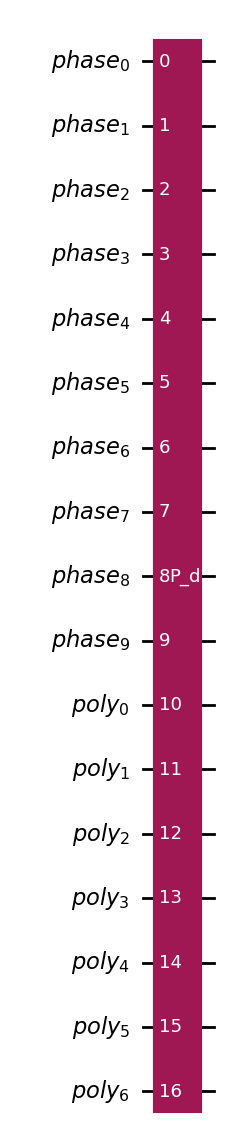

In [47]:
# ============================================================
# Cell 46 : Build Abstract P_d Lookup Gate
# ============================================================

#
# Notebook B uses an abstract lookup-table
# implementation of the reciprocal
# approximation block.
#
#
# Logical action:
#
#     |phi>|0>
#
#         -->
#
#     |phi>|omega_poly(phi)>
#
#
# The lookup values are taken from the
# phase->omega table constructed in
# Cell 45.
#
#
# This is an abstraction of the actual
# reversible Chebyshev evaluation
# architecture that will be studied
# separately in Notebook D.
#

from qiskit import QuantumCircuit
from qiskit import QuantumRegister
from qiskit.circuit import Gate


# ============================================================
# Local registers
# ============================================================

phase_pd = QuantumRegister(
    m_HHL,
    name="phase"
)

poly_pd = QuantumRegister(
    n_poly_output,
    name="poly"
)


PD_LOOKUP_CIRCUIT = QuantumCircuit(

    phase_pd,

    poly_pd,

    name="P_d"

)


# ============================================================
# Abstract lookup gate
# ============================================================

PD_LOOKUP_GATE = Gate(

    name="P_d",

    num_qubits=
        m_HHL
        +
        n_poly_output,

    params=[]

)


IPD_LOOKUP_GATE = Gate(

    name="P_d_dg",

    num_qubits=
        m_HHL
        +
        n_poly_output,

    params=[]

)


# ============================================================
# Specification
# ============================================================

PD_LOOKUP_SPECIFICATION = {

    "phase_qubits":
        m_HHL,

    "poly_qubits":
        n_poly_output,

    "lookup_entries":
        len(
            PHASE_TO_OMEGA_TABLE
        ),

    "chebyshev_degree":
        chebyshev_degree,

    "domain":
        cheb_domain,

    "outside_domain_action":
        "|phi>|0> -> |phi>|0>"
}


# ============================================================
# Resource estimate
# ============================================================

PD_RESOURCE_ESTIMATE = {

    "lookup_entries":
        len(
            PHASE_TO_OMEGA_TABLE
        ),

    "valid_entries":
        PD_LOOKUP_DATA[
            "n_valid"
        ],

    "outside_entries":
        PD_LOOKUP_DATA[
            "n_outside"
        ],

    "phase_qubits":
        m_HHL,

    "poly_qubits":
        n_poly_output,

    "chebyshev_degree":
        chebyshev_degree,

    "max_lookup_error":
        MAX_LOOKUP_ERROR
}


# ============================================================
# Visualization
# ============================================================

PD_VIEW = QuantumCircuit(

    phase_pd,

    poly_pd

)

PD_VIEW.append(

    PD_LOOKUP_GATE,

    list(phase_pd)
    +
    list(poly_pd)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Notebook B : Abstract P_d Lookup Gate")
print("=" * 70)

print()

print(
    "Logical action:"
)

print()

print(
    "|phi>|0>"
)

print(
    "   -->"
)

print(
    "|phi>|omega_poly(phi)>"
)

print()

print(
    f"Phase qubits                 : "
    f"{m_HHL}"
)

print()

print(
    f"Polynomial qubits            : "
    f"{n_poly_output}"
)

print()

print(
    f"Lookup entries               : "
    f"{len(PHASE_TO_OMEGA_TABLE)}"
)

print()

print(
    f"Chebyshev degree             : "
    f"{chebyshev_degree}"
)

print()

print(
    f"Maximum lookup error         : "
    f"{MAX_LOOKUP_ERROR:.3e}"
)

print()

print(
    "Outside-domain action:"
)

print()

print(
    "|phi>|0> --> |phi>|0>"
)

print()

print("Exported objects:")

print()

print("  PD_LOOKUP_GATE")
print("  IPD_LOOKUP_GATE")
print("  PD_LOOKUP_SPECIFICATION")
print("  PD_RESOURCE_ESTIMATE")

print()

print("=" * 70)


display(
    PD_VIEW.draw(
        "mpl",
        fold=-1
    )
)


Notebook B : Simplified HHL Architecture

Register ordering:

index | system | phase | poly | rotation

Registers:

Index register              : 3
System register             : 5
Phase register              : 10
Polynomial register         : 7
Rotation ancilla            : 1

Total qubits                : 26

Pipeline:

  1. U_b
  2. QPE(W_eff)
  3. P_d
  4. R_HHL
  5. P_d_dagger
  6. IQPE(W_eff)
  7. Measure rotation
  8. Recover |x>

Notebook A reductions:

  PREPARE register removed
  Row register removed
  Workspace register removed

  W replaced by W_eff

  P_d implemented via lookup

Exported objects:

  HHL_SIMPLIFIED_CIRCUIT
  SIMPLIFIED_ARCHITECTURE
  SIMPLIFIED_PIPELINE



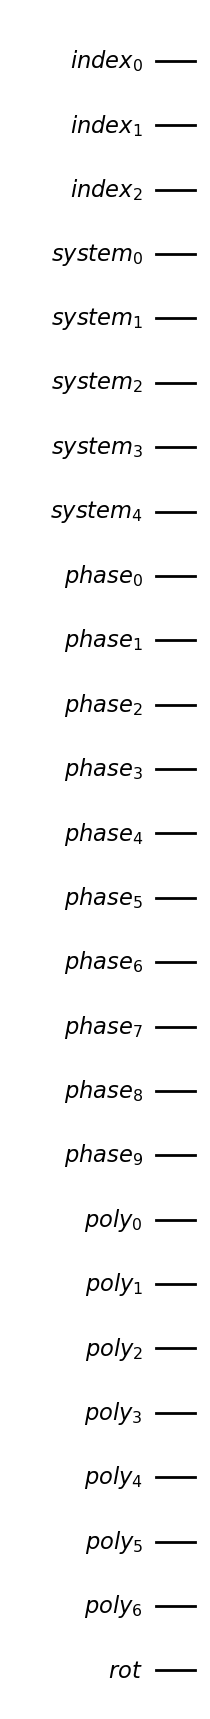

In [48]:
# ============================================================
# Cell 47 : Simplified HHL Validation Architecture
# ============================================================

#
# Notebook B uses a reduced architecture
# suitable for executable simulation.
#
#
# Full Notebook A:
#
#     index
#     prepare
#     row
#     system
#     phase
#     poly
#     workspace
#     rotation
#
#
# Notebook B:
#
#     index
#     system
#     phase
#     poly
#     rotation
#
#
# W_eff replaces the qubitization
# walk operator.
#
# P_d is implemented as a lookup.
#
# No PREPARE, SELECT, row, or
# workspace registers are required.
#

from qiskit import QuantumCircuit
from qiskit import QuantumRegister


# ============================================================
# Registers
# ============================================================

index_reg_B = QuantumRegister(
    n_index_reg,
    name="index"
)

system_reg_B = QuantumRegister(
    n_system_reg,
    name="system"
)

phase_reg_B = QuantumRegister(
    m_HHL,
    name="phase"
)

poly_reg_B = QuantumRegister(
    n_poly_output,
    name="poly"
)

rotation_reg_B = QuantumRegister(
    1,
    name="rot"
)


# ============================================================
# Master circuit
# ============================================================

HHL_SIMPLIFIED_CIRCUIT = QuantumCircuit(

    index_reg_B,

    system_reg_B,

    phase_reg_B,

    poly_reg_B,

    rotation_reg_B,

    name="HHL_B"

)


# ============================================================
# Architecture specification
# ============================================================

SIMPLIFIED_ARCHITECTURE = {

    "index_qubits":
        n_index_reg,

    "system_qubits":
        n_system_reg,

    "phase_qubits":
        m_HHL,

    "poly_qubits":
        n_poly_output,

    "rotation_qubits":
        1,

    "total_qubits":
        (
            n_index_reg
            +
            n_system_reg
            +
            m_HHL
            +
            n_poly_output
            +
            1
        )

}


# ============================================================
# Logical pipeline
# ============================================================

SIMPLIFIED_PIPELINE = [

    "U_b",

    "QPE(W_eff)",

    "P_d",

    "R_HHL",

    "P_d_dagger",

    "IQPE(W_eff)",

    "Measure rotation",

    "Recover |x>"

]


# ============================================================
# Visualization
# ============================================================

ARCH_VIEW = QuantumCircuit(

    index_reg_B,

    system_reg_B,

    phase_reg_B,

    poly_reg_B,

    rotation_reg_B

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Notebook B : Simplified HHL Architecture")
print("=" * 70)

print()

print("Register ordering:")

print()

print(
    "index | system | phase | poly | rotation"
)

print()

print("Registers:")

print()

print(
    f"Index register              : "
    f"{n_index_reg}"
)

print(
    f"System register             : "
    f"{n_system_reg}"
)

print(
    f"Phase register              : "
    f"{m_HHL}"
)

print(
    f"Polynomial register         : "
    f"{n_poly_output}"
)

print(
    f"Rotation ancilla            : "
    f"{1}"
)

print()

print(
    f"Total qubits                : "
    f"{SIMPLIFIED_ARCHITECTURE['total_qubits']}"
)

print()

print("Pipeline:")

print()

for k, step in enumerate(
    SIMPLIFIED_PIPELINE,
    start=1
):

    print(
        f"  {k}. {step}"
    )

print()

print("Notebook A reductions:")

print()

print(
    "  PREPARE register removed"
)

print(
    "  Row register removed"
)

print(
    "  Workspace register removed"
)

print()

print(
    "  W replaced by W_eff"
)

print()

print(
    "  P_d implemented via lookup"
)

print()

print("Exported objects:")

print()

print(
    "  HHL_SIMPLIFIED_CIRCUIT"
)

print(
    "  SIMPLIFIED_ARCHITECTURE"
)

print(
    "  SIMPLIFIED_PIPELINE"
)

print()

print("=" * 70)


display(
    ARCH_VIEW.draw(
        "mpl",
        fold=-1
    )
)


Notebook B : Executable W_eff Gate

System dimension             : 32

System qubits                : 5

Unitary size                 : 32 x 32

Unitarity error              : 8.382e-13

Logical action:

|u_j>
   -->
exp(i theta_j) |u_j>

Exported objects:

  W_EFF_GATE
  W_EFF_DAGGER_GATE
  CONTROLLED_W_EFF_GATE
  W_EFF_RESOURCE_ESTIMATE



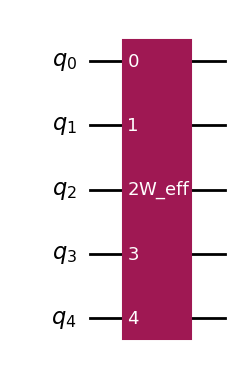

In [49]:
# ============================================================
# Cell 48 : Build Executable W_eff Gate
# ============================================================

#
# W_eff was constructed spectrally
# in Cell 43.
#
# Since N = 32,
#
#     W_eff
#
# is only a 32 x 32 unitary matrix.
#
# We therefore convert it into an
# executable UnitaryGate.
#
#
# Logical action:
#
#     |u_j>
#
#         -->
#
#     exp(i theta_j) |u_j>
#

import numpy as np

from scipy.linalg import norm

from qiskit import QuantumCircuit

from qiskit.circuit.library import UnitaryGate


# ============================================================
# Dimension checks
# ============================================================

EXPECTED_DIMENSION = (
    2 ** n_system_reg
)

ACTUAL_DIMENSION = (
    W_EFF.shape[0]
)

assert (
    ACTUAL_DIMENSION
    ==
    EXPECTED_DIMENSION
), "Dimension mismatch."


# ============================================================
# Unitarity verification
# ============================================================

W_EFF_UNITARITY_ERROR = norm(

    W_EFF.conj().T
    @
    W_EFF

    -

    np.eye(
        ACTUAL_DIMENSION
    )

)


# ============================================================
# Build executable gate
# ============================================================

W_EFF_GATE = (

    UnitaryGate(

        W_EFF,

        label="W_eff"

    )

)


W_EFF_DAGGER_GATE = (

    W_EFF_GATE.inverse()

)


# ============================================================
# Controlled version
# ============================================================

CONTROLLED_W_EFF_GATE = (

    W_EFF_GATE.control(
        1
    )

)


# ============================================================
# Resource estimate
# ============================================================

#
# Dense synthesis estimate.
#
# Qiskit decomposition will
# depend on transpiler settings.
#

W_EFF_RESOURCE_ESTIMATE = {

    "dimension":

        ACTUAL_DIMENSION,

    "system_qubits":

        n_system_reg,

    "unitarity_error":

        W_EFF_UNITARITY_ERROR

}


# ============================================================
# Visualization
# ============================================================

W_VIEW = QuantumCircuit(
    n_system_reg
)

W_VIEW.append(

    W_EFF_GATE,

    range(
        n_system_reg
    )

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Notebook B : Executable W_eff Gate")
print("=" * 70)

print()

print(
    f"System dimension             : "
    f"{ACTUAL_DIMENSION}"
)

print()

print(
    f"System qubits                : "
    f"{n_system_reg}"
)

print()

print(
    f"Unitary size                 : "
    f"{ACTUAL_DIMENSION} x "
    f"{ACTUAL_DIMENSION}"
)

print()

print(
    f"Unitarity error              : "
    f"{W_EFF_UNITARITY_ERROR:.3e}"
)

print()

print("Logical action:")

print()

print(
    "|u_j>"
)

print(
    "   -->"
)

print(
    "exp(i theta_j) |u_j>"
)

print()

print("Exported objects:")

print()

print(
    "  W_EFF_GATE"
)

print(
    "  W_EFF_DAGGER_GATE"
)

print(
    "  CONTROLLED_W_EFF_GATE"
)

print(
    "  W_EFF_RESOURCE_ESTIMATE"
)

print()

print("=" * 70)


display(
    W_VIEW.draw(
        "mpl",
        fold=-1
    )
)


Notebook B : Executable QPE(W_eff)

System qubits               : 5

Phase qubits                : 10

Controlled powers           : 10

Largest power               : 512

Phase precision             : 1.00e-03

Exported objects:

  QPE_W_EFF_GATE
  IQPE_W_EFF_GATE
  W_EFF_POWER_MATRICES
  W_EFF_POWER_GATES
  QPE_W_EFF_RESOURCE_ESTIMATE
  QPE_W_EFF_CIRCUIT
  IQPE_W_EFF_CIRCUIT



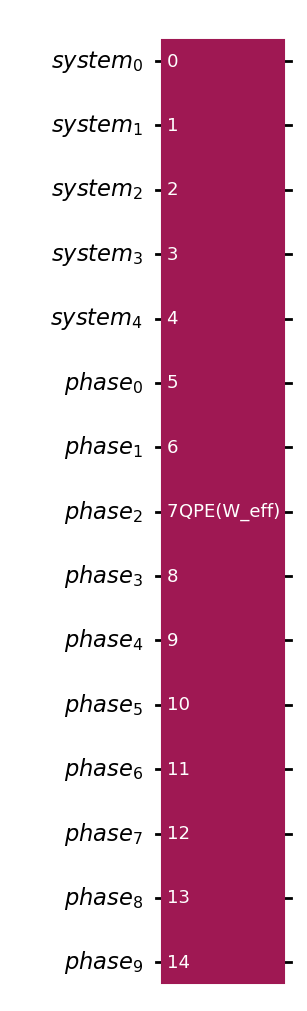

In [50]:
# ============================================================
# Cell 49 : Build Executable QPE(W_eff)
# ============================================================

#
# Build an executable QPE block using
# the spectral representation of W_eff.
#
#
# W_eff
#
#     =
#
# U diag(exp(i theta_j)) U†
#
#
# Therefore
#
# W_eff^(2^k)
#
#     =
#
# U diag(exp(i 2^k theta_j)) U†
#
#
# Unlike Notebook A, this QPE is fully
# executable.
#

import numpy as np

from scipy.linalg import norm

from qiskit import QuantumCircuit
from qiskit import QuantumRegister

from qiskit.circuit.library import (
    QFT,
    UnitaryGate
)


# ============================================================
# Local QPE registers
# ============================================================

system_qpe_B = QuantumRegister(
    n_system_reg,
    name="system"
)

phase_qpe_B = QuantumRegister(
    m_HHL,
    name="phase"
)


QPE_W_EFF_CIRCUIT = QuantumCircuit(

    system_qpe_B,

    phase_qpe_B,

    name="QPE_WEFF"

)


# ============================================================
# Powers required by QPE
# ============================================================

QPE_POWER_LIST_B = [

    2**k

    for k in range(
        m_HHL
    )

]


# ============================================================
# Construct W_eff powers
# ============================================================

W_EFF_POWER_MATRICES = {}

W_EFF_POWER_GATES = {}


for power in QPE_POWER_LIST_B:

    W_POWER = (

        EIGENVECTORS

        @

        np.diag(

            np.exp(
                1j
                *
                power
                *
                THETA_VALUES
            )

        )

        @

        EIGENVECTORS.conj().T

    )

    POWER_ERROR = norm(

        W_POWER.conj().T
        @
        W_POWER

        -

        np.eye(
            W_POWER.shape[0]
        )

    )

    W_EFF_POWER_MATRICES[
        power
    ] = W_POWER

    W_EFF_POWER_GATES[
        power
    ] = UnitaryGate(

        W_POWER,

        label=f"W^{power}"

    )


# ============================================================
# Initial Hadamards
# ============================================================

for q in range(
    m_HHL
):

    QPE_W_EFF_CIRCUIT.h(
        phase_qpe_B[q]
    )


QPE_W_EFF_CIRCUIT.barrier()


# ============================================================
# Controlled powers
# ============================================================

#
# Same convention as Notebook A:
#
# phase[m-1-k]
#
# controls
#
# W^(2^k)
#

for k in range(
    m_HHL
):

    power = (
        2**k
    )

    CONTROLLED_GATE = (

        W_EFF_POWER_GATES[
            power
        ]

        .control(1)

    )

    QPE_W_EFF_CIRCUIT.append(

        CONTROLLED_GATE,

        [phase_qpe_B[
            m_HHL - 1 - k
        ]]

        +

        list(
            system_qpe_B
        )

    )


QPE_W_EFF_CIRCUIT.barrier()


# ============================================================
# IQFT
# ============================================================

IQFT_GATE = (

    QFT(

        num_qubits=m_HHL,

        inverse=True,

        do_swaps=False

    )

    .to_gate(
        label="IQFT"
    )

)

QPE_W_EFF_CIRCUIT.append(

    IQFT_GATE,

    phase_qpe_B

)


# ============================================================
# Remove barriers
# ============================================================

QPE_W_EFF_NO_BARRIERS = (
    QPE_W_EFF_CIRCUIT.copy()
)

QPE_W_EFF_NO_BARRIERS.data = [

    inst

    for inst in
    QPE_W_EFF_NO_BARRIERS.data

    if inst.operation.name
    != "barrier"

]


# ============================================================
# Convert to gate
# ============================================================

QPE_W_EFF_GATE = (

    QPE_W_EFF_NO_BARRIERS

    .to_gate(

        label="QPE(W_eff)"

    )

)


# ============================================================
# Explicit inverse-QPE
# ============================================================

IQPE_W_EFF_CIRCUIT = QuantumCircuit(

    system_qpe_B,

    phase_qpe_B,

    name="IQPE_WEFF"

)


# ------------------------------------------------------------
# QFT
# ------------------------------------------------------------

QFT_GATE = (

    QFT(

        num_qubits=m_HHL,

        inverse=False,

        do_swaps=False

    )

    .to_gate(
        label="QFT"
    )

)

IQPE_W_EFF_CIRCUIT.append(

    QFT_GATE,

    phase_qpe_B

)


# ------------------------------------------------------------
# Controlled inverse powers
# ------------------------------------------------------------

for k in reversed(
    range(m_HHL)
):

    power = (
        2**k
    )

    CONTROLLED_DAGGER = (

        W_EFF_POWER_GATES[
            power
        ]

        .inverse()

        .control(1)

    )

    IQPE_W_EFF_CIRCUIT.append(

        CONTROLLED_DAGGER,

        [phase_qpe_B[
            m_HHL - 1 - k
        ]]

        +

        list(
            system_qpe_B
        )

    )


# ------------------------------------------------------------
# Hadamards
# ------------------------------------------------------------

for q in range(
    m_HHL
):

    IQPE_W_EFF_CIRCUIT.h(
        phase_qpe_B[q]
    )


# ------------------------------------------------------------
# Convert to gate
# ------------------------------------------------------------

IQPE_W_EFF_GATE = (

    IQPE_W_EFF_CIRCUIT

    .to_gate(

        label="IQPE(W_eff)"

    )

)


# ============================================================
# Resource summary
# ============================================================

QPE_W_EFF_RESOURCE_ESTIMATE = {

    "phase_qubits":
        m_HHL,

    "system_qubits":
        n_system_reg,

    "powers":
        QPE_POWER_LIST_B,

    "largest_power":
        max(
            QPE_POWER_LIST_B
        )

}


# ============================================================
# Visualization
# ============================================================

QPE_VIEW_B = QuantumCircuit(

    system_qpe_B,

    phase_qpe_B

)

QPE_VIEW_B.append(

    QPE_W_EFF_GATE,

    list(system_qpe_B)
    +
    list(phase_qpe_B)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Notebook B : Executable QPE(W_eff)")
print("=" * 70)

print()

print(
    f"System qubits               : "
    f"{n_system_reg}"
)

print()

print(
    f"Phase qubits                : "
    f"{m_HHL}"
)

print()

print(
    f"Controlled powers           : "
    f"{len(QPE_POWER_LIST_B)}"
)

print()

print(
    f"Largest power               : "
    f"{max(QPE_POWER_LIST_B)}"
)

print()

print(
    f"Phase precision             : "
    f"{EPSILON_QPE_PHASE:.2e}"
)

print()

print("Exported objects:")

print()

print(
    "  QPE_W_EFF_GATE"
)

print(
    "  IQPE_W_EFF_GATE"
)

print(
    "  W_EFF_POWER_MATRICES"
)

print(
    "  W_EFF_POWER_GATES"
)

print(
    "  QPE_W_EFF_RESOURCE_ESTIMATE"
)

print(
    "  QPE_W_EFF_CIRCUIT"
)

print(
    "  IQPE_W_EFF_CIRCUIT"
)

print()

print("=" * 70)

display(
    QPE_VIEW_B.draw(
        "mpl",
        fold=-1
    )
)

In [51]:
# ============================================================
# Cell 49A : Validate QPE(W_eff)
# ============================================================

from qiskit import transpile


# ============================================================
# Execution helper
# ============================================================

def prepare_for_execution(
    circuit,
    backend,
    optimization_level=1,
    decompose_reps=0
):
    """
    Convert a logical circuit containing
    custom gates into an executable
    circuit for the chosen backend.
    """

    qc = circuit.copy()

    for _ in range(
        decompose_reps
    ):
        qc = qc.decompose()

    return transpile(

        qc,

        backend,

        optimization_level=
            optimization_level

    )


RUN_VALIDATION_CELL_49A = True


if RUN_VALIDATION_CELL_49A:

    import numpy as np

    from qiskit import QuantumCircuit
    from qiskit import QuantumRegister
    from qiskit import ClassicalRegister

    from qiskit.circuit.library import Initialize

    from qiskit_aer import AerSimulator


    # ========================================================
    # Random eigenvector
    # ========================================================

    rng = np.random.default_rng(
        SEED
    )

    TEST_EIGEN_INDEX = int(

        rng.integers(

            low=0,

            high=len(
                EIGENVECTORS
            )

        )

    )


    TEST_EIGENVECTOR = (

        EIGENVECTORS[
            :,
            TEST_EIGEN_INDEX
        ]

    )


    EXPECTED_PHASE = (

        PHASE_VALUES[
            TEST_EIGEN_INDEX
        ]

    )


    EXPECTED_BIT_INT = int(

        np.round(

            EXPECTED_PHASE

            *

            (
                2**m_HHL
            )

        )

    )


    EXPECTED_BITSTRING = format(

        EXPECTED_BIT_INT

        %

        (
            2**m_HHL
        ),

        f"0{m_HHL}b"

    )


    # ========================================================
    # Registers
    # ========================================================

    system_reg_test = QuantumRegister(

        n_system_reg,

        name="system"

    )
    
    phase_reg_test = QuantumRegister(

        m_HHL,

        name="phase"

    )

    
    phase_classical = ClassicalRegister(

        m_HHL,

        name="c_phase"

    )


    VALIDATION_CIRCUIT = QuantumCircuit(

        system_reg_test,

        phase_reg_test,

        phase_classical

    )


    # ========================================================
    # Prepare eigenvector
    # ========================================================

    INIT_GATE = Initialize(
        TEST_EIGENVECTOR
    )

    VALIDATION_CIRCUIT.append(

        INIT_GATE,

        system_reg_test

    )

    VALIDATION_CIRCUIT.barrier()


    # ========================================================
    # QPE(W_eff)
    # ========================================================

    VALIDATION_CIRCUIT.compose(

        QPE_W_EFF_CIRCUIT,

        qubits=

            list(
                system_reg_test
            )

            +

            list(
                phase_reg_test
            ),

        inplace=True

    )

    VALIDATION_CIRCUIT.barrier()


    # ========================================================
    # Measure phase register
    # ========================================================

    VALIDATION_CIRCUIT.measure(

        phase_reg_test,

        phase_classical

    )


    # ========================================================
    # Execute
    # ========================================================

    SHOTS = 4096

    backend = AerSimulator()


    EXECUTABLE_VALIDATION_CIRCUIT = (

        prepare_for_execution(

            VALIDATION_CIRCUIT,

            backend,

            optimization_level=1,

            decompose_reps=0

        )

    )


    result = backend.run(

        EXECUTABLE_VALIDATION_CIRCUIT,

        shots=SHOTS

    ).result()


    COUNTS = result.get_counts()


    MOST_LIKELY_BITSTRING = max(

        COUNTS,

        key=COUNTS.get

    )


    MOST_LIKELY_PROBABILITY = (

        COUNTS[
            MOST_LIKELY_BITSTRING
        ]

        /

        SHOTS

    )


    # ========================================================
    # Summary
    # ========================================================

    print("\n" + "=" * 70)
    print("Cell 49A : QPE Validation")
    print("=" * 70)

    print()

    print(
        f"Eigenvector index           : "
        f"{TEST_EIGEN_INDEX}"
    )

    print()

    print(
        f"Expected phase              : "
        f"{EXPECTED_PHASE:.10f}"
    )

    print()

    print(
        f"Expected bitstring          : "
        f"{EXPECTED_BITSTRING}"
    )

    print()

    print(
        f"Observed bitstring          : "
        f"{MOST_LIKELY_BITSTRING}"
    )

    print()

    print(
        f"Observed probability        : "
        f"{MOST_LIKELY_PROBABILITY:.4f}"
    )

    print()

    print(
        "Top outcomes:"
    )

    print()

    TOP_COUNTS = sorted(

        COUNTS.items(),

        key=lambda x: x[1],

        reverse=True

    )[:10]


    for bitstring, count in TOP_COUNTS:

        print(

            f"{bitstring:>15s}"

            f" : "

            f"{count}"

        )

    print()

    OBSERVED_INT = int(MOST_LIKELY_BITSTRING, 2)
    
    OBSERVED_PHASE = (
        OBSERVED_INT
        /
        (2**m_HHL)
    )
    
    print(
        f"Observed phase              : "
        f"{OBSERVED_PHASE:.10f}"
    )
    
    print(
        f"Absolute phase error        : "
        f"{abs(OBSERVED_PHASE - EXPECTED_PHASE):.3e}"
    )

    print("=" * 70)

else:

    print(
        "Cell 49A skipped."
    )


Cell 49A : QPE Validation

Eigenvector index           : 2

Expected phase              : 0.2340578598

Expected bitstring          : 0011110000

Observed bitstring          : 0011110000

Observed probability        : 0.6943

Top outcomes:

     0011110000 : 2844
     0011101111 : 627
     0011110001 : 170
     0011101110 : 129
     0011110010 : 63
     0011101101 : 44
     0011110011 : 30
     0011101100 : 28
     0011110100 : 18
     0011101011 : 17

Observed phase              : 0.2343750000
Absolute phase error        : 3.171e-04



Notebook B : P_d / P_d†

Phase qubits                : 10

Poly qubits                 : 7

Lookup entries              : 1024

Max lookup error            : 4.015e-03

Exported objects:

  PD_GATE
  IPD_GATE
  PD_SPECIFICATION
  PD_RESOURCE_ESTIMATE



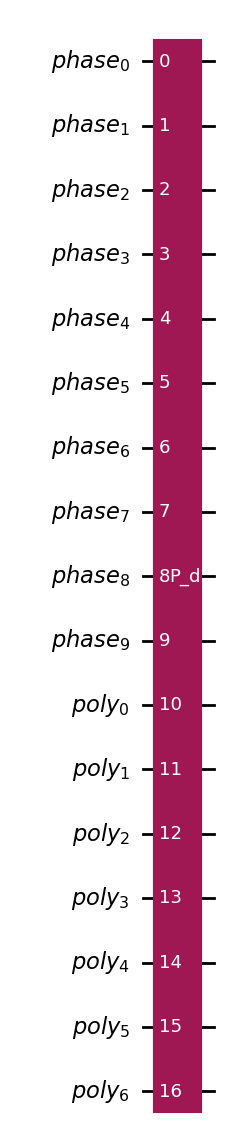

In [52]:
# ============================================================
# Cell 50 : P_d and P_d† Blocks
# ============================================================

#
# P_d and P_d† remain logical operators
# in Notebook B.
#
# Their action is implemented later
# through coherent spectral lookup.
#

from qiskit import QuantumCircuit
from qiskit import QuantumRegister
from qiskit.circuit import Gate


# ============================================================
# Local registers
# ============================================================

phase_pd = QuantumRegister(
    m_HHL,
    name="phase"
)

poly_pd = QuantumRegister(
    n_poly_output,
    name="poly"
)


# ============================================================
# P_d
# ============================================================

PD_GATE = Gate(

    name="P_d",

    num_qubits=
        m_HHL
        +
        n_poly_output,

    params=[]

)


# ============================================================
# P_d dagger
# ============================================================

IPD_GATE = Gate(

    name="P_d_dg",

    num_qubits=
        m_HHL
        +
        n_poly_output,

    params=[]

)


# ============================================================
# Specifications
# ============================================================

PD_SPECIFICATION = {

    "input_register":
        "phase",

    "output_register":
        "poly",

    "lookup_entries":
        len(
            PHASE_TO_OMEGA_TABLE
        ),

    "phase_qubits":
        m_HHL,

    "poly_qubits":
        n_poly_output,

    "implementation":
        "spectral_lookup"

}


PD_RESOURCE_ESTIMATE = {

    "phase_states":
        len(
            PHASE_TO_OMEGA_TABLE
        ),

    "valid_entries":
        PD_LOOKUP_DATA[
            "n_valid"
        ],

    "outside_entries":
        PD_LOOKUP_DATA[
            "n_outside"
        ],

    "phase_qubits":
        m_HHL,

    "poly_qubits":
        n_poly_output

}


# ============================================================
# Visualization
# ============================================================

PD_VIEW = QuantumCircuit(

    phase_pd,

    poly_pd

)

PD_VIEW.append(

    PD_GATE,

    list(phase_pd)
    +
    list(poly_pd)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Notebook B : P_d / P_d†")
print("=" * 70)

print()

print(
    f"Phase qubits                : "
    f"{m_HHL}"
)

print()

print(
    f"Poly qubits                 : "
    f"{n_poly_output}"
)

print()

print(
    f"Lookup entries              : "
    f"{len(PHASE_TO_OMEGA_TABLE)}"
)

print()

print(
    f"Max lookup error            : "
    f"{MAX_LOOKUP_ERROR:.3e}"
)

print()

print("Exported objects:")

print()

print("  PD_GATE")
print("  IPD_GATE")
print("  PD_SPECIFICATION")
print("  PD_RESOURCE_ESTIMATE")

print()

print("=" * 70)

display(
    PD_VIEW.draw(
        "mpl",
        fold=-1
    )
)

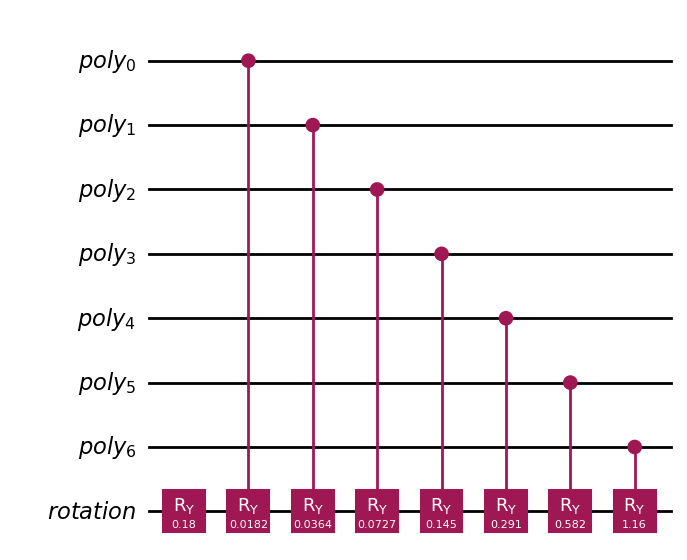


Notebook B : Executable R_HHL

Poly qubits                 : 7

Omega min                   : 0.0901219489
Omega max                   : 1.2448760447

Omega range                 : 1.1547540958

Controlled rotations        : 7

Exported objects:

  R_HHL_CIRCUIT
  R_HHL_GATE_B
  R_HHL_RESOURCE_ESTIMATE



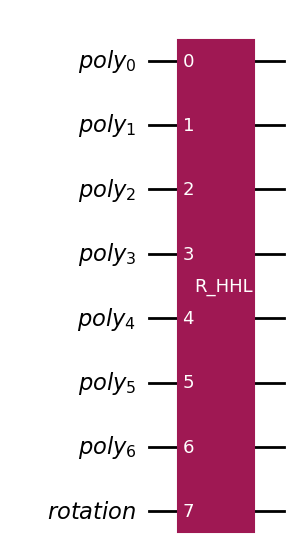

In [53]:
# ============================================================
# Cell 51 : Executable R_HHL
# ============================================================

#
# Poly register stores:
#
#     omega
#
# encoded as
#
#     omega
#
#       =
#
#     omega_min
#
#       +
#
#     k/(2^p-1)
#
#     *
#
#     (omega_max-omega_min)
#
#
# This circuit implements
#
#     R_y(2 omega)
#
# on the rotation ancilla.
#

import numpy as np

from qiskit import QuantumCircuit
from qiskit import QuantumRegister

from qiskit.circuit.library import RYGate


# ============================================================
# Registers
# ============================================================

poly_rot = QuantumRegister(
    n_poly_output,
    name="poly"
)

rotation_rot = QuantumRegister(
    1,
    name="rotation"
)


R_HHL_CIRCUIT = QuantumCircuit(

    poly_rot,

    rotation_rot,

    name="R_HHL"

)


# ============================================================
# Omega interval
# ============================================================

OMEGA_MIN = (
    rotation_angle_min
)

OMEGA_MAX = (
    rotation_angle_max
)

OMEGA_RANGE = (
    OMEGA_MAX
    -
    OMEGA_MIN
)

MAX_POLY_INTEGER = (
    2**n_poly_output
    -
    1
)


# ============================================================
# Constant offset
# ============================================================

#
# Implements:
#
#     R_y(2 omega_min)
#

R_HHL_CIRCUIT.ry(

    2.0 * OMEGA_MIN,

    rotation_rot[0]

)


# ============================================================
# Bitwise contributions
# ============================================================

for bit in range(
    n_poly_output
):

    delta_theta = (

        2.0
        *
        OMEGA_RANGE
        *
        (2**bit)
        /
        MAX_POLY_INTEGER

    )

    CONTROLLED_RY = (

        RYGate(
            delta_theta
        )

        .control(1)

    )

    R_HHL_CIRCUIT.append(

        CONTROLLED_RY,

        [

            poly_rot[bit],

            rotation_rot[0]

        ]

    )


from IPython.display import display
display(
    R_HHL_CIRCUIT.draw("mpl")
)
 
# ============================================================
# Convert to gate
# ============================================================

R_HHL_GATE_B = (

    R_HHL_CIRCUIT

    .to_gate(

        label="R_HHL"

    )

)


# ============================================================
# Resource summary
# ============================================================

R_HHL_RESOURCE_ESTIMATE = {

    "poly_qubits":
        n_poly_output,

    "controlled_rotations":
        n_poly_output,

    "omega_min":
        OMEGA_MIN,

    "omega_max":
        OMEGA_MAX

}


# ============================================================
# Visualization
# ============================================================

R_HHL_VIEW = QuantumCircuit(

    poly_rot,

    rotation_rot

)

R_HHL_VIEW.append(

    R_HHL_GATE_B,

    list(poly_rot)
    +
    list(rotation_rot)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Notebook B : Executable R_HHL")
print("=" * 70)

print()

print(
    f"Poly qubits                 : "
    f"{n_poly_output}"
)

print()

print(
    f"Omega min                   : "
    f"{OMEGA_MIN:.10f}"
)

print(
    f"Omega max                   : "
    f"{OMEGA_MAX:.10f}"
)

print()

print(
    f"Omega range                 : "
    f"{OMEGA_RANGE:.10f}"
)

print()

print(
    f"Controlled rotations        : "
    f"{n_poly_output}"
)

print()

print("Exported objects:")

print()

print("  R_HHL_CIRCUIT")
print("  R_HHL_GATE_B")
print("  R_HHL_RESOURCE_ESTIMATE")

print()

print("=" * 70)

display(
    R_HHL_VIEW.draw(
        "mpl",
        fold=-1
    )
)


Notebook B : Simplified HHL Architecture

Registers:

Index register              : 3
System register             : 5
Phase register              : 10
Polynomial register         : 7
Rotation ancilla            : 1

Total qubits                : 26

Pipeline:

  - U_b
  - QPE(W_eff)
  - P_d
  - R_HHL
  - P_d†
  - IQPE(W_eff)

Exported objects:

  HHL_SIMPLIFIED_CIRCUIT
  HHL_SIMPLIFIED_SPECIFICATION
  HHL_SIMPLIFIED_RESOURCE_ESTIMATE



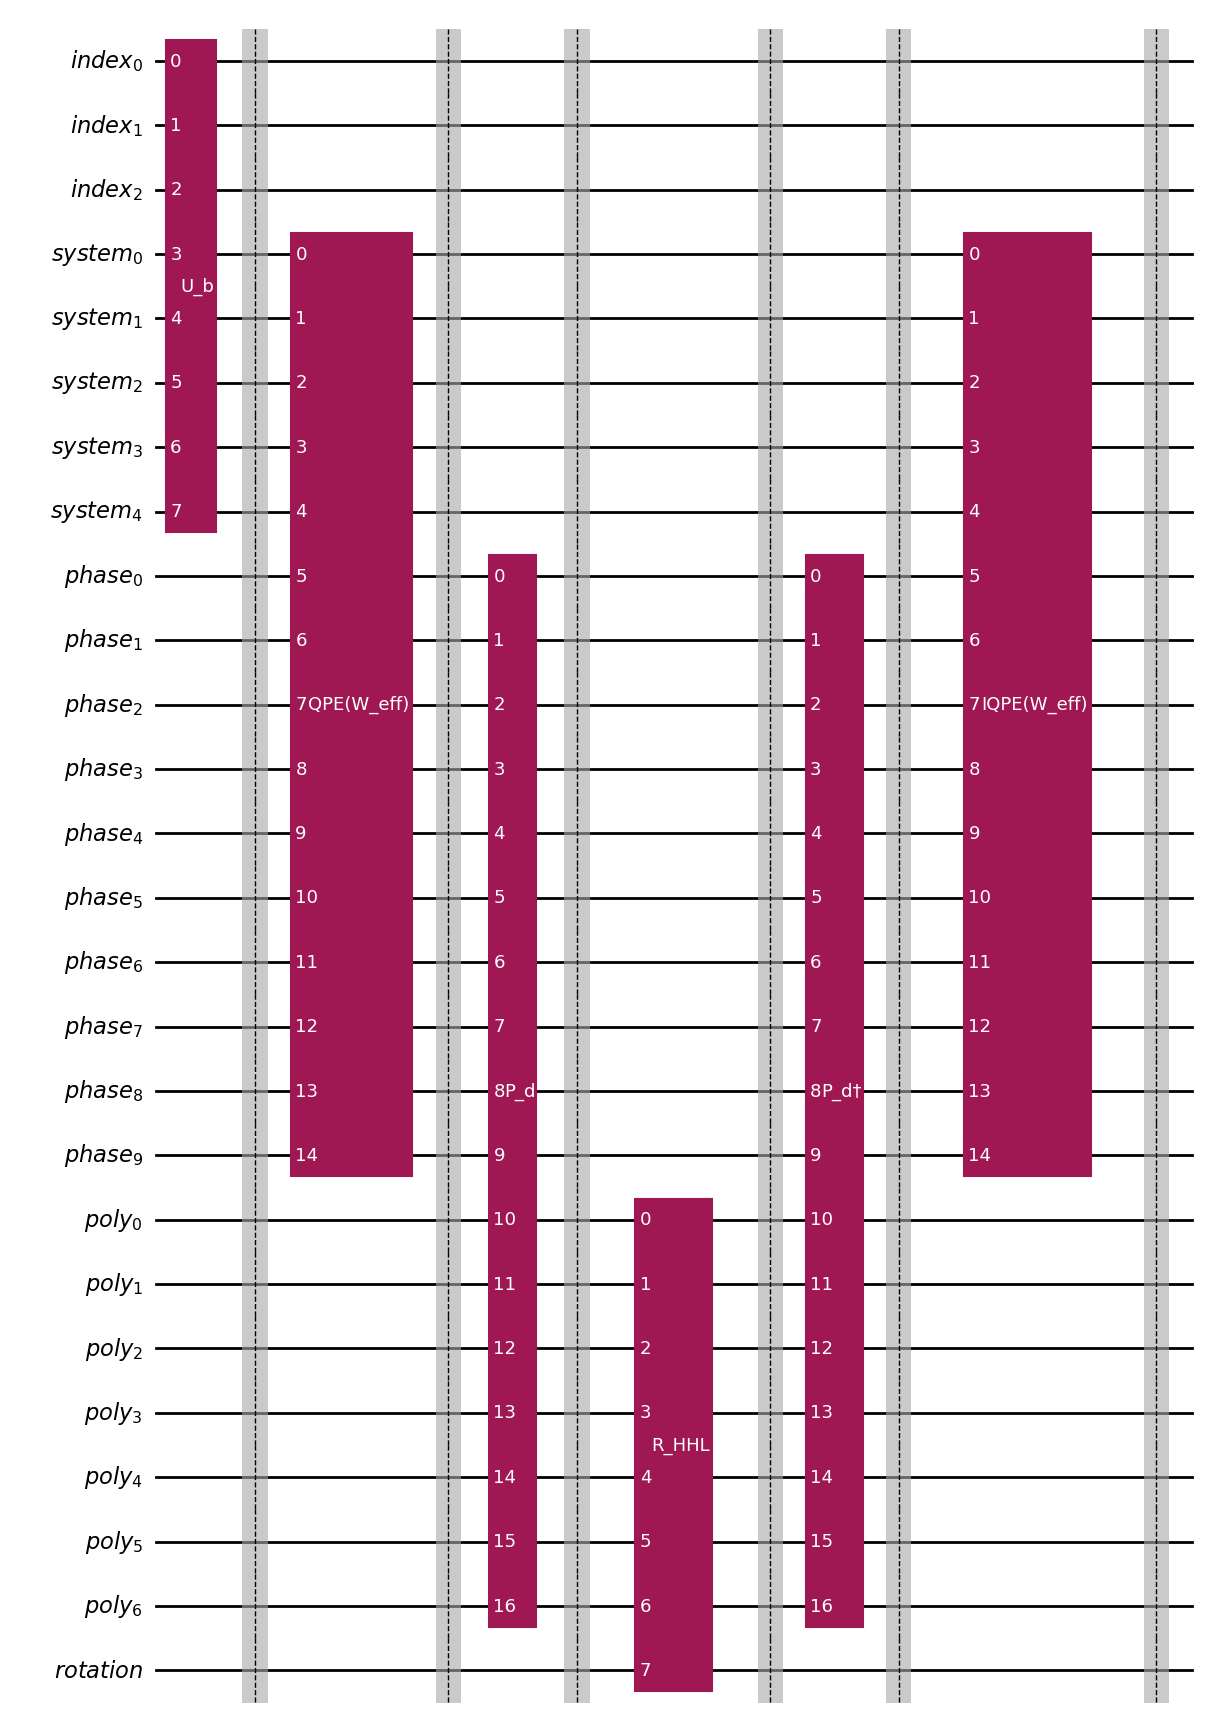

In [54]:
# ============================================================
# Cell 52 : Assemble Simplified HHL Architecture
# ============================================================

#
# Simplified Notebook B architecture:
#
#     U_b
#     QPE(W_eff)
#     P_d
#     R_HHL
#     P_d†
#     IQPE(W_eff)
#
#
# Registers retained:
#
#     index
#     system
#     phase
#     poly
#     rotation
#
#
# Registers removed:
#
#     prepare
#     row
#     workspace
#
#
# This cell assembles only the logical
# architecture.
#
# No execution occurs here.
#

from qiskit import QuantumCircuit
from qiskit import QuantumRegister


# ============================================================
# Registers
# ============================================================

index_hhl = QuantumRegister(
    n_index_reg,
    name="index"
)

system_hhl = QuantumRegister(
    n_system_reg,
    name="system"
)

phase_hhl = QuantumRegister(
    m_HHL,
    name="phase"
)

poly_hhl = QuantumRegister(
    n_poly_output,
    name="poly"
)

rotation_hhl = QuantumRegister(
    1,
    name="rotation"
)


# ============================================================
# Main circuit
# ============================================================

HHL_SIMPLIFIED_CIRCUIT = QuantumCircuit(

    index_hhl,

    system_hhl,

    phase_hhl,

    poly_hhl,

    rotation_hhl,

    name="HHL_SIMPLIFIED"

)


# ============================================================
# Symbolic gates
# ============================================================

from qiskit.circuit import Gate


UB_VIEW_GATE = Gate(

    name="U_b",

    num_qubits=
        n_index_reg
        +
        n_system_reg,

    params=[]

)


QPE_VIEW_GATE = Gate(

    name="QPE(W_eff)",

    num_qubits=
        n_system_reg
        +
        m_HHL,

    params=[]

)


PD_VIEW_GATE = Gate(

    name="P_d",

    num_qubits=
        m_HHL
        +
        n_poly_output,

    params=[]

)


ROT_VIEW_GATE = Gate(

    name="R_HHL",

    num_qubits=
        n_poly_output
        +
        1,

    params=[]

)


IPD_VIEW_GATE = Gate(

    name="P_d†",

    num_qubits=
        m_HHL
        +
        n_poly_output,

    params=[]

)


IQPE_VIEW_GATE = Gate(

    name="IQPE(W_eff)",

    num_qubits=
        n_system_reg
        +
        m_HHL,

    params=[]

)


# ============================================================
# U_b
# ============================================================

HHL_SIMPLIFIED_CIRCUIT.append(

    UB_VIEW_GATE,

    list(index_hhl)
    +
    list(system_hhl)

)

HHL_SIMPLIFIED_CIRCUIT.barrier()


# ============================================================
# QPE(W_eff)
# ============================================================

HHL_SIMPLIFIED_CIRCUIT.append(

    QPE_VIEW_GATE,

    list(system_hhl)
    +
    list(phase_hhl)

)

HHL_SIMPLIFIED_CIRCUIT.barrier()


# ============================================================
# P_d
# ============================================================

HHL_SIMPLIFIED_CIRCUIT.append(

    PD_VIEW_GATE,

    list(phase_hhl)
    +
    list(poly_hhl)

)

HHL_SIMPLIFIED_CIRCUIT.barrier()


# ============================================================
# R_HHL
# ============================================================

HHL_SIMPLIFIED_CIRCUIT.append(

    ROT_VIEW_GATE,

    list(poly_hhl)
    +
    list(rotation_hhl)

)

HHL_SIMPLIFIED_CIRCUIT.barrier()


# ============================================================
# P_d†
# ============================================================

HHL_SIMPLIFIED_CIRCUIT.append(

    IPD_VIEW_GATE,

    list(phase_hhl)
    +
    list(poly_hhl)

)

HHL_SIMPLIFIED_CIRCUIT.barrier()


# ============================================================
# IQPE(W_eff)
# ============================================================

HHL_SIMPLIFIED_CIRCUIT.append(

    IQPE_VIEW_GATE,

    list(system_hhl)
    +
    list(phase_hhl)

)

HHL_SIMPLIFIED_CIRCUIT.barrier()


# ============================================================
# Specification
# ============================================================

HHL_SIMPLIFIED_SPECIFICATION = {

    "registers": {

        "index":
            n_index_reg,

        "system":
            n_system_reg,

        "phase":
            m_HHL,

        "poly":
            n_poly_output,

        "rotation":
            1

    },

    "pipeline": [

        "U_b",

        "QPE(W_eff)",

        "P_d",

        "R_HHL",

        "P_d†",

        "IQPE(W_eff)"

    ]

}


# ============================================================
# Resource summary
# ============================================================

TOTAL_SIMPLIFIED_QUBITS = (

    n_index_reg

    +

    n_system_reg

    +

    m_HHL

    +

    n_poly_output

    +

    1

)

HHL_SIMPLIFIED_RESOURCE_ESTIMATE = {

    "total_qubits":
        TOTAL_SIMPLIFIED_QUBITS,

    "index_qubits":
        n_index_reg,

    "system_qubits":
        n_system_reg,

    "phase_qubits":
        m_HHL,

    "poly_qubits":
        n_poly_output,

    "rotation_qubits":
        1

}


# ============================================================
# Representative architecture view
# ============================================================

ARCHITECTURE_VIEW = QuantumCircuit(

    QuantumRegister(
        1,
        "index"
    ),

    QuantumRegister(
        1,
        "system"
    ),

    QuantumRegister(
        1,
        "phase"
    ),

    QuantumRegister(
        1,
        "poly"
    ),

    QuantumRegister(
        1,
        "rotation"
    )

)

ARCHITECTURE_VIEW.barrier()

ARCHITECTURE_VIEW.barrier(
    label="U_b"
)

ARCHITECTURE_VIEW.barrier(
    label="QPE(W_eff)"
)

ARCHITECTURE_VIEW.barrier(
    label="P_d"
)

ARCHITECTURE_VIEW.barrier(
    label="R_HHL"
)

ARCHITECTURE_VIEW.barrier(
    label="P_d†"
)

ARCHITECTURE_VIEW.barrier(
    label="IQPE(W_eff)"
)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Notebook B : Simplified HHL Architecture")
print("=" * 70)

print()

print("Registers:")

print()

print(
    f"Index register              : "
    f"{n_index_reg}"
)

print(
    f"System register             : "
    f"{n_system_reg}"
)

print(
    f"Phase register              : "
    f"{m_HHL}"
)

print(
    f"Polynomial register         : "
    f"{n_poly_output}"
)

print(
    f"Rotation ancilla            : "
    f"1"
)

print()

print(
    f"Total qubits                : "
    f"{TOTAL_SIMPLIFIED_QUBITS}"
)

print()

print("Pipeline:")

print()

for step in HHL_SIMPLIFIED_SPECIFICATION["pipeline"]:

    print(
        f"  - {step}"
    )

print()

print("Exported objects:")

print()

print(
    "  HHL_SIMPLIFIED_CIRCUIT"
)

print(
    "  HHL_SIMPLIFIED_SPECIFICATION"
)

print(
    "  HHL_SIMPLIFIED_RESOURCE_ESTIMATE"
)

print()

print("=" * 70)

display(
    HHL_SIMPLIFIED_CIRCUIT.draw(
        "mpl",
        fold=-1
    )
)


In [55]:
# ============================================================
# Cell 53 : Classical Reference Solution and Execution Setup
# ============================================================

#
# This cell prepares all data needed for the
# executable HHL validation run in Cell 54.
#
# Tasks:
#
#   1. Construct |b>
#   2. Construct classical solution
#
#          x = A^{-1} b
#
#   3. Normalize x
#   4. Define register layout
#   5. Estimate statevector memory
#   6. Initialize timing machinery
#

import time
import numpy as np

from scipy.sparse.linalg import spsolve


# ============================================================
# Global timer
# ============================================================

CELL53_START_TIME = time.time()


# ============================================================
# Construct |b>
# ============================================================

#
# Support set already includes dummy nodes.
#
#     B_STATE_SUPPORT = S
#
# from Cell 23.
#

b_vector = np.zeros(
    N,
    dtype=np.float64
)

for node in B_STATE_SUPPORT:

    b_vector[node] = (
        1.0
        /
        np.sqrt(
            B_STATE_DELTA
        )
    )


# ============================================================
# Verify normalization
# ============================================================

B_VECTOR_NORM = np.linalg.norm(
    b_vector
)

assert np.isclose(
    B_VECTOR_NORM,
    1.0,
    atol=1e-12
)


# ============================================================
# Classical solution
# ============================================================

#
# Solve:
#
#     A x = b
#
#

A_DENSE = A.toarray()

x_classical = np.linalg.solve(

    A_DENSE,

    b_vector

)


# ============================================================
# Normalize solution
# ============================================================

X_CLASSICAL_NORM = np.linalg.norm(
    x_classical
)

x_classical_normalized = (

    x_classical
    /
    X_CLASSICAL_NORM

)


# ============================================================
# Condition-number diagnostics
# ============================================================

CLASSICAL_RESIDUAL = np.linalg.norm(

    A_DENSE
    @
    x_classical

    -
    b_vector

)


# ============================================================
# Register layout
# ============================================================

#
# Physical architecture:
#
# index | system | phase | poly | rotation
#

REGISTER_LAYOUT = {

    "index": {

        "start": 0,

        "end":
            n_index_reg - 1,

        "size":
            n_index_reg

    },

    "system": {

        "start":
            n_index_reg,

        "end":
            n_index_reg
            +
            n_system_reg
            -
            1,

        "size":
            n_system_reg

    },

    "phase": {

        "start":
            n_index_reg
            +
            n_system_reg,

        "end":
            n_index_reg
            +
            n_system_reg
            +
            m_HHL
            -
            1,

        "size":
            m_HHL

    },

    "poly": {

        "start":
            n_index_reg
            +
            n_system_reg
            +
            m_HHL,

        "end":
            n_index_reg
            +
            n_system_reg
            +
            m_HHL
            +
            n_poly_output
            -
            1,

        "size":
            n_poly_output

    },

    "rotation": {

        "start":
            (
                n_index_reg
                +
                n_system_reg
                +
                m_HHL
                +
                n_poly_output
            ),

        "end":
            (
                n_index_reg
                +
                n_system_reg
                +
                m_HHL
                +
                n_poly_output
            ),

        "size":
            1

    }

}


# ============================================================
# Total state size
# ============================================================

TOTAL_EXECUTION_QUBITS = (

    n_index_reg

    +

    n_system_reg

    +

    m_HHL

    +

    n_poly_output

    +

    1

)

TOTAL_STATE_DIMENSION = (

    2
    **
    TOTAL_EXECUTION_QUBITS

)

STATEVECTOR_BYTES = (

    TOTAL_STATE_DIMENSION
    *
    16
)

STATEVECTOR_GIB = (

    STATEVECTOR_BYTES
    /
    (
        1024**3
    )

)


# ============================================================
# Execution metadata
# ============================================================

CELL54_EXECUTION_SETUP = {

    "total_qubits":
        TOTAL_EXECUTION_QUBITS,

    "state_dimension":
        TOTAL_STATE_DIMENSION,

    "statevector_gib":
        STATEVECTOR_GIB,

    "register_layout":
        REGISTER_LAYOUT,

    "b_vector":
        b_vector,

    "x_classical":
        x_classical,

    "x_classical_normalized":
        x_classical_normalized

}


# ============================================================
# Timing
# ============================================================

CELL53_RUNTIME = (
    time.time()
    -
    CELL53_START_TIME
)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Cell 53 : Classical Reference Solution")
print("=" * 70)

print()

print(
    f"N                               : "
    f"{N}"
)

print()

print(
    f"Support size (delta)            : "
    f"{B_STATE_DELTA}"
)

print()

print(
    f"||b||                           : "
    f"{B_VECTOR_NORM:.12f}"
)

print()

print(
    f"||x_classical||                 : "
    f"{X_CLASSICAL_NORM:.12f}"
)

print()

print(
    f"Residual ||Ax-b||               : "
    f"{CLASSICAL_RESIDUAL:.3e}"
)

print()

print(
    f"Execution qubits                : "
    f"{TOTAL_EXECUTION_QUBITS}"
)

print()

print(
    f"State dimension                 : "
    f"{TOTAL_STATE_DIMENSION:,}"
)

print()

print(
    f"Statevector size (GiB)          : "
    f"{STATEVECTOR_GIB:.3f}"
)

print()

print(
    f"Preparation runtime (s)         : "
    f"{CELL53_RUNTIME:.3f}"
)

print()

print("Exported objects:")

print()

print("  b_vector")
print("  x_classical")
print("  x_classical_normalized")
print("  REGISTER_LAYOUT")
print("  CELL54_EXECUTION_SETUP")

print()

print("=" * 70)


Cell 53 : Classical Reference Solution

N                               : 32

Support size (delta)            : 4

||b||                           : 1.000000000000

||x_classical||                 : 1.495292594100

Residual ||Ax-b||               : 8.667e-17

Execution qubits                : 26

State dimension                 : 67,108,864

Statevector size (GiB)          : 1.000

Preparation runtime (s)         : 0.000

Exported objects:

  b_vector
  x_classical
  x_classical_normalized
  REGISTER_LAYOUT
  CELL54_EXECUTION_SETUP



In [56]:
"""
# ============================================================
# Cell 54A : UB -> QPE -> P_d -> R_HHL
# ============================================================

RUN_CELL_54A = False


if RUN_CELL_54A:

    import time
    import numpy as np

    from qiskit import QuantumCircuit
    from qiskit import QuantumRegister

    from qiskit.quantum_info import Statevector


    print("\n" + "=" * 70)
    print("Cell 54A : UB -> QPE -> P_d -> R_HHL")
    print("=" * 70)

    TOTAL_START_TIME = time.time()


    # ========================================================
    # Part A
    # Build |b>
    # ========================================================

    t0 = time.time()

    idx_reg = QuantumRegister(
        n_index_reg,
        "idx"
    )

    sys_reg = QuantumRegister(
        n_system_reg,
        "sys"
    )

    UB_CIRCUIT = QuantumCircuit(
        idx_reg,
        sys_reg
    )

    UB_CIRCUIT.append(
        UB_GATE,
        list(idx_reg)
        +
        list(sys_reg)
    )

    UB_STATE = Statevector.from_instruction(
        UB_CIRCUIT
    )

    UB_TIME = time.time() - t0

    print()
    print(
        f"UB completed in "
        f"{UB_TIME:.3f} seconds"
    )


    # ========================================================
    # Part B
    # Verify index disentanglement
    # ========================================================

    t0 = time.time()

    ub_array = UB_STATE.data

    INDEX_ZERO_PROBABILITY = 0.0

    SYSTEM_STATE_B = np.zeros(
        2**n_system_reg,
        dtype=complex
    )

    for full_index, amplitude in enumerate(
        ub_array
    ):

        idx_value = (
            full_index
            &
            (
                (1 << n_index_reg)
                - 1
            )
        )

        sys_value = (
            full_index
            >>
            n_index_reg
        )

        if idx_value == 0:

            INDEX_ZERO_PROBABILITY += (
                abs(amplitude)**2
            )

            SYSTEM_STATE_B[
                sys_value
            ] = amplitude

    SYSTEM_STATE_B /= np.linalg.norm(
        SYSTEM_STATE_B
    )

    VERIFY_TIME = (
        time.time() - t0
    )

    print()

    print(
        f"Index-zero probability      : "
        f"{INDEX_ZERO_PROBABILITY:.12f}"
    )

    print()

    print(
        f"Index verification time     : "
        f"{VERIFY_TIME:.3f} seconds"
    )

    assert np.isclose(
        INDEX_ZERO_PROBABILITY,
        1.0,
        atol=1e-10
    )


    # ========================================================
    # Part C
    # Actual QPE
    # ========================================================

    t0 = time.time()

    phase_reg = QuantumRegister(
        m_HHL,
        "phase"
    )

    sys_reg = QuantumRegister(
        n_system_reg,
        "sys"
    )

    QPE_INPUT = QuantumCircuit(
        phase_reg,
        sys_reg
    )

    QPE_INPUT.initialize(
        SYSTEM_STATE_B,
        sys_reg
    )

    QPE_INPUT.append(

        QPE_W_EFF_GATE,

        list(phase_reg)
        +
        list(sys_reg)

    )

    STATE_AFTER_QPE = (
        Statevector.from_instruction(
            QPE_INPUT
        )
    )

    QPE_TIME = (
        time.time() - t0
    )

    print()

    print(
        f"QPE completed in "
        f"{QPE_TIME:.3f} seconds"
    )

    print()

    print(
        f"QPE dimension               : "
        f"{len(STATE_AFTER_QPE.data):,}"
    )


    # ========================================================
    # Part D
    # Spectral P_d
    # ========================================================

    t0 = time.time()

    qpe_state = (
        STATE_AFTER_QPE.data
    )

    DIM_SYSTEM = (
        2**n_system_reg
    )

    DIM_PHASE = (
        2**m_HHL
    )

    DIM_POLY = (
        2**n_poly_output
    )

    STATE_AFTER_PD = np.zeros(

        DIM_SYSTEM
        *
        DIM_PHASE
        *
        DIM_POLY,

        dtype=complex

    )

    for index, amplitude in enumerate(
        qpe_state
    ):

        if abs(amplitude) < 1e-15:

            continue

        phase_value = (
            index
            &
            (
                DIM_PHASE - 1
            )
        )

        system_value = (
            index
            >>
            m_HHL
        )

        phase_bitstring = format(

            phase_value,

            f"0{m_HHL}b"

        )

        poly_integer = (

            PHASE_TO_POLY_INTEGER[
                phase_bitstring
            ]

        )

        new_index = (
            (system_value << (m_HHL + n_poly_output))
            | (phase_value << n_poly_output)
            | poly_integer
        )

        STATE_AFTER_PD[
            new_index
        ] += amplitude

    PD_TIME = (
        time.time() - t0
    )

    print()

    print(
        f"P_d completed in "
        f"{PD_TIME:.3f} seconds"
    )

    print()

    print(
        f"P_d dimension               : "
        f"{len(STATE_AFTER_PD):,}"
    )


    # ========================================================
    # Part E
    # Actual R_HHL
    # ========================================================

    t0 = time.time()

    phase_reg = QuantumRegister(
        m_HHL,
        "phase"
    )

    poly_reg = QuantumRegister(
        n_poly_output,
        "poly"
    )

    rotation_reg = QuantumRegister(
        1,
        "rotation"
    )

    R_CIRCUIT = QuantumCircuit(

        phase_reg,
        poly_reg,
        rotation_reg

    )

    R_CIRCUIT.append(

        R_HHL_GATE_B,

        list(poly_reg)
        +
        list(rotation_reg)

    )

    STATE_AFTER_ROTATION = (

        Statevector(
            STATE_AFTER_PD
        )

        .evolve(
            R_CIRCUIT
        )

    )

    ROTATION_TIME = (
        time.time() - t0
    )

    print()

    print(
        f"R_HHL completed in "
        f"{ROTATION_TIME:.3f} seconds"
    )

    print()

    print(
        f"Rotation dimension          : "
        f"{len(STATE_AFTER_ROTATION.data):,}"
    )


    # ========================================================
    # Export
    # ========================================================

    TIMING_54A = {

        "ub":
            UB_TIME,

        "verify":
            VERIFY_TIME,

        "qpe":
            QPE_TIME,

        "pd":
            PD_TIME,

        "rotation":
            ROTATION_TIME,

        "total":
            time.time()
            -
            TOTAL_START_TIME

    }


    print()

    print(
        f"Total runtime               : "
        f"{TIMING_54A['total']:.3f} seconds"
    )

    print()

    print(
        f"State norm                  : "
        f"{STATE_AFTER_ROTATION.probabilities().sum():.12f}"
    )

    print()

    print("=" * 70)

else:

    print(
        "Cell 54A skipped."
    )
"""
;

''

In [57]:
# ============================================================
# Cell 54A : UB -> QPE -> Append Poly
# ============================================================

RUN_CELL_54A = True


if RUN_CELL_54A:

    import time
    import numpy as np

    from qiskit import (
        QuantumCircuit,
        QuantumRegister
    )

    from qiskit.quantum_info import (
        Statevector
    )


    print("\n" + "=" * 70)
    print("Cell 54A : UB -> QPE -> Append Poly")
    print("=" * 70)

    TOTAL_START_TIME = time.time()


    # ========================================================
    # Part A
    # Actual U_b
    # ========================================================

    t0 = time.time()

    idx_reg = QuantumRegister(
        n_index_reg,
        "index"
    )

    sys_reg = QuantumRegister(
        n_system_reg,
        "system"
    )

    UB_CIRCUIT = QuantumCircuit(
        idx_reg,
        sys_reg
    )

    UB_CIRCUIT.append(

        UB_GATE,

        list(idx_reg)
        +
        list(sys_reg)

    )

    STATE_AFTER_UB = (
        Statevector.from_instruction(
            UB_CIRCUIT
        )
    )

    UB_TIME = (
        time.time()
        -
        t0
    )

    print()

    print(
        f"UB completed in "
        f"{UB_TIME:.3f} seconds"
    )

    print()

    print(
        f"UB dimension                : "
        f"{len(STATE_AFTER_UB.data):,}"
    )


    # ========================================================
    # Part B
    # Remove index register
    # ========================================================

    t0 = time.time()

    ub_array = (
        STATE_AFTER_UB.data
    )

    SYSTEM_STATE_B = np.zeros(

        2**n_system_reg,

        dtype=complex

    )

    INDEX_ZERO_PROBABILITY = 0.0

    for basis_index, amplitude in enumerate(
        ub_array
    ):

        idx_value = (

            basis_index

            &

            (
                (1 << n_index_reg)
                -
                1
            )

        )

        system_value = (

            basis_index

            >>

            n_index_reg

        )

        if idx_value == 0:

            INDEX_ZERO_PROBABILITY += (
                abs(amplitude)**2
            )

            SYSTEM_STATE_B[
                system_value
            ] = amplitude

    SYSTEM_STATE_B /= np.linalg.norm(
        SYSTEM_STATE_B
    )

    DISCARD_INDEX_TIME = (
        time.time()
        -
        t0
    )

    print()

    print(
        f"Index-zero probability      : "
        f"{INDEX_ZERO_PROBABILITY:.12f}"
    )

    print()

    print(
        f"System dimension            : "
        f"{len(SYSTEM_STATE_B):,}"
    )

    assert np.isclose(
        INDEX_ZERO_PROBABILITY,
        1.0,
        atol=1e-10
    )


    # ========================================================
    # Part C
    # Append phase register
    # ========================================================

    t0 = time.time()

    DIM_SYSTEM = (
        2**n_system_reg
    )

    DIM_PHASE = (
        2**m_HHL
    )

    STATE_BEFORE_QPE = np.zeros(

        DIM_SYSTEM
        *
        DIM_PHASE,

        dtype=complex

    )

    for system_index, amplitude in enumerate(
        SYSTEM_STATE_B
    ):
    
        if abs(amplitude) < 1e-15:
    
            continue
    
        #
        # Qiskit ordering:
        #
        #     phase | system
        #
        # phase starts in |0...0>
        #
        # Therefore:
        #
        #     basis index = system_index
        #
    
        new_index = system_index
    
        STATE_BEFORE_QPE[
            new_index
        ] = amplitude

    APPEND_PHASE_TIME = (
        time.time()
        -
        t0
    )

    print()

    print(
        f"State before QPE dimension  : "
        f"{len(STATE_BEFORE_QPE):,}"
    )

    # ========================================================
    # Ordering diagnostic
    # ========================================================
    
    expected = np.zeros(
    
        2**(
            m_HHL
            +
            n_system_reg
        ),
    
        dtype=complex
    
    )
    
    for s, amp in enumerate(
        SYSTEM_STATE_B
    ):
    
        if abs(amp) < 1e-15:
    
            continue
    
        expected[s] = amp
    
    ORDERING_ERROR = np.linalg.norm(
    
        expected
        -
        STATE_BEFORE_QPE
    
    )
    
    print()
    
    print(
        f"Phase-append ordering error : "
        f"{ORDERING_ERROR:.3e}"
    )
    
    assert ORDERING_ERROR < 1e-12

    
    # ========================================================
    # Part D
    # Actual QPE
    # ========================================================

    t0 = time.time()

    phase_reg = QuantumRegister(
        m_HHL,
        "phase"
    )

    system_reg = QuantumRegister(
        n_system_reg,
        "system"
    )

    QPE_CIRCUIT = QuantumCircuit(

        phase_reg,
        system_reg

    )

    QPE_CIRCUIT.append(

        QPE_W_EFF_GATE,

        list(phase_reg)
        +
        list(system_reg)

    )

    STATE_AFTER_QPE = (

        Statevector(
            STATE_BEFORE_QPE
        )

        .evolve(
            QPE_CIRCUIT
        )

    )

    QPE_TIME = (
        time.time()
        -
        t0
    )

    print()

    print(
        f"QPE completed in "
        f"{QPE_TIME:.3f} seconds"
    )

    print()

    print(
        f"QPE dimension               : "
        f"{len(STATE_AFTER_QPE.data):,}"
    )

    print()

    print(
        f"QPE norm                    : "
        f"{np.linalg.norm(STATE_AFTER_QPE.data):.12f}"
    )


    # ========================================================
    # Part E
    # Append poly register
    # ========================================================

    t0 = time.time()

    DIM_POLY = (
        2**n_poly_output
    )

    qpe_array = (
        STATE_AFTER_QPE.data
    )

    STATE_BEFORE_PD = np.zeros(

        len(qpe_array)
        *
        DIM_POLY,

        dtype=complex

    )

    for old_index, amplitude in enumerate(
        qpe_array
    ):

        if abs(amplitude) < 1e-15:

            continue

        new_index = old_index
        
        STATE_BEFORE_PD[
            new_index
        ] = amplitude

    APPEND_POLY_TIME = (
        time.time()
        -
        t0
    )

    print()

    print(
        f"State before P_d dimension  : "
        f"{len(STATE_BEFORE_PD):,}"
    )

    print()

    print(
        f"Append poly completed in    : "
        f"{APPEND_POLY_TIME:.3f} seconds"
    )


    # ========================================================
    # Timing summary
    # ========================================================

    TOTAL_TIME = (
        time.time()
        -
        TOTAL_START_TIME
    )

    TIMING_54A = {

        "ub":
            UB_TIME,

        "discard_index":
            DISCARD_INDEX_TIME,

        "append_phase":
            APPEND_PHASE_TIME,

        "qpe":
            QPE_TIME,

        "append_poly":
            APPEND_POLY_TIME,

        "total":
            TOTAL_TIME

    }

    print()

    print(
        f"Total runtime               : "
        f"{TOTAL_TIME:.3f} seconds"
    )

    print()

    print("=" * 70)


    # ========================================================
    # Export objects
    # ========================================================

    CELL_54A_EXPORTS = {

        "SYSTEM_STATE_B":
            SYSTEM_STATE_B,

        "STATE_AFTER_QPE":
            STATE_AFTER_QPE,

        "STATE_BEFORE_PD":
            STATE_BEFORE_PD,

        "TIMING_54A":
            TIMING_54A

    }

else:

    print(
        "Cell 54A skipped."
    )


Cell 54A : UB -> QPE -> Append Poly

UB completed in 0.021 seconds

UB dimension                : 256

Index-zero probability      : 1.000000000000

System dimension            : 32

State before QPE dimension  : 32,768

Phase-append ordering error : 0.000e+00

QPE completed in 4.074 seconds

QPE dimension               : 32,768

QPE norm                    : 1.000000000000

State before P_d dimension  : 4,194,304

Append poly completed in    : 0.008 seconds

Total runtime               : 4.118 seconds



In [58]:
# ============================================================
# Diagnostic A1
# System amplitudes after UB
# ============================================================

print("\n" + "="*70)
print("System State After UB")
print("="*70)

for i, amp in enumerate(SYSTEM_STATE_B):

    if abs(amp) > 1e-12:

        print(
            f"{i:2d}   "
            f"{amp.real:+.12f}"
            f"{amp.imag:+.12f}j"
        )

# ============================================================
# Diagnostic A3
# Eigenbasis decomposition
# ============================================================

beta = (

    EIGENVECTORS.conj().T

    @

    SYSTEM_STATE_B

)

print("\n" + "="*70)
print("Eigenbasis Decomposition of |b>")
print("="*70)

total = 0.0

for j in range(len(beta)):

    prob = abs(beta[j])**2

    total += prob

    if prob > 1e-8:

        print(

            f"eig {j:2d} : "

            f"|beta|^2 = {prob:.12f}    "

            f"lambda = {EIGENVALUES[j]:.12f}"

        )

print()

print(
    f"Total probability = "
    f"{total:.12f}"
)


# ============================================================
# Diagnostic B1
# Phase distribution
# ============================================================

DIM_PHASE = 2**m_HHL

phase_probs = np.zeros(
    DIM_PHASE
)

for index, amp in enumerate(
    STATE_AFTER_QPE.data
):

    phase_index = (
        index
        >>
        n_system_reg
    )

    phase_probs[
        phase_index
    ] += abs(amp)**2


print("\n" + "="*70)
print("Phase Distribution")
print("="*70)

largest = np.argsort(
    phase_probs
)[::-1][:20]

for k in largest:

    if phase_probs[k] > 1e-10:

        print(
            f"{k:4d}   "
            f"{phase_probs[k]:.12f}"
        )


# ============================================================
# Diagnostic B2
# Bit marginals after QPE
# ============================================================

n_total = (
    n_system_reg
    +
    m_HHL
)

print("\n" + "="*70)
print("Bit Marginals After QPE")
print("="*70)

print()
print(
    "Interpretation:"
)
print(
    f"bits 0-{n_system_reg-1} = system"
)
print(
    f"bits {n_system_reg}-{n_total-1} = phase"
)
print()

for bit in range(n_total):

    prob_one = 0.0

    for idx, amp in enumerate(
        STATE_AFTER_QPE.data
    ):

        if (idx >> bit) & 1:

            prob_one += abs(amp)**2

    print(
        f"bit {bit:2d} : "
        f"{prob_one:.12f}"
    )

    
# ============================================================
# QPE Eigenweight Preservation Test
# ============================================================

import numpy as np

print("\n" + "=" * 70)
print("QPE Eigenweight Preservation Test")
print("=" * 70)

DIM_SYSTEM = (
    2**n_system_reg
)

DIM_PHASE = (
    2**m_HHL
)

# ------------------------------------------------------------
# Expected weights
# ------------------------------------------------------------

beta = (

    EIGENVECTORS.conj().T

    @

    SYSTEM_STATE_B

)

expected_weights = (
    np.abs(beta)**2
)

# ------------------------------------------------------------
# Reshape QPE state
#
# Ordering:
#
# phase | system
#
# shape:
#
# [phase, system]
# ------------------------------------------------------------

QPE_TENSOR = (

    STATE_AFTER_QPE.data

    .reshape(

        DIM_PHASE,

        DIM_SYSTEM

    )

)

# ------------------------------------------------------------
# Observed weights
# ------------------------------------------------------------

observed_weights = np.zeros(
    DIM_SYSTEM
)

for eig_index in range(
    DIM_SYSTEM
):

    eigenvector = (
        EIGENVECTORS[
            :,
            eig_index
        ]
    )

    phase_amplitudes = (

        QPE_TENSOR

        @

        np.conj(
            eigenvector
        )

    )

    observed_weights[
        eig_index
    ] = np.sum(

        np.abs(
            phase_amplitudes
        )**2

    )

# ------------------------------------------------------------
# Compare
# ------------------------------------------------------------

errors = np.abs(

    observed_weights

    -

    expected_weights

)

max_error = np.max(
    errors
)

rms_error = np.sqrt(
    np.mean(
        errors**2
    )
)

print()

print(
    f"Maximum eigenweight error : "
    f"{max_error:.3e}"
)

print(
    f"RMS eigenweight error     : "
    f"{rms_error:.3e}"
)

print()

print(
    "Largest components:"
)

print()

for j in np.argsort(
    expected_weights
)[::-1][:15]:

    print(

        f"eig {j:2d} : "

        f"expected = "
        f"{expected_weights[j]:.12f}    "

        f"observed = "
        f"{observed_weights[j]:.12f}"

    )

print()

print("=" * 70)



print("\n" + "="*70)
print("Tensor Ordering Test")
print("="*70)

# ----------------------------------------------------
# Version A
# ----------------------------------------------------

QPE_A = STATE_AFTER_QPE.data.reshape(
    DIM_PHASE,
    DIM_SYSTEM
)

weights_A = np.zeros(DIM_SYSTEM)

for j in range(DIM_SYSTEM):

    phase_amp = (
        QPE_A
        @
        np.conj(EIGENVECTORS[:,j])
    )

    weights_A[j] = np.sum(
        np.abs(phase_amp)**2
    )

error_A = np.max(
    np.abs(
        weights_A
        -
        expected_weights
    )
)

# ----------------------------------------------------
# Version B
# ----------------------------------------------------

QPE_B = STATE_AFTER_QPE.data.reshape(
    DIM_SYSTEM,
    DIM_PHASE
)

weights_B = np.zeros(DIM_SYSTEM)

for j in range(DIM_SYSTEM):

    phase_amp = (
        np.conj(EIGENVECTORS[:,j])
        @
        QPE_B
    )

    weights_B[j] = np.sum(
        np.abs(phase_amp)**2
    )

error_B = np.max(
    np.abs(
        weights_B
        -
        expected_weights
    )
)

print()
print(f"Error A = {error_A:.6e}")
print(f"Error B = {error_B:.6e}")


System State After UB
 1   +0.500000000000-0.000000000000j
 3   +0.500000000000-0.000000000000j
21   +0.500000000000+0.000000000000j
28   +0.500000000000-0.000000000000j

Eigenbasis Decomposition of |b>
eig  0 : |beta|^2 = 0.002724714685    lambda = 0.400000000000
eig  1 : |beta|^2 = 0.013385913624    lambda = 0.400000000000
eig  2 : |beta|^2 = 0.000004633672    lambda = 0.400000000000
eig  3 : |beta|^2 = 0.007315799103    lambda = 0.400000000000
eig  4 : |beta|^2 = 0.009688342434    lambda = 0.400000000000
eig  5 : |beta|^2 = 0.062500000000    lambda = 0.400000000000
eig  6 : |beta|^2 = 0.069444444444    lambda = 0.400000000000
eig  7 : |beta|^2 = 0.000009292492    lambda = 0.400000000000
eig  8 : |beta|^2 = 0.086019308016    lambda = 0.400000000000
eig  9 : |beta|^2 = 0.018351995976    lambda = 0.400000000000
eig 10 : |beta|^2 = 0.047569780246    lambda = 0.862771867673
eig 11 : |beta|^2 = 0.050000000000    lambda = 0.900000000000
eig 16 : |beta|^2 = 0.125000000000    lambda = 1.000

In [59]:
"""
# ============================================================
# Single-Eigenvector QPE Test
# ============================================================

j = 16

eigvec = EIGENVECTORS[:, j]

state = np.zeros(
    2**(m_HHL + n_system_reg),
    dtype=complex
)

for s, amp in enumerate(eigvec):

    if abs(amp) > 1e-15:

        state[s] = amp

sv = (
    Statevector(state)
    .evolve(QPE_CIRCUIT)
)

phase_probs = np.zeros(
    2**m_HHL
)

for idx, amp in enumerate(
    sv.data
):

    phase = idx >> n_system_reg

    phase_probs[phase] += abs(amp)**2

largest = np.argsort(
    phase_probs
)[::-1][:20]

print()

print(
    f"Eigenvector {j}"
)

print(
    f"lambda = {EIGENVALUES[j]:.12f}"
)

print()

for p in largest:

    if phase_probs[p] > 1e-10:

        print(
            p,
            phase_probs[p]
        )


print()

print("theta =", THETA_VALUES[16])

expected_phase = (
    THETA_VALUES[16]
    /
    (2*np.pi)
) % 1.0

print(
    "expected fraction =",
    expected_phase
)

print(
    "expected integer =",
    round(
        expected_phase
        *
        (2**m_HHL)
    )
)
"""
;

''

In [60]:
"""
for s in [1,3,21,28]:

    basis = np.zeros(
        2**n_system_reg
    )

    basis[s] = 1

    qc = QuantumCircuit(
        system_reg,
        phase_reg
    )

    qc.append(
        Initialize(basis),
        system_reg
    )

    sv = Statevector.from_instruction(
        qc
    )

    nonzero = np.argmax(
        np.abs(sv.data)
    )

    print(
        f"system={s:2d}  ->  index={nonzero}"
    )
"""
;

''

In [61]:
# ============================================================
# Cell 54B : P_d -> Append Rotation
# ============================================================

RUN_CELL_54B = True


if RUN_CELL_54B:

    import time
    import numpy as np


    print("\n" + "=" * 70)
    print("Cell 54B : P_d -> Append Rotation")
    print("=" * 70)

    TOTAL_START_TIME = time.time()


    # ========================================================
    # Dimensions
    # ========================================================

    DIM_SYSTEM = (
        2**n_system_reg
    )

    DIM_PHASE = (
        2**m_HHL
    )

    DIM_POLY = (
        2**n_poly_output
    )


    # ========================================================
    # Part A
    # Spectral P_d
    # ========================================================

    t0 = time.time()

    INPUT_STATE = (
        STATE_BEFORE_PD
    )

    STATE_AFTER_PD = np.zeros_like(
        INPUT_STATE
    )

    NONZERO_INPUT = 0


    for old_index, amplitude in enumerate(
        INPUT_STATE
    ):

        if abs(amplitude) < 1e-15:

            continue

        NONZERO_INPUT += 1


        # ----------------------------------------------------
        # Decode
        #
        # bits 0..4    = system
        # bits 5..14   = phase
        # bits 15..21  = poly
        # ----------------------------------------------------

        system_value = (

            old_index

            &

            (
                DIM_SYSTEM - 1
            )

        )

        phase_value = (

            old_index

            >>

            n_system_reg

        ) & (

            DIM_PHASE - 1

        )

        poly_value = (

            old_index

            >>

            (
                n_system_reg
                +
                m_HHL
            )

        ) & (

            DIM_POLY - 1

        )


        phase_bitstring = format(

            phase_value,

            f"0{m_HHL}b"

        )

        target_poly = (

            PHASE_TO_POLY_INTEGER[
                phase_bitstring
            ]

        )


        # ----------------------------------------------------
        # Re-encode
        #
        # bits 0..4    = system
        # bits 5..14   = phase
        # bits 15..21  = poly
        # ----------------------------------------------------

        new_index = (

            system_value

            |

            (
                phase_value
                <<
                n_system_reg
            )

            |

            (
                target_poly
                <<
                (
                    n_system_reg
                    +
                    m_HHL
                )
            )

        )

        STATE_AFTER_PD[
            new_index
        ] += amplitude


    PD_TIME = (
        time.time()
        -
        t0
    )

    print()

    print(
        f"P_d completed in "
        f"{PD_TIME:.3f} seconds"
    )

    print()

    print(
        f"Input dimension             : "
        f"{len(INPUT_STATE):,}"
    )

    print()

    print(
        f"Output dimension            : "
        f"{len(STATE_AFTER_PD):,}"
    )

    print()

    print(
        f"Nonzero amplitudes          : "
        f"{NONZERO_INPUT:,}"
    )

    print()

    print(
        f"State norm                  : "
        f"{np.linalg.norm(STATE_AFTER_PD):.12f}"
    )


    # ========================================================
    # Part B
    # Append rotation register
    # ========================================================

    t0 = time.time()

    DIM_ROTATION = 2

    STATE_BEFORE_ROTATION = np.zeros(

        len(STATE_AFTER_PD)
        *
        DIM_ROTATION,

        dtype=complex

    )


    for old_index, amplitude in enumerate(
        STATE_AFTER_PD
    ):

        if abs(amplitude) < 1e-15:

            continue

        # -----------------------------------------------
        # rotation register is appended as the
        # most-significant subsystem:
        #
        # QuantumCircuit(
        #     system,
        #     phase,
        #     poly,
        #     rotation
        # )
        #
        # Therefore |rot=0>
        # occupies the lower half.
        # -----------------------------------------------

        STATE_BEFORE_ROTATION[
            old_index
        ] = amplitude


    APPEND_ROT_TIME = (
        time.time()
        -
        t0
    )

    print()

    print(
        f"State before R_HHL dim      : "
        f"{len(STATE_BEFORE_ROTATION):,}"
    )

    print()

    print(
        f"Append rotation time        : "
        f"{APPEND_ROT_TIME:.3f} seconds"
    )


    # ========================================================
    # Timing summary
    # ========================================================

    TOTAL_TIME = (
        time.time()
        -
        TOTAL_START_TIME
    )

    TIMING_54B = {

        "pd":
            PD_TIME,

        "append_rotation":
            APPEND_ROT_TIME,

        "total":
            TOTAL_TIME

    }

    print()

    print(
        f"Total runtime               : "
        f"{TOTAL_TIME:.3f} seconds"
    )

    print()

    print("=" * 70)


    # ========================================================
    # Export objects
    # ========================================================

    CELL_54B_EXPORTS = {

        "STATE_AFTER_PD":
            STATE_AFTER_PD,

        "STATE_BEFORE_ROTATION":
            STATE_BEFORE_ROTATION,

        "TIMING_54B":
            TIMING_54B

    }

else:

    print(
        "Cell 54B skipped."
    )


Cell 54B : P_d -> Append Rotation

P_d completed in 0.384 seconds

Input dimension             : 4,194,304

Output dimension            : 4,194,304

Nonzero amplitudes          : 29,425

State norm                  : 1.000000000000

State before R_HHL dim      : 8,388,608

Append rotation time        : 0.371 seconds

Total runtime               : 0.758 seconds



In [62]:
# ============================================================
# Diagnostic 1
# Verify phase -> poly consistency after P_d
# ============================================================

import numpy as np

print("\n" + "=" * 70)
print("P_d Consistency Test")
print("=" * 70)

DIM_SYSTEM = 2**n_system_reg
DIM_PHASE  = 2**m_HHL
DIM_POLY   = 2**n_poly_output

largest = np.argsort(
    np.abs(STATE_AFTER_PD)
)[::-1][:50]

mismatch_count = 0

for idx in largest:

    amp = STATE_AFTER_PD[idx]

    if abs(amp) < 1e-12:
        continue

    # --------------------------------------------------------
    # Current convention
    #
    # bits 0..4    = system
    # bits 5..14   = phase
    # bits 15..21  = poly
    # --------------------------------------------------------

    system = (

        idx

        &

        (
            DIM_SYSTEM - 1
        )

    )

    phase = (

        idx

        >>

        n_system_reg

    ) & (

        DIM_PHASE - 1

    )

    poly = (

        idx

        >>

        (
            n_system_reg
            +
            m_HHL
        )

    ) & (

        DIM_POLY - 1

    )

    phase_bitstring = format(

        phase,

        f"0{m_HHL}b"

    )

    expected_poly = (

        PHASE_TO_POLY_INTEGER[
            phase_bitstring
        ]

    )

    match = (
        poly == expected_poly
    )

    if not match:

        mismatch_count += 1

    print(

        f"sys={system:2d}  "

        f"phase={phase:4d}  "

        f"poly={poly:3d}  "

        f"expected={expected_poly:3d}  "

        f"match={match}"

    )

print()

print(
    f"Total mismatches = "
    f"{mismatch_count}"
)

print()

print("=" * 70)


P_d Consistency Test
sys= 9  phase= 202  poly= 21  expected= 21  match=True
sys= 3  phase= 202  poly= 21  expected= 21  match=True
sys=30  phase= 215  poly= 31  expected= 31  match=True
sys=28  phase= 215  poly= 31  expected= 31  match=True
sys=12  phase= 210  poly= 26  expected= 26  match=True
sys=21  phase= 210  poly= 26  expected= 26  match=True
sys=13  phase= 189  poly= 15  expected= 15  match=True
sys= 1  phase= 189  poly= 15  expected= 15  match=True
sys=20  phase= 240  poly=118  expected=118  match=True
sys= 1  phase= 240  poly=118  expected=118  match=True
sys=30  phase= 189  poly= 15  expected= 15  match=True
sys=29  phase= 189  poly= 15  expected= 15  match=True
sys=31  phase= 189  poly= 15  expected= 15  match=True
sys= 8  phase= 219  poly= 35  expected= 35  match=True
sys=13  phase= 240  poly=118  expected=118  match=True
sys=25  phase= 189  poly= 15  expected= 15  match=True
sys=28  phase= 189  poly= 15  expected= 15  match=True
sys=25  phase= 219  poly= 35  expected= 35 

In [63]:
# ============================================================
# Poly distribution diagnostic
# ============================================================

from collections import defaultdict

poly_probability = defaultdict(float)

DIM_SYSTEM = 2**n_system_reg
DIM_PHASE  = 2**m_HHL
DIM_POLY   = 2**n_poly_output

for basis_index, amplitude in enumerate(
    STATE_BEFORE_ROTATION
):

    if abs(amplitude) < 1e-15:
        continue

    # --------------------------------------------------------
    # Current convention
    #
    # bits 0..4    = system
    # bits 5..14   = phase
    # bits 15..21  = poly
    # bit  22      = rotation
    # --------------------------------------------------------

    poly_value = (

        basis_index

        >>

        (
            n_system_reg
            +
            m_HHL
        )

    ) & (

        DIM_POLY - 1

    )

    poly_probability[
        poly_value
    ] += abs(amplitude)**2


print()
print("=" * 70)
print("Poly Register Probability Distribution")
print("=" * 70)

for poly_value, prob in sorted(
    poly_probability.items(),
    key=lambda x: -x[1]
)[:20]:

    omega = POLY_INTEGER_TO_OMEGA[
        poly_value
    ]

    print(
        f"k = {poly_value:3d}   "
        f"P = {prob:.12f}   "
        f"omega = {omega:.8f}"
    )

print()

print(
    f"Number of populated poly values = "
    f"{len(poly_probability)}"
)

# ============================================================
# Dominant phase -> poly sanity checks
# ============================================================

TOP_PHASES = [

    236,
    215,
    204,
    211,
    193,
    235,
    198,
    218,
    210,
    220,
    194,
    219,
    199,
    212,
    237,
    234,
    205,
    197,
    214,
    192

]

print()
print("=" * 70)
print("Dominant Phase -> Poly Mapping")
print("=" * 70)

for phase_index in TOP_PHASES:

    phase_bitstring = format(
        phase_index,
        f"0{m_HHL}b"
    )

    poly_integer = PHASE_TO_POLY_INTEGER[
        phase_bitstring
    ]

    omega_value = POLY_INTEGER_TO_OMEGA[
        poly_integer
    ]

    print(
        f"phase={phase_index:4d}   "
        f"poly={poly_integer:3d}   "
        f"omega={omega_value:.8f}"
    )

print()
print("=" * 70)
print("Most Probable Phase / Poly Check")
print("=" * 70)

most_probable_poly = max(
    poly_probability,
    key=poly_probability.get
)

print(
    f"Most probable poly = "
    f"{most_probable_poly}"
)

phase_bitstring = format(
    236,
    f"0{m_HHL}b"
)

expected_poly = PHASE_TO_POLY_INTEGER[
    phase_bitstring
]

print(
    f"Expected poly from phase 236 = "
    f"{expected_poly}"
)


Poly Register Probability Distribution
k = 118   P = 0.188043332230   omega = 1.16304308
k =  15   P = 0.137157080073   omega = 0.22651023
k =  26   P = 0.127658950277   omega = 0.32652830
k =  21   P = 0.124806458133   omega = 0.28106554
k =  31   P = 0.112826557515   omega = 0.37199106
k =  17   P = 0.052760307930   omega = 0.24469533
k =  35   P = 0.052236654026   omega = 0.40836127
k = 105   P = 0.043522214269   omega = 1.04483990
k =  27   P = 0.032796921107   omega = 0.33562085
k =  38   P = 0.025005888155   omega = 0.43563892
k =   0   P = 0.022853391733   omega = 0.09012195
k =  18   P = 0.015949724541   omega = 0.25378788
k =  37   P = 0.014509926273   omega = 0.42654637
k =  95   P = 0.007103783500   omega = 0.95391438
k =  30   P = 0.006339027556   omega = 0.36289851
k =  28   P = 0.004163372469   omega = 0.34471340
k =  32   P = 0.003208506528   omega = 0.38108361
k =  25   P = 0.002924532797   omega = 0.31743575
k =  87   P = 0.002812728961   omega = 0.88117397
k =  29   

In [64]:
# ============================================================
# Cell 54C : Actual R_HHL Circuit Evolution
# ============================================================

RUN_CELL_54C = True


if RUN_CELL_54C:

    import time
    import numpy as np

    from qiskit import (
        QuantumCircuit,
        QuantumRegister
    )

    from qiskit.quantum_info import (
        Statevector
    )


    print("\n" + "=" * 70)
    print("Cell 54C : Actual R_HHL")
    print("=" * 70)

    TOTAL_START_TIME = time.time()


    # ========================================================
    # Registers
    # ========================================================

    system_reg = QuantumRegister(
        n_system_reg,
        "system"
    )

    phase_reg = QuantumRegister(
        m_HHL,
        "phase"
    )

    poly_reg = QuantumRegister(
        n_poly_output,
        "poly"
    )

    rotation_reg = QuantumRegister(
        1,
        "rotation"
    )


    # ========================================================
    # Build actual rotation circuit
    # ========================================================

    R_CIRCUIT = QuantumCircuit(

        system_reg,
        phase_reg,
        poly_reg,
        rotation_reg

    )

    R_CIRCUIT.append(

        R_HHL_GATE_B,

        list(poly_reg)
        +
        list(rotation_reg)

    )


    # ========================================================
    # Evolve state
    # ========================================================

    t0 = time.time()

    STATE_AFTER_ROTATION = (

        Statevector(
            STATE_BEFORE_ROTATION
        )

        .evolve(
            R_CIRCUIT
        )

    )

    ROTATION_TIME = (
        time.time()
        -
        t0
    )


    # ========================================================
    # Diagnostics
    # ========================================================

    STATE_NORM = np.linalg.norm(
        STATE_AFTER_ROTATION.data
    )

    ROTATION_DIMENSION = len(
        STATE_AFTER_ROTATION.data
    )

    print()

    print(
        f"R_HHL completed in "
        f"{ROTATION_TIME:.3f} seconds"
    )

    print()

    print(
        f"State dimension            : "
        f"{ROTATION_DIMENSION:,}"
    )

    print()

    print(
        f"State norm                 : "
        f"{STATE_NORM:.12f}"
    )

    print()


    # ========================================================
    # Rotation ancilla statistics
    # ========================================================

    rotation_one_probability = 0.0

    for basis_index, amplitude in enumerate(
        STATE_AFTER_ROTATION.data
    ):

        # Qiskit evolve() places the rotation qubit
        # at bit 22 in the resulting statevector.
        if (basis_index >> 22) & 1:
            
            rotation_one_probability += (
                abs(amplitude)**2
            )

    print(
        f"P(rotation = 1)            : "
        f"{rotation_one_probability:.12f}"
    )

    print()


    # ========================================================
    # Timing summary
    # ========================================================

    TIMING_54C = {

        "rotation":
            ROTATION_TIME

    }

    print("=" * 70)


    # ========================================================
    # Export
    # ========================================================

    CELL_54C_EXPORTS = {

        "STATE_AFTER_ROTATION":
            STATE_AFTER_ROTATION,

        "TIMING_54C":
            TIMING_54C,

        "ROTATION_ONE_PROBABILITY":
            rotation_one_probability

    }

else:

    print(
        "Cell 54C skipped."
    )


Cell 54C : Actual R_HHL

R_HHL completed in 0.359 seconds

State dimension            : 8,388,608

State norm                 : 1.000000000000

P(rotation = 1)            : 0.271601283366



In [65]:
"""
print(
    R_HHL_CIRCUIT.draw(
        "text"
    )
)

print(
    R_CIRCUIT.draw(
        "text"
    )
)
"""
;

''

In [66]:
"""
# ============================================================
# Diagnostic 2
# Check phase->poly consistency AFTER R_HHL
# ============================================================

import numpy as np

print("\n" + "=" * 70)
print("Post-R_HHL Phase/Poly Consistency")
print("=" * 70)

largest = np.argsort(
    np.abs(
        STATE_AFTER_ROTATION.data
    )
)[::-1][:50]

mismatches = 0

for idx in largest:

    amp = STATE_AFTER_ROTATION.data[idx]

    system = idx & 31

    phase = (
        idx >> 5
    ) & 1023

    poly = (
        idx >> 15
    ) & 127

    rotation = (
        idx >> 22
    ) & 1

    expected_poly = (
        PHASE_TO_POLY_INTEGER[
            format(
                phase,
                f"0{m_HHL}b"
            )
        ]
    )

    ok = (
        poly == expected_poly
    )

    if not ok:
        mismatches += 1

    print(
        f"phase={phase:4d}  "
        f"poly={poly:3d}  "
        f"expected={expected_poly:3d}  "
        f"rot={rotation}  "
        f"match={ok}"
    )

print()

print(
    f"Total mismatches = "
    f"{mismatches}"
)

print()

print("=" * 70)
"""
;

''

In [67]:
"""
print("\nChecking phase/poly consistency\n")

state = STATE_AFTER_ROTATION.data

largest = np.argsort(
    np.abs(state)
)[::-1][:50]

for idx in largest:

    amp = state[idx]

    system = idx & 31

    phase = (idx >> 5) & 1023

    poly = (idx >> 15) & 127

    phase_bitstring = format(
        phase,
        f"0{m_HHL}b"
    )

    expected_poly = (
        PHASE_TO_POLY_INTEGER[
            phase_bitstring
        ]
    )

    print(
        f"phase={phase:4d}  "
        f"poly={poly:3d}  "
        f"expected={expected_poly:3d}"
    )
"""
;

''

In [68]:
# ============================================================
# Cell 54D : P_d† -> Remove Poly Register
# ============================================================

RUN_CELL_54D = True


if RUN_CELL_54D:

    import time
    import numpy as np


    print("\n" + "=" * 70)
    print("Cell 54D : P_d† -> Remove Poly")
    print("=" * 70)

    TOTAL_START_TIME = time.time()


    # ========================================================
    # Dimensions
    # ========================================================

    DIM_SYSTEM = (
        2**n_system_reg
    )

    DIM_PHASE = (
        2**m_HHL
    )

    DIM_POLY = (
        2**n_poly_output
    )

    DIM_ROT = 2


    # ========================================================
    # Part A
    # Spectral P_d dagger
    # ========================================================

    t0 = time.time()

    INPUT_STATE = (
        STATE_AFTER_ROTATION.data
    )

    STATE_AFTER_PD_DAGGER = np.zeros_like(
        INPUT_STATE
    )

    NONZERO_INPUT = 0

    for old_index, amplitude in enumerate(
        INPUT_STATE
    ):

        if abs(amplitude) < 1e-15:

            continue

        NONZERO_INPUT += 1

        # ----------------------------------------------------
        # Qiskit ordering
        #
        # bit 22      : rotation
        # bits 21-15  : poly
        # bits 14-5   : phase
        # bits 4-0    : system
        # ----------------------------------------------------

        system_value = (
            old_index
            &
            (
                DIM_SYSTEM - 1
            )
        )

        phase_value = (
            old_index
            >>
            n_system_reg
        ) & (
            DIM_PHASE - 1
        )

        poly_value = (
            old_index
            >>
            (
                n_system_reg
                +
                m_HHL
            )
        ) & (
            DIM_POLY - 1
        )

        rotation_value = (
            old_index
            >>
            (
                n_system_reg
                +
                m_HHL
                +
                n_poly_output
            )
        ) & 1


        phase_bitstring = format(
            phase_value,
            f"0{m_HHL}b"
        )

        expected_poly = (
            PHASE_TO_POLY_INTEGER[
                phase_bitstring
            ]
        )

        if poly_value != expected_poly:

            raise RuntimeError(

                f"P_d† mismatch detected:\n"
                f"phase={phase_value}\n"
                f"poly={poly_value}\n"
                f"expected={expected_poly}"

            )

        # ----------------------------------------------------
        # Uncompute poly -> 0
        # ----------------------------------------------------

        new_index = (

            system_value

            |

            (
                phase_value
                <<
                n_system_reg
            )

            |

            (
                rotation_value
                <<
                (
                    n_system_reg
                    +
                    m_HHL
                    +
                    n_poly_output
                )
            )

        )

        STATE_AFTER_PD_DAGGER[
            new_index
        ] += amplitude


    PD_DAGGER_TIME = (
        time.time()
        -
        t0
    )

    print()

    print(
        f"P_d† completed in "
        f"{PD_DAGGER_TIME:.3f} seconds"
    )

    print()

    print(
        f"Input dimension             : "
        f"{len(INPUT_STATE):,}"
    )

    print()

    print(
        f"Output dimension            : "
        f"{len(STATE_AFTER_PD_DAGGER):,}"
    )

    print()

    print(
        f"Nonzero amplitudes          : "
        f"{NONZERO_INPUT:,}"
    )

    print()

    print(
        f"State norm                  : "
        f"{np.linalg.norm(STATE_AFTER_PD_DAGGER):.12f}"
    )


    # ========================================================
    # Part B
    # Verify poly register reset
    # ========================================================

    t0 = time.time()

    POLY_ZERO_PROBABILITY = 0.0

    for basis_index, amplitude in enumerate(
        STATE_AFTER_PD_DAGGER
    ):

        poly_value = (

            basis_index

            >>

            (
                n_system_reg
                +
                m_HHL
            )

        ) & (

            DIM_POLY - 1

        )

        if poly_value == 0:

            POLY_ZERO_PROBABILITY += (
                abs(amplitude)**2
            )

    VERIFY_TIME = (
        time.time()
        -
        t0
    )

    print()

    print(
        f"Poly-zero probability       : "
        f"{POLY_ZERO_PROBABILITY:.12f}"
    )

    assert np.isclose(
        POLY_ZERO_PROBABILITY,
        1.0,
        atol=1e-10
    )


    # ========================================================
    # Part C
    # Remove poly register
    # ========================================================

    t0 = time.time()

    STATE_BEFORE_IQPE = np.zeros(

        DIM_ROT
        *
        DIM_PHASE
        *
        DIM_SYSTEM,

        dtype=complex

    )

    for basis_index, amplitude in enumerate(
        STATE_AFTER_PD_DAGGER
    ):

        if abs(amplitude) < 1e-15:

            continue

        system_value = (
            basis_index
            &
            (
                DIM_SYSTEM - 1
            )
        )

        phase_value = (
            basis_index
            >>
            n_system_reg
        ) & (
            DIM_PHASE - 1
        )

        poly_value = (
            basis_index
            >>
            (
                n_system_reg
                +
                m_HHL
            )
        ) & (
            DIM_POLY - 1
        )

        rotation_value = (
            basis_index
            >>
            (
                n_system_reg
                +
                m_HHL
                +
                n_poly_output
            )
        ) & 1

        if poly_value != 0:

            continue

        new_index = (

            system_value

            |

            (
                phase_value
                <<
                n_system_reg
            )

            |

            (
                rotation_value
                <<
                (
                    n_system_reg
                    +
                    m_HHL
                )
            )

        )

        STATE_BEFORE_IQPE[
            new_index
        ] = amplitude


    REMOVE_POLY_TIME = (
        time.time()
        -
        t0
    )

    print()

    print(
        f"State before IQPE dim       : "
        f"{len(STATE_BEFORE_IQPE):,}"
    )

    print()

    print(
        f"Remove poly time            : "
        f"{REMOVE_POLY_TIME:.3f} seconds"
    )


    # ========================================================
    # Timing summary
    # ========================================================

    TOTAL_TIME = (
        time.time()
        -
        TOTAL_START_TIME
    )

    TIMING_54D = {

        "pd_dagger":
            PD_DAGGER_TIME,

        "verify":
            VERIFY_TIME,

        "remove_poly":
            REMOVE_POLY_TIME,

        "total":
            TOTAL_TIME

    }

    print()

    print(
        f"Total runtime               : "
        f"{TOTAL_TIME:.3f} seconds"
    )

    print()

    print("=" * 70)


    # ========================================================
    # Export
    # ========================================================

    CELL_54D_EXPORTS = {

        "STATE_AFTER_PD_DAGGER":
            STATE_AFTER_PD_DAGGER,

        "STATE_BEFORE_IQPE":
            STATE_BEFORE_IQPE,

        "POLY_ZERO_PROBABILITY":
            POLY_ZERO_PROBABILITY,

        "TIMING_54D":
            TIMING_54D

    }

else:

    print(
        "Cell 54D skipped."
    )


Cell 54D : P_d† -> Remove Poly

P_d† completed in 0.636 seconds

Input dimension             : 8,388,608

Output dimension            : 8,388,608

Nonzero amplitudes          : 48,390

State norm                  : 1.000000000000

Poly-zero probability       : 1.000000000000

State before IQPE dim       : 65,536

Remove poly time            : 0.623 seconds

Total runtime               : 2.023 seconds



In [69]:
# ============================================================
# Cell 54E : IQPE -> Phase Analysis
# ============================================================

RUN_CELL_54E = True


if RUN_CELL_54E:

    import time
    import numpy as np

    from qiskit import (
        QuantumCircuit,
        QuantumRegister
    )

    from qiskit.quantum_info import (
        Statevector
    )


    print("\n" + "=" * 70)
    print("Cell 54E : IQPE -> Remove Phase")
    print("=" * 70)

    TOTAL_START_TIME = time.time()


    # ========================================================
    # Registers
    # ========================================================

    system_reg = QuantumRegister(
        n_system_reg,
        "system"
    )

    phase_reg = QuantumRegister(
        m_HHL,
        "phase"
    )

    rotation_reg = QuantumRegister(
        1,
        "rotation"
    )


    # ========================================================
    # Build IQPE circuit
    # ========================================================

    IQPE_CIRCUIT = QuantumCircuit(

        system_reg,
        phase_reg,
        rotation_reg

    )

    IQPE_CIRCUIT.append(

        IQPE_W_EFF_GATE,

        list(system_reg)
        +
        list(phase_reg)

    )


    # ========================================================
    # Actual IQPE evolution
    # ========================================================

    t0 = time.time()

    STATE_AFTER_IQPE = (

        Statevector(
            STATE_BEFORE_IQPE
        )

        .evolve(
            IQPE_CIRCUIT
        )

    )

    IQPE_TIME = (
        time.time()
        -
        t0
    )

    print()

    print(
        f"IQPE completed in "
        f"{IQPE_TIME:.3f} seconds"
    )

    print()

    print(
        f"State dimension             : "
        f"{len(STATE_AFTER_IQPE.data):,}"
    )

    print()

    print(
        f"State norm                  : "
        f"{np.linalg.norm(STATE_AFTER_IQPE.data):.12f}"
    )


    # ========================================================
    # Phase-zero probability
    # ========================================================

    t0 = time.time()

    PHASE_ZERO_PROBABILITY = 0.0

    for basis_index, amplitude in enumerate(
        STATE_AFTER_IQPE.data
    ):

        phase_value = (

            basis_index
            >>
            n_system_reg

        ) & (

            (1 << m_HHL)
            -
            1

        )

        if phase_value == 0:

            PHASE_ZERO_PROBABILITY += (
                abs(amplitude)**2
            )

    VERIFY_TIME = (
        time.time()
        -
        t0
    )

    print()

    print(
        f"Phase-zero probability      : "
        f"{PHASE_ZERO_PROBABILITY:.12f}"
    )

    print()

    print(
        f"Residual phase probability  : "
        f"{1.0 - PHASE_ZERO_PROBABILITY:.12f}"
    )


    # ========================================================
    # Construct projected phase=0 state
    # ========================================================

    t0 = time.time()

    PROJECTED_STATE = np.zeros(

        len(STATE_AFTER_IQPE.data),

        dtype=complex

    )

    for basis_index, amplitude in enumerate(
        STATE_AFTER_IQPE.data
    ):

        phase_value = (

            basis_index
            >>
            n_system_reg

        ) & (

            (1 << m_HHL)
            -
            1

        )

        if phase_value == 0:

            PROJECTED_STATE[
                basis_index
            ] = amplitude

    PROJECTED_NORM = np.linalg.norm(
        PROJECTED_STATE
    )

    STATE_PHASE_PROJECTED = (

        PROJECTED_STATE
        /
        PROJECTED_NORM

    )

    print()

    print(
        f"Projected state norm        : "
        f"{PROJECTED_NORM:.12f}"
    )


    # ========================================================
    # Remove phase register from projected state
    # ========================================================

    STATE_FINAL_HHL = np.zeros(

        2**(
            n_system_reg
            +
            1
        ),

        dtype=complex

    )

    for basis_index, amplitude in enumerate(
        STATE_PHASE_PROJECTED
    ):

        if abs(amplitude) < 1e-15:

            continue

        system_value = (

            basis_index

            &

            (
                (1 << n_system_reg)
                -
                1
            )

        )

        rotation_value = (

            basis_index

            >>

            (
                n_system_reg
                +
                m_HHL
            )

        ) & 1

        new_index = (

            system_value

            |

            (
                rotation_value
                <<
                n_system_reg
            )

        )

        STATE_FINAL_HHL[
            new_index
        ] += amplitude


    PHASE_HANDLING_TIME = (
        time.time()
        -
        t0
    )

    print()

    print(
        f"Projected state dimension   : "
        f"{len(STATE_FINAL_HHL):,}"
    )

    print()

    print(
        f"Projected state norm        : "
        f"{np.linalg.norm(STATE_FINAL_HHL):.12f}"
    )

    print()

    print(
        f"Phase-handling time         : "
        f"{PHASE_HANDLING_TIME:.3f} seconds"
    )


    # ========================================================
    # Timing summary
    # ========================================================

    TOTAL_TIME = (
        time.time()
        -
        TOTAL_START_TIME
    )

    TIMING_54E = {

        "iqpe":
            IQPE_TIME,

        "verify":
            VERIFY_TIME,

        "phase_handling":
            PHASE_HANDLING_TIME,

        "total":
            TOTAL_TIME

    }

    print()

    print(
        f"Total runtime               : "
        f"{TOTAL_TIME:.3f} seconds"
    )

    print()

    print("=" * 70)


    # ========================================================
    # Export
    # ========================================================

    CELL_54E_EXPORTS = {

        "STATE_AFTER_IQPE":
            STATE_AFTER_IQPE,

        "STATE_PHASE_PROJECTED":
            STATE_PHASE_PROJECTED,

        "STATE_FINAL_HHL":
            STATE_FINAL_HHL,

        "PHASE_ZERO_PROBABILITY":
            PHASE_ZERO_PROBABILITY,

        "TIMING_54E":
            TIMING_54E

    }

else:

    print(
        "Cell 54E skipped."
    )


Cell 54E : IQPE -> Remove Phase

IQPE completed in 11.650 seconds

State dimension             : 65,536

State norm                  : 1.000000000000

Phase-zero probability      : 0.977712315911

Residual phase probability  : 0.022287684089

Projected state norm        : 0.988793363606

Projected state dimension   : 64

Projected state norm        : 1.000000000000

Phase-handling time         : 0.026 seconds

Total runtime               : 11.691 seconds



In [70]:
# ============================================================
# Cell 54F : Extract HHL Solution
# ============================================================

RUN_CELL_54F = True


if RUN_CELL_54F:

    import time
    import numpy as np


    print("\n" + "=" * 70)
    print("Cell 54F : Extract HHL Solution")
    print("=" * 70)

    TOTAL_START_TIME = time.time()


    # ========================================================
    # Explanation
    # ========================================================

    print()

    print(
        "Using the phase=0 projected state."
    )

    print()

    print(
        "Reason:"
    )

    print(
        "IQPE does not perfectly reset the phase "
        "register to |0> due to finite precision."
    )

    print(
        f"Phase-zero probability = "
        f"{PHASE_ZERO_PROBABILITY:.12f}"
    )

    print()

    print(
        "Therefore the solution is extracted from "
        "the projected phase=0 branch."
    )

    print(
        "Naively discarding the phase register "
        "would mix residual entanglement into the "
        "solution state."
    )


    # ========================================================
    # Success branch extraction
    # ========================================================

    DIM_SYSTEM = (
        2**n_system_reg
    )

    SUCCESS_PROBABILITY = 0.0

    SYSTEM_SUCCESS = np.zeros(

        DIM_SYSTEM,

        dtype=complex

    )

    for basis_index, amplitude in enumerate(
        STATE_FINAL_HHL
    ):

        system_value = (

            basis_index

            &

            (
                DIM_SYSTEM
                -
                1
            )

        )

        rotation_value = (

            basis_index

            >>

            n_system_reg

        ) & 1

        if rotation_value == 1:

            SUCCESS_PROBABILITY += (
                abs(amplitude)**2
            )

            SYSTEM_SUCCESS[
                system_value
            ] += amplitude


    print()

    print(
        f"Success probability         : "
        f"{SUCCESS_PROBABILITY:.12f}"
    )

    if SUCCESS_PROBABILITY < 1e-15:

        raise RuntimeError(
            "No successful HHL branch."
        )


    # ========================================================
    # Normalize solution state
    # ========================================================

    X_HHL = (

        SYSTEM_SUCCESS

        /

        np.linalg.norm(
            SYSTEM_SUCCESS
        )

    )

    
    # ========================================================
    # Global phase diagnostics and alignment
    # ========================================================

    PHASE_THRESHOLD = 1e-8

    phase_mask = (
        np.abs(X_HHL)
        > PHASE_THRESHOLD
    )

    if np.sum(phase_mask) == 0:

        raise RuntimeError(
            "No amplitudes above phase threshold."
        )

    phases = np.angle(
        X_HHL[phase_mask]
    )

    min_phase = np.min(
        phases
    )

    max_phase = np.max(
        phases
    )

    phase_spread = max_phase - min_phase

    # --------------------------------------------------------
    # Circular mean phase
    # --------------------------------------------------------

    c_bar = np.mean(
        np.cos(phases)
    )

    s_bar = np.mean(
        np.sin(phases)
    )

    global_phase = np.arctan2(
        s_bar,
        c_bar
    )

    # --------------------------------------------------------
    # Remove candidate global phase
    # --------------------------------------------------------

    X_HHL_ALIGNED = (

        np.exp(
            -1j * global_phase
        )

        *

        X_HHL

    )

    aligned_mask = (
        np.abs(X_HHL_ALIGNED)
        > PHASE_THRESHOLD
    )

    aligned_phases = np.angle(
        X_HHL_ALIGNED[
            aligned_mask
        ]
    )

    aligned_min_phase = np.min(
        aligned_phases
    )

    aligned_max_phase = np.max(
        aligned_phases
    )

    aligned_phase_spread = aligned_max_phase - aligned_min_phase

    max_abs_phase = np.max(
        np.abs(
            aligned_phases
        )
    )

    GLOBAL_PHASE_VERIFIED = (

        max_abs_phase
        <
        PHASE_THRESHOLD

    )

    print()

    print(
        f"Min phase before align     : "
        f"{min_phase:.12e}"
    )

    print(
        f"Max phase before align     : "
        f"{max_phase:.12e}"
    )

    print(
        f"Phase spread before align  : "
        f"{phase_spread:.12e}"
    )    

    print()

    print(
        f"Circular mean phase        : "
        f"{global_phase:.12e}"
    )

    print()

    print(
        f"Min phase after align      : "
        f"{aligned_min_phase:.12e}"
    )

    print(
        f"Max phase after align      : "
        f"{aligned_max_phase:.12e}"
    )

    print(
        f"Phase spread after align   : "
        f"{aligned_phase_spread:.12e}"
    )

    print(
        f"Max abs phase after align  : "
        f"{max_abs_phase:.12e}"
    )

    print()

    if GLOBAL_PHASE_VERIFIED:

        print(
            "Global phase verification "
            "SUCCESSFUL."
        )

        print(
            "All significant amplitudes "
            "share the same phase."
        )

        print(
            "Converting amplitudes to "
            "real magnitudes."
        )

        X_HHL_ALIGNED = np.abs(
            X_HHL_ALIGNED
        )

    else:

        print(
            "Global phase verification "
            "FAILED."
        )

        print(
            "Significant amplitudes do "
            "not share a common phase."
        )

        print(
            "Retaining complex amplitudes."
        )


    # ========================================================
    # Optional nonnegativity diagnostic
    # ========================================================

    min_real_part = np.min(
        np.real(
            X_HHL_ALIGNED[
                np.abs(
                    X_HHL_ALIGNED
                ) > PHASE_THRESHOLD
            ]
        )
    )

    NONNEGATIVITY_VERIFIED = (
        min_real_part
        >
        -PHASE_THRESHOLD
    )

    print()

    print(
        f"Minimum significant real component : "
        f"{min_real_part:.12e}"
    )

    if NONNEGATIVITY_VERIFIED:

        print(
            "Nonnegativity verification "
            "SUCCESSFUL."
        )

    else:

        print(
            "Nonnegativity verification "
            "FAILED."
        )
    
    # ========================================================
    # Fidelity
    # ========================================================

    fidelity = abs(

        np.vdot(

            x_classical_normalized,

            X_HHL_ALIGNED

        )

    )**2


    # ========================================================
    # Error metrics
    # ========================================================

    error_vector = (

        X_HHL_ALIGNED

        -

        x_classical_normalized

    )

    l1_error = np.sum(
        np.abs(
            error_vector
        )
    )

    l2_error = np.linalg.norm(
        error_vector
    )

    linf_error = np.max(
        np.abs(
            error_vector
        )
    )


    # ========================================================
    # True residual
    # ========================================================

    norm_classical = np.linalg.norm(
        x_classical
    )

    x_hhl_physical = (

        norm_classical
        *
        X_HHL_ALIGNED

    )

    residual = np.linalg.norm(

        A_DENSE
        @
        x_hhl_physical

        -

        b_vector

    )


    # ========================================================
    # Summary
    # ========================================================

    print()

    print(
        f"Fidelity                    : "
        f"{fidelity:.12f}"
    )

    print()

    print(
        f"Phase register being zero probability : "
        f"{PHASE_ZERO_PROBABILITY:.12f}"
    )

    print()
    
    print(
        f"L1 error "
        f"(sum absolute errors)       : "
        f"{l1_error:.12e}"
    )

    print(
        f"L2 error "
        f"(Euclidean error)           : "
        f"{l2_error:.12e}"
    )

    print(
        f"L-INF error "
        f"(max component error)    : "
        f"{linf_error:.12e}"
    )

    print()

    print(
        f"Residual ||Ax-b||           : "
        f"{residual:.12e}"
    )


    # ========================================================
    # Largest components
    # ========================================================

    print()

    print("=" * 70)
    print("Largest Components")
    print("=" * 70)

    print()

    largest = np.argsort(

        np.abs(
            x_classical_normalized
        )

    )[::-1][:32]

    for idx in largest:

        print(

            f"{idx:2d}   "

            f"classical="
            f"{x_classical_normalized[idx]: .8f}   "

            f"hhl="
            f"{X_HHL_ALIGNED[idx]: .8f}"

        )


    # ========================================================
    # Timing
    # ========================================================

    TOTAL_TIME = (
        time.time()
        -
        TOTAL_START_TIME
    )

    print()

    print(
        f"Total runtime               : "
        f"{TOTAL_TIME:.3f} seconds"
    )

    print()

    print("=" * 70)


    # ========================================================
    # Export
    # ========================================================

    CELL_54F_EXPORTS = {

        "success_probability":
            SUCCESS_PROBABILITY,

        "fidelity":
            fidelity,

        "l1":
            l1_error,

        "l2":
            l2_error,

        "linf":
            linf_error,

        "residual":
            residual,

        "solution":
            X_HHL_ALIGNED,

        "physical_solution":
            x_hhl_physical

    }

else:

    print(
        "Cell 54F skipped."
    )


Cell 54F : Extract HHL Solution

Using the phase=0 projected state.

Reason:
IQPE does not perfectly reset the phase register to |0> due to finite precision.
Phase-zero probability = 0.977712315911

Therefore the solution is extracted from the projected phase=0 branch.
Naively discarding the phase register would mix residual entanglement into the solution state.

Success probability         : 0.263179436320

Min phase before align     : -4.890419565299e-12
Max phase before align     : 1.610356892691e-11
Phase spread before align  : 2.099398849221e-11

Circular mean phase        : 3.035195633361e-12

Min phase after align      : -7.925615198661e-12
Max phase after align      : 1.306837329355e-11
Phase spread after align   : 2.099398849221e-11
Max abs phase after align  : 1.306837329355e-11

Global phase verification SUCCESSFUL.
All significant amplitudes share the same phase.
Converting amplitudes to real magnitudes.

Minimum significant real component : 4.862329808634e-02
Nonnegativit

In [71]:
# ============================================================
# Cell 55A : Build Measurement Readout Circuit
# ============================================================

RUN_CELL_55A = True


if RUN_CELL_55A:

    import numpy as np

    from qiskit import (
        QuantumCircuit,
        QuantumRegister,
        ClassicalRegister
    )

    from qiskit.circuit.library import (
        Initialize
    )


    print("\n" + "=" * 70)
    print("Cell 55A : Build Readout Circuit")
    print("=" * 70)


    # ========================================================
    # Registers
    # ========================================================

    system_reg = QuantumRegister(

        n_system_reg,

        "system"

    )

    phase_reg = QuantumRegister(

        m_HHL,

        "phase"

    )

    rotation_reg = QuantumRegister(

        1,

        "rotation"

    )


    system_classical = ClassicalRegister(

        n_system_reg,

        "c_system"

    )

    phase_classical = ClassicalRegister(

        m_HHL,

        "c_phase"

    )

    rotation_classical = ClassicalRegister(

        1,

        "c_rotation"

    )


    # ========================================================
    # Circuit
    # ========================================================

    READOUT_CIRCUIT = QuantumCircuit(

        system_reg,
        phase_reg,
        rotation_reg,

        system_classical,
        phase_classical,
        rotation_classical

    )


    # ========================================================
    # Initialize actual HHL output state
    # ========================================================

    INIT_GATE = Initialize(

        STATE_AFTER_IQPE.data

    )

    READOUT_CIRCUIT.append(

        INIT_GATE,

        list(system_reg)
        +
        list(phase_reg)
        +
        list(rotation_reg)

    )

    READOUT_CIRCUIT.barrier()


    # ========================================================
    # Measure all active registers
    # ========================================================

    READOUT_CIRCUIT.measure(

        system_reg,

        system_classical

    )

    READOUT_CIRCUIT.measure(

        phase_reg,

        phase_classical

    )

    READOUT_CIRCUIT.measure(

        rotation_reg,

        rotation_classical

    )


    # ========================================================
    # Summary
    # ========================================================

    print()

    print(
        f"System qubits              : "
        f"{n_system_reg}"
    )

    print()

    print(
        f"Phase qubits               : "
        f"{m_HHL}"
    )

    print()

    print(
        "Rotation ancilla qubits    : 1"
    )

    print()

    print(
        f"Total qubits               : "
        f"{READOUT_CIRCUIT.num_qubits}"
    )

    print()

    print(
        f"Total classical bits       : "
        f"{READOUT_CIRCUIT.num_clbits}"
    )

    print()

    print(
        "Initialization state:"
    )

    print()

    print(
        "STATE_AFTER_IQPE"
    )

    print()

    print(
        "Measurements:"
    )

    print()

    print(
        "system register"
    )

    print(
        "phase register"
    )

    print(
        "rotation ancilla"
    )

    print()

    print("=" * 70)


    # ========================================================
    # Export
    # ========================================================

    CELL_55A_EXPORTS = {

        "READOUT_CIRCUIT":
            READOUT_CIRCUIT

    }

else:

    print(
        "Cell 55A skipped."
    )


Cell 55A : Build Readout Circuit

System qubits              : 5

Phase qubits               : 10

Rotation ancilla qubits    : 1

Total qubits               : 16

Total classical bits       : 16

Initialization state:

STATE_AFTER_IQPE

Measurements:

system register
phase register
rotation ancilla



In [72]:
# ============================================================
# Cell 55B : Execute Readout Circuit
# ============================================================

RUN_CELL_55B = True


if RUN_CELL_55B:

    import time

    from collections import Counter

    from qiskit_aer import AerSimulator

    from qiskit import transpile


    print("\n" + "=" * 70)
    print("Cell 55B : Execute Readout Circuit")
    print("=" * 70)

    TOTAL_START_TIME = time.time()


    # ========================================================
    # Parameters
    # ========================================================

    SHOTS = 100000


    # ========================================================
    # Execute
    # ========================================================

    simulator = AerSimulator()

    t0 = time.time()

    compiled = transpile(

        READOUT_CIRCUIT,

        simulator

    )

    result = simulator.run(

        compiled,

        shots=SHOTS

    ).result()

    counts = result.get_counts()

    EXECUTION_TIME = (
        time.time()
        -
        t0
    )


    # ========================================================
    # Statistics
    # ========================================================

    TOTAL_COUNTS = sum(
        counts.values()
    )

    PHASE_ZERO_COUNTS = 0

    SUCCESS_COUNTS = 0

    SURVIVING_SYSTEM_COUNTS = Counter()


    # --------------------------------------------------------
    # Qiskit count-string convention
    #
    # c_rotation | c_phase | c_system
    # --------------------------------------------------------

    for bitstring, count in counts.items():

        pieces = bitstring.split()

        rotation_bits = pieces[0]

        phase_bits = pieces[1]

        system_bits = pieces[2]


        # --------------------------------------------
        # phase = 0
        # --------------------------------------------

        if int(phase_bits, 2) == 0:

            PHASE_ZERO_COUNTS += count

            # ----------------------------------------
            # rotation = 1
            # ----------------------------------------

            if rotation_bits == "1":

                SUCCESS_COUNTS += count

                system_index = int(

                    system_bits,

                    2

                )

                SURVIVING_SYSTEM_COUNTS[
                    system_index
                ] += count


    # ========================================================
    # Experimental probabilities
    # ========================================================

    PHASE_ZERO_PROBABILITY_MEASURED = (

        PHASE_ZERO_COUNTS
        /
        TOTAL_COUNTS

    )

    SUCCESS_PROBABILITY_MEASURED = (

        SUCCESS_COUNTS
        /
        TOTAL_COUNTS

    )

    CONDITIONAL_SUCCESS_PROBABILITY = (

        SUCCESS_COUNTS
        /
        PHASE_ZERO_COUNTS

    )


    # ========================================================
    # Diagnostics
    # ========================================================

    print()

    print(
        f"Shots                       : "
        f"{SHOTS:,}"
    )

    print()

    print(
        f"Execution time              : "
        f"{EXECUTION_TIME:.3f} sec"
    )

    print()

    print(
        f"Phase=0 shots               : "
        f"{PHASE_ZERO_COUNTS:,}"
    )

    print()

    print(
        f"Success shots               : "
        f"{SUCCESS_COUNTS:,}"
    )

    print()

    print(
        f"Measured P(phase=0)         : "
        f"{PHASE_ZERO_PROBABILITY_MEASURED:.12f}"
    )

    print(
        f"Expected P(phase=0)         : "
        f"{PHASE_ZERO_PROBABILITY:.12f}"
    )

    print()

    print(
        f"Measured P(success)         : "
        f"{SUCCESS_PROBABILITY_MEASURED:.12f}"
    )

    print(
        f"Measured P(success|phase=0) : "
        f"{CONDITIONAL_SUCCESS_PROBABILITY:.12f}"
    )

    print()

    print(
        f"Expected P(success|phase=0) : "
        f"{SUCCESS_PROBABILITY:.12f}"
    )

    print()

    print(
        f"Unique surviving nodes      : "
        f"{len(SURVIVING_SYSTEM_COUNTS)}"
    )

    print()

    print("=" * 70)


    # ========================================================
    # Timing
    # ========================================================

    TOTAL_TIME = (
        time.time()
        -
        TOTAL_START_TIME
    )


    # ========================================================
    # Export
    # ========================================================

    CELL_55B_EXPORTS = {

        "RAW_COUNTS":
            counts,

        "SURVIVING_SYSTEM_COUNTS":
            SURVIVING_SYSTEM_COUNTS,

        "PHASE_ZERO_COUNTS":
            PHASE_ZERO_COUNTS,

        "SUCCESS_COUNTS":
            SUCCESS_COUNTS,

        "PHASE_ZERO_PROBABILITY_MEASURED":
            PHASE_ZERO_PROBABILITY_MEASURED,

        "SUCCESS_PROBABILITY_MEASURED":
            SUCCESS_PROBABILITY_MEASURED,

        "CONDITIONAL_SUCCESS_PROBABILITY":
            CONDITIONAL_SUCCESS_PROBABILITY,

        "SHOTS":
            SHOTS,

        "TIMING_55B": {

            "execution":
                EXECUTION_TIME,

            "total":
                TOTAL_TIME

        }

    }

else:

    print(
        "Cell 55B skipped."
    )


Cell 55B : Execute Readout Circuit

Shots                       : 100,000

Execution time              : 0.164 sec

Phase=0 shots               : 97,838

Success shots               : 25,624

Measured P(phase=0)         : 0.978380000000
Expected P(phase=0)         : 0.977712315911

Measured P(success)         : 0.256240000000
Measured P(success|phase=0) : 0.261902328339

Expected P(success|phase=0) : 0.263179436320

Unique surviving nodes      : 16



In [73]:
# ============================================================
# Cell 55C : Top-k Risk Discovery
# ============================================================

RUN_CELL_55C = True


if RUN_CELL_55C:

    import time
    import numpy as np


    print("\n" + "=" * 70)
    print("Cell 55C : Top-k Risk Discovery")
    print("=" * 70)

    TOTAL_START_TIME = time.time()


    # ========================================================
    # Parameters
    # ========================================================

    TOP_K = 10


    # ========================================================
    # Empirical probabilities
    # ========================================================

    TOTAL_SUCCESS_SHOTS = sum(

        SURVIVING_SYSTEM_COUNTS.values()

    )

    EMPIRICAL_PROBABILITIES = {}

    for node, count in (

        SURVIVING_SYSTEM_COUNTS.items()

    ):

        EMPIRICAL_PROBABILITIES[node] = (

            count
            /
            TOTAL_SUCCESS_SHOTS

        )


    # ========================================================
    # Exact probabilities
    # ========================================================

    EXACT_PROBABILITIES = (

        np.abs(
            CELL_54F_EXPORTS[
                "solution"
            ]
        )**2

    )


    # ========================================================
    # Top-k empirical ranking
    # ========================================================

    TOP_K_EMPIRICAL = sorted(

        EMPIRICAL_PROBABILITIES.items(),

        key=lambda x: x[1],

        reverse=True

    )[:TOP_K]


    # ========================================================
    # Top-k exact ranking
    # ========================================================

    TOP_K_EXACT = [

        (
            int(idx),
            EXACT_PROBABILITIES[idx]
        )

        for idx in np.argsort(
            EXACT_PROBABILITIES
        )[::-1][:TOP_K]

    ]


    # ========================================================
    # Print empirical ranking
    # ========================================================

    print()

    print("=" * 70)
    print("Measured Top-k Nodes")
    print("=" * 70)

    print()

    print(
        f"{'Rank':>4s} "
        f"{'Node':>6s} "
        f"{'Prob':>14s}"
    )

    print()

    for rank, (node, prob) in enumerate(

        TOP_K_EMPIRICAL,

        start=1

    ):

        print(

            f"{rank:4d} "
            f"{node:6d} "
            f"{prob:14.8f}"

        )


    # ========================================================
    # Print exact ranking
    # ========================================================

    print()

    print("=" * 70)
    print("Exact Top-k Nodes")
    print("=" * 70)

    print()

    print(
        f"{'Rank':>4s} "
        f"{'Node':>6s} "
        f"{'Prob':>14s}"
    )

    print()

    for rank, (node, prob) in enumerate(

        TOP_K_EXACT,

        start=1

    ):

        print(

            f"{rank:4d} "
            f"{node:6d} "
            f"{prob:14.8f}"

        )


    # ========================================================
    # Overlap score
    # ========================================================

    empirical_nodes = {

        node

        for node, _

        in TOP_K_EMPIRICAL

    }

    exact_nodes = {

        node

        for node, _

        in TOP_K_EXACT

    }

    overlap = len(

        empirical_nodes
        &
        exact_nodes

    )


    print()

    print("=" * 70)

    print(
        f"Top-{TOP_K} overlap = "
        f"{overlap}/{TOP_K}"
    )

    print()

    print("=" * 70)


    # ========================================================
    # Timing
    # ========================================================

    TOTAL_TIME = (
        time.time()
        -
        TOTAL_START_TIME
    )


    print()

    print(
        f"Total runtime               : "
        f"{TOTAL_TIME:.3f} sec"
    )

    print()

    print("=" * 70)


    # ========================================================
    # Export
    # ========================================================

    CELL_55C_EXPORTS = {

        "TOP_K":

            TOP_K,

        "EMPIRICAL":

            TOP_K_EMPIRICAL,

        "EXACT":

            TOP_K_EXACT,

        "OVERLAP":

            overlap

    }

else:

    print(
        "Cell 55C skipped."
    )


Cell 55C : Top-k Risk Discovery

Measured Top-k Nodes

Rank   Node           Prob

   1      1     0.20543241
   2     21     0.19427100
   3     28     0.19177334
   4      3     0.18841711
   5     13     0.03703559
   6     20     0.02485951
   7      9     0.02470340
   8     31     0.02259600
   9     29     0.02204964
  10      0     0.02068373

Exact Top-k Nodes

Rank   Node           Prob

   1      1     0.20668863
   2     28     0.19253559
   3     21     0.19233002
   4      3     0.18862314
   5     13     0.03722368
   6      9     0.02589550
   7     20     0.02374249
   8     31     0.02227228
   9     29     0.02227228
  10     15     0.02072156

Top-10 overlap = 9/10


Total runtime               : 0.000 sec



In [74]:
# ============================================================
# Cell 55D : Single-Node Risk Estimation
# ============================================================

RUN_CELL_55D = True


if RUN_CELL_55D:

    import time
    import numpy as np


    print("\n" + "=" * 70)
    print("Cell 55D : Single-Node Risk Estimation")
    print("=" * 70)

    TOTAL_START_TIME = time.time()


    # ========================================================
    # Node of interest
    # ========================================================

    ETA = 15


    # ========================================================
    # Measurement estimate
    # ========================================================

    TOTAL_SUCCESS_SHOTS = sum(

        SURVIVING_SYSTEM_COUNTS.values()

    )

    NODE_COUNTS = (

        SURVIVING_SYSTEM_COUNTS.get(
            ETA,
            0
        )

    )

    MEASURED_PROBABILITY = (

        NODE_COUNTS
        /
        TOTAL_SUCCESS_SHOTS

    )


    # ========================================================
    # Risk reconstruction
    # ========================================================

    MEASURED_RISK = np.sqrt(
        MEASURED_PROBABILITY
    )


    # ========================================================
    # Exact HHL value
    # ========================================================

    EXACT_HHL_RISK = (

        np.abs(

            CELL_54F_EXPORTS[
                "solution"
            ][ETA]

        )

    )

    EXACT_HHL_PROBABILITY = (

        EXACT_HHL_RISK**2

    )


    # ========================================================
    # Classical value
    # ========================================================

    CLASSICAL_RISK = (

        np.abs(
            x_classical_normalized[
                ETA
            ]
        )

    )

    CLASSICAL_PROBABILITY = (

        CLASSICAL_RISK**2

    )


    # ========================================================
    # Statistical uncertainty
    # ========================================================

    sigma_probability = np.sqrt(

        MEASURED_PROBABILITY

        *

        (
            1
            -
            MEASURED_PROBABILITY
        )

        /

        TOTAL_SUCCESS_SHOTS

    )

    sigma_risk = (

        sigma_probability

        /

        max(
            2 * MEASURED_RISK,
            1e-15
        )

    )


    # ========================================================
    # Errors
    # ========================================================

    ERROR_VS_HHL = abs(

        MEASURED_RISK

        -

        EXACT_HHL_RISK

    )

    ERROR_VS_CLASSICAL = abs(

        MEASURED_RISK

        -

        CLASSICAL_RISK

    )


    # ========================================================
    # Summary
    # ========================================================

    print()

    print(
        f"Target node                : "
        f"{ETA}"
    )

    print()

    print(
        f"Success shots              : "
        f"{TOTAL_SUCCESS_SHOTS:,}"
    )

    print()

    print(
        f"Node counts                : "
        f"{NODE_COUNTS:,}"
    )

    print()

    print(
        f"Measured probability       : "
        f"{MEASURED_PROBABILITY:.12f}"
    )

    print(
        f"Exact HHL probability      : "
        f"{EXACT_HHL_PROBABILITY:.12f}"
    )

    print(
        f"Classical probability      : "
        f"{CLASSICAL_PROBABILITY:.12f}"
    )

    print()

    print(
        f"Measured risk score        : "
        f"{MEASURED_RISK:.12f}"
    )

    print(
        f"Exact HHL risk score       : "
        f"{EXACT_HHL_RISK:.12f}"
    )

    print(
        f"Classical risk score       : "
        f"{CLASSICAL_RISK:.12f}"
    )

    print()

    print(
        f"Statistical uncertainty    : "
        f"{sigma_risk:.12e}"
    )

    print()

    print(
        f"Error vs exact HHL         : "
        f"{ERROR_VS_HHL:.12e}"
    )

    print(
        f"Error vs classical         : "
        f"{ERROR_VS_CLASSICAL:.12e}"
    )

    print()

    print("=" * 70)


    # ========================================================
    # Timing
    # ========================================================

    TOTAL_TIME = (
        time.time()
        -
        TOTAL_START_TIME
    )

    print()

    print(
        f"Total runtime              : "
        f"{TOTAL_TIME:.3f} sec"
    )

    print()

    print("=" * 70)


    # ========================================================
    # Export
    # ========================================================

    CELL_55D_EXPORTS = {

        "node":
            ETA,

        "measured_probability":
            MEASURED_PROBABILITY,

        "measured_risk":
            MEASURED_RISK,

        "exact_hhl_risk":
            EXACT_HHL_RISK,

        "classical_risk":
            CLASSICAL_RISK,

        "sigma_risk":
            sigma_risk

    }

else:

    print(
        "Cell 55D skipped."
    )


Cell 55D : Single-Node Risk Estimation

Target node                : 15

Success shots              : 25,624

Node counts                : 524

Measured probability       : 0.020449578520
Exact HHL probability      : 0.020721562030
Classical probability      : 0.022970832075

Measured risk score        : 0.143002022783
Exact HHL risk score       : 0.143949859429
Classical risk score       : 0.151561314573

Statistical uncertainty    : 3.091433717951e-03

Error vs exact HHL         : 9.478366457242e-04
Error vs classical         : 8.559291789621e-03


Total runtime              : 0.000 sec




Cell 55E : Direct Projector Measurement

Target node                : 15
Binary representation      : 01111


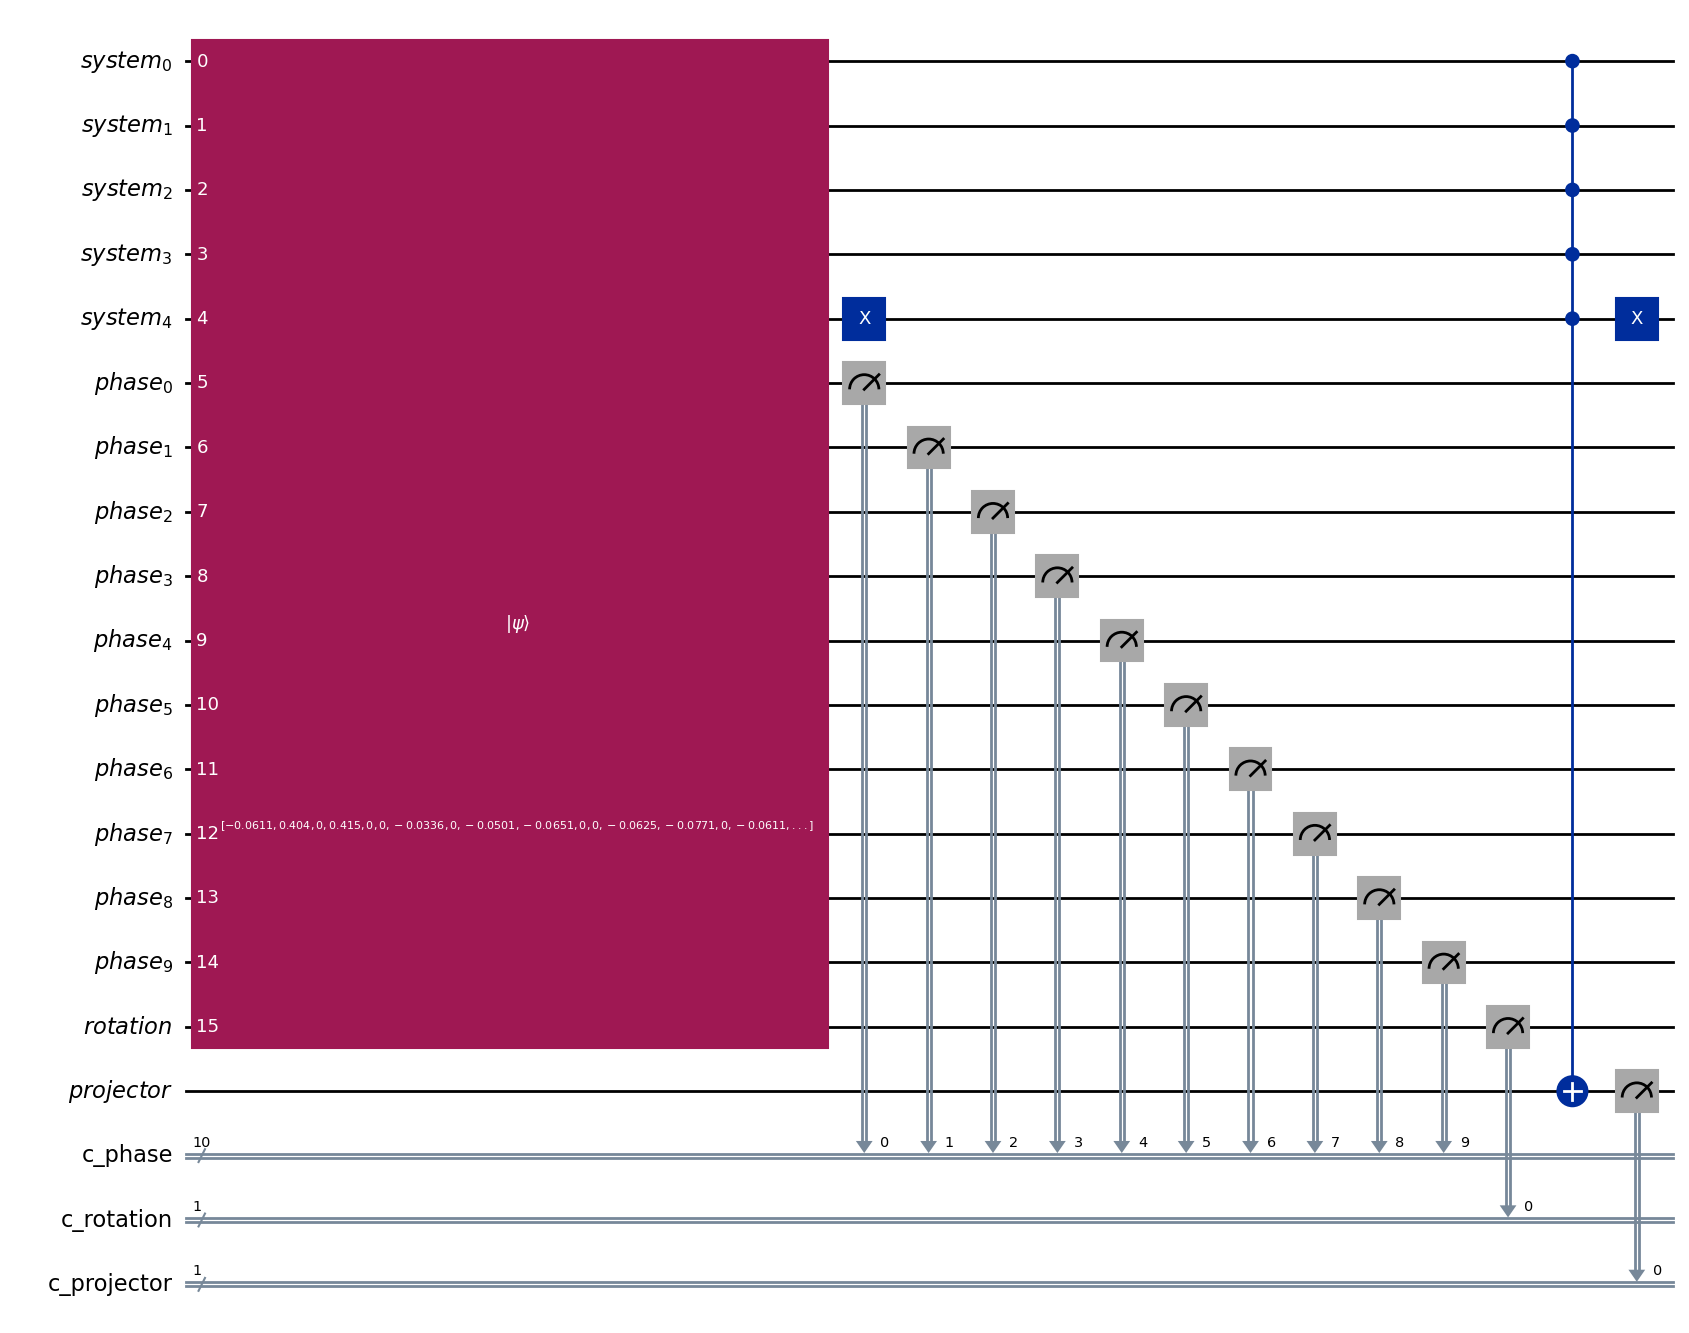


Phase=0 shots              : 97860

Success shots              : 25932

Projector shots            : 574

Measured <eta|x>^2         : 0.022134814129

Exact <eta|x>^2            : 0.020721562030

Absolute error             : 1.413252099603e-03



In [75]:
# ============================================================
# Cell 55E : Direct Projector Measurement
# ============================================================

RUN_CELL_55E = True


if RUN_CELL_55E:

    import time
    import numpy as np

    from qiskit import (
        QuantumCircuit,
        QuantumRegister,
        ClassicalRegister,
        transpile
    )

    from qiskit.circuit.library import Initialize

    from qiskit_aer import AerSimulator


    print("\n" + "=" * 70)
    print("Cell 55E : Direct Projector Measurement")
    print("=" * 70)

    TOTAL_START_TIME = time.time()


    # ========================================================
    # Target node
    # ========================================================

    ETA = 15

    ETA_BITSTRING = format(
        ETA,
        f"0{n_system_reg}b"
    )

    print()

    print(
        f"Target node                : "
        f"{ETA}"
    )

    print(
        f"Binary representation      : "
        f"{ETA_BITSTRING}"
    )


    # ========================================================
    # Registers
    # ========================================================

    system_reg = QuantumRegister(
        n_system_reg,
        "system"
    )

    phase_reg = QuantumRegister(
        m_HHL,
        "phase"
    )

    rotation_reg = QuantumRegister(
        1,
        "rotation"
    )

    projector_reg = QuantumRegister(
        1,
        "projector"
    )

    phase_classical = ClassicalRegister(
        m_HHL,
        "c_phase"
    )

    rotation_classical = ClassicalRegister(
        1,
        "c_rotation"
    )

    projector_classical = ClassicalRegister(
        1,
        "c_projector"
    )


    # ========================================================
    # Circuit
    # ========================================================

    CIRCUIT = QuantumCircuit(

        system_reg,
        phase_reg,
        rotation_reg,
        projector_reg,

        phase_classical,
        rotation_classical,
        projector_classical

    )


    # ========================================================
    # Initialize STATE_AFTER_IQPE
    # ========================================================

    CIRCUIT.append(

        Initialize(
            STATE_AFTER_IQPE.data
        ),

        list(system_reg)
        +
        list(phase_reg)
        +
        list(rotation_reg)

    )


    # ========================================================
    # Implement |eta><eta|
    # ========================================================

    for qubit_index, bit in enumerate(
        ETA_BITSTRING[::-1]
    ):

        if bit == "0":

            CIRCUIT.x(
                system_reg[
                    qubit_index
                ]
            )

    CIRCUIT.mcx(

        list(system_reg),

        projector_reg[0]

    )

    for qubit_index, bit in enumerate(
        ETA_BITSTRING[::-1]
    ):

        if bit == "0":

            CIRCUIT.x(
                system_reg[
                    qubit_index
                ]
            )

    from IPython.display import display

    """
    display(
        CIRCUIT.draw("mpl")
    )
    """


    # ========================================================
    # Measurements
    # ========================================================

    CIRCUIT.measure(
        phase_reg,
        phase_classical
    )

    CIRCUIT.measure(
        rotation_reg,
        rotation_classical
    )

    CIRCUIT.measure(
        projector_reg,
        projector_classical
    )

    display(
        CIRCUIT.draw("mpl", fold=40)
    )

    # ========================================================
    # Execute
    # ========================================================

    SHOTS = 100000

    simulator = AerSimulator()

    result = simulator.run(

        transpile(
            CIRCUIT,
            simulator
        ),

        shots=SHOTS

    ).result()

    counts = result.get_counts()


    # ========================================================
    # Postprocess
    # ========================================================

    phase_zero_shots = 0

    success_shots = 0

    projector_shots = 0


    for bitstring, count in counts.items():

        parts = bitstring.split()

        projector_bits = parts[0]

        rotation_bits = parts[1]

        phase_bits = parts[2]

        phase_ok = (
            int(phase_bits, 2) == 0
        )

        rotation_ok = (
            rotation_bits == "1"
        )

        projector_ok = (
            projector_bits == "1"
        )

        if phase_ok:

            phase_zero_shots += count

        if phase_ok and rotation_ok:

            success_shots += count

        if (

            phase_ok
            and
            rotation_ok
            and
            projector_ok

        ):

            projector_shots += count


    measured_probability = (

        projector_shots
        /
        success_shots

    )


    exact_probability = (

        abs(
            CELL_54F_EXPORTS[
                "solution"
            ][ETA]
        )**2

    )


    # ========================================================
    # Report
    # ========================================================

    print()

    print(
        f"Phase=0 shots              : "
        f"{phase_zero_shots}"
    )

    print()

    print(
        f"Success shots              : "
        f"{success_shots}"
    )

    print()

    print(
        f"Projector shots            : "
        f"{projector_shots}"
    )

    print()

    print(
        f"Measured <eta|x>^2         : "
        f"{measured_probability:.12f}"
    )

    print()

    print(
        f"Exact <eta|x>^2            : "
        f"{exact_probability:.12f}"
    )

    print()

    print(
        f"Absolute error             : "
        f"{abs(measured_probability-exact_probability):.12e}"
    )

    print()

    print("=" * 70)

else:

    print(
        "Cell 55E skipped."
    )